# SN-Oracle

SuperNova Occurrence and Remnant Analysis from pre-Computed Large scale binary and stellar Evolutionary models

(SN-ORLAX) ORacle with LArge-scale model grids and eXtrapolation


### SETUP


In [1]:
using Revise 
GC.gc()


In [2]:

using POPSYNTH
using Printf 
using StatsBase 
using CSV 

include("/vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/JuliaScripts/Plot_defs.jl")
f_MW = POPSYNTH.read_hdf5_into_dataframe(POPSYNTH.BG_dir*"master_CORR.hdf5")
@printf("Packages and Grid loaded.\n")

Including Graphical Packages...Setting LaTeX Theme...done!
Reading Master CORR file /vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/Data/Models_BG/master_CORR.hdf5 ...  done
Packages and Grid loaded.


In [3]:
Threads.nthreads()

1

In [3]:
Revise.revise() 

logMs = range(0.70, 2.001, step=0.050)
logPs = range(0.05, 3.70, step=0.050)
qs    = range(0.10, 0.951, step=0.050)


MERGER_CRITERION = "X"  #  X, PA_IV, ERK, PABLO, PAULI
MERGER_MASSLOSS  = "X"  #"FIX"+fraction or "Energy"
MERGER_EOL       = "CORE"  #"TOTAL" or "CORE" or "ANALYTIC"
EXP_CRIT =  "PS20" # "MM-S21"  #"Ertl-N20_new" #  "PS20"
n = 250
KICKS =  "Inf" # "Valli25_n$n" # "Valli25_n$n" # "kick_n$n"  


f_B = 0.75
IMF_exponent = POPSYNTH.alpha_m 
P_exponent   = 0                 #alpha_p-stdev_p
q_exponent   = 0                 #alpha_q+stdev_q
🗑️ = nothing 
@printf("analyzing grid...\n")
MODELS  = nothing 
GC.gc()

MODELS, 🗑️, BH_binaries, total_SNe = do_SN_popsynth(f=f_MW,
                                             MERGER_CRITERION=MERGER_CRITERION,
                                             MERGER_EOL=MERGER_EOL, 
                                             MERGER_MASSLOSS=MERGER_MASSLOSS,
                                             EXP_CRIT=EXP_CRIT, 
                                             KICKS=KICKS,
                                             pow_m=IMF_exponent, 
                                             pow_p=P_exponent, 
                                             pow_q=q_exponent, 
                                             fB=:custom, 
                                             fB_value=f_B, 
                                             WRITE_TO_FILE=false,
                                             logPs = logPs,
                                             only_SN = true
                                             )
🗑️ = nothing 
GC.gc()

mod_names = []
for k in keys(MODELS)
    push!(mod_names, k)
end
mod_names=sort(mod_names)

@printf("done\n")

analyzing grid...
Scanning logMs
termination MS , Mh   Inf  Mhecore 2.725 Mcocore 1.492 
Ibc-i! 28785 -> Rmax vs Rl = 588.2 - 528.2 sec pMs/Ms/HeB

History for model 28785
STAGE                 |  Age (Myr)         M_1        M_2 M_he_core_1 M_he_core_2        R_1        R_2       Yc_1       Yc_2       Rl_1       Rl_2
          ini_BURN_H_1|    0.110124     49.981     10.024      0.000      0.000      9.480      3.734      0.284      0.274    737.586    357.003
          ini_BURN_H_2|    0.714397     49.096     10.022      0.000      0.000     10.316      3.826      0.350      0.283    746.445    364.129
           BURN_H_50_1|    1.790821     47.147     10.017      0.000      0.000     12.226      3.937      0.485      0.301    766.819    380.750
           BURN_H_25_1|    3.279198     43.614     10.011      0.000      0.000     23.164      4.062      0.735      0.326    806.829    414.563
                 end_1|    4.179562     34.714     10.006      0.000      0.000    453.299      

In [4]:
Revise.revise()
mmm = "1.25_0.50_0.80"
# @show length(MODELS[mmm]["1"].SN), length(MODELS[mmm]["2"].SN)
# @show maximum( [length(MODELS[mmm][e].SN) for e in ["1", "2"]] )
for k in  1:maximum( [length(MODELS[mmm][e].SN) for e in ["1", "2"]] )
    # @show  k,  POPSYNTH.get_data_from_model(MODELS[mmm], "1", k, "ECI?_ogata")
    # try 
    #     @show MODELS[mmm]["ECI"][k]["ogata"]["ECI?"] 
    # catch
    # end 

    @show k, POPSYNTH.get_data_from_model(MODELS[mmm], "1", k, "1st_kick")
    try 
        @show MODELS[mmm]["1st_kick"][k]
    catch
    end 

end

(k, POPSYNTH.get_data_from_model(MODELS[mmm], "1", k, "1st_kick")) = (1, 874.4361f0)
((MODELS[mmm])["1st_kick"])[k] = 874.4361f0
(k, POPSYNTH.get_data_from_model(MODELS[mmm], "1", k, "1st_kick")) = (2, 429.67172f0)
((MODELS[mmm])["1st_kick"])[k] = 429.67172f0
(k, POPSYNTH.get_data_from_model(MODELS[mmm], "1", k, "1st_kick")) = (3, 190.26024f0)
((MODELS[mmm])["1st_kick"])[k] = 190.26024f0
(k, POPSYNTH.get_data_from_model(MODELS[mmm], "1", k, "1st_kick")) = (4, 513.8974f0)
((MODELS[mmm])["1st_kick"])[k] = 513.8974f0
(k, POPSYNTH.get_data_from_model(MODELS[mmm], "1", k, "1st_kick")) = (5, 250.12346f0)
((MODELS[mmm])["1st_kick"])[k] = 250.12346f0


In [8]:
POPSYNTH.seqdata_MODELS("1st_kick", mod_names, MODELS; full_output=false, norm_pdf=1)

Getting data for 1st_kick...


UndefVarError: UndefVarError: `res` not defined in `POPSYNTH`
Suggestion: check for spelling errors or missing imports.

In [5]:
mod_names

UndefVarError: UndefVarError: `mod_names` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
varinfo()


In [ ]:
GC.gc() 
mod_size = Base.summarysize(MODELS)/1024/1024   
snd_size = Base.summarysize(SN_DATA)/1024/1024   
@printf("MODELS = %6.2f MBs - SN_DATA = %6.2f MBs\n", mod_size, snd_size)
#runs	MODELS (GB)	SN_DATA (GB)
#1	    0.129	    0.023
#10	    0.193	    0.058
#50*	0.480	    0.097
#100*	0.802	    0.242
#200*   1.577       0.359
#666*	4.987	    –

#fitted formula
#size(MODELS) /MBs ~ 7.3 MB * runs + 131 MB 
#size(SN_DATA)/MBs ~ 1.6 MB * runs +  21 MB
 
#f_MW    is 0.767 GB



In [ ]:
setdiff(names(Main), names(Base))


In [ ]:


for modkey in keys(MODELS)
    mod = MODELS[modkey]
    first_time = true
    for ix in range(1,length(mod["post_SN_orbit"]))
        !mod["ECI"][ix]["ogata"]["ECI?"] && continue 
        
        first_time && @printf("%17s-%5s-%7.4f%%: ", modkey, mod["1"].SN, mod["pdf"].tot/total_SNe*100)
        # first_time && @printf("orbit/peri_pass")
        orbit = Dict(:bound => "B", :unbound => "U", :direct_collision => "-")[mod["post_SN_orbit"][ix].orbit]
        peria = Dict(true => "✓", false => "↺")[mod["post_SN_orbit"][ix].will_one_periastron_occur]
        @printf(" %1s%1s", orbit, peria )
        first_time = false
    end
    !first_time && print("\n")
end



In [ ]:
for i in range(1, length(f_MW.logP))
    terminated1 = POPSYNTH.termination_stage(f_MW, i, "1")
    terminated2 = POPSYNTH.termination_stage(f_MW, i, "2")

    is_merger = POPSYNTH.is_merger(f_MW, i, "X", terminated1, terminated2)
    print(i, "  ", is_merger, "\n")
    occursin("B", is_merger["RLOFcase"]) && break
end

1  Dict{String, Any}("label" => "case A unfinished", "M2h" => 0.42538, "merger?" => true, "M2" => 0.59744, "RLOFcase" => "A", "M1h" => 3.23348, "t_merger" => 4.285652730289e7, "M2core" => 0.0, "early_or_late" => "early", "case" => "A-mer-unf", "M1core" => 0.0, "Xc" => 0.51712, "M1" => 4.91167, "CaseC_CEE" => false)
2  Dict{String, Any}("label" => "case A unfinished", "M2h" => 0.64245, "merger?" => true, "M2" => 0.90244, "RLOFcase" => "A", "M1h" => 3.12199, "t_merger" => 4.788444572217e7, "M2core" => 0.0, "early_or_late" => "early", "case" => "A-mer-unf", "M1core" => 0.0, "Xc" => 0.48716, "M1" => 4.80564, "CaseC_CEE" => false)
3  Dict{String, Any}("label" => "case A unfinished", "M2h" => 0.79595, "merger?" => true, "M2" => 1.11839, "RLOFcase" => "A", "M1h" => 3.02837, "t_merger" => 4.850677750759e7, "M2core" => 0.0, "early_or_late" => "early", "case" => "A-mer-unf", "M1core" => 0.0, "Xc" => 0.48306, "M1" => 4.68079, "CaseC_CEE" => false)
4  Dict{String, Any}("label" => "case A unfinishe

Excessive output truncated after 524289 bytes.

("label" => "no merger", "M2h" => NaN, "merger?" => false, "M2" => NaN, "RLOFcase" => "B", "M1h" => NaN, "t_merger" => NaN, "M2core" => NaN, "early_or_late" => "", "case" => nothing, "M1core" => NaN, "Xc" => NaN, "M1" => NaN, "CaseC_CEE" => false)
1742  Dict{String, Any}("label" => "no merger", "M2h" => NaN, "merger?" => false, "M2" => NaN, "RLOFcase" => "B", "M1h" => NaN, "t_merger" => NaN, "M2core" => NaN, "early_or_late" => "", "case" => nothing, "M1core" => NaN, "Xc" => NaN, "M1" => NaN, "CaseC_CEE" => false)
1743  Dict{String, Any}("label" => "no merger", "M2h" => NaN, "merger?" => false, "M2" => NaN, "RLOFcase" => "B", "M1h" => NaN, "t_merger" => NaN, "M2core" => NaN, "early_or_late" => "", "case" => nothing, "M1core" => NaN, "Xc" => NaN, "M1" => NaN, "CaseC_CEE" => false)
1744  Dict{String, Any}("label" => "no merger", "M2h" => NaN, "merger?" => false, "M2" => NaN, "RLOFcase" => "B", "M1h" => NaN, "t_merger" => NaN, "M2core" => NaN, "early_or_late" => "", "case" => nothing, "M1c

## multiple popsynth 

In [3]:
Revise.revise()

logMs = range(0.70, 2.001, step=0.050)
logPs = range(0.05, 3.70, step=0.050)
qs    = range(0.10, 0.951, step=0.050)


MERGER_MASSLOSS  = "X"  #"FIX"+fraction or "Energy"
MERGER_EOL       = "CORE"  #"TOTAL" or "CORE" or "ANALYTIC"


f_B = 0.75
IMF_exponent = POPSYNTH.alpha_m 
P_exponent   = 0                 #alpha_p-stdev_p
q_exponent   = 0                 #alpha_q+stdev_q


n = 500
sym_to_t = Dict(:IIP=>"IIP", :SN87A=>"87A", :IIb=>"IIb", :IIn=>"IIn", :Ibc=>"Ibc", :Ibn=>"Ibn")
KICKS_list = ["MM_n$n", "Hobbs_n$n", "DM25_n$n", "COMBINE_n$n", "Valli25_n$n", "None"]
prgs_names = ["MT-1", "NI-1", "MT-2", "NI-2", "NI-S", "M"]
@printf("analyzing grid...\n")
MODELS = nothing 
SN_DATA = nothing 
GC.gc()
for mc in ["X", "PABLO"]
for ec in ["MM-S21", "PS20"]
for kick in KICKS_list 
    MODELS, _, _, total_SNe = do_SN_popsynth(f=f_MW,
                                                MERGER_CRITERION=mc,
                                                MERGER_EOL=MERGER_EOL, 
                                                MERGER_MASSLOSS=MERGER_MASSLOSS,
                                                EXP_CRIT=ec, 
                                                KICKS=kick,
                                                pow_m=IMF_exponent, 
                                                pow_p=P_exponent, 
                                                pow_q=q_exponent, 
                                                fB=:custom, 
                                                fB_value=f_B, 
                                                WRITE_TO_FILE=false,
                                                logPs = logPs,
                                                only_SN = true
                                                )

    mod_names = []
    for k in keys(MODELS)
        push!(mod_names, k)
    end
    mod_names=sort(mod_names)


    prgs, pdfs, sn1, SNe = POPSYNTH.seqdata_MODELS("SN", mod_names, MODELS, norm_pdf=total_SNe)
    pdfs *= 100 
    ECI = POPSYNTH.seqdata_MODELS("ECI?_ogata", mod_names, MODELS, full_output=false)
    tau_ECI = POPSYNTH.seqdata_MODELS("tau_ECI", mod_names, MODELS, full_output=false)/POPSYNTH.day
    tau_periastron = POPSYNTH.seqdata_MODELS("when_will_periastron_occur", mod_names, MODELS, full_output=false)/POPSYNTH.day
    P_postSN = POPSYNTH.seqdata_MODELS("P", mod_names, MODELS, full_output=false)/POPSYNTH.day
    post_SN_orbit = POPSYNTH.seqdata_MODELS("orbit", mod_names, MODELS, full_output=false)
    # v_kick = POPSYNTH.seqdata_MODELS("1st_kick", mod_names, MODELS, full_output=false)
    # v_orb_1 = POPSYNTH.seqdata_MODELS("pre_v1", mod_names, MODELS, full_output=false)
    n_passages = [post_SN_orbit[i] == :bound ? (floor((tau_ECI[i] - tau_periastron[i])/P_postSN[i]) + 1) : 1   for i in range(1,length(pdfs))]
    eccentricity = POPSYNTH.seqdata_MODELS("e", mod_names, MODELS, full_output=false)

    ccsne = (SNe .== :IIP) .|| (SNe .== :Ibc) .|| (SNe .== :IIb) .|| (SNe .== :IIn) .|| (SNe .== :Ibn) .|| (SNe .== :SN87A)
    sn_tot= sum(pdfs[ccsne])

    select_sne = sn1 .&& ccsne .&& (post_SN_orbit .!= :merged) .&& (prgs .!== "M" .|| prgs .!== "NI-S")
    SISE = ECI .&& select_sne .&& (tau_periastron .< tau_ECI)
    
    SISE_1 = SISE .&& (n_passages .== 1)
    SISE_p = SISE .&& (n_passages  .> 1)

   

    # outfile = POPSYNTH.out_dir*"ECI.dat" 
    # get_pdf(fff) = sum(pdfs[fff])
    # isfile(outfile) ? i=1 : i=0 
    # fp = open(outfile, "a")
    # if i ==0 
    #     write(fp,  @sprintf("%10s ", "MER_CRIT"))
    #     write(fp,  @sprintf("%10s ", "MER_dM"))
    #     write(fp,  @sprintf("%10s ", "MER_EOL"))
    #     write(fp,  @sprintf("%10s ", "EXP_CRIT"))
    #     write(fp,  @sprintf("%20s ", "KICKS"))
    #     write(fp,  @sprintf("%10s ", "fB"))
    #     write(fp,  @sprintf("%10s ", "pow_logM"))
    #     write(fp,  @sprintf("%10s ", "pow_logP"))
    #     write(fp,  @sprintf("%10s ", "pow_q"))
    #     write(fp,  @sprintf("%10s ", "total_SNe"))
    #     write(fp,  @sprintf("%10s ", "first_sn_bin"))
    #     write(fp,  @sprintf("%10s ", "CCI"))
    #     write(fp,  @sprintf("%10s ", "CCI_s"))
    #     write(fp,  @sprintf("%10s ", "CCI_p"))
    #     for ttp in [:IIP, :SN87A, :IIb, :IIn, :Ibc, :Ibn]
    #         this_sn = (SNe.==ttp)
    #         str = sym_to_t[ttp]
    #         write(fp, @sprintf("%10s ", str))
    #         for prg in prgs_names
    #             write(fp, @sprintf("%10s ", str*"_"*prg))
    #         end
    #         write(fp, @sprintf("%10s ", str*"_frac"))
    #         write(fp, @sprintf("%10s ", str*"_CCI"))
    #         write(fp, @sprintf("%10s ", str*"_CCI_s"))
    #         write(fp, @sprintf("%10s ", str*"_CCI_p"))
    #     end
    #     write(fp,  @sprintf("\n"))
    #     i=1
    # end 

    # write(fp,  @sprintf("%10s ", mc))
    # write(fp,  @sprintf("%10s ", MERGER_MASSLOSS))
    # write(fp,  @sprintf("%10s ", MERGER_EOL))
    # write(fp,  @sprintf("%10s ", ec))
    # write(fp,  @sprintf("%20s ", kick))
    # write(fp,  @sprintf("%10.3f ", f_B))
    # write(fp,  @sprintf("%10.3f ", IMF_exponent))
    # write(fp,  @sprintf("%10.3f ", P_exponent))
    # write(fp,  @sprintf("%10.3f ", q_exponent))
    # write(fp,  @sprintf("%10.4f ", total_SNe))
    # write(fp,  @sprintf("%10.4f ", get_pdf(select_sne)))
    # write(fp,  @sprintf("%10.4f ", get_pdf(SISE)))
    # write(fp,  @sprintf("%10.4f ", get_pdf(SISE_1)))
    # write(fp,  @sprintf("%10.4f ", get_pdf(SISE_p)))
    # for ttp in [:IIP, :SN87A, :IIb, :IIn, :Ibc, :Ibn]
    #     this_sn = (SNe.==ttp)
    #     write(fp, @sprintf("%10.4f ", get_pdf(this_sn)))
    #     for prg in prgs_names
    #        write(fp, @sprintf("%10.4f ", get_pdf(this_sn .&& (prgs .== prg))))
    #     end
    #     write(fp, @sprintf("%10.4f ", get_pdf(this_sn .&& select_sne)))
    #     write(fp, @sprintf("%10.4f ", get_pdf(this_sn .&& SISE)))
    #     write(fp, @sprintf("%10.4f ", get_pdf(this_sn .&& SISE_1)))
    #     write(fp, @sprintf("%10.4f ", get_pdf(this_sn .&& SISE_p)))
    # end
    # write(fp,  @sprintf("\n"))
    # close(fp)

    fff = SISE_p .&& (SNe .== :Ibc .|| SNe .== :Ibn)
    pdf_norm = sum(pdfs[fff]) 
    outfile = POPSYNTH.out_dir * @sprintf("periods_ECI_%s_%s_%s.dat", kick, mc, ec)
    fp = open(outfile, "w")
    write(fp,  @sprintf("%10s ", "P"))
    write(fp,  @sprintf("%10s ", "e"))
    write(fp,  @sprintf("%10s\n", "pdf"))
    for i in range(1,length(P_postSN))
        !fff[i] && continue
        write(fp,  @sprintf("%10.3f ",  P_postSN[i]))
        write(fp,  @sprintf("%10.3f ",  eccentricity[i]))
        write(fp,  @sprintf("%10.4e\n", pdfs[i]/pdf_norm))
    end
    close(fp)

end
end
end

GC.gc()

@printf("done\n")

analyzing grid...
Scanning logMs
2.00 [37000/37422] 
     which |     IIP   SN87A     IIb     Ibc     IIn     Ibn (     BH)
         1 |    4.62    0.00    1.19   20.13    2.20    2.43 (   1.78) |   30.57
         2 |   15.30    0.00    0.77    3.09    0.05    0.00 (   0.95) |   19.21
         M |   24.38    0.32    1.06    3.84    0.14    0.00 (   2.67) |   29.74
         S |   16.42    0.00    1.05    3.01    0.00    0.00 (   1.57) |   20.48
     TOTAL |   60.72    0.32    4.07   30.07    2.39    2.43 (   6.97)
Removing models that do not produce any SN... n. models =  35964 ->   27471 
prg    IIP  SN87A    IIb    Ibc    IIn    Ibn :    BH | Total
   1   4.62   0.00   1.19  20.13   2.20   2.43 :  1.78 |  30.57
   2  15.30   0.00   0.77   3.09   0.05   0.00 :  0.95 |  19.21
   M  24.38   0.32   1.06   3.84   0.14   0.00 :  2.67 |  29.74
   S  16.42   0.00   1.05   3.01   0.00   0.00 :  1.57 |  20.48
Placing non-interacting systems inside single-stars.
1-MT   0.11   0.00   1.10  17.17 

### compare P and e distributions

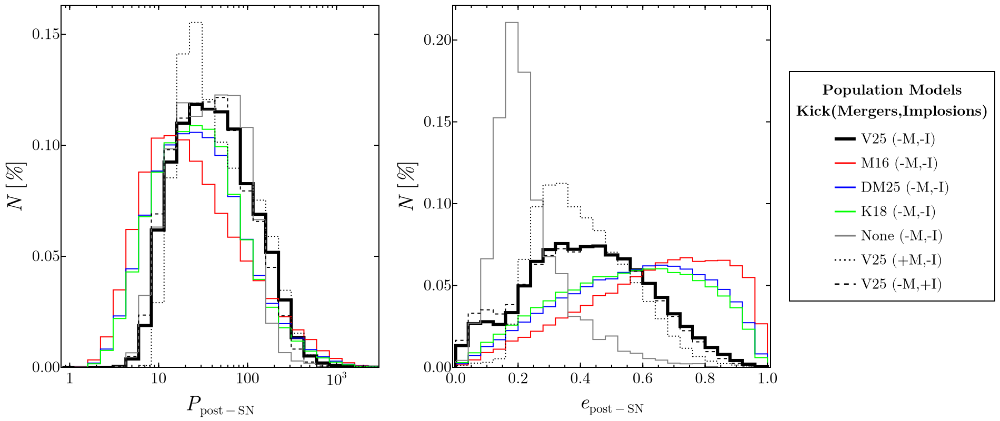

In [143]:
using DataFrames 
n=500
ks = ["MM_n$n", "Hobbs_n$n", "DM25_n$n", "COMBINE_n$n", "Valli25_n$n", "None"]
mc = ["X", "PABLO"]
ec = ["MM-S21", "PS20"]


f_fmt(k,m,e) = @sprintf("../output/periods_ECI_%s_%s_%s.dat", k, m, e)

f_def = CSV.read(f_fmt(ks[5], mc[1], ec[1]), DataFrame, delim=" ", ignorerepeated=true )

FIG = Figure(size=(950, 400), figure_padding = 5)


mlogticks = [k  for j in -90:1:90 for k in  (10. ^j):(10. ^j):(10. ^(j+1))]
mlinticks = 0:0.1:100
xticks10    = [10^t for t in -90.:1.:+90.]
logxticks10 = [t    for t in -90.:1.:+90.]
ticklabels  = [latexstring(@sprintf("10^{%d}", t)) for t in -90:90]
# ticklabels[findfirst(x->x==-2, logxticks10)]="0.01"
ticklabels[findfirst(x->x==-1, logxticks10)]="0.1"
ticklabels[findfirst(x->x== 0, logxticks10)]="1"
ticklabels[findfirst(x->x==+1, logxticks10)]="10"
ticklabels[findfirst(x->x==+2, logxticks10)]="100"
ticks    = (   xticks10, ticklabels)
logticks = (logxticks10, ticklabels)
linticks = 0:0.5:100
ticksize=11
nbins=25


scalex = log10
ax1 = plot_settings(FIG[1,1]; 
        ylabel=L"N \ [%]", 
        xlabel=L"P_\mathrm{post-SN}", 
        title =" ",
        xticks  = logticks,
        xmticks = scalex.(mlogticks),  
        # yticks=0:1:100,
        # ymticks=0:0.1:100,
        )

xmin = 0.8
xmax = 3e3
dxb = (scalex(xmax)-scalex(xmin))/nbins
xbins=scalex(xmin)-dxb/2:dxb:scalex(xmax)+dxb/2
xlims!(ax1, scalex.(xmin), scalex.(xmax))
fs = [  (k=ks[5], m=mc[1], e=ec[1]),  
        (k=ks[1], m=mc[1], e=ec[1]),
        (k=ks[3], m=mc[1], e=ec[1]),
        (k=ks[4], m=mc[1], e=ec[1]),
        (k=ks[6], m=mc[1], e=ec[1]),
        (k=ks[5], m=mc[2], e=ec[1]),
        (k=ks[5], m=mc[1], e=ec[2]),
]
cc = [:black, :red, :blue, :lime, :gray, :black, :black]
ss = [:solid, :solid, :solid, :solid, :solid, :dot, :dash]
x = scalex.(f_def.P)
# bins, y_bins = run_histogram(ax1, x, Weights(f_def.pdf), xbins, dxb * (scalex==log10 ? 1.2 : 1.), norm=1, color = :lightgray, colorcont = RGBAf(0,0,0,0),bar_or_step = :bar)
ix=1
bins, y_bins = run_histogram(ax1, x, Weights(f_def.pdf), xbins, dxb * (scalex==log10 ? 1.2 : 1.), norm=1, color = :black, strokewidth=3, bar_or_step = :step)
# bins, y_bins = run_histogram(ax1, x, Weights(f_def.pdf), xbins, dxb * (scalex==log10 ? 1.2 : 1.), norm=1, color = :black, strokewidth=5, bar_or_step = :step)
PearsonCoeff = cor(reduce(hcat, [f_def.P,f_def.e]), Weights(f_def.pdf))[1,2]
# barplot!(ax1, [-99], [1e-99], color = :gray, label = @sprintf("Fiducial\n%.2f", PearsonCoeff))
lines!(ax1, [-99], [1e-99], color = cc[1], linestyle=ss[1], linewidth=3, label = @sprintf("V25 (-M,-I)") )

for ix in range(2,length(fs))
        f_other =  CSV.read(f_fmt(fs[ix].k,fs[ix].m,fs[ix].e), DataFrame, delim=" ", ignorerepeated=true )

        exp_crit = Dict("MM" => "-I", "PS"=>"+I", "Er"=>"E16")[fs[ix].e[1:2]]  
        mer_crit = Dict("X"=>"-M", "PABLO" => "+M", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[fs[ix].m]  
        kick_dict = Dict("Inf" => "Inf", "Unbound"=>"Unbound",
                          "MM_n$n" =>      "M16" ,
                          "Hobbs_n$n" =>   "H50" ,
                          "DM25_n$n" =>    "DM25",
                          "COMBINE_n$n" => "K18" ,
                          "Valli25_n$n" => "V25", 
                          "None" => "None"
                          )[fs[ix].k]

        x = scalex.(f_other.P)
        PearsonCoeff = cor(reduce(hcat, [f_other.P,f_other.e]), Weights(f_other.pdf))[1,2]

        bins, y_bins = run_histogram(ax1, x, Weights(f_other.pdf), xbins, dxb * (scalex==log10 ? 1.2 : 1.), norm=1, color = cc[ix], strokestyle=ss[ix], bar_or_step = :step)
        lines!(ax1, [-99], [1e-99], color = cc[ix], linestyle=ss[ix], label = @sprintf("%s (%s,%s)", kick_dict, mer_crit, exp_crit) )
end
ylims!(ax1, 0, nothing )



ax2 = plot_settings(FIG[1,2]; 
        ylabel=L"N \ [%]", 
        xlabel=L"e_\mathrm{post-SN}", 
        title =" ",
        xticks  = 0:0.2:1,
        xmticks = 0:0.05:1,  
        # yticks=0:1:100,
        # ymticks=0:0.1:100,
        )

xmin = 0
xmax = 1
scalex=identity
dxb = (scalex(xmax)-scalex(xmin))/nbins
xbins=scalex(xmin)-dxb/2:dxb:scalex(xmax)+dxb/2
xlims!(ax2, scalex.(xmin), scalex.(xmax))

x = scalex.(f_def.e)
# bins, y_bins = run_histogram(ax2, x, Weights(f_def.pdf), xbins, dxb * (scalex==log10 ? 1.2 : 1.), norm=1, color = :lightgray, colorcont = RGBAf(0,0,0,0),bar_or_step = :bar)
ix=1
bins, y_bins = run_histogram(ax2, x, Weights(f_def.pdf), xbins, dxb * (scalex==log10 ? 1.2 : 1.), norm=1, color = :black, strokewidth=3, bar_or_step = :step)
# bins, y_bins = run_histogram(ax2, x, Weights(f_def.pdf), xbins, dxb * (scalex==log10 ? 1.2 : 1.), norm=1, color = :black, strokewidth=5, bar_or_step = :step)

for ix in range(2,length(fs))
        f_other =  CSV.read(f_fmt(fs[ix].k,fs[ix].m,fs[ix].e), DataFrame, delim=" ", ignorerepeated=true )

        x = scalex.(f_other.e)
        bins, y_bins = run_histogram(ax2, x, Weights(f_other.pdf), xbins, dxb * (scalex==log10 ? 1.2 : 1.), norm=1, color = cc[ix], strokestyle=ss[ix], bar_or_step = :step)
end
# ylims!(ax1, 0, maximum(y_bins)*1.1 )
ylims!(ax2, 0, nothing )
xlims!(ax2, -0.01,1.01)

Legend(FIG[1,3], ax1, "Population Models\nKick(Mergers,Implosions)")

save_directory = "../output/ECI/"
outfilename = @sprintf("multimodel_histograms.pdf")
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png


FIG

In [117]:
collect(xbins)

26-element Vector{Float64}:
 0.0
 0.04
 0.08
 0.12
 0.16
 0.2
 0.24
 0.28
 0.32
 0.36
 ⋮
 0.68
 0.72
 0.76
 0.8
 0.84
 0.88
 0.92
 0.96
 1.0

Weights: min=1.207e-05, max=5.033e-01, min/max=2.399e-05
Weights: min=1.133e-04, max=1.982e-01, min/max=5.715e-04
Weights: min=3.615e-05, max=2.126e-01, min/max=1.700e-04
Weights: min=2.383e-05, max=2.064e-01, min/max=1.154e-04
Weights: min=2.636e-05, max=9.948e-01, min/max=2.650e-05
Weights: min=1.568e-05, max=4.868e-01, min/max=3.220e-05


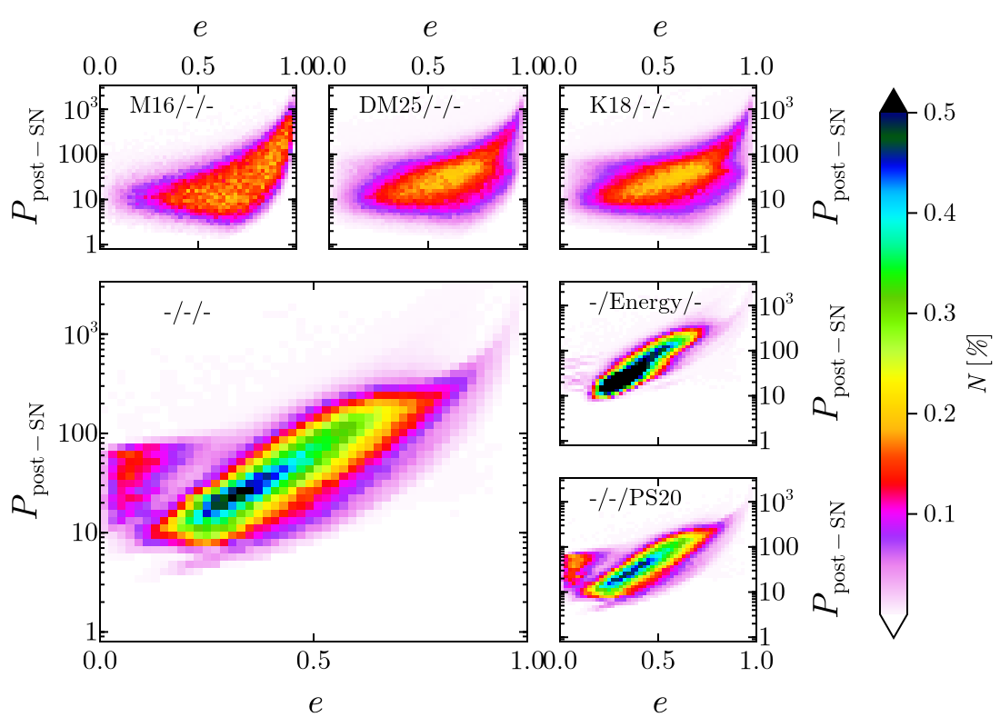

In [75]:
FIG = Figure(size=(550, 400), figure_padding = 5)


mlogticks = [k  for j in -90:1:90 for k in  (10. ^j):(10. ^j):(10. ^(j+1))]
mlinticks = 0:0.1:100
xticks10    = [10^t for t in -90.:1.:+90.]
logxticks10 = [t    for t in -90.:1.:+90.]
ticklabels  = [latexstring(@sprintf("10^{%d}", t)) for t in -90:90]
# ticklabels[findfirst(x->x==-2, logxticks10)]="0.01"
ticklabels[findfirst(x->x==-1, logxticks10)]="0.1"
ticklabels[findfirst(x->x== 0, logxticks10)]="1"
ticklabels[findfirst(x->x==+1, logxticks10)]="10"
ticklabels[findfirst(x->x==+2, logxticks10)]="100"
ticks    = (   xticks10, ticklabels)
logticks = (logxticks10, ticklabels)
linticks = 0:0.5:100
ticksize=11
nbins=50

ymin, ymax = Pmin, Pmax 
xmin, xmax = 0, 1
scalex = identity
scaley = log10
dxb = (scalex(xmax)-scalex(xmin))/nbins
dyb = (scaley(ymax)-scaley(ymin))/nbins


xbins=scalex(xmin):dxb:scalex(xmax)
ybins=scaley(ymin):dyb:scaley(ymax)


fs = [  (k=ks[5], m=mc[1], e=ec[1]),  
        (k=ks[1], m=mc[1], e=ec[1]),
        (k=ks[3], m=mc[1], e=ec[1]),
        (k=ks[4], m=mc[1], e=ec[1]),
        # (k=ks[6], m=mc[1], e=ec[1]),
        (k=ks[5], m=mc[2], e=ec[1]),
        (k=ks[5], m=mc[1], e=ec[2]),
]
fig_placement = [ (2:3,1:2),
                  (1,1), (1,2),(1,3), (2,3), (3,3) ]
ax = Dict()
hm = nothing 
for ix in range(1,length(fs))
        f_other =  CSV.read(f_fmt(fs[ix].k,fs[ix].m,fs[ix].e), DataFrame, delim=" ", ignorerepeated=true )
        x = scalex.(f_other.e)
        y = scaley.(f_other.P)
        ax[ix] = plot_settings(FIG[fig_placement[ix][1], fig_placement[ix][2]]; 
                xlabel=L"e", 
                ylabel=L"P_\mathrm{post-SN}", 
                title =" ",
                xlabelvisible = fig_placement[ix][1] in [2:3, 3, 1] ,
                xticklabelsvisible=fig_placement[ix][1]  in [2:3, 3, 1] ,
                ylabelvisible = fig_placement[ix][2] in [1:2, 1, 3] ,
                yticklabelsvisible = fig_placement[ix][2] in [1:2, 1, 3] ,
                yticks  = logticks,
                ymticks = scaley.(mlogticks),  
                xaxisposition =  fig_placement[ix][1][1] <= 1 ? :top : :bottom,
                yaxisposition =  fig_placement[ix][2][1] <= 1 ? :left : :right
                # yticks=0:1:100,
                # ymticks=0:0.1:100,
                )

        exp_crit = Dict("MM" => "-", "PS"=>"PS20", "Er"=>"E16")[fs[ix].e[1:2]]  
        mer_crit = Dict("X"=>"-", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[fs[ix].m]  
        kick_dict = Dict("Inf" => "Inf", "Unbound"=>"Unbound",
                          "MM_n$n" =>      "M16" ,
                          "Hobbs_n$n" =>   "H50" ,
                          "DM25_n$n" =>    "DM25",
                          "COMBINE_n$n" => "K18" ,
                          "Valli25_n$n" => "-", 
                          "None" => "None"
                          )[fs[ix].k]

        PearsonCoeff = cor(reduce(hcat, [f_other.P,f_other.e]), Weights(f_other.pdf))[1,2]

        hm = sn_heatmap(ax[ix], x, y, Weights(f_other.pdf .* 100), xbins, ybins; colorrange=[0.00001,0.5],
                cmap=Reverse(:gist_ncar), print_data=true,lowclip=:white, highclip=:black)
        text!(ax[ix],  @sprintf("%s/%s/%s", kick_dict, mer_crit, exp_crit),
                position = (.15, .95),        # relative coords in axis space
                align = (:left, :top),   # anchor point
                space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
                )
        

                
end
Colorbar(FIG[1:3,4], hm, label=L"N \ [%]",size = 15, ticks = 0:0.1:1)


save_directory = "../output/ECI/"
outfilename = @sprintf("multimodel_heatmaps.pdf")
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

FIG


# Line Plots

In [7]:
using DataFrames 
FIG = Figure(size=(400, 670), figure_padding = 5)
labval(label,value) = Dict("val"=>value, "tlabel"=>label)
n = 200
label_to_dict = Dict(
    "KICKS" => Dict("Inf" => labval(L"\infty",-2),
                          "MM_n$n" => labval("M16",-1) ,
                          "Hobbs_n$n" => labval("H05",0),
                          "DM25_n$n" => labval("DM25", 1),
                          "COMBINE_n$n" => labval("K18", 2),
                          "Valli25_n$n" => labval("V25", 3),
                          "None" => labval("None", 4)
                          ))
label = "KICKS"



xticks = ( [ label_to_dict[label][lab]["val"]   for lab in keys(label_to_dict[label])]   ,  [ label_to_dict[label][lab]["tlabel"]   for lab in keys(label_to_dict[label])])

grid = FIG[1,1] = GridLayout()


yticklabelsize=16.
ylabelsize=16.5
xticklabelsize = 12
xlabelsize = 16.5
yticklabelpad = 1.8
left_panels = 1:4
right_panels = 5:6

yticklabelspace = 10.
ylabelpadding = 10.

SN = :Ibn
lc = Dict(1 => :black, 2 => :magenta, 3 => :cyan)
ls = Dict(1 => :solid, 2 => :dash, 3 => :dot)
sym_to_t = Dict(:IIP=>"IIP", :SN87A=>"87A", :IIb=>"IIb", :IIn=>"IIn", :Ibc=>"Ibc", :Ibn=>"Ibn")
lb = Dict(1 => "Fiducial Model", 2 => "+ implosions", 3 => "+ mergers")

ax1 = plot_settings( grid[1,1],
                xlabel = "Kick distribution",
                ylabel =  @sprintf("#SN(%s) [%%]", sym_to_t[SN]),
                title = "", titlesize=30,
                xticks = xticks,
                yticks= 0:5:100,
                ymticks= 0:1:100,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, 
                xticklabelsvisible=false, yticklabelpad=yticklabelpad, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax2 = plot_settings( grid[2,1],
                xlabel = "Kick distribution",
                ylabel =  @sprintf("# SN(%s) with SECI [%%]", sym_to_t[SN]),
                title = "", titlesize=30,
                xticks = xticks,
                yticks= 0:1:100,
                ymticks= 0:.5:100,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, 
                xticklabelsvisible=false, yticklabelpad=yticklabelpad, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax3 = plot_settings( grid[3,1],
                xlabel = "Kick distribution",
                ylabel =  @sprintf("# SECI-%s/%s [%%]", sym_to_t[SN],sym_to_t[SN]),
                title = "", titlesize=30,
                xticks = xticks,
                yticks= 0:.2:100,
                ymticks= 0:.1:100,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=true, 
                xticklabelsvisible=true, yticklabelpad=yticklabelpad, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)

                
alpha = 0.9
color_coding = Dict()
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(102/255,0,0,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 


alpha = 0.5
color_coding["1"]   = RGBAf(0/255,200/255,200/255,alpha)    
color_coding["2"]   = RGBAf(227/255, 255/255, 0,alpha)    
color_coding["M"]   = RGBAf(250/255,0,227/255 ,alpha)   
color_coding["S"]   = RGBAf(0.8, .8, .8,alpha) 

MER_CRIT = ["X", "PA_IV", "ERK", "PABLO", "PAULI", "ALL"]
EXP_CRIT = ["MM-M16", "Ertl-", "PS20", "comp0.20", "comp0.25", "comp0.30", "comp0.35"]
MER_EOL =  ["TOTAL"]#["TOTAL", "CORE", "ANALYTIC"]
MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
fBs =      [0.75]
KICKS = [Inf] #[Inf, 0]

SN_FILE = CSV.read("../output/ECI.dat", DataFrame, delim=" ", ignorerepeated=true )
KICKS_list = ["Inf", "MM_n$n", "Hobbs_n$n", "DM25_n$n", "COMBINE_n$n", "Valli25_n$n", "None"]

marker = :circle
markersize= 10




idx = 1

for  ME in [["X", "MM-S21"], ["X",  "PS20"], ["PABLO", "MM-S21"]]
    MER_CRIT =   ME[1]
    EXP_CRIT = ME[2]
    KICKS = KICKS_list
    fB  =      0.75

    
    SN_ix=[ ] 



    for kick in KICKS 

        for entry in range(1,length(SN_FILE.EXP_CRIT))
            SN_FILE.MER_CRIT[entry] != MER_CRIT && continue 
            SN_FILE.EXP_CRIT[entry] != EXP_CRIT && continue  
            SN_FILE.fB[entry] != fB && continue  
            SN_FILE.KICKS[entry] != kick && continue 


            push!(SN_ix, entry)
            
            

        end


    end


    
    print(SN_ix)
    x_og = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix ]
    print("\n", x_og)
    ix_og = SN_ix
    x = x_og[sortperm( x_og )]
    ix_n =  ix_og[sortperm( x_og )]
    print("\n", ix_n)

    SN2 = SN_ix
    this_sn = sym_to_t[SN]
    ms = 20
    color = color_coding[SN]
     
    show_label = true

    scatterlines!(ax1,    x, [SN_FILE[!, this_sn][ix]                                    for ix in ix_n], color=color,  linestyle=ls[idx], marker = marker, markersize = markersize)
    scatterlines!(ax2,    x, [SN_FILE[!, this_sn*"_SISE_p"][ix]                          for ix in ix_n], color=:purple,  linestyle=ls[idx], marker = marker, markersize = markersize)
    scatterlines!(ax3,    x, [SN_FILE[!, this_sn*"_SISE_p"][ix] /SN_FILE[!, this_sn][ix] for ix in ix_n], color=:purple,  linestyle=ls[idx], marker = marker, markersize = markersize)
    scatterlines!(ax2,    x, [SN_FILE[!, this_sn*"_SISE_s"][ix]                          for ix in ix_n], color=:orange,  linestyle=ls[idx], marker = marker, markersize = markersize)
    scatterlines!(ax3,    x, [SN_FILE[!, this_sn*"_SISE_s"][ix] /SN_FILE[!, this_sn][ix] for ix in ix_n], color=:orange,  linestyle=ls[idx], marker = marker, markersize = markersize)

    idx+=1
end


# lines!(ax,  [0], [0], color=(:black, 0.5), linewidth=  5,  linestyle=:solid, label = "Total")
# scatterlines!(ax1,  [-10], [-10], color=:blue,   linestyle=:solid, label = "Type Ibc", marker=marker, markersize=markersize)
# scatterlines!(ax1,  [-10], [-10], color=:purple, linestyle=:solid, label = "Type Ibn", marker=marker, markersize=markersize)
lines!(ax1,  [-10], [-10], color=:black,  linestyle=ls[1], label = lb[1])
lines!(ax1,  [-10], [-10], color=:black,  linestyle=ls[2], label = lb[2])
lines!(ax1,  [-10], [-10], color=:black,  linestyle=ls[3], label = lb[3])
axislegend(ax1, position=:rt, nbanks=3, labelsize=13.)
lines!(ax2,  [-10], [-10], color=:purple,  linestyle=:solid, label = "+ SECI")
lines!(ax2,  [-10], [-10], color=:orange,  linestyle=:solid, label = "1 SECI")
axislegend(ax2, position=:ct, nbanks=3, labelsize=13.)

for ax in [ax1,ax2,ax3]
    xlims!(ax, -1.2, 4.2)
    ylims!(ax, 0, nothing)

end 
ylims!(ax1, 0,5)
rowgap!(grid, 5)
colgap!(grid, 0)


outfilename = POPSYNTH.out_dir*"lineplot_"*sym_to_t[SN]*".pdf"
save(outfilename, FIG)    # 1600 × 1200 px png

FIG


Any[1]
[-2]
Any[1]

ArgumentError: ArgumentError: column name :Ibn_SISE_p not found in the data frame

Any[2, 4, 5, 6, 7]
[0, 1, 2, 3, 4]
Any[2, 4, 5, 6, 7]Any[9, 11, 12, 13, 14]
[0, 1, 2, 3, 4]
Any[9, 11, 12, 13, 14]Any[16, 18, 19, 20, 21]
[0, 1, 2, 3, 4]
Any[16, 18, 19, 20, 21]

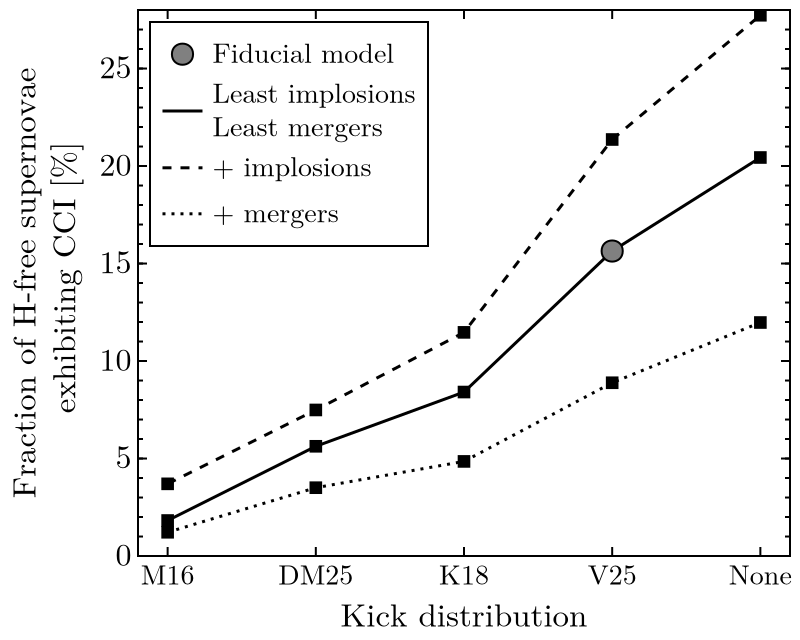

In [9]:
using DataFrames 
FIG = Figure(size=(400, 320), figure_padding = 5)
labval(label,value) = Dict("val"=>value, "tlabel"=>label)
n= 500
label_to_dict = Dict(
    "KICKS" => Dict("Inf" => labval(L"\infty",-2),
                          "MM_n$n" => labval("M16",0) ,
                          "Hobbs_n$n" => labval("H05",-1),
                          "DM25_n$n" => labval("DM25", 1),
                          "COMBINE_n$n" => labval("K18", 2),
                          "Valli25_n$n" => labval("V25", 3),
                          "None" => labval("None", 4)
                          ))
label = "KICKS"



xticks = ( [ label_to_dict[label][lab]["val"]   for lab in keys(label_to_dict[label])]   ,  [ label_to_dict[label][lab]["tlabel"]   for lab in keys(label_to_dict[label])])

grid = FIG[1,1] = GridLayout()


yticklabelsize=16.
ylabelsize=16.5
xticklabelsize = 14
xlabelsize = 16.5
yticklabelpad = 2.2
left_panels = 1:4
right_panels = 5:6

yticklabelspace = 10.
ylabelpadding = 15.

lc = Dict(1 => :black, 2 => :magenta, 3 => :cyan)
ls = Dict(1 => :solid, 2 => :dash, 3 => :dot)
sym_to_t = Dict(:IIP=>"IIP", :SN87A=>"87A", :IIb=>"IIb", :IIn=>"IIn", :Ibc=>"Ibc", :Ibn=>"Ibn")
lb = Dict(1 => "Least implosions\nLeast mergers", 2 => "+ implosions", 3 => "+ mergers")

ax = plot_settings( grid[1,1],
                xlabel = "Kick distribution",
                ylabel = "Fraction of H-free supernovae\n exhibiting CCI [%]",
                title = "", titlesize=30,
                xticks = xticks,
                yticks= 0:5:100,
                ymticks= 0:1:100,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=true, 
                xticklabelsvisible=true, yticklabelpad=yticklabelpad, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)

                
alpha = 0.9
color_coding = Dict()
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(102/255,0,0,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 


alpha = 0.5
color_coding["1"]   = RGBAf(0/255,200/255,200/255,alpha)    
color_coding["2"]   = RGBAf(227/255, 255/255, 0,alpha)    
color_coding["M"]   = RGBAf(250/255,0,227/255 ,alpha)   
color_coding["S"]   = RGBAf(0.8, .8, .8,alpha) 

MER_CRIT = ["X", "PA_IV", "ERK", "PABLO", "PAULI", "ALL"]
EXP_CRIT = ["MM-M16", "Ertl-", "PS20", "comp0.20", "comp0.25", "comp0.30", "comp0.35"]
MER_EOL =  ["TOTAL"]#["TOTAL", "CORE", "ANALYTIC"]
MER_dM  =  ["X"] #"FIX"+fraction or "Energy"
fBs =      [0.75]
KICKS = [Inf] #[Inf, 0]

SN_FILE = CSV.read("../output/ECI.dat", DataFrame, delim=" ", ignorerepeated=true )
KICKS_list = ["MM_n$n", "DM25_n$n", "COMBINE_n$n", "Valli25_n$n", "None"]

marker = :rect
markersize= 10




idx = 1

for  ME in [["X", "MM-S21"], ["X",  "PS20"], ["PABLO", "MM-S21"]]
    MER_CRIT = ME[1]
    EXP_CRIT = ME[2]
    KICKS = KICKS_list
    fB  =      0.75

    
    SN_ix=[ ] 



    for kick in KICKS 

        for entry in range(1,length(SN_FILE.EXP_CRIT))
            SN_FILE.MER_CRIT[entry] != MER_CRIT && continue 
            SN_FILE.EXP_CRIT[entry] != EXP_CRIT && continue  
            SN_FILE.fB[entry] != fB && continue  
            SN_FILE.KICKS[entry] != kick && continue 


            push!(SN_ix, entry)
            
            

        end


    end


    
    print(SN_ix)
    x_og = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix ]
    print("\n", x_og)
    ix_og = SN_ix
    x = x_og[sortperm( x_og )]
    ix_n =  ix_og[sortperm( x_og )]
    print("\n", ix_n)

    SN2 = SN_ix
    ms = 20

    
    show_label = true
    n_Ibc       = SN_FILE[!, "Ibc"]+SN_FILE[!, "Ibn"]
    # n_Ibn       = SN_FILE[!, "Ibn"]
    n_Ibc_ccip = SN_FILE[!, "Ibc_CCI_p"]+ SN_FILE[!, "Ibn_CCI_p"]
    # n_Ibn_sisep = SN_FILE[!, "Ibn_SISE_p"]
    scatterlines!(ax,    x, [(n_Ibc_ccip)[ix]/(n_Ibc)[ix]*100 for ix in ix_n], color=:black,  linestyle=ls[idx], marker = marker, markersize = markersize)
    # scatterlines!(ax,    x, [(n_Ibn_sisep+n_Ibc_sisep)[ix]/(n_Ibc+n_Ibn)[ix] for ix in ix_n], color=:black,  linestyle=ls[idx], marker = marker, markersize = markersize)
    # scatterlines!(ax,    x, [(n_Ibn_sisep)[ix]/(n_Ibc+n_Ibn)[ix] for ix in ix_n], color=:purple,  linestyle=ls[idx], marker = marker, markersize = markersize)
    # scatterlines!(ax,    x, [(n_Ibc_sisep)[ix]/(n_Ibc+n_Ibn)[ix] for ix in ix_n], color=:blue,  linestyle=ls[idx], marker = marker, markersize = markersize)

    idx+=1
end
fvalli = @. (SN_FILE[!, "Ibc_CCI_p"]+ SN_FILE[!, "Ibn_CCI_p"])/(SN_FILE[!, "Ibc"]+SN_FILE[!, "Ibn"]) * 100
scatter!(ax, 3, fvalli[6], marker = :circle, color = :gray, strokecolor=:black, strokewidth=1, markersize=15, label = "Fiducial model")
# lines!(ax,  [0], [0], color=(:black, 0.5), linewidth=  5,  linestyle=:solid, label = "Total")
# scatterlines!(ax1,  [-10], [-10], color=:blue,   linestyle=:solid, label = "Type Ibc", marker=marker, markersize=markersize)
# scatterlines!(ax1,  [-10], [-10], color=:purple, linestyle=:solid, label = "Type Ibn", marker=marker, markersize=markersize)
lines!(ax,  [-10], [-10], color=:black,  linestyle=ls[1], label = lb[1])
lines!(ax,  [-10], [-10], color=:black,  linestyle=ls[2], label = lb[2])
lines!(ax,  [-10], [-10], color=:black,  linestyle=ls[3], label = lb[3])
axislegend(ax, position=:lt, nbanks=1, labelsize=14.)

xlims!(ax, -.2, 4.2)
ylims!(ax, 0, 28)

rowgap!(grid, 5)
colgap!(grid, 0)


outfilename = POPSYNTH.out_dir*"lineplot_tot2.pdf"
save(outfilename, FIG)    # 1600 × 1200 px png

FIG


In [14]:
SN_FILE[!, "Ibc_CCI_p"][6]

4.8691

Any[1, 2, 4, 5, 6, 7]
[-1, 0, 1, 2, 3, 4]
Any[1, 2, 4, 5, 6, 7]Any[8, 9, 11, 12, 13, 14]
[-1, 0, 1, 2, 3, 4]
Any[8, 9, 11, 12, 13, 14]Any[15, 16, 18, 19, 20, 21]
[-1, 0, 1, 2, 3, 4]
Any[15, 16, 18, 19, 20, 21]

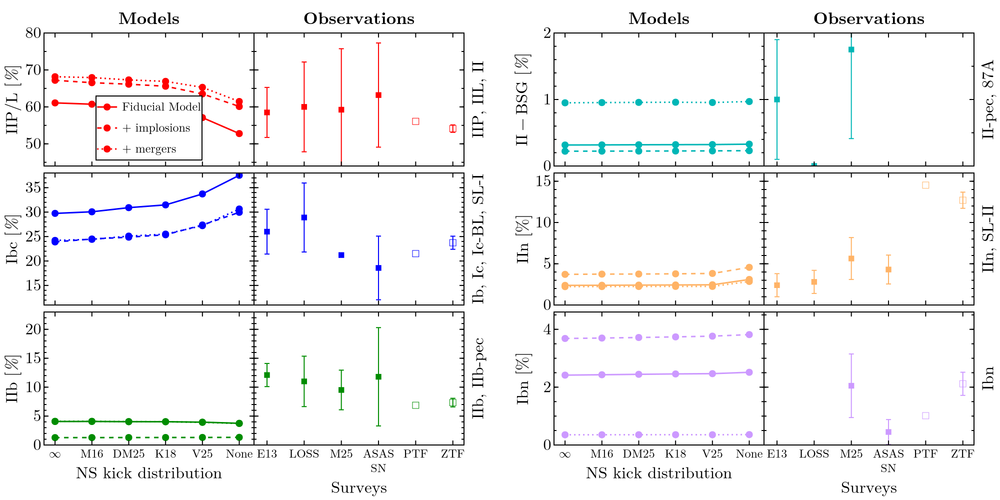

In [12]:
using DataFrames 

FIG = Figure(size=(1000, 500), figure_padding = 5)
labval(label,value) = Dict("val"=>value, "tlabel"=>label)
n=500

label_to_dict = Dict(
    "KICKS" => Dict("Inf" => labval(L"\infty",-1),
                          "MM_n$n" => labval("M16",0) ,
                        #   "Hobbs_n$n" => labval("H50",0),
                          "DM25_n$n" => labval("DM25", 1),
                          "COMBINE_n$n" => labval("K18", 2),
                          "Valli25_n$n" => labval("V25", 3),
                          "None" => labval("None", 4)
                          ))
label = "KICKS"

lc = Dict(1 => :black, 2 => :magenta, 3 => :cyan)
ls = Dict(1 => :solid, 2 => :dash, 3 => :dot)
sym_to_t = Dict(:IIP=>"IIP", :SN87A=>"87A", :IIb=>"IIb", :IIn=>"IIn", :Ibc=>"Ibc", :Ibn=>"Ibn")
lb = Dict(1 => "Fiducial Model", 2 => "+ implosions", 3 => "+ mergers")


obs_to_dict = Dict(
    # "Smartt" => labval("S", -2.15),
    "Eldridge"  => labval("E13", -2),
    # "LOSS_low"  => labval("L", -1.33),
    # "LOSS"      => labval("A\nLOSS", -1.15),
    "LOSS_high" => labval("LOSS",-1),
    "PTF"       => labval("PTF", 2),
    # "ZTF" => labval("1\n   ZTF", 0.),
    "ZTF2"      => labval("ZTF", 3),
    "Ma25"      => labval("M25", 0.),
    "ASASSN"   =>labval("ASAS\nSN", 1)
)

SN_FILE = CSV.read("../output/ECI.dat", DataFrame, delim=" ", ignorerepeated=true )
KICKS_list = ["Inf", "MM_n$n", "DM25_n$n", "COMBINE_n$n", "Valli25_n$n", "None"]

marker = :circle
markersize= 10

xticks = ( [ label_to_dict[label][lab]["val"]   for lab in keys(label_to_dict[label])]   ,  [ label_to_dict[label][lab]["tlabel"]   for lab in keys(label_to_dict[label])])
xticks_obs = ( [ obs_to_dict[lab]["val"]   for lab in keys(obs_to_dict)]   ,  [ obs_to_dict[lab]["tlabel"]   for lab in keys(obs_to_dict)])
grid = FIG[1,1] = GridLayout()


yticklabelsize=16.
ylabelsize=16.5
xticklabelsize = 12
xlabelsize = 16.5
yticklabelpad = 1.8
left_panels_L = 1:2
right_panels_L = 3:4
left_panels_R = 5:6
right_panels_R = 7:8

yticklabelspace = 10.
ylabelpadding = 10.

# ax_bh = plot_settings( grid[1,left_panels_L],
#                 xlabel = "",
#                 ylabel =  L"\mathrm{BH}/\mathrm{SN}  [%]",
#                 title = "", titlesize=30,
#                 xticks = xticks,
#                 yticks= 0:20:100,
#                 ymticks= 0:10:100,
#                 xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, 
#                 xticklabelsvisible=false, yticklabelpad=yticklabelpad, 
#                 ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
#                 xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax = Dict()
ax_obs = Dict()
ax["87A"] = plot_settings( grid[1,left_panels_R],
                xlabel = "",
                ylabel =  L"\mathrm{II-BSG} \ [%]",
                title = "Models", titlesize=17,
                xticks = xticks, 
                yticks= 0:1:100,
                yticklabelpad=yticklabelpad,
                ymticks= 0:.2:100,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,# yscale = log10, 
                xticklabelrotation = 0,xlabelvisible=false, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                xticklabelsvisible=false)
ax_obs["87A"] = plot_settings( grid[1,right_panels_R],
                xlabel =  "",
                ylabel =  "II-pec, 87A", yaxisposition=:right,
                title = "Observations", titlesize=17,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks= 0:1:100,
                yticklabelpad=yticklabelpad,
                ymticks= 0:.5:100,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0,xlabelvisible=false, 
                xticklabelsvisible=false)
ax["IIn"] = plot_settings( grid[2,left_panels_R],
                xlabel = " ",
                ylabel =  "IIn [%]",
                title = "", titlesize=30,
                xticks = xticks, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =(0.:5:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0,
                xlabelvisible=false,xticklabelsvisible=false )
ax_obs["IIn"] = plot_settings( grid[2,right_panels_R],
                xlabel = " ",
                ylabel =  "IIn, SL-II", yaxisposition=:right,
                title = "", titlesize=30,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks =(0.:5:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0,
                xlabelvisible=false,xticklabelsvisible=false)
ax["Ibn"] = plot_settings( grid[3,left_panels_R],
                xlabel = "NS kick distribution",
                ylabel =  "Ibn [%]",
                title = "", titlesize=30,
                xticks = xticks, 
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =(0:2:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0:.5:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0)
ax_obs["Ibn"] = plot_settings( grid[3,right_panels_R],
                xlabel = "Surveys",
                ylabel =  "Ibn", yaxisposition=:right,
                title = "", titlesize=30,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks =(0:2:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0:.5:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0)

ax["IIb"] = plot_settings( grid[3,left_panels_L],
                xlabel = "NS kick distribution",
                title = "", titlesize=30,
                xticks = xticks, 
                ylabel = L"\mathrm{IIb} \ [%]",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                yticks =(0:5:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, #yscale = log10, 
                xticklabelrotation = 0)
ax_obs["IIb"] = plot_settings( grid[3,right_panels_L],
                xlabel = "Surveys",
                ylabel =  "IIb, IIb-pec", yaxisposition=:right,
                title = "", titlesize=30,
                yticklabelsvisible=false, 
                xticks = xticks_obs,
                yticks =(0.:5:100),# ([1,10], [L"%$(t)" for t in [1,10]]), 
                yticklabelpad=yticklabelpad,
                ymticks=(0.:1:100),#union(.1:.1:1, 1:1:10, 10:10:100),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, #yscale = log10,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xticklabelrotation = 0)

ax["Ibc"] = plot_settings( grid[2,left_panels_L],
                xlabel = "",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                ylabel = L"\mathrm{Ibc} \ [%]",
                title = "", titlesize=30, xticks = xticks, yticklabelpad=yticklabelpad,
                ymticks=(0:1:100), 
                yticks = (0:5:100, [L"%$t" for t in 0:5:100]),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_obs["Ibc"] = plot_settings( grid[2,right_panels_L],
                xlabel = "",
                ylabel =  "Ib, Ic, Ic-BL, SL-I", yaxisposition=:right,
                xticks = xticks_obs,
                title = "", titlesize=30,
                ymticks=(0.:1:100), 
                yticklabelsvisible=false, yticklabelpad=yticklabelpad,
                yticks = (0:5:100, [L"%$t" for t in 0:5:100]),
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)

ax["IIP"] = plot_settings( grid[1,left_panels_L],
                xlabel = "",
                ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace,
                ylabel =  L"\mathrm{IIP/L} \ [%]",  
                title = "Models", titlesize=17,
                xticks = xticks, yticklabelpad=yticklabelpad,
                yticks = (0:10:100, [L"%$t" for t in 0:10:100]),
                ymticks=(0:5:100), 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xlabelvisible=false, xticklabelsvisible=false, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)
ax_obs["IIP"] = plot_settings( grid[1,right_panels_L],
                xlabel = "",
                ylabel =  "IIP, IIL, II", yaxisposition=:right,
                xticks = xticks_obs,
                title = "Observations", titlesize=17,
                yticklabelpad=yticklabelpad,
                ymticks=(0:5:100), 
                yticks = (0:10:100, [L"%$t" for t in 0:10:100]),
                yticklabelsvisible=false,xlabelvisible=false, xticklabelsvisible=false, 
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, 
                xlabelsize = xlabelsize, ylabelsize = ylabelsize)



alpha = 1
color_coding = Dict()
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["87A"] = RGBAf(0,182/255,182/255,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["IIn"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibn"] = RGBAf(204/255, 153/255,1 ,alpha) 


alpha = 1                
color_coding["1"]   = RGBAf(0/255,200/255,200/255,alpha)    
color_coding["2"]   = RGBAf(227/255, 255/255, 0,alpha)    
color_coding["M"]   = RGBAf(250/255,0,227/255 ,alpha)   
color_coding["S"]   = RGBAf(0.8, .8, .8,alpha) 


sne = ["IIP", "87A", "IIb", "Ibc", "IIn", "Ibn"]

idx=1
for  ME in [["X", "MM-S21"], ["X",  "PS20"], ["PABLO", "MM-S21"]]
    MER_CRIT =   ME[1]
    EXP_CRIT = ME[2]
    KICKS = KICKS_list
    fB  =      0.75

    
    SN_ix=[ ] 



    for kick in KICKS 

        for entry in range(1,length(SN_FILE.EXP_CRIT))
            SN_FILE.MER_CRIT[entry] != MER_CRIT && continue 
            SN_FILE.EXP_CRIT[entry] != EXP_CRIT && continue  
            SN_FILE.fB[entry] != fB && continue  
            SN_FILE.KICKS[entry] != kick && continue 


            push!(SN_ix, entry)
            
            

        end


    end


    
    print(SN_ix)
    x_og = [label_to_dict[label][SN_FILE[!, label][ix]]["val"] for ix in SN_ix ]
    print("\n", x_og)
    ix_og = SN_ix
    x = x_og[sortperm( x_og )]
    ix_n =  ix_og[sortperm( x_og )]
    print("\n", ix_n)

    SN2 = SN_ix
    ms = 20
     
    show_label = true
    for sn in sne
        scatterlines!(ax[sn], x, [SN_FILE[!, sn][ix] for ix in ix_n], 
                        color=color_coding[sn],  linestyle=ls[idx], marker = marker, markersize = markersize,
                        label = sn=="IIP" ? lb[idx] : nothing)
    end

    idx+=1
end







valpm(mu,sp,sm) = Dict("mu"=>mu, "ul"=>mu+sp, "ll"=>mu-sm, "s+"=>sp, "s-"=>sm, "s"=>(sm+sp)/2)
valpm(mu,s) = Dict("mu"=>mu, "ul"=>mu+s, "ll"=>mu-s, "s+"=>s, "s-"=>s, "s"=>s)
valpm(mu) = Dict("mu"=>mu, "ul"=>NaN, "ll"=>NaN, "s+"=>NaN, "s-"=>NaN, "s"=>NaN)
multpm(a,b) = Dict("mu"=>a["mu"]*b["mu"],  "s" => sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2), 
                   "ul"=>a["mu"]*b["mu"]  +  sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2), 
                   "ll"=>a["mu"]*b["mu"]  -  sqrt(b["mu"]^2*a["s"]^2+a["mu"]^2*b["s"]^2))



Perley2020_ZTF = Dict("label"=>"ZTF","volume_limited"=>false,
    "IIn"     => valpm(0.722 * 0.142 * 100 + (0.722 * 0.035 * 100)),
    #"SLSN-II" =>valpm( 0.722 * 0.035 * 100),  ^^^
    "Ibn"     => valpm(0.278 * 0.092 * 100),
    #"Ic-BL"   =>valpm( 0.278 * 0.195 * 100),   vvv
    "Ibc"     => valpm(0.278 * 0.587 * 100 + (0.278 * 0.195 * 100) + (0.278 * 0.126 * 100)),
    #"SLSN-I"  =>valpm( 0.278 * 0.126 * 100),                                ^^^
    "IIb"     => valpm(0.722 * 0.066 * 100), 
    "IIP"     => valpm(0.722 * 0.757 * 100),
)


Schulze2021_PTF = Dict("label"=>"PTF","volume_limited"=>false,
    "IIP"     => valpm(       498/888*100),
    "IIb"     => valpm(        61/888*100),
    "IIn"     => valpm(       111/888*100+(16+ 1+ 1)/888*100),
    #"SLSN-II" =>valpm( (16+ 1+ 1)/888*100), ^^^
    #"Ic-BL"   =>valpm(         36/888*100),             vvv
    "Ibc"     => valpm((46+12+60)/888*100 + 37/888*100 +36/888*100),
    #"SLSN-I"  =>valpm(         37/888*100), ^^^
    "Ibn"     => valpm(         9/888*100),
)


Hinds25 = Dict("label"=>"ZTF2", "volume_limited"=>false,
    "IIn"     => valpm((145+23)/(981+342)*100, sqrt(sqrt(145)^2+sqrt(23)^2)/(981+342)*100), #includes SL-II
    "Ibn"     => valpm((27+1)/(981+342)*100, sqrt(sqrt(27)^2+sqrt(1)^2)/(981+342)*100), #includes 1 Icn
    "Ibc"     => valpm((223+45+46)/(981+342)*100, sqrt(sqrt(223)^2+sqrt(45)^2+sqrt(46)^2)/(981+342)*100), #includes Ic-BL and SL-I
    "IIb"     => valpm((97)/(981+342)*100, sqrt(97)/(981+342)*100), 
    "IIP"      => valpm((716)/(981+342)*100, sqrt(176)/(981+342)*100)
)

Eldridge13 =  Dict("label"=>"Eldridge","volume_limited"=>true,
    "IIP"      =>  valpm(55.5+3.0, sqrt(6.6^ 2 + 1.5^ 2)),
    "IIb"     =>  valpm(12.1, 2.0),
    "IIn"     =>  valpm(2.4, 1.4),
    "Ibc"     =>  valpm(9.0+17.0, sqrt(2.7^2+3.7^2)),
    "87A"     =>  valpm(1, 0.9)
)

Smartt2009 =  Dict("label"=>"Smartt","volume_limited"=>true,
    "IIP"      =>  valpm(58.7+2.7, sqrt(8.0^ 2 + 1.7^ 2)),
    "IIb"     =>  valpm(5.4, 2.7),
    "IIn"     =>  valpm(3.8, 2.0),
    "Ibc"     =>  valpm(19.6+9.8, sqrt(3.3^2+4.5^2)),
)

Graur2017_LOSS_lowmassGal = Dict("label"=>"LOSS_low","volume_limited"=>true,
    "IIP"     => valpm(60, sqrt(15^2), sqrt(14^2)),
    "87A"    => valpm(8,5,5),
    "IIn"    => valpm(7, 5, 5),
    "IIb"    => valpm(11+1.5, sqrt(6^2+1.5^2), sqrt(5^2+1.5^2)),
    "Ibc"    => valpm(7+0+1+3, sqrt(4^2+4^2+1^2+3^2), sqrt(3^2+0^21^2+3^2)),
)
Graur2017_LOSS_highmassGal = Dict("label"=>"LOSS_high","volume_limited"=>true,
    "IIP"     => valpm(60+0, sqrt(10^2 +2.5^2), sqrt(14^2+0^2)),
    "87A"     => valpm(0,0),
    "IIn"    => valpm(2.8,  1.4, 1.4),
    "IIb"    => valpm(11+0, sqrt(4^2+2.5^2), sqrt(4^2+0^2)),
    "Ibc"    => valpm(22+1.4+2.1+3.4, sqrt(7^2+1.4^2+1.4^2+2^2), sqrt(6^2+1.4^2+1.4^2+1.8^2)),
)
Shivvers_II_f = valpm(0.696, 0.060, 0.060)
Shivvers_I_f  = valpm(0.304, 0.050, 0.049)
Shivvers2017_LOSS = Dict("label"=>"LOSS","volume_limited"=>true,
    "IIn"    => multpm( valpm(6.7, 3.0, 2.9), Shivvers_II_f),
    "Ibc"    => multpm( valpm(35.6+21.5+3.2+3.7, sqrt(11.4^2+8.6^2+3.1^2+3.1^2), sqrt(11.4^2+8.6^2+3.2^2+3.7^2)), Shivvers_I_f),
    "IIb"    => multpm( valpm(34+2.0, sqrt(11.1^2+1.5^2), sqrt(11.1^2+2.0^2)), Shivvers_I_f),
    "IIP"     => multpm( valpm(89.1, 10.9, 10.9), Shivvers_II_f),
    "87A"     => multpm( valpm(4.5, 2.4, 2.7), Shivvers_II_f)
)
Ma25_mixed_II = valpm(53.3/(53.3+16.3+0.4), 9.5/(53.3+16.3+0.4), 18.7/(53.3+16.3+0.4))
Ma25_mixed_I  =  valpm(16.3/(53.3+16.3+0.4), 3.7/(53.3+16.3+0.4), 7.4/(53.3+16.3+0.4))

Ma25_mixed_vollim = Dict("label"=>"Ma25","volume_limited"=>true,
    "IIn"    => multpm( valpm(7.4, 2.6, 2.8), Ma25_mixed_II),
    "IIP"     => multpm( valpm(68.5+8.5+0.8, sqrt(4.3^2+3^2+1.3^2), sqrt(7.5^2+3.3^2+0.8^2)), Ma25_mixed_II),
    "IIb"    => multpm( valpm(12.5, 2.6, 3.5) , Ma25_mixed_II),
    "87A"  => multpm( valpm(2.3, 2.1, 1.2) , Ma25_mixed_II),
    "Ibc"    => multpm( valpm(20.6+39+18+13.5, sqrt(6.5^2+10.2^2+6.8^2+7.1^2), sqrt(10.3^2+8.2^2_9.1^2+7.3^2)), Ma25_mixed_I),
    "Ibn"    => multpm( valpm(8.8, 2.5, 4.8), Ma25_mixed_I)
)

ASASSN = Dict("label"=>"ASASSN","volume_limited"=>true,
    "IIn"    => valpm(4.3, 1.9, 1.6),
    "IIP"     =>  valpm(63.2, 14.4, 13.8),
    "IIb"    => valpm(11.8, 9.9, 7.1),
    "Ibc"    => valpm(11.8+5.8+0.47+0.51, 
                      sqrt(5.2^2+4.4^2+.48^2+.55^2),
                      sqrt(4.9^2+3.7^2+.46^2+.32^2)),
    "Ibn"    => valpm(.45,.44,.42)
)



errorbar_linewidth=1
whiskerwidth=5

for sample in [ Eldridge13, Graur2017_LOSS_highmassGal, Ma25_mixed_vollim, ASASSN, Hinds25, Schulze2021_PTF] 
    marker = sample["volume_limited"] ? :rect : '□'
    for sn in sne
        if sn in keys(sample)
            x = [obs_to_dict[sample["label"]]["val"]]
            y = [sample[sn]["mu"]]
            scatter!(ax_obs[sn],  x, y, color = color_coding[sn], marker = marker)
            "s" in keys(sample[sn]) && errorbars!( ax_obs[sn], x, y, [sample[sn]["s"]], [sample[sn]["s"]], color = color_coding[sn], linewidth = errorbar_linewidth, whiskerwidth=whiskerwidth)
        end
    end
end


ls=:solid
axislegend(ax["IIP"], nbanks=1, position=:cb, rowgap =1, colgap =4,titlesize=12, labelsize=12, framevisible = true,
            showtitle=true, titleposition=:left, padding=(1,1,1,1))



for axis in [ax,ax_obs]
    ylims!(axis["IIn"], 0. ,16)
    ylims!(axis["Ibn"], 0. ,4.6)
    ylims!(axis["87A"], 0. ,2.)
    ylims!(axis["IIb"], 0., 23)
    ylims!(axis["Ibc"], 11, 38)
    ylims!(axis["IIP"], 44, 80)
end
for sn in sne
    xlims!(ax[sn], -1.3,4.4)
    xlims!(ax_obs[sn], -2.35,3.3)
end
rowgap!(grid, 7)
colgap!(grid, 0)
colgap!(grid, 4, 30)


directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/"

outfilename = @sprintf("SN_stats_new_ECI.pdf")
save(directory*outfilename, FIG)    # 1600 × 1200 px png


FIG



# Histograms 

In [98]:
Revise.revise()

In [3]:
using POPSYNTH
will_eci_occur_unbound = (SN_DATA["ECI_manual"]["tot"]) .&& (SN_DATA["postkick_orbit"]["tot"] .== :unbound)
will_eci_occur_bound   = (SN_DATA["ECI_manual"]["tot"]) .&& (SN_DATA["postkick_orbit"]["tot"] .== :bound  )
will_eci_occur_dc      = (SN_DATA["ECI_manual"]["tot"]) .&& (SN_DATA["postkick_orbit"]["tot"] .== :direct_collision  )
POPSYNTH.report_stats(SN_DATA, "when_periastron", "tot", :Ibc, filter=will_eci_occur_unbound, 
             print2screen = true, newline = false, 
             format_str = "%4.1f", unit = (POPSYNTH.day/POPSYNTH.yr, "day"),  n_peaks=1, multip1_threshold= [91.5], 
             multip_percentiles=0:5:100)
POPSYNTH.report_stats(SN_DATA, "when_periastron", "tot", :Ibc, filter=will_eci_occur_bound, 
             print2screen = true, newline = false, 
             format_str = "%4.1f", unit = (POPSYNTH.day/POPSYNTH.yr, "day"),  n_peaks=1, multip1_threshold= [91.5], 
             multip_percentiles=0:5:100)
POPSYNTH.report_stats(SN_DATA, "when_periastron", "tot", :Ibc, filter=will_eci_occur_dc, 
             print2screen = true, newline = false, 
             format_str = "%4.1f", unit = (POPSYNTH.day/POPSYNTH.yr, "day"),  n_peaks=1, multip1_threshold= [91.5], 
             multip_percentiles=0:5:100)


when_periastron -  0.0<10.3[+29.0-10.2]<618.0 [  day]- 
Perc. Analysis
   0    5   10   15   20   25   30   35   40   45   50   55   60   65   70 
  75   80   85   90   95  100 
 0.0  0.1  0.3  0.5  0.7  0.9  1.2  1.6  2.0  2.4  3.1  3.9  5.1  6.5  8.2 
10.9 14.4 19.0 25.6 39.3 618.0 
when_periastron -  0.0<1082.7[+-679.1-1082.1]<309950703.0 [  day]- 
Perc. Analysis
   0    5   10   15   20   25   30   35   40   45   50   55   60   65   70 
  75   80   85   90   95  100 
 0.0  0.5  0.8  1.0  1.2  1.4  1.7  2.2  2.6  3.3  4.6  6.0  7.7 11.3 19.4 
30.8 49.2 82.4 155.3 403.5 309950703.0 
when_periastron -  0.4< 7.8[+32.9- 7.2]<118.7 [  day]- 
Perc. Analysis
   0    5   10   15   20   25   30   35   40   45   50   55   60   65   70 
  75   80   85   90   95  100 
 0.4  0.6  0.7  0.8  0.9  1.0  1.1  1.2  1.2  1.4  1.6  1.9  2.1  2.9  3.6 
 4.6  5.8 11.2 24.2 40.7 118.7 


1-element Vector{Any}:
 [7.7746098822925305, 32.94202854368867, 7.153760553161572, 1.6394561146907192]

In [ ]:
report_stats(SN_DATA, "Mf",  "1", "IIP", print2screen = true, format_str="%5.2f", newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 
report_stats(SN_DATA, "Mhe",  "1", "IIP", print2screen = true, format_str="%5.2f", newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 
report_stats(SN_DATA, "Menv",  "1", "IIP", print2screen = true, format_str="%5.2f", newline = false, unit = (1, "Msun"),  multip1_threshold= [0.0]) 


y1  = SN_DATA["Menv"]["1-MT"][get_idx("1-MT", "IIP")]
x1  = SN_DATA["Mhe"]["1-MT"][get_idx("1-MT", "IIP")]

y2  = SN_DATA["Menv"]["2-MT"][get_idx("2-MT", "IIP")]
x2  = SN_DATA["Mhe"]["2-MT"][get_idx("2-MT", "IIP")]
yM  = SN_DATA["Menv"]["M"][get_idx("M", "IIP")]
xM  = SN_DATA["Mhe"]["M"][get_idx("M", "IIP")]
yS  = SN_DATA["Menv"]["S"][get_idx("S", "IIP")]
xS  = SN_DATA["Mhe"]["S"][get_idx("S", "IIP")]



alpha = 0.333
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]  = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["II-i-cont"]  = RGBAf(1,179/255,102/255 , 1) 
color_coding["Ibc-i-cont"] = RGBAf(204/255, 153/255,  1) 
color_coding["BH"]    = RGBAf(0.15, 0.15, 0.15 ,alpha) 
hatcher2 = make_hatch_pattern(size=100, spacing=9, thickness=1, style=:backslash, line_color=color_coding["II-i-cont"], bg_color=RGBAf(0,0,0,0))
color_coding["II-i2"] = Pattern(hatcher2)
color_coding["II-i2"] =  RGBAf(1,179/255,102/255 , 0.66) 

function run_histogram(ax, prg, ttp, what, bins, width; color=:gray, colorcont=:black, datascale = identity, keep_log = false, direction = :y, strokewidth=1)
    length(get_idx(prg, ttp)) == 0 && return 0

    pdf = sum(  sum([sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes]) for prg in ["1", "2", "M", "S"] )
    pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])
    special_what = ["f_M", "E_int"]
    data = nothing 
    if ! (what in special_what )
        data = datascale.(SN_DATA[what][prg][get_idx(prg,ttp)])
    elseif what in special_what || occursin("f_M", what)
        theta = (length(what) > 3 && what[1:3] == "f_M") ?  what[4:end] : 90  
        sintheta = sin(theta/360*2*pi)
        f_m = sintheta .* SN_DATA["dM_C"][prg][get_idx(prg,ttp)] ./(SN_DATA["Mej"][prg][get_idx(prg,ttp)].*sintheta .+ SN_DATA["dM_C"][prg][get_idx(prg,ttp)])
        if what == "E_int"
            data =  datascale.(SN_DATA["E_exp"][prg][get_idx(prg,ttp)]   .*   f_m)
        else 
            data = datascale.(f_m)
        end 
    else 
        throw(ErrorException("Incorrect 'what' argument in run_histogram"))
    end 

    dataweights = weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]/pdf)

    reverse_f(x) =  (datascale == log10 && ! keep_log) ? 10. .^(x) : identity(x)
    x_bar = [ reverse_f(bins[ix]+width/2)  for ix in range(1,length(bins)-1)]  
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]

    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 

    barplot!(ax, x_bar , 
                 y_bar, 
                 color =   color,
                 strokewidth =  strokewidth,
                 strokecolor = colorcont,
                 width= (datascale == log10) ? [ reverse_f(bins[ix]+width/2) - reverse_f(bins[ix]-width/2)  for ix in range(1,length(bins)-1)]     : width*1.1,
                 direction = direction)
end 

function run_histogram_filtered(ax, prg, ttp, what, bins, width; filter = true, color=:gray, colorcont=:black, datascale = identity, keep_log = false, direction = :y, to_plot = true, strokewidth=1)
    length(get_idx(prg, ttp)) == 0 && return 0
    @printf("Tot of elements %d - filter lenght %d \n", length(get_idx(prg, ttp)), length(filter))

    pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])

    extrafilter = [] 
    if length(filter) > 1
        for ix in range(1,length(get_idx(prg, ttp)))
            filter[ix] && push!(extrafilter, get_idx(prg, ttp)[ix])
        end
    else
        extrafilter = get_idx(prg, ttp)
    end
    @printf("extrafilter got %d elements.\n", length(extrafilter))
    # (length(extrafilter) != length(get_idx(prg, ttp))) && throw(ErrorException("Filter and Data have different sizes!"))
    
    special_what = ["f_M", "E_int"]
    data = nothing 
    if ! (what in special_what || occursin("f_M", what) )
        data = datascale.(SN_DATA[what][prg][extrafilter])
    elseif what in special_what || occursin("f_M", what)
        theta = (length(what) > 3 && what[1:3] == "f_M") ?  parse(Float64, what[4:end]) : 90  
        sintheta = sin(theta/360*2*pi)
        f_m = sintheta .* SN_DATA["dM_C"][prg][extrafilter] ./(SN_DATA["Mej"][prg][extrafilter].*sintheta .+ SN_DATA["dM_C"][prg][extrafilter])
        if what == "E_int"
            data =  datascale.(SN_DATA["E_exp"][prg][extrafilter]   .*   f_m)
        else 
            data = datascale.(f_m)
        end 
    else 
        throw(ErrorException("Incorrect 'what' argument in run_histogram"))
    end 

    dataweights = weights(SN_DATA["pdf"][prg][extrafilter]/pdf)
 
    reverse_f(x) = ( datascale == log10 && ! keep_log) ? 10. .^(x) : identity(x)
    x_bar = [ reverse_f(bins[ix]+width/2)  for ix in range(1,length(bins)-1)]  
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]

    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 

     to_plot && barplot!(ax, x_bar , 
                 y_bar, 
                 color =   color,
                 strokewidth =  strokewidth,
                 strokecolor = colorcont,
                 width= (datascale == log10) ? [ reverse_f(bins[ix]+width/2) - reverse_f(bins[ix]-width/2)  for ix in range(1,length(bins)-1)]     : width*1.1,
                 direction = direction)

    return x_bar, y_bar
end 

function run_histogram(ax, data_raw, pdf_data, bins, width; color=:gray, colorcont=:black, datascale = identity, keep_log = false, direction = :y, to_plot = true, strokewidth=1, norm = true)
    (length(data_raw) == 0)           && return 0
    (length(data_raw) != length(pdf_data)) && throw(ErrorException("Data and pdf are not the same size"))

    data = nothing 
    normalize = typeof(norm) == Bool ? (norm ? sum(pdf_data) : 1) : norm 
    data = datascale.(data_raw)
    dataweights = weights(pdf_data / normalize)

    reverse_f(x) =  (datascale == log10 && !keep_log ) ? 10. .^(x) : identity(x)
    x_bar = [ reverse_f(bins[ix]+width/2)  for ix in range(1,length(bins)-1)]  
    hist1 = fit(Histogram,  data, dataweights, bins)  

    y_bar = Float64[]

    for ix in range(1,length(bins)-1)
        push!(y_bar,  hist1.weights[ix]) 
    end 

    to_plot && barplot!(ax, x_bar , 
                 y_bar, 
                 color =   color,
                 strokewidth =  strokewidth,
                 strokecolor = colorcont,
                 width= (datascale == log10) ? [ reverse_f(bins[ix]+width/2) - reverse_f(bins[ix]-width/2)  for ix in range(1,length(bins)-1)]     : width*1.1,
                 direction = direction)
    return x_bar, y_bar

end 


inch = 96
FIGURE = Figure(size=(400,400), figure_padding = 5, px_per_unit = 600/inch)

mticks = union(0.001:0.001:0.01, 0.01:0.01:0.1, 0.1:0.1:1, 1:1:10, 10:10:100)


# grid = FIGURE[1:5, 1:5] = GridLayout()
# grid_left = 1:3
# grid_right = 4:5 
# grid_top  = 1:2 
# grid_bottom = 3:5
grid = FIGURE[1:5, 1:5] = GridLayout()
grid_left = 1:3
grid_right = 4
grid_top  = 1 
grid_bottom = 2:4
ax = plot_settings(grid[grid_bottom, grid_left]; 
            xlabel=L"M_\mathrm{He-core} \ [M_\odot]",
            ylabel=L" M_\mathrm{env} \ [M_\odot]", 
            title =" ", xscale = log10, yscale = log10, 
            xticks=([0.01,0.1,1,10], ["0.01", "0.1", "1", "10"]),
            yticks=([0.001,0.01,0.1,1,10], ["0.001","0.01", "0.1", "1", "10"]),
            xmticks=mticks, ymticks=mticks
            )
ax_dM = plot_settings(grid[grid_bottom, grid_right]; 
            xlabel=L"N \ [\mathrm{norm}]", xticks = 0:0.2:1,
            ylabel=L"M_\mathrm{He-core} \ [M_\odot]", ylabelvisible=false, yticklabelsvisible=false,
            title =" ", yscale = log10, ymticks=mticks,
            )

ax_Mend = plot_settings(grid[grid_top, grid_left]; 
            xlabel=L"M_\mathrm{env} \ [M_\odot]",xlabelvisible=false, xticklabelsvisible=false,
            ylabel=L"N \ [\mathrm{norm}]", xmticks=mticks,
            title =" ", xscale = log10 
            )

scatter!(ax, x1, y1,   color=:teal,    marker = :rect, markersize = 5)
scatter!(ax, x2, y2,   color=:magenta, marker = :rect, markersize = 5)
scatter!(ax, xM, yM,   color=:gold,    marker = :rect, markersize = 5)
scatter!(ax, xS, yS,   color=:black,   marker = :rect, markersize = 5)
# scatter!(ax, (x1 .- dx1)[q1 .>= 0.7 .&& case .== "C"],y1[q1 .>= 0.7 .&& case .== "C"], color=color_coding["II-i"], marker = :rect,   )
# scatter!(ax, (x1 .- dx1)[q1 .<  0.7 .&& case .== "C"],y1[q1 .<  0.7 .&& case .== "C"], color=RGBAf(0,0.5,1,0.3), marker = :rect, strokewidth=2, strokecolor=color_coding["II-i"])
# scatter!(ax, [1e-99], [1e-99], color=color_coding["II-i-cont"], marker = '□', label = "Case\nB+C")
# scatter!(ax, [1e-99], [1e-99], color=color_coding["II-i-cont"], marker = :rect, label = "Case C\n(stable)")
# scatter!(ax, [1e-99], [1e-99],  color=RGBAf(0,0.5,1,0.8), marker = :rect, strokewidth=2, strokecolor=color_coding["II-i-cont"], label = "Case C\n(unstable)")

# axislegend(ax,  position=:lb, 
#     nbanks=2, titleposition=:left, framealpha=0.5, rowgap =3, colgap =3, labelsize=10)


obs_hatch = make_hatch_pattern(size=100, spacing=9, thickness=0.01, style=:backslash, line_color=RGBAf(0.3,0.3,0.3,.5), bg_color=RGBAf(0,0,0,0))
obs_col= Pattern(obs_hatch)

w = 0.10
run_histogram_filtered(ax_dM, "tot", "IIP", "Menv",  -4:w:2, w*1.1; color=RGBAf(0,0.2,1,0.3),            colorcont=:white,                    datascale = log10, direction = :x)
# run_histogram(ax_dM, (f_obs_IIn.Mcsm), f_obs_IIn.Mcsm .* 0 .+ 1, -4:w:2, w; color=Pattern(obs_hatch), colorcont=:gray, datascale = log10, direction = :x)

w = 0.10
scale = log10
xb, yb  = run_histogram_filtered(ax_Mend, "tot", "IIP", "Mhe",  -3.05:w:2, w;    color=RGBAf(0,0.2,1,0.3),    colorcont=:white, datascale = scale, direction = :y, to_plot=false)
# _,  yb2  = run_histogram_filtered(ax_Mend, "1", "II-i", "Mej",  -3.05:w:2, w; filter = f_stableC,   color=color_coding["II-i"],  colorcont=:white, datascale = scale, direction = :y, to_plot=false)
# _,  yb3  = run_histogram_filtered(ax_Mend, "1", "II-i", "Mej",  -3.05:w:2, w; filter = f_BC,        color=color_coding["II-i2"], colorcont=:white, datascale = scale, direction = :y, to_plot=false)
stacked_barplot!(ax_Mend, (xb), [yb], 
                    width=w*0.8, colors = [ :red ])
run_histogram(ax_Mend, "tot", "IIP", "Mhe",  -3.05:w:2, w; color=RGBAf(0,0,0,0) , colorcont=:red,datascale = scale, direction = :y, strokewidth=2)



xmin, xmax = 1.5, 50
ymin, ymax = 1, 50
ylims!(ax, ymin, ymax)
ylims!(ax_dM, ymin, ymax)
xlims!(ax_dM, 0, nothing)
xlims!(ax, xmin, xmax)
xlims!(ax_Mend, xmin, xmax)
ylims!(ax_Mend, 0, nothing)
# xlims!(ax_fm, -2.5, 0.2)
# ylims!(ax_fm, 0, nothing)



colgap!(grid, 5)
rowgap!(grid, 5)

colgap!(FIGURE.layout, 50)  # separates C from D horizontally
rowgap!(FIGURE.layout, 50)  # separates C from D horizontally

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("stats_II.pdf")
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png



FIGURE


UndefVarError: UndefVarError: `report_stats` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [64]:
for ix  in range(1,length(n_passages ))
    if ECI_RLOF[ix] && n_passages[ix] == 0
        @printf("ECI but no passages? idx %d \n", ix)
        @printf("n_passages %d - ECI %s \n", n_passages[ix], ECI_RLOF[ix])
        @printf("P_postSN %8.3e \n", P_postSN[ix])
        @printf("tau_periastron %8.3e - tau_ECI %8.3e \n", tau_periastron[ix], tau_ECI[ix])
        @printf("SN = %s - prog = %s \n", SNe[ix], prgs[ix])
        n = (tau_ECI[ix] - tau_periastron[ix])/P_postSN[ix]
        @printf("n = %8.3e \n", n)
        throw(ErrorException("ECI but no passages?"))
    end
end

# Data analysis


In [8]:
Revise.revise()


prgs, pdfs, sn1, SNe = POPSYNTH.seqdata_MODELS("SN", mod_names, MODELS, norm_pdf=total_SNe)
pdfs *= 100 
RLOF_ECI = POPSYNTH.seqdata_MODELS("ECI?_ogata", mod_names, MODELS, full_output=false)
tau_ECI = POPSYNTH.seqdata_MODELS("tau_ECI", mod_names, MODELS, full_output=false)/POPSYNTH.day
tau_periastron = POPSYNTH.seqdata_MODELS("when_will_periastron_occur", mod_names, MODELS, full_output=false)/POPSYNTH.day
P_postSN = POPSYNTH.seqdata_MODELS("P", mod_names, MODELS, full_output=false)/POPSYNTH.day
post_SN_orbit = POPSYNTH.seqdata_MODELS("orbit", mod_names, MODELS, full_output=false)
eccentricity = POPSYNTH.seqdata_MODELS("e", mod_names, MODELS, full_output=false)
v_kick = POPSYNTH.seqdata_MODELS("1st_kick", mod_names, MODELS, full_output=false)
v_orb_1 = POPSYNTH.seqdata_MODELS("pre_v1", mod_names, MODELS, full_output=false)
first_CO = POPSYNTH.seqdata_MODELS("1stCO", mod_names, MODELS, full_output=false)
mod = POPSYNTH.seqdata_MODELS("mod", mod_names, MODELS, full_output=false)
n_passages = [post_SN_orbit[i] == :bound ? (floor((tau_ECI[i] - tau_periastron[i])/P_postSN[i]) + 1) : 1   for i in range(1,length(pdfs))]
E_exp = POPSYNTH.seqdata_MODELS("E_exp", mod_names, MODELS, full_output=false)
a_pre = POPSYNTH.seqdata_MODELS("pre_a", mod_names, MODELS, full_output=false)
Mend = POPSYNTH.seqdata_MODELS("M_end", mod_names, MODELS, full_output=false)
M_b_ns = POPSYNTH.seqdata_MODELS("M_remnant_b", mod_names, MODELS, full_output=false)
M_g_ns = POPSYNTH.seqdata_MODELS("M_remnant_g", mod_names, MODELS, full_output=false)

mods = [isnan(x) ? 1 : Int(x) for x in mod]
M1hedep = f_MW.M_1_end_BURN_He_1[mods]
M1 = 10 .^ f_MW.logM[mods]
Pi = 10 .^ f_MW.logP[mods]
qi = f_MW.q[mods]
M2 = f_MW.M_2_end_1[mods]
R2 = f_MW.R_2_end_1[mods]
Y1 = f_MW.Ys_1_end_1[mods]
# Y1 = f_MW.Ys_1_end_1[mods]
Eheat = @. POPSYNTH.ECI.Eheat(E_exp, R2, a_pre)
Omegaeff = @. POPSYNTH.ECI.Omega_eff(R2, a_pre)
Rmax = @.  10 ^ POPSYNTH.ECI.logRmax(Eheat)
Mej = Mend .- M_b_ns
tot_he = f_MW.M_tot_he_1_end_1[mods] 
avg_he = (tot_he .- ( M1hedep .- Mend ))./ Mej 
Lmax = (POPSYNTH.ECI.Lmax_analytic.(M2))
Teff_min =  @. ( Lmax/(4*π*POPSYNTH.sigma_boltz*(Rmax*Rsun)^2) ) .^ (1/4)

for out in [:WD, :X, :IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn]
    @printf("%5s = %.2f%%\n", out, sum(pdfs[SNe .== out]))
end
ccsne = (SNe .== :IIP) .|| (SNe .== :Ibc) .|| (SNe .== :IIb) .|| (SNe .== :IIn) .|| (SNe .== :Ibn) .|| (SNe .== :SN87A)
sn_tot= sum(pdfs[ccsne])

select_sne = sn1 .&& ccsne
ECI = RLOF_ECI .&& select_sne 

# for out in [:WD, :X, :IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn]
#     @printf("%5s = %.2f%%\n", out, sum(pdfs[SNe .== out])*100/sn_tot)
# end



@printf("%5s = %.2f%%\n\n", "tot", sn_tot )

for prg in ["MT-1", "NI-1", "MT-2", "NI-2", "M", "NI-S"]
    @printf("%5s = %.2f%%\n", prg, sum(pdfs[(prgs .== prg) .&& ccsne]))
end
boolprg = (prgs .== "MT-1") .|| (prgs .== "NI-1") .|| (prgs .== "MT-2") .|| (prgs .== "NI-2") .|| (prgs .== "M") .|| (prgs .== "NI-S")
(false in boolprg) && throw(ErrorException)



Getting data for SN...
Getting data for ECI?_ogata...
Getting data for tau_ECI...
Getting data for when_will_periastron_occur...
Getting data for P...
Getting data for orbit...
Getting data for e...
Getting data for 1st_kick...
Getting data for pre_v1...
Getting data for 1stCO...
Getting data for mod...
Getting data for E_exp...
Getting data for pre_a...
Getting data for M_end...
Getting data for M_remnant_b...
Getting data for M_remnant_g...
   WD = 14.99%
    X = 0.11%
  IIP = 57.11%
SN87A = 0.32%
  IIb = 3.95%
  Ibc = 33.76%
  Ibn = 2.42%
  IIn = 2.44%
  tot = 100.00%

 MT-1 = 23.37%
 NI-1 = 7.68%
 MT-2 = 14.68%
 NI-2 = 3.28%
    M = 30.20%
 NI-S = 20.79%


false

In [103]:
Set(prgs)

Set{String} with 6 elements:
  "NI-1"
  "NI-S"
  "MT-2"
  "M"
  "MT-1"
  "NI-2"

In [49]:
# itp_Mej = POPSYNTH.interpolator(10. .^ POPSYNTH.exp_corr_S["S21"].logM[1:10], (POPSYNTH.exp_corr_S["S21"].M_end-POPSYNTH.exp_corr_S["S21"].M_rem_b)[1:10],   extrapolation=:flat)
# M_max = POPSYNTH.seqdata_MODELS("Mmax", mod_names, MODELS, full_output=false)
Mhe = POPSYNTH.seqdata_MODELS("M_he", mod_names, MODELS, full_output=false)
Mmax = POPSYNTH.seqdata_MODELS("Mmax", mod_names, MODELS, full_output=false)

fff = (SNe .== :IIP) 

# sum(pdfs[fff])/sum(pdfs[SNe .== :IIP])*100
# itp_Mej(12)
for logm in 0.8:0.005:1.5
    m = 10 .^ logm
    Menv = POPSYNTH.interpol_single_Mmax["M_env_end"](m)
    Mhe  = POPSYNTH.interpol_single_Mmax["M_hecore_end"](m)
    Xc  = POPSYNTH.interpol_single_Mmax["X_C"](m)
    Mco  = POPSYNTH.interpol_single_Mmax["M_cocore_end"](m)
    CC = POPSYNTH.does_it_CC(Mhe=Mhe, Mco=Mco)
    !CC && continue
    explosion, _ = POPSYNTH.will_it_explode(Mhe=Mhe, Mco=Mco, Xc=Xc, Mmax=m, when="end", criterion = EXP_CRIT, reference_grid = "MW-ZAMS") 
    !explosion && continue 
    @printf("%5.3f -> %5.2f-%5.2f\n", m , Mhe, Menv)
end
# Menv = Mend .- Mhe 
# fff = SNe .== :IIP .&& Mmax .< 20 # .&& prgs .== "NI-S" 
# www = Weights(pdfs[fff])
# vals = Menv[fff]
# for q in 0:0.05:1
#     qt = quantile(vals, www, q)
#     @printf("%.2f - %5.2f\n", q, qt)
# end

Getting data for M_he...
Getting data for Mmax...
9.550 ->  2.53- 6.39
9.661 ->  2.58- 6.43
9.772 ->  2.62- 6.46
9.886 ->  2.67- 6.50
10.000 ->  2.72- 6.53
10.116 ->  2.76- 6.56
10.233 ->  2.81- 6.60
10.351 ->  2.86- 6.63
10.471 ->  2.92- 6.66
10.593 ->  2.97- 6.69
10.715 ->  3.02- 6.72
10.839 ->  3.08- 6.76
10.965 ->  3.13- 6.79
11.092 ->  3.20- 6.81
11.220 ->  3.26- 6.83
11.350 ->  3.32- 6.85
11.482 ->  3.39- 6.87
11.614 ->  3.45- 6.88
11.749 ->  3.52- 6.90
11.885 ->  3.58- 6.92
12.023 ->  3.65- 6.93
12.162 ->  3.72- 6.93
12.303 ->  3.80- 6.93
12.445 ->  3.87- 6.92
12.589 ->  3.95- 6.92
12.735 ->  4.02- 6.92
12.882 ->  4.10- 6.91
13.032 ->  4.18- 6.90
13.183 ->  4.26- 6.89
13.335 ->  4.33- 6.88
13.490 ->  4.41- 6.87
13.646 ->  4.49- 6.85
13.804 ->  4.58- 6.83
13.964 ->  4.66- 6.81
14.125 ->  4.74- 6.78
14.289 ->  4.83- 6.76
14.454 ->  4.91- 6.74
14.622 ->  5.00- 6.70
14.791 ->  5.09- 6.66
14.962 ->  5.18- 6.64
15.136 ->  5.27- 6.61
15.311 ->  5.35- 6.60
15.488 ->  5.43- 6.58
15.668 -

In [33]:
Mhe

13.75897

In [ ]:

format_str = "%5.1f"
multip_percentiles = [0, 2.5, 5, 10, 25, 50, 75, 90, 95, 97.5, 100]
selection = @. sn1 && ccsne && !(prgs == "M" || prgs == "NI-S")  

POPSYNTH.report_stats(v_kick[selection], pdfs[selection], label = "v_kick", print2screen=true, unit = (1, "km/s"), multip_percentiles=multip_percentiles, format_str=format_str)    
POPSYNTH.report_stats(v_orb_1[selection], pdfs[selection], label = "v_orb", print2screen=true, unit = (1, "km/s"), multip_percentiles=multip_percentiles, format_str=format_str)   
POPSYNTH.report_stats((v_kick ./ v_orb_1)[selection], pdfs[selection], label = "v_kick/v_orb_1", print2screen=true,unit = (1, "km/s"), multip_percentiles=multip_percentiles, format_str=format_str)

for i in range(1,length(v_kick))
    !selection[i] && continue
    if v_kick[i] .< 1 .&& SNe[i] .== :Ibc
        # @printf("ix = %5d\n", i)
        # @printf("CO = %5s\n", first_CO[i])
        # @printf("PRG= %5s\n", prgs[i])
        # @printf("PRG= %5s\n", post_SN_orbit[i])
        if post_SN_orbit[i] != :unknown 
            @printf("PRG= %5s\n", post_SN_orbit[i])
            # throw(ErrorException)
        end
    end
end
fff_basic = sn1 .&& ccsne .&& .! (prgs .== "M" .|| prgs .== "NI-S") .&&  (SNe .== :Ibc .|| SNe .== :Ibn)
@printf("\n\n\n\n")

fff = fff_basic  .&& (Rmax .> R2) .&& (post_SN_orbit .== :bound) .&& (n_passages .> 1) .&& ECI

vpm = Dict("Mej"=>Mej, "a_pre"=>a_pre, "E_exp"=>E_exp, "v_kick"=>v_kick, "v_orb_1"=>v_orb_1,
           "P_postSN"=>P_postSN, "eccentricity"=>eccentricity, "M2"=>M2, 
           "Omegaeff"=>log10.(Omegaeff), "Eheat"=>Eheat, "Rmax"=>Rmax, 
           "tau_ECI"=>tau_ECI, "n_passages"=>(n_passages))
uts = Dict("Mej"=>1, "a_pre"=>1, "E_exp"=>1e51, "v_kick"=>1, "v_orb_1"=>1,
           "P_postSN"=>1, "eccentricity"=>1, "M2"=>1, 
           "Omegaeff"=>1, "Eheat"=>1e49, "Rmax"=>1, 
           "tau_ECI"=>yr/day, "n_passages"=>1)
data = [] 
data_l = []

names_list = [ "v_orb_1", "a_pre", 
               "Mej", "E_exp", "v_kick", 
               "M2", "Omegaeff", "Rmax", "tau_ECI",
               "P_postSN", "eccentricity", "n_passages" 
        ]

for k in names_list
    d =  POPSYNTH.report_stats(vpm[k][fff], pdfs[fff], label = k, print2screen=true, unit = (uts[k], ""), multip_percentiles=multip_percentiles, format_str=format_str)    
    push!(data, d[1])
end





function latex_table(names_list, data; units = uts )
    # header row from names
    header = join(names_list, " & ")
    # value row from data, formatted
    values = ["\$" * @sprintf("%4.2f", data[k][1]/uts[names_list[k]]) *
              "^{+" * @sprintf("%4.2f", data[k][2]/uts[names_list[k]]) *
              "}_{-" * @sprintf("%4.2f", data[k][3]/uts[names_list[k]]) * "}\$"
              for k in range(1,length(data))]
    body = join(values, " & ")

    # column spec: one column per name
    ncols = length(names_list)
    colspec = "|" * join(fill("c", ncols), "|") * "|"

    # build full LaTeX table
    return """
    \\begin{tabular}{$colspec}
    \\hline
    $header \\\\
    \\hline
    $body \\\\
    \\hline
    \\end{tabular}
    """
end



a = latex_table(names_list, data)
print(a)


v_kick :   0.0<333.8[+481.0-256.3]<4139.6 [ km/s]. 
Perc. Analysis
  0.0   2.5   5.0  10.0  25.0  50.0  75.0  90.0  95.0  97.5 100.0 
  0.0  50.9  77.4 106.1 166.1 265.0 423.9 639.6 814.8 1006.4 4139.6 

v_orb :   0.0< 66.8[+130.0- 59.6]<336.0 [ km/s]. 
Perc. Analysis
  0.0   2.5   5.0  10.0  25.0  50.0  75.0  90.0  95.0  97.5 100.0 
  0.0   4.9   7.3  11.4  21.6  47.3  92.2 158.5 196.8 230.1 336.0 

v_kick/v_orb_1 :   0.1< 13.2[+ 37.0- 12.2]<481.4 [ km/s]. 
Perc. Analysis
  0.0   2.5   5.0  10.0  25.0  50.0  75.0  90.0  95.0  97.5 100.0 
  0.1   0.7   0.9   1.3   2.6   5.8  13.9  30.7  50.2  71.4 481.4 





v_orb_1 :  50.5<169.1[+ 96.4- 80.4]<336.0 [     ]. 
Perc. Analysis
  0.0   2.5   5.0  10.0  25.0  50.0  75.0  90.0  95.0  97.5 100.0 
 50.5  81.7  88.8 100.1 126.1 163.4 208.8 247.4 265.5 277.8 336.0 

a_pre :  17.8< 82.8[+110.5- 54.8]<1615.9 [     ]. 
Perc. Analysis
  0.0   2.5   5.0  10.0  25.0  50.0  75.0  90.0  95.0  97.5 100.0 
 17.8  23.6  28.0  33.1  45.4  67.5 100.0 151.7 

In [18]:
mat = reduce(hcat,[Float64.(vpm[k][fff]) for k in names_list]) 
PearsonCoeffs = cor(mat, Weights(pdfs[fff]))
for ix_1 in range(1,length(names_list)) 
    for ix_2 in range(ix_1, length(names_list)) 
        ix_1 == ix_2 && continue 
        label1 = names_list[ix_1]
        label2 = names_list[ix_2]
        @printf("%20s-%20s : %5.2f\n", label1, label2, PearsonCoeffs[ix_1, ix_2])
    end
end

             v_orb_1-               a_pre : -0.36
             v_orb_1-                 Mej :  0.30
             v_orb_1-               E_exp :  0.03
             v_orb_1-              v_kick :  0.35
             v_orb_1-                  M2 :  0.60
             v_orb_1-            Omegaeff :  0.88
             v_orb_1-                Rmax :  0.85
             v_orb_1-             tau_ECI :  0.47
             v_orb_1-            P_postSN : -0.43
             v_orb_1-        eccentricity : -0.35
             v_orb_1-          n_passages :  0.49
               a_pre-                 Mej :  0.32
               a_pre-               E_exp :  0.42
               a_pre-              v_kick :  0.01
               a_pre-                  M2 :  0.46
               a_pre-            Omegaeff : -0.24
               a_pre-                Rmax : -0.11
               a_pre-             tau_ECI : -0.52
               a_pre-            P_postSN :  0.51
               a_pre-        eccentricity :  0.10


## Master Pie

SN_numbers: tot 100.000 - sub 100.000
SN_numbers: tot 23.370 - sub 23.370
SN_numbers: tot 14.668 - sub 14.668
SN_numbers: tot 30.207 - sub 30.207
SN_numbers: tot 31.755 - sub 31.755


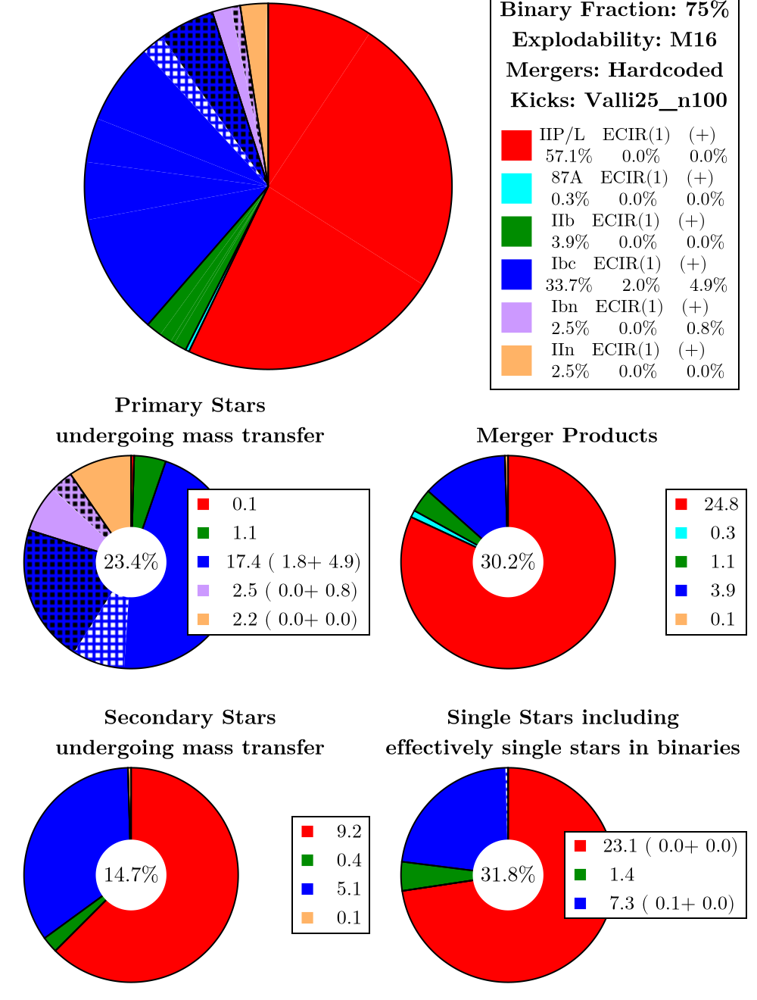

In [ ]:

FIG = Figure(size=(500, 660), figure_padding = 1)
set_theme!(theme_latexfonts())

grid = FIG[1,1] = GridLayout()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 1:2
right_axis = 3:4
left_right = first(left_axis):last(right_axis)
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
aspect_ratio = 1.75

big_top = 1:2
sub_top = 3
sub_bot = 4
big_top = 1:3
sub_top = 4:5
sub_bot = 6:7
ax_pie["all"] = Axis( grid[big_top,left_right], aspect=2,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "")

ax_pie[:RLOF1] = Axis( grid[sub_top,left_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Primary Stars\nundergoing mass transfer")

ax_pie[:RLOF2] = Axis( grid[sub_bot,left_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Secondary Stars\nundergoing mass transfer")


ax_pie[:M] = Axis( grid[sub_top, right_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Merger Products")


ax_pie[:NI] = Axis( grid[sub_bot, right_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Single Stars including \neffectively single stars in binaries ")


                
                
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     [:IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn, :BH]
snlabel = Dict("IIP"=>"IIP/L", "IIP-B"=>"87A", "IIb"=>"IIb", "Ibc"=>"Ibc", "II-i"=>"II-i", "Ibc-i"=>"Ibn", "BH"=>"BH")
progenitors = ["1", "2", "M", "S"]
progenitors_ext = ["MT-1", "MT-2",  "M", "NI-1", "NI-2", "NI-S"]
sntypes_to_print =      [:IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn]
sntypes_to_plot  =      [:IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn]
progenitors_int_and_non = [:RLOF1, :RLOF2,  :M, :NI]


alpha = 1
color_coding = Dict() 
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding[:BH] = RGBAf(.15, .15, .15 ,alpha) 
color_coding_new = Dict() 

colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=style, line_color=color,
                        bg_color= color2)

prg_interface = Dict("MT-1"=>:RLOF1, "MT-2"=>:RLOF2, "M"=>:M,
                     "NI-1"=>:NI, "NI-2"=>:NI, "NI-S"=>:NI)
sn_interface = Dict(:IIP=>"IIP/L", :Ibc=>"Ibc", :SN87A=>"87A",
                     :IIb=>"IIb", :IIn=>"IIn", :Ibn=>"Ibn")
prgs2 = [ prg_interface[prg] for prg in prgs]
for sn in sntypes 
    color_coding_new[sn]=Dict()
    for prg in progenitors_int_and_non
        color_coding_new[sn][prg] = Dict()
        color_coding_new[sn][prg][:more] = Pattern(colorhatch(color_coding[sn], color2=RGBAf(0.,0.,0.,1)))
        color_coding_new[sn][prg][:one]  = Pattern(colorhatch(color_coding[sn]))
        color_coding_new[sn][prg][:none] = color_coding[sn]
    end
end

colors= [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_int_and_non]
ECI_RLOF = ECI .&& (tau_periastron .< tau_ECI)# .&& (tau_periastron .> 0.1)
n_to_sym(array) = [ x == 1  ? :one : (x==0 ? :none : :more) for x in array]
N_ECI = n_to_sym(n_passages)
track_eci = true


function sn_pie_chart(ax, pdfs, prgs, sne, condition; track_eci=false, r_in = 0, r_out = 1)

    SN_numbers = [sum(pdfs[ (sne .== sn) .&&  condition]) 
                        for sn in sntypes_to_plot]

    SN_numbers_sub = [ sum(pdfs[ (sne .== sn) .&& 
                                 (prgs .== prg) .&& 
                                 condition .&& 
                                 ( (!track_eci .&& (eci .== :none)) .||
                                   ( track_eci .&& 
                                       (( (ECI_RLOF .== true ) .&& (N_ECI .== eci) ) .||
                                        ( (ECI_RLOF .== false) .&& (eci == :none) )) )
                                    ) ])  
                        for sn in sntypes_to_plot 
                        for eci in [:none, :one, :more]
                        for prg in progenitors_int_and_non]
    SN_colors_sub =  Any[color_coding_new[sn][prg][track_eci ? eci : :none]
                        for sn in sntypes_to_plot 
                        for eci in [:none, :one, :more]
                        for prg in progenitors_int_and_non]
    
    @printf("SN_numbers: tot %5.3f - sub %5.3f\n", sum(SN_numbers), sum(SN_numbers_sub))
    abs(sum(SN_numbers) - sum(SN_numbers_sub)) > 1e-8 && throw(ErrorException("Something went wrong in pie chart: check logic!"))

    hatched_pie!(ax, reverse!(SN_numbers_sub),
         colors=reverse!(SN_colors_sub), 
         offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = 0)
    pie!(ax, reverse!(SN_numbers), 
         color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = 1)
    
    normer = sum(SN_numbers_sub)

    return normer 

end


sn_pie_chart(ax_pie["all"], pdfs, prgs2, SNe, ccsne; track_eci=track_eci)
xlims!(ax_pie["all"], -1.41, 2.61)
ylims!(ax_pie["all"], -1.01, 1.01)

for tt in progenitors_int_and_non

    # prg2 = tt in ["1" , "2"] ? [tt*"-MT", tt*"-NI"] : [tt]
    tot_sn_tt = sn_pie_chart(ax_pie[tt], pdfs, prgs2, SNe, ccsne .&& (prgs2 .== tt); track_eci = track_eci )
    pie!(ax_pie[tt], [1], 
         color=RGBAf(1,1,1,1), offset = 0, inner_radius = 0, radius = 0.33, strokewidth = 0)

    text!(ax_pie[tt], 0., 0., text=@sprintf("%.1f%%", tot_sn_tt), align = (:center, :center))

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    xlims!(ax_pie[tt],-1.21,2.31)
    ylims!(ax_pie[tt],-1.01,1.01)


    for sn in sntypes_to_print 
        sumpdfs = sum(pdfs[ (prgs2 .== tt) .&& (SNe .== sn)])
        sumpdfs < 1e-6 && continue
        sumpdfs1 = sum(pdfs[ (prgs2 .== tt) .&& (SNe .== sn) .&& (ECI_RLOF) .&& (N_ECI .== :one) ])
        sumpdfs2 = sum(pdfs[ (prgs2 .== tt) .&& (SNe .== sn) .&& (ECI_RLOF) .&& (N_ECI .== :more)  ])

        scatter!(ax_pie[tt], [99,99], [99,99], color = color_coding[sn],  markersize=12, marker = :rect,
                                label = @sprintf("%4.1f", sumpdfs) * (track_eci && sumpdfs1+sumpdfs2>1e-3 ? @sprintf(" (%4.1f+%4.1f)", sumpdfs1, sumpdfs2) : "") )
    end
    axislegend(ax_pie[tt],  position=:rc, 
                nbanks= 1, titleposition=:left, rowgap=-1,colgap=0, 
                labelsize=13, padding=(0.,5,0,-.5))


end
 
            
ax_pie["all"].rightspinevisible = false
ax_pie["all"].topspinevisible = false
ax_pie["all"].leftspinevisible = false
ax_pie["all"].bottomspinevisible = false

for sn in sntypes_to_print
    sumpdfs = sum(pdfs[ SNe .== sn])
    sumpdfs1 = sum(pdfs[ SNe .== sn .&& ECI_RLOF .&& (N_ECI .== :one)  ])
    sumpdfs2 = sum(pdfs[ SNe .== sn .&& ECI_RLOF .&& (N_ECI .== :more) ])
    barplot!(ax_pie["all"], [-100], [0], color = color_coding[sn],   
        label = @sprintf("%5s \t %s \t %s\n%5.1f%% \t %5.1f%% \t %5.1f%%",
             sn_interface[sn], track_eci ? "ECIR(1)" : " ", track_eci ? "(+)" : " ",
             sumpdfs, track_eci ? sumpdfs1 : " ", track_eci ? sumpdfs2 : " " ))
end

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_dict = Dict("Inf" => "Inf", "Unbound"=>"Unbound",
                          "MM_n$n" =>      "M16" ,
                          "Hobbs_n$n" =>   "H50" ,
                          "DM25_n$n" =>    "DM25",
                        "COMBINE_n$n" => "K18" ,
                          "Valli25_n$n" => "V25", 
                          "None" => "None"
                          )
kick_crit = KICKS
key_label = @sprintf( "Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\n Kicks: %s", f_B*100, exp_crit, mer_crit, kick_crit)

axislegend(ax_pie["all"], key_label, position=:rc, 
    nbanks=1, labelsize=12, rowgap =2, colgap =8, titlehalign = :left)



rowgap!(grid, 0)
colgap!(grid, 0)



save_directory = "../output/ECI/"
outfilename = @sprintf("pies_%s_%s_%2d_%s.pdf", MERGER_CRITERION, EXP_CRIT, 100*f_B, KICKS)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG

 

SN_numbers: tot 100.000 - sub 100.000
SN_numbers: tot 33.714 - sub 33.714
SN_numbers: tot 33.714 - sub 33.714
SN_numbers: tot 2.468 - sub 2.468
SN_numbers: tot 2.468 - sub 2.468


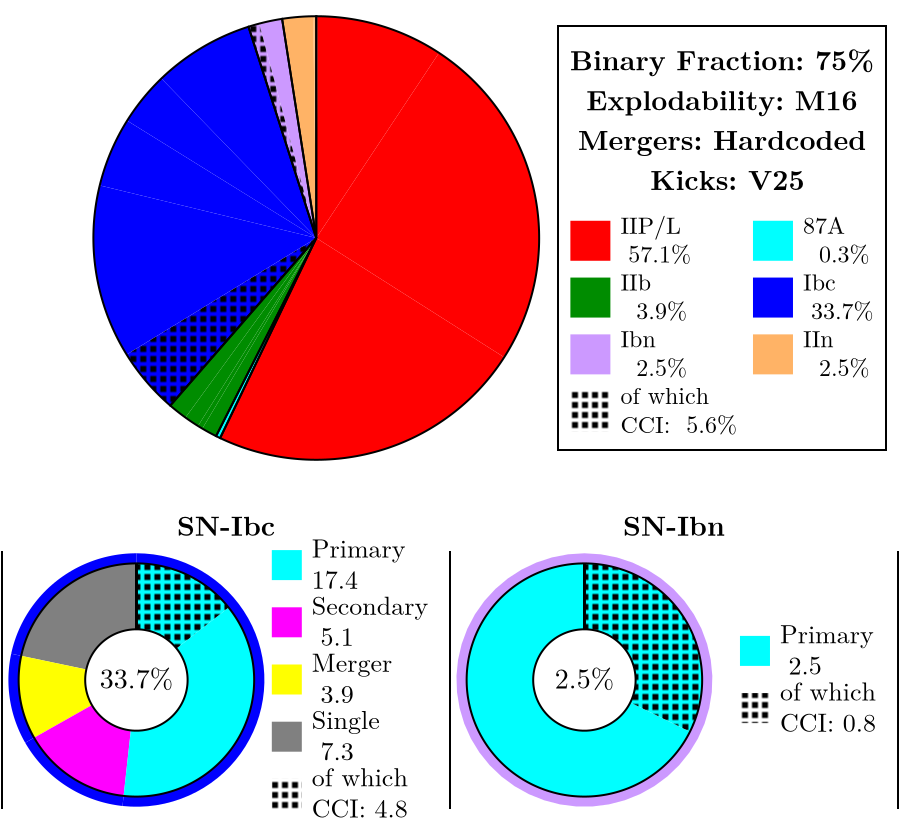

In [12]:

FIG = Figure(size=(450, 420), figure_padding = 1)
set_theme!(theme_latexfonts())

grid = FIG[1,1] = GridLayout()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 1:2
right_axis = 3:4
left_right = first(left_axis):last(right_axis)
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
aspect_ratio = 1.75

n = 250
kick_dict = Dict("Inf" => "Inf", "Unbound"=>"Unbound",
                          "MM_n$n" =>      "M16" ,
                          "Hobbs_n$n" =>   "H50" ,
                          "DM25_n$n" =>    "DM25",
                        "COMBINE_n$n" => "K18" ,
                          "Valli25_n$n" => "V25", 
                          "None" => "None"
                          )
big_top = 1:2
sub_top = 3
sub_bot = 4
big_top = 1:3
sub_top = 4:5
sub_bot = 6:7
ax_pie = Axis( grid[big_top,left_right], aspect=2,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "")
ax_pie_Ibc = Axis( grid[sub_top,left_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "SN-Ibc")

ax_pie_Ibn = Axis( grid[sub_top,right_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "SN-Ibn")
      
                
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     [:IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn, :BH]
snlabel = Dict("IIP"=>"IIP/L", "IIP-B"=>"87A", "IIb"=>"IIb", "Ibc"=>"Ibc", "II-i"=>"II-i", "Ibc-i"=>"Ibn", "BH"=>"BH")
progenitors = ["1", "2", "M", "S"]
progenitors_ext = ["MT-1", "MT-2",  "M", "NI-1", "NI-2", "NI-S"]
sntypes_to_print =      [:IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn]
sntypes_to_plot  =      [:IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn]
progenitors_int_and_non = [:RLOF1, :RLOF2,  :M, :NI]


color_coding_new = Dict() 
color_coding_new2 = Dict() 

colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=style, line_color=color,
                        bg_color= color2)

alpha = 1
color_coding = Dict() 
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding[:BH] = RGBAf(.15, .15, .15 ,alpha) 

alpha=1
color_coding[:RLOF1] = RGBAf(0,1,1 ,alpha)   
color_coding[:RLOF2]= RGBAf(1,0,1 ,alpha)    
color_coding[:M]     =RGBAf(1,1,0 ,alpha)   
color_coding[:NI]    =RGBAf(.5,.5,.5,alpha)

prg_interface = Dict("MT-1"=>:RLOF1, "MT-2"=>:RLOF2, "M"=>:M,
                     "NI-1"=>:NI, "NI-2"=>:NI, "NI-S"=>:NI)
prg_label = Dict(:RLOF1=>"Primary", :RLOF2=>"Secondary", :M=>"Merger",
                 :NI => "Single")
sn_interface = Dict(:IIP=>"IIP/L", :Ibc=>"Ibc", :SN87A=>"87A",
                     :IIb=>"IIb", :IIn=>"IIn", :Ibn=>"Ibn")
prgs2 = [ prg_interface[prg] for prg in prgs]
for sn in sntypes 
    color_coding_new[sn]=Dict()
    color_coding_new2[sn]=Dict()
    for prg in progenitors_int_and_non
        color_coding_new[sn][prg] = Dict()
        color_coding_new[sn][prg][:more] = Pattern(colorhatch(color_coding[sn],color2=RGBAf(0.,0.,0.,1)))
        color_coding_new[sn][prg][:one]  = color_coding[sn]
        color_coding_new[sn][prg][:none] = color_coding[sn]
        color_coding_new[sn][prg][:ok] = color_coding_new[sn][prg][:more]
        color_coding_new[sn][prg][:ignore] = color_coding[sn]

        color_coding_new2[sn][prg] = Dict()
        color_coding_new2[sn][prg][:more] = Pattern(colorhatch(color_coding[prg],color2=RGBAf(0.,0.,0.,1)))
        color_coding_new2[sn][prg][:one]  =  color_coding[prg]
        color_coding_new2[sn][prg][:none] = color_coding[prg]
        color_coding_new2[sn][prg][:ok] = color_coding_new2[sn][prg][:more]
        color_coding_new2[sn][prg][:ignore] = color_coding[prg]

    end
end

colors= [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_int_and_non]
ECI_RLOF = ECI .&& (tau_periastron .< tau_ECI)# .&& (tau_periastron .> 0.1)
# n_to_sym(array) = [ x == 1  ? :one : (x==0 ? :none : :more) for x in array]
n_to_sym(array) = [ x == 1  ? :ignore : (x==0 ? :ignore : :ok) for x in array]
N_ECI = n_to_sym(n_passages)
track_eci = true


function sn_pie_chart(ax, pdfs, prgs, sne, condition; track_eci=false, r_in = 0, r_out = 1, all_sne = sntypes_to_plot,
                        strokewidth_out = 1, strokewidth_in=0, strokecolor_out = :black, strokecolor_in=RGBAf(0,0,0,0), colorscheme=color_coding_new)

    SN_numbers = [sum(pdfs[ (sne .== sn) .&&  condition]) 
                        for sn in all_sne]

    SN_numbers_sub = [ sum(pdfs[ (sne .== sn) .&& 
                                 (prgs .== prg) .&& 
                                  condition .&& 
                                 ( (!track_eci .&& (eci .== :ignore)) .||
                                   ( track_eci .&& 
                                       (( (ECI_RLOF .== true ) .&& (N_ECI .== eci) ) .||
                                        ( (ECI_RLOF .== false) .&& (eci == :ignore) )) )
                                    ) ])  
                        for sn in all_sne 
                        for eci in [:ok, :ignore]
                        for prg in progenitors_int_and_non]
    SN_colors_sub =  Any[colorscheme[sn][prg][track_eci ? eci : :ignore]
                        for sn in all_sne 
                        for eci in [:ok, :ignore]
                        for prg in progenitors_int_and_non]
    
    @printf("SN_numbers: tot %5.3f - sub %5.3f\n", sum(SN_numbers), sum(SN_numbers_sub))
    abs(sum(SN_numbers) - sum(SN_numbers_sub)) > 1e-8 && throw(ErrorException("Something went wrong in pie chart: check logic!"))

    hatched_pie!(ax, reverse!(SN_numbers_sub),
         colors=reverse!(SN_colors_sub), 
         offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = strokewidth_in, strokecolor=strokecolor_in)
    pie!(ax, reverse!(SN_numbers), 
         color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = strokewidth_out, strokecolor=strokecolor_out)
    
    normer = sum(SN_numbers_sub)

    return normer 

end


sn_pie_chart(ax_pie, pdfs, prgs2, SNe, ccsne; track_eci=track_eci)
xlims!(ax_pie, -1.41, 2.61)
ylims!(ax_pie, -1.01, 1.01)
xlims!(ax_pie_Ibc,-1.05,2.45)
ylims!(ax_pie_Ibc,-1.01,1.01)
xlims!(ax_pie_Ibn,-1.05,2.45)
ylims!(ax_pie_Ibn,-1.01,1.01)

sn_pie_chart(ax_pie_Ibc, pdfs, prgs2, SNe, ccsne .&& (SNe .== :Ibc); r_in=0.92, r_out=1., strokecolor_out = RGBAf(0,0,0,0))
sn_pie_chart(ax_pie_Ibc, pdfs, prgs2, SNe, ccsne .&& (SNe .== :Ibc); r_in = 0.4,r_out=.92, track_eci=track_eci, colorscheme=color_coding_new2)
sn_pie_chart(ax_pie_Ibn, pdfs, prgs2, SNe, ccsne .&& (SNe .== :Ibn); r_in=0.92, r_out=1., strokecolor_out = RGBAf(0,0,0,0))
sn_pie_chart(ax_pie_Ibn, pdfs, prgs2, SNe, ccsne .&& (SNe .== :Ibn); r_in = 0.4,r_out=.92,track_eci=track_eci, colorscheme=color_coding_new2)

for tt in [:RLOF1, :RLOF2, :M, :NI]

    # prg2 = tt in ["1" , "2"] ? [tt*"-MT", tt*"-NI"] : [tt]


    sumpdfs = sum(pdfs[ (prgs2 .== tt) .&& (SNe .== :Ibc)])
    sumpdfs < 1e-6 && continue
    sumpdfs1 = sum(pdfs[ (prgs2 .== tt) .&& (SNe .== :Ibc) .&& (ECI_RLOF) .&& (N_ECI .== :one) ])
    sumpdfs2 = sum(pdfs[ (prgs2 .== tt) .&& (SNe .== :Ibc) .&& (ECI_RLOF) .&& (N_ECI .== :more)  ])

    barplot!(ax_pie_Ibc, [99,99], [99,99], color = color_coding[tt], 
                            label = @sprintf("%s\n%4.1f", prg_label[tt], sumpdfs) )

    sumpdfs = sum(pdfs[ (prgs2 .== tt) .&& (SNe .== :Ibn)])
    sumpdfs < 1e-6 && continue
    sumpdfs1 = sum(pdfs[ (prgs2 .== tt) .&& (SNe .== :Ibn) .&& (ECI_RLOF) .&& (N_ECI .== :one) ])
    sumpdfs2 = sum(pdfs[ (prgs2 .== tt) .&& (SNe .== :Ibn) .&& (ECI_RLOF) .&& (N_ECI .== :more)  ])

    barplot!(ax_pie_Ibn, [99,99], [99,99], color = color_coding[tt], 
                            label = @sprintf("%s\n%4.1f", prg_label[tt], sumpdfs) )


end

text!(ax_pie_Ibc, 0., 0., text=@sprintf("%.1f%%", sum(pdfs[SNe .== :Ibc])), align = (:center, :center))
text!(ax_pie_Ibn, 0., 0., text=@sprintf("%.1f%%", sum(pdfs[SNe .== :Ibn])), align = (:center, :center))

sumpdfs = sum(pdfs[ (SNe .== :Ibc) .&& ECI_RLOF .&& (N_ECI .== :ok) ])
barplot!(ax_pie_Ibc, [99,99], [99,99], color = Pattern(colorhatch(RGBAf(0,0,0,0),color2=RGBAf(0.,0.,0.,1))),  
    label = @sprintf("of which\nCCI: %3.1f",sumpdfs )) 
sumpdfs = sum(pdfs[ (SNe .== :Ibn) .&& ECI_RLOF .&& (N_ECI .== :ok) ])
barplot!(ax_pie_Ibn, [99,99], [99,99], color =Pattern(colorhatch(RGBAf(0,0,0,0),color2=RGBAf(0.,0.,0.,1))),  
            label = @sprintf("of which\nCCI: %3.1f", sumpdfs ))


axislegend(ax_pie_Ibc,  position=:rc, 
        nbanks= 1, titleposition=:left, rowgap=0,colgap=0, 
        labelsize=13, padding=(0.,5,0,-.5), framevisible=false, 
        patchsize=[15,15])
axislegend(ax_pie_Ibn,  position=:rc, 
        nbanks= 1, titleposition=:left, rowgap=0,colgap=0, 
        labelsize=13, padding=(0.,5,0,-.5), framevisible=false,
        patchsize=[15,15])

for ax in [ax_pie, ax_pie_Ibc, ax_pie_Ibn]
    ax.rightspinevisible = ax!==ax_pie
    ax.topspinevisible = false
    ax.leftspinevisible = ax!==ax_pie
    ax.bottomspinevisible = false
end 
for sn in sntypes_to_print
    sumpdfs = sum(pdfs[ SNe .== sn])
    sumpdfs1 = sum(pdfs[ SNe .== sn .&& ECI_RLOF .&& (N_ECI .== :one)  ])
    sumpdfs2 = sum(pdfs[ SNe .== sn .&& ECI_RLOF .&& (N_ECI .== :more) ])
    barplot!(ax_pie, [-100], [0], color = color_coding[sn],   
        label = @sprintf("%s\n%5.1f%%",
             sn_interface[sn], sumpdfs ))
end
sumpdfs = sum(pdfs[ ECI_RLOF .&& (N_ECI .== :ok) ])
barplot!(ax_pie, [-100], [0], color = Pattern(colorhatch(RGBAf(0,0,0,0),color2=RGBAf(0.,0.,0.,1))),   
    label = @sprintf("of which\nCCI:%5.1f%%",sumpdfs ))

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_crit = KICKS
key_label = @sprintf( "Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\n Kicks: %s", f_B*100, exp_crit, mer_crit, kick_dict[KICKS])

axislegend(ax_pie, key_label, position=:rc, 
    nbanks=2, labelsize=12, rowgap =2, colgap =8, titlehalign = :left)



rowgap!(grid, 0)
colgap!(grid, 0)



save_directory = "../output/ECI/"
outfilename = @sprintf("pies_onlySE_%s_%s_%2d_%s.pdf", MERGER_CRITERION, EXP_CRIT, 100*f_B, KICKS)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG

 

In [28]:

FIG = Figure(size=(400, 240), figure_padding = 1)
set_theme!(theme_latexfonts())

grid = FIG[1,1] = GridLayout()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 1:2
right_axis = 3:4
left_right = first(left_axis):last(right_axis)
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
aspect_ratio = 1.7

n = 200
kick_dict = Dict("Inf" => "Inf", "Unbound"=>"Unbound",
                          "MM_n$n" =>      "M16" ,
                          "Hobbs_n$n" =>   "H50" ,
                          "DM25_n$n" =>    "DM25",
                        "COMBINE_n$n" => "K18" ,
                          "Valli25_n$n" => "V25", 
                          "None" => "None"
                          )
big_top = 1:2
sub_top = 3
sub_bot = 4
big_top = 1:3
sub_top = 4:5
sub_bot = 6:7
ax_pie = Axis( grid[big_top,left_right], aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "")
                
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     [:IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn, :BH]
snlabel = Dict("IIP"=>"IIP/L", "IIP-B"=>"87A", "IIb"=>"IIb", "Ibc"=>"Ibc", "II-i"=>"II-i", "Ibc-i"=>"Ibn", "BH"=>"BH")
progenitors = ["1", "2", "M", "S"]
progenitors_ext = ["MT-1", "MT-2",  "M", "NI-1", "NI-2", "NI-S"]
sntypes_to_print =      [:IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn]
sntypes_to_plot  =      [:IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn]
progenitors_int_and_non = [:RLOF1, :RLOF2,  :M, :NI]


color_coding_new = Dict() 
color_coding_new2 = Dict() 

colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=style, line_color=color,
                        bg_color= color2)

alpha = 1
color_coding = Dict() 
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding[:BH] = RGBAf(.15, .15, .15 ,alpha) 

alpha=1
color_coding[:RLOF1] = RGBAf(0,1,1 ,alpha)   
color_coding[:RLOF2]= RGBAf(1,0,1 ,alpha)    
color_coding[:M]     =RGBAf(1,1,0 ,alpha)   
color_coding[:NI]    =RGBAf(.5,.5,.5,alpha)

prg_interface = Dict("MT-1"=>:RLOF1, "MT-2"=>:RLOF2, "M"=>:M,
                     "NI-1"=>:NI, "NI-2"=>:NI, "NI-S"=>:NI)
prg_label = Dict(:RLOF1=>"Primary", :RLOF2=>"Secondary", :M=>"Merger",
                 :NI => "Single")
sn_interface = Dict(:IIP=>"IIP/L", :Ibc=>"Ibc", :SN87A=>"87A",
                     :IIb=>"IIb", :IIn=>"IIn", :Ibn=>"Ibn")
prgs2 = [ prg_interface[prg] for prg in prgs]
for sn in sntypes 
    color_coding_new[sn]=Dict()
    color_coding_new2[sn]=Dict()
    for prg in progenitors_int_and_non
        color_coding_new[sn][prg] = Dict()
        color_coding_new[sn][prg][:more] = Pattern(colorhatch(color_coding[sn],color2=RGBAf(0.,0.,0.,1)))
        color_coding_new[sn][prg][:one]  = color_coding[sn]
        color_coding_new[sn][prg][:none] = color_coding[sn]
        color_coding_new[sn][prg][:ok] = color_coding_new[sn][prg][:more]
        color_coding_new[sn][prg][:ignore] = color_coding[sn]

        color_coding_new2[sn][prg] = Dict()
        color_coding_new2[sn][prg][:more] = Pattern(colorhatch(color_coding[prg],color2=RGBAf(0.,0.,0.,1)))
        color_coding_new2[sn][prg][:one]  =  color_coding[prg]
        color_coding_new2[sn][prg][:none] = color_coding[prg]
        color_coding_new2[sn][prg][:ok] = color_coding_new2[sn][prg][:more]
        color_coding_new2[sn][prg][:ignore] = color_coding[prg]

    end
end

colors= [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_int_and_non]
ECI_RLOF = ECI .&& (tau_periastron .< tau_ECI)# .&& (tau_periastron .> 0.1)
# n_to_sym(array) = [ x == 1  ? :one : (x==0 ? :none : :more) for x in array]
n_to_sym(array) = [ x == 1  ? :ignore : (x==0 ? :ignore : :ok) for x in array]
N_ECI = n_to_sym(n_passages)
track_eci = false


function sn_pie_chart(ax, pdfs, prgs, sne, condition; track_eci=false, r_in = 0, r_out = 1, all_sne = sntypes_to_plot,
                        strokewidth_out = 1, strokewidth_in=0, strokecolor_out = :black, strokecolor_in=RGBAf(0,0,0,0), colorscheme=color_coding_new)

    SN_numbers = [sum(pdfs[ (sne .== sn) .&&  condition]) 
                        for sn in all_sne]

    SN_numbers_sub = [ sum(pdfs[ (sne .== sn) .&& 
                                 (prgs .== prg) .&& 
                                  condition .&& 
                                 ( (!track_eci .&& (eci .== :ignore)) .||
                                   ( track_eci .&& 
                                       (( (ECI_RLOF .== true ) .&& (N_ECI .== eci) ) .||
                                        ( (ECI_RLOF .== false) .&& (eci == :ignore) )) )
                                    ) ])  
                        for sn in all_sne 
                        for eci in [:ok, :ignore]
                        for prg in progenitors_int_and_non]
    SN_colors_sub =  Any[colorscheme[sn][prg][track_eci ? eci : :ignore]
                        for sn in all_sne 
                        for eci in [:ok, :ignore]
                        for prg in progenitors_int_and_non]
    
    @printf("SN_numbers: tot %5.3f - sub %5.3f\n", sum(SN_numbers), sum(SN_numbers_sub))
    abs(sum(SN_numbers) - sum(SN_numbers_sub)) > 1e-8 && throw(ErrorException("Something went wrong in pie chart: check logic!"))

    hatched_pie!(ax, reverse!(SN_numbers_sub),
         colors=reverse!(SN_colors_sub), 
         offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = strokewidth_in, strokecolor=strokecolor_in)
    pie!(ax, reverse!(SN_numbers), 
         color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = strokewidth_out, strokecolor=strokecolor_out)
    
    normer = sum(SN_numbers_sub)

    return normer 

end


sn_pie_chart(ax_pie, pdfs, prgs2, SNe, ccsne; track_eci=track_eci)
yl,yh=-1.1,1.1
xlims!(ax_pie,yl, (yh-yl)*aspect_ratio + yl)
ylims!(ax_pie,yl, yh)




for ax in [ax_pie]
    ax.rightspinevisible =false
    ax.topspinevisible = false
    ax.leftspinevisible = false
    ax.bottomspinevisible = false
end 
for sn in sntypes_to_print
    sumpdfs = sum(pdfs[ SNe .== sn])
    sumpdfs1 = sum(pdfs[ SNe .== sn .&& ECI_RLOF .&& (N_ECI .== :one)  ])
    sumpdfs2 = sum(pdfs[ SNe .== sn .&& ECI_RLOF .&& (N_ECI .== :more) ])
    barplot!(ax_pie, [-100], [0], color = color_coding[sn],   
        label = @sprintf("%s\n%5.1f%%",
             sn_interface[sn], sumpdfs ))
end
sumpdfs = sum(pdfs[ ECI_RLOF .&& (N_ECI .== :ok) ])
# barplot!(ax_pie, [-100], [0], color = Pattern(colorhatch(RGBAf(0,0,0,0),color2=RGBAf(0.,0.,0.,1))),   
    # label = @sprintf("of which\nCCI:%5.1f%%",sumpdfs ))

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_crit = KICKS
key_label = @sprintf( "Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\n Kicks: %s", f_B*100, exp_crit, mer_crit, kick_dict[KICKS])

axislegend(ax_pie, key_label, position=:rc, 
    nbanks=2, labelsize=12, rowgap =2, colgap =8, titlehalign = :left)



rowgap!(grid, 0)
colgap!(grid, 0)



save_directory = "../output/ECI/"
outfilename = @sprintf("onlypie_%s_%s_%2d_%s.pdf", MERGER_CRITERION, EXP_CRIT, 100*f_B, KICKS)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG

 

SN_numbers: tot 100.000 - sub 100.000


KeyError: KeyError: key "Valli25_n500" not found

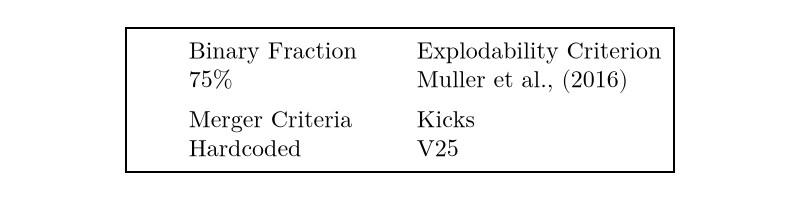

In [ ]:
using MathTeXEngine

FIG = Figure(size=(400, 100), figure_padding = 1)
set_theme!(theme_latexfonts())

grid = FIG[1,1] = GridLayout()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 1:2
right_axis = 3:4
left_right = first(left_axis):last(right_axis)
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
aspect_ratio = 1.7

kick_dict = Dict("Inf" => "Inf", "Unbound"=>"Unbound",
                          "MM_n$n" =>      "M16" ,
                          "Hobbs_n$n" =>   "H50" ,
                          "DM25_n$n" =>    "DM25",
                        "COMBINE_n$n" => "K18" ,
                          "Valli25_n$n" => "V25", 
                          "None" => "None"
                          )
big_top = 1:2
sub_top = 3
sub_bot = 4
big_top = 1:3
sub_top = 4:5
sub_bot = 6:7
ax_pie = Axis( grid[big_top,left_right], aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "")
                
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     [:IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn, :BH]
snlabel = Dict("IIP"=>"IIP/L", "IIP-B"=>"87A", "IIb"=>"IIb", "Ibc"=>"Ibc", "II-i"=>"II-i", "Ibc-i"=>"Ibn", "BH"=>"BH")
progenitors = ["1", "2", "M", "S"]
progenitors_ext = ["MT-1", "MT-2",  "M", "NI-1", "NI-2", "NI-S"]
sntypes_to_print =      [:IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn]
sntypes_to_plot  =      [:IIP, :SN87A, :IIb, :Ibc, :Ibn, :IIn]
progenitors_int_and_non = [:RLOF1, :RLOF2,  :M, :NI]


color_coding_new = Dict() 
color_coding_new2 = Dict() 

colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=style, line_color=color,
                        bg_color= color2)

alpha = 1
color_coding = Dict() 
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding[:BH] = RGBAf(.15, .15, .15 ,alpha) 

alpha=1
color_coding[:RLOF1] = RGBAf(0,1,1 ,alpha)   
color_coding[:RLOF2]= RGBAf(1,0,1 ,alpha)    
color_coding[:M]     =RGBAf(1,1,0 ,alpha)   
color_coding[:NI]    =RGBAf(.5,.5,.5,alpha)

prg_interface = Dict("MT-1"=>:RLOF1, "MT-2"=>:RLOF2, "M"=>:M,
                     "NI-1"=>:NI, "NI-2"=>:NI, "NI-S"=>:NI)
prg_label = Dict(:RLOF1=>"Primary", :RLOF2=>"Secondary", :M=>"Merger",
                 :NI => "Single")
sn_interface = Dict(:IIP=>"IIP/L", :Ibc=>"Ibc", :SN87A=>"87A",
                     :IIb=>"IIb", :IIn=>"IIn", :Ibn=>"Ibn")
prgs2 = [ prg_interface[prg] for prg in prgs]
for sn in sntypes 
    color_coding_new[sn]=Dict()
    color_coding_new2[sn]=Dict()
    for prg in progenitors_int_and_non
        color_coding_new[sn][prg] = Dict()
        color_coding_new[sn][prg][:more] = Pattern(colorhatch(color_coding[sn],color2=RGBAf(0.,0.,0.,1)))
        color_coding_new[sn][prg][:one]  = color_coding[sn]
        color_coding_new[sn][prg][:none] = color_coding[sn]
        color_coding_new[sn][prg][:ok] = color_coding_new[sn][prg][:more]
        color_coding_new[sn][prg][:ignore] = color_coding[sn]

        color_coding_new2[sn][prg] = Dict()
        color_coding_new2[sn][prg][:more] = Pattern(colorhatch(color_coding[prg],color2=RGBAf(0.,0.,0.,1)))
        color_coding_new2[sn][prg][:one]  =  color_coding[prg]
        color_coding_new2[sn][prg][:none] = color_coding[prg]
        color_coding_new2[sn][prg][:ok] = color_coding_new2[sn][prg][:more]
        color_coding_new2[sn][prg][:ignore] = color_coding[prg]

    end
end

colors= [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_int_and_non]
ECI_RLOF = ECI .&& (tau_periastron .< tau_ECI)# .&& (tau_periastron .> 0.1)
# n_to_sym(array) = [ x == 1  ? :one : (x==0 ? :none : :more) for x in array]
n_to_sym(array) = [ x == 1  ? :ignore : (x==0 ? :ignore : :ok) for x in array]
N_ECI = n_to_sym(n_passages)
track_eci = false


function sn_pie_chart(ax, pdfs, prgs, sne, condition; track_eci=false, r_in = 0, r_out = 1, all_sne = sntypes_to_plot,
                        strokewidth_out = 1, strokewidth_in=0, strokecolor_out = :black, strokecolor_in=RGBAf(0,0,0,0), colorscheme=color_coding_new)

    SN_numbers = [sum(pdfs[ (sne .== sn) .&&  condition]) 
                        for sn in all_sne]

    SN_numbers_sub = [ sum(pdfs[ (sne .== sn) .&& 
                                 (prgs .== prg) .&& 
                                  condition .&& 
                                 ( (!track_eci .&& (eci .== :ignore)) .||
                                   ( track_eci .&& 
                                       (( (ECI_RLOF .== true ) .&& (N_ECI .== eci) ) .||
                                        ( (ECI_RLOF .== false) .&& (eci == :ignore) )) )
                                    ) ])  
                        for sn in all_sne 
                        for eci in [:ok, :ignore]
                        for prg in progenitors_int_and_non]
    SN_colors_sub =  Any[colorscheme[sn][prg][track_eci ? eci : :ignore]
                        for sn in all_sne 
                        for eci in [:ok, :ignore]
                        for prg in progenitors_int_and_non]
    
    @printf("SN_numbers: tot %5.3f - sub %5.3f\n", sum(SN_numbers), sum(SN_numbers_sub))
    abs(sum(SN_numbers) - sum(SN_numbers_sub)) > 1e-8 && throw(ErrorException("Something went wrong in pie chart: check logic!"))

    hatched_pie!(ax, reverse!(SN_numbers_sub),
         colors=reverse!(SN_colors_sub), 
         offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = strokewidth_in, strokecolor=strokecolor_in)
    pie!(ax, reverse!(SN_numbers), 
         color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = strokewidth_out, strokecolor=strokecolor_out)
    
    normer = sum(SN_numbers_sub)

    return normer 

end


# sn_pie_chart(ax_pie, pdfs, prgs2, SNe, ccsne; track_eci=track_eci)
yl,yh=-1.1,1.1
xlims!(ax_pie,yl, (yh-yl)*aspect_ratio + yl)
ylims!(ax_pie,yl, yh)




for ax in [ax_pie]
    ax.rightspinevisible =false
    ax.topspinevisible = false
    ax.leftspinevisible = false
    ax.bottomspinevisible = false
end 
for sn in sntypes_to_print
    sumpdfs = sum(pdfs[ SNe .== sn])
    sumpdfs1 = sum(pdfs[ SNe .== sn .&& ECI_RLOF .&& (N_ECI .== :one)  ])
    sumpdfs2 = sum(pdfs[ SNe .== sn .&& ECI_RLOF .&& (N_ECI .== :more) ])
    # barplot!(ax_pie, [-100], [0], color = color_coding[sn],   
    #     label = @sprintf("%s\n%5.1f%%",
    #          sn_interface[sn], sumpdfs ))
end
sumpdfs = sum(pdfs[ ECI_RLOF .&& (N_ECI .== :ok) ])
# barplot!(ax_pie, [-100], [0], color = Pattern(colorhatch(RGBAf(0,0,0,0),color2=RGBAf(0.,0.,0.,1))),   
    # label = @sprintf("of which\nCCI:%5.1f%%",sumpdfs ))

exp_crit = Dict("MM" => "Muller et al., (2016)", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_crit = kick_dict[KICKS]
barplot!(ax_pie, [-100], [0], color = :white,   
            label = @sprintf("Binary Fraction\n%2.0f%%",f_B*100 ))
barplot!(ax_pie, [-100], [0], color = :white,   
            label = @sprintf("Explodability Criterion\n%s",exp_crit ))
barplot!(ax_pie, [-100], [0], color = :white,   
            label = @sprintf("Merger Criteria\n%s",mer_crit ))
barplot!(ax_pie, [-100], [0], color = :white,   
            label = "Kicks"*"\n"*kick_crit, label_font = texfont(:bold))
axislegend(ax_pie, position=:cc, 
    nbanks=2, labelsize=12, rowgap =8, colgap =5, titlehalign = :left, label_font = texfont(:bold))



rowgap!(grid, 0)
colgap!(grid, 0)



save_directory = "../output/ECI/"
outfilename = @sprintf("only_label_%s_%s_%2d_%s.pdf", MERGER_CRITERION, EXP_CRIT, 100*f_B, KICKS)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG

 

In [52]:
texfont(:bold)

FTFont (family = NewComputerModern, style = 10 Bold)

ATLAS25 = Dict{Any, Any}("label" => "ATLAS", :Ibn => 0.45, :IIb => 11.8, :Ibc => 18.580000000000002, :IIP => 63.2, :IIn => 4.3)


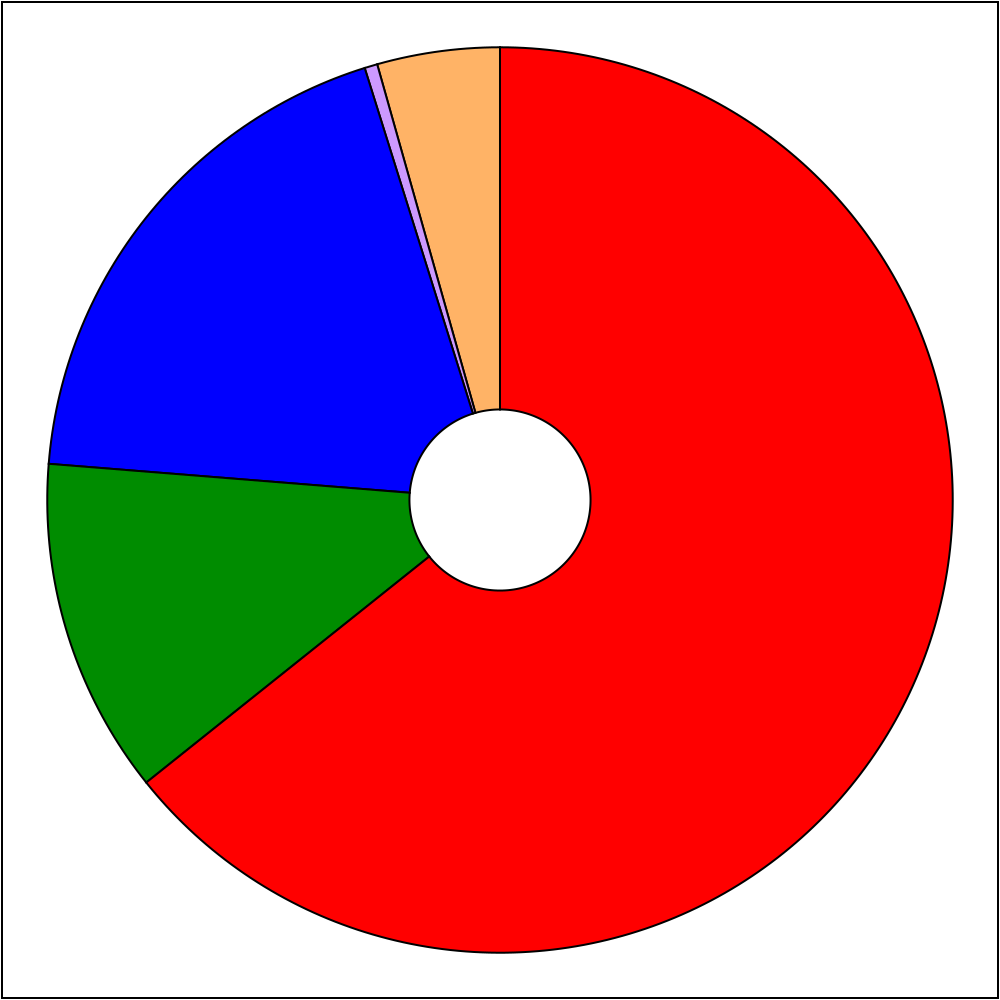

In [12]:
ATLAS25 = Dict("label"=>"ATLAS",
    :IIn    => 4.3,
    :IIP     => 63.2,
    :IIb    => 11.8,
    :Ibc    => 11.8+5.8+0.47+0.51, 
    :Ibn    => .45,
)
alpha=1
color_coding = Dict() 
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding[:BH] = RGBAf(.15, .15, .15 ,alpha) 

FIG = Figure(size=(500, 500), figure_padding = 1)
set_theme!(theme_latexfonts())
ax = plot_settings(FIG[1,1],       
                ylabel = " ",yticklabelsvisible=false, ylabelvisible=false,  yticks=[1e99],
                xlabel = " ",xticklabelsvisible=false, xlabelvisible=false,  xticks=[1e99],
                title = "")

types = reverse([:IIP, :IIb, :Ibc, :Ibn, :IIn])
pie!(ax, [ATLAS25[type] for type in types], 
         color=[color_coding[type] for type in types],
          offset = pi/2, inner_radius = 0.2, radius = 1, strokewidth = 1.0, strokecolor=:black)
          
          
resize_to_layout!(FIG)



save_directory = "../output/ECI/"
outfilename = "testpie_ATLAS.pdf"
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

@show ATLAS25

FIG




## Companion analisys

In [9]:
SN_companion = Dict()
for ttp in [:IIP, :SN87A, :IIn, :IIb, :Ibc, :Ibn] 
    SN_companion[ttp] = Dict()
    for orbit in [:bound, :unbound, :TZO]
        SN_companion[ttp][orbit] = Dict()
        for companion in [:MS, :BH, :WD, :NS, :X]
            SN_companion[ttp][orbit][companion] = Dict("pdf"=>-1e-16, "CCI"=>-1e-16, "CCI+"=>-1e-16)
        end
    end
end

map_state(state) = Dict(:bound=>:bound, :unbound=>:unbound, :unknown=>:unbound, :direct_collision=>:TZO)[state]

for ttp in [:IIP, :SN87A, :IIn, :IIb, :Ibc, :Ibn]
# for ttp in [:Ibc]

    filter_all = (SNe .== ttp) 
    filter_first = filter_all .&& sn1 
    filter_first_w_comp  = filter_first .&& .! (prgs .== "M" .||  prgs .== "NI-S") 
    filter_first_no_comp = filter_first .&&    (prgs .== "M" .||  prgs .== "NI-S") 
    @printf("\n%5s:  %6.2f\n", ttp, sum(pdfs[filter_all]))
    @printf("%5s   first    = %6.2f\n", "", sum(pdfs[filter_first]))
    @printf("\t %5s   -c = %6.2f\n", "", sum(pdfs[filter_first_no_comp]))
    for prg in ["MT-1", "NI-1", "MT-2", "NI-2", "M", "NI-S"]
        filter_first_p = filter_first_no_comp .&& prgs .== prg
        @printf("\t\t %5s   (%5s) = %5.2f\n", "",  prg,sum(pdfs[filter_first_p]))
        # prg == "M" && (@printf("\n"); continue )
    end
    SN_companion[ttp][:unbound][:X]["pdf"] = sum(pdfs[filter_first_no_comp])
    SN_companion[ttp][:unbound][:X]["CCI"] = 0.
    @printf("\t %5s   +c = %6.2f\n", "", sum(pdfs[filter_first_w_comp]))
    for prg in ["MT-1", "NI-1", "MT-2", "NI-2", "M", "NI-S"]
        filter_first_p = filter_first_w_comp .&& prgs .== prg
        @printf("\t\t %5s   (%5s) = %5.2f\n", "",  prg,sum(pdfs[filter_first_p]))
        # prg == "M" && (@printf("\n"); continue )
    end
    for state in reverse([:bound, :unbound, :direct_collision, :unknown])
        filter_state = filter_first_w_comp .&& post_SN_orbit .== state
        n = sum(pdfs[filter_state])
        SN_companion[ttp][map_state(state)][:MS]["pdf"] += n
        n > 0.001 && @printf("\t\t%20s:%5.2f\n", state, n)

        if n > 0.001 && state == :bound 
            filter_cci = filter_state .&& RLOF_ECI
            n = sum(pdfs[filter_cci])
            n > 0.001 && @printf("\t\t\t\t CCI:%5.2f\n",n) 
            SN_companion[ttp][map_state(state)][:MS]["CCI"] += n
            filter_cci_p = filter_cci .&& (n_passages .> 1)
            n = sum(pdfs[filter_cci_p])
            n > 0.001 && @printf("\t\t\t\t\t CCI+:%5.2f\n",n)
            SN_companion[ttp][map_state(state)][:MS]["CCI+"] += n

        end


    end

    filter_second = filter_all .&& .! sn1 
    @printf("%5s   second   = %6.2f\n", "", sum(pdfs[filter_second]))
    for state in reverse([:bound, :unbound, :unknown])
        filter_state = filter_second .&& post_SN_orbit .== state 
        n = sum(pdfs[filter_state])
        n > 0.001 && @printf("\t\t\t%12s:%5.2f \n", state, n)
        for co in [:WD, :BH, :NS]
            filter_co = filter_state .&& first_CO .== co
            n = sum(pdfs[filter_co])
            n > 0.001 && @printf("\t\t\t\t%10s:%5.2f \n", co, n)
            SN_companion[ttp][map_state(state)][co]["pdf"] += n

            # if n > 0.001 && state == :bound && co == :NS
            #     filter_cci = filter_co .&& RLOF_ECI
            #     n = sum(pdfs[filter_cci])
            #     n > 0.001 && @printf("\t\t\t\t\tCCI:%5.2f\n",n) 
            #     SN_companion[ttp][map_state(state)][co]["CCI"] = n
            #     filter_cci_p = filter_cci .&& (n_passages .> 1)
            #     n = sum(pdfs[filter_cci_p])
            #     n > 0.001 && @printf("\t\t\t\t\t\tCCI+:%5.2f\n",n)
            #     SN_companion[ttp][map_state(state)][co]["CCI+"] = n

            # end
        end
    end

    
end


  IIP:   57.11
        first    =  46.12
	         -c =  41.43
		         ( MT-1) =  0.00
		         ( NI-1) =  0.00
		         ( MT-2) =  0.00
		         ( NI-2) =  0.00
		         (    M) = 24.75
		         ( NI-S) = 16.67
	         +c =   4.69
		         ( MT-1) =  0.11
		         ( NI-1) =  4.59
		         ( MT-2) =  0.00
		         ( NI-2) =  0.00
		         (    M) =  0.00
		         ( NI-S) =  0.00
		    direct_collision: 0.00
		             unbound: 4.69
		               bound: 0.00
        second   =  10.99
			     unknown: 0.18 
				        NS: 0.18 
			     unbound:10.11 
				        NS:10.11 
			       bound: 0.70 
				        WD: 0.45 
				        BH: 0.22 
				        NS: 0.03 

SN87A:    0.32
        first    =   0.32
	         -c =   0.32
		         ( MT-1) =  0.00
		         ( NI-1) =  0.00
		         ( MT-2) =  0.00
		         ( NI-2) =  0.00
		         (    M) =  0.32
		         ( NI-S) =  0.00
	         +c =   0.00
		         ( MT-1) =  0.00
		         ( NI-1) =  0

In [10]:
for ttp in [:IIP, :SN87A, :IIn, :IIb, :Ibc, :Ibn] 
# for ttp in [:Ibc] 
    this = SN_companion[ttp]
    summer = sum([ this[o][c]["pdf"] for o in [:bound, :unbound, :TZO] for c in [:MS, :BH, :WD, :NS, :X]  ])
    @printf("%5s (%5.3f)\n", ttp, summer)
    for orbit in [:bound, :unbound, :TZO]
        this = SN_companion[ttp][orbit]
        summer = sum([ this[c]["pdf"] for c in [:MS, :BH, :WD, :NS, :X]  ])
        summer < 0.001 && continue
        @printf("%5s %10s (%5.3f)\n", " ", orbit, summer)
        for companion in [:MS, :BH, :WD, :NS, :X]
            entry = SN_companion[ttp][orbit][companion]
            entry["pdf"] < 0.001 && continue

            @printf("%5s %10s %3s", "", "",  companion)
            @printf("  %6.3f ", entry["pdf"])
            entry["CCI"] > 0 && @printf("> CCI = %6.3f > CCI+ = %6.3f",entry["CCI"], entry["CCI+"])
            @printf("\n")
        end
    end
end

SNc_direct = Dict()
for ttp in [:IIP, :SN87A, :IIn, :IIb, :Ibc, :Ibn] 
    this = SN_companion[ttp]
    SNc_direct[ttp] = Dict()

    for orbit in [:bound, :unbound, :TZO]
        this = SN_companion[ttp][orbit]
        SNc_direct[ttp][orbit] = Dict()
        
        SNc_direct[ttp][orbit][:deg] = Dict()
        SNc_direct[ttp][orbit][:deg][:normal] = 0
        SNc_direct[ttp][orbit][:deg][:CCI] = 0

        for companion in [:MS, :BH, :WD, :NS, :X]
            entry = SN_companion[ttp][orbit][companion]
            SNc_direct[ttp][orbit][companion] = Dict()
            SNc_direct[ttp][orbit][companion][:normal]  = entry["pdf"] - entry["CCI+"]
            SNc_direct[ttp][orbit][companion][:CCI] = entry["CCI+"]

            if companion ∈ [:BH, :NS, :WD]
                SNc_direct[ttp][orbit][:deg][:normal]  += entry["pdf"] - entry["CCI+"]
                SNc_direct[ttp][orbit][:deg][:CCI] += entry["CCI+"]
            end
        end
    end
end


SNc_direct2 = Dict()
for ttp in [:IIP, :SN87A, :IIn, :IIb, :Ibc, :Ibn] 
    this = SN_companion[ttp]
    SNc_direct2[ttp] = Dict()

    for orbit in [:bound, :unbound, :TZO]
        this = SN_companion[ttp][orbit]
        SNc_direct2[ttp][orbit] = Dict()
        
        SNc_direct2[ttp][orbit][:X] = Dict()
        entry = SN_companion[ttp][orbit][:X]
        SNc_direct2[ttp][orbit][:X][:normal]  = entry["pdf"] - entry["CCI+"]
        SNc_direct2[ttp][orbit][:X][:CCI] = entry["CCI+"]

        SNc_direct2[ttp][orbit][:deg] = Dict()
        SNc_direct2[ttp][orbit][:deg][:normal]  =0
        SNc_direct2[ttp][orbit][:deg][:CCI] =0


        for companion in [:MS, :BH, :NS, :WD]
            entry = SN_companion[ttp][orbit][companion]
            SNc_direct2[ttp][orbit][companion] = Dict()
            SNc_direct2[ttp][orbit][companion][:normal]  = entry["pdf"] - entry["CCI+"]
            SNc_direct2[ttp][orbit][companion][:CCI] = entry["CCI+"]

            if companion ∈ [:BH, :NS, :WD] && orbit == :unbound
                SNc_direct2[ttp][orbit][:X][:normal]  += entry["pdf"] - entry["CCI+"]
                SNc_direct2[ttp][orbit][:X][:CCI] += entry["CCI+"]
            elseif  companion ∈ [:BH, :NS, :WD]
                SNc_direct2[ttp][orbit][:deg][:normal]  += entry["pdf"] - entry["CCI+"]
                SNc_direct2[ttp][orbit][:deg][:CCI] += entry["CCI+"]

            end
        end
    end
end


  IIP (57.112)
           bound (0.707)
                  MS   0.002 
                  BH   0.216 
                  WD   0.454 
                  NS   0.035 
         unbound (56.404)
                  MS   4.690 
                  NS  10.286 
                   X  41.427 
             TZO (0.001)
                  MS   0.001 
SN87A (0.322)
         unbound (0.322)
                   X   0.322 
  IIn (2.444)
           bound (0.065)
                  MS   0.001 > CCI =  0.000 > CCI+ =  0.000
                  BH   0.032 
                  WD   0.017 
                  NS   0.015 
         unbound (2.379)
                  MS   2.232 
                   X   0.147 
  IIb (3.946)
           bound (0.044)
                  BH   0.044 
         unbound (3.902)
                  MS   1.211 
                  NS   0.547 
                   X   2.144 
  Ibc (33.759)
           bound (11.564)
                  MS   6.850 > CCI =  6.547 > CCI+ =  4.869
                  BH   1.135 
           

In [6]:

FIG = Figure(size=(550, 500), figure_padding = 1)
set_theme!(theme_latexfonts())

grid = FIG[1,1] = GridLayout()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8

# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
aspect_ratio = 2

kick_dict = Dict("Inf" => "Inf", "Unbound"=>"Unbound",
                          "MM_n$n" =>      "M16" ,
                          "Hobbs_n$n" =>   "H50" ,
                          "DM25_n$n" =>    "DM25",
                        "COMBINE_n$n" => "K18" ,
                          "Valli25_n$n" => "V25", 
                          "None" => "None"
                          )

row1=1
row2=2
row3=3
col1=1
col2=2
ax_pie = Dict()
ax_pie[:IIP] = Axis( grid[row1,col1],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "SN-IIP/L")
ax_pie[:IIb] = Axis( grid[row2,col1],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "SN-IIb")
ax_pie[:Ibc] = Axis( grid[row3,col1],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "SN-Ibc")

ax_pie[:SN87A] = Axis( grid[row1,col2],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "SN-87A")
ax_pie[:IIn] = Axis( grid[row2,col2],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "SN-IIn")
ax_pie[:Ibn] = Axis( grid[row3,col2],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "SN-Ibn")
      
                

alpha = 1
color_coding = Dict() 
color_coding_new = Dict() 
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding[:BH] = RGBAf(.15, .15, .15 ,alpha) 

alpha=1
color_coding[:RLOF1] = RGBAf(0,1,1 ,alpha)   
color_coding[:RLOF2]= RGBAf(1,0,1 ,alpha)    
color_coding[:M]     =RGBAf(1,1,0 ,alpha)   
color_coding[:NI]    = RGBAf(.55, .55, .55 ,alpha) 

color_coding[:WD] = RGBAf(.6,.6,.6,alpha)   
color_coding[:NS] = RGBAf(0,.66,0,alpha)    
color_coding[:MS] = RGBAf(.4,.4,1,alpha)   
color_coding[:BH] = RGBAf(0,0,0,alpha) 
color_coding[:X] = RGBAf(1,1,1,alpha) 
color_coding[:TZO] = RGBAf(1,0,0,alpha) 

colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=style, line_color=color,
                        bg_color= color2)

sn_interface = Dict(:IIP=>"IIP/L", :Ibc=>"Ibc", :SN87A=>"87A",
                     :IIb=>"IIb", :IIn=>"IIn", :Ibn=>"Ibn")

for companion in [:WD, :BH, :NS, :MS, :X]
    color_coding_new[companion]=Dict()
    for extraCCI in [:normal, :CCI]
        color_coding_new[companion][extraCCI] = Dict()
        color_coding_new[companion][extraCCI][:unbound]  = Pattern(colorhatch(color_coding[companion],color2=RGBAf(1.,1.,1.,1), style = :slash))
        color_coding_new[companion][extraCCI][:unbound]  = color_coding[companion]
        color_coding_new[companion][extraCCI][:TZO]      = color_coding[:TZO]
    end
    color_coding_new[companion][:normal][:bound]    = color_coding[companion]
    color_coding_new[companion][:CCI][:bound]       = Pattern(colorhatch(color_coding[companion],color2=RGBAf(0.,0.,0.,1), style = :plus))

 end

 companions = [:MS, :NS, :WD, :BH, :X]
 state = [:bound, :unbound, :TZO]
 
state_to_t(state) = Dict(:bound=>"B", :unbound=>"U", :TZO=>"TZO")[state]

for ttp in [:IIP, :IIb, :Ibc, :SN87A, :IIn, :Ibn]
    vals = [ 
            SNc_direct[ttp][o][c][cci] + 1e-16 
            for c in companions 
            for o in state
            for cci in [:normal, :CCI]
            ]

    cols = [ color_coding_new[c][cci][o]    
            for c in companions 
            for o in state
            for cci in [:normal, :CCI]
            ]
            

   pie!(ax_pie[ttp], [1]; color=:white, inner_radius=.99,radius =1, strokewidth=2 )
#   pie!(ax_pie[ttp], [1]; color=color_coding[ttp], inner_radius=.9,radius =1, strokewidth=2 )
   hatched_pie!(ax_pie[ttp], vals, colors=cols, inner_radius = 0.5, radius =.99, )
    text!(ax_pie[ttp], 0., 0., text=@sprintf("%.1f%%", sum(pdfs[SNe .== ttp])), align = (:center, :center))

    yl,yh=-1.1,1.1
    xlims!(ax_pie[ttp],yl,(yh-yl)*aspect_ratio + yl)
    ylims!(ax_pie[ttp],yl, yh)

    ax_pie[ttp].rightspinevisible = false
    ax_pie[ttp].topspinevisible = false
    ax_pie[ttp].leftspinevisible = false
    ax_pie[ttp].bottomspinevisible = false
    
    for c in companions 
        for o in state
            for cci in [:normal, :CCI]
                SNc_direct[ttp][o][c][cci]<0.005  && continue
                label =  @sprintf("%s-%s%s", c,state_to_t(o),cci==:CCI ? "+CCI" : "")
                label == "X-U" && (label = "None")
                label == "MS-TZO" && (label = "TZO")
                label *= @sprintf("\n%5.2f%%", SNc_direct[ttp][o][c][cci])
                barplot!(ax_pie[ttp], [-100], [-100], label = label, color=color_coding_new[c][cci][o], strokewidth=.5)
            end
        end
    end
    axislegend(ax_pie[ttp], nbanks=2, labelsize=10, patchsize=[7,16])
end 




save_directory = "../output/ECI/"
outfilename = @sprintf("pies_companion_%s_%s_%2d_%s.pdf", MERGER_CRITERION, EXP_CRIT, 100*f_B, KICKS)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)


FIG

 

UndefVarError: UndefVarError: `pdfs` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

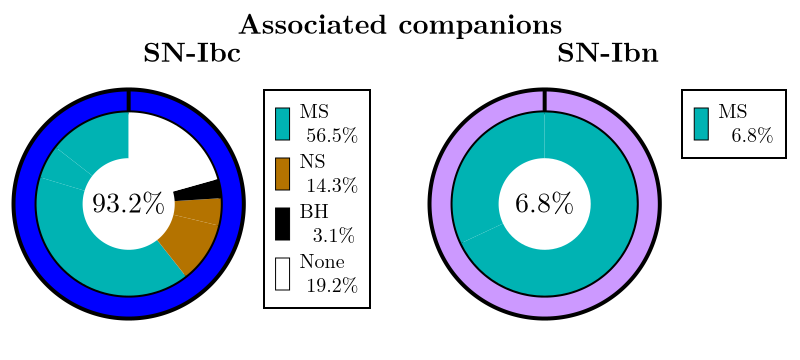

In [ ]:

FIG = Figure(size=(400, 180), figure_padding = 1)
set_theme!(theme_latexfonts())

grid = FIG[1,1] = GridLayout()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8

# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
aspect_ratio = 1.5

kick_dict = Dict("Inf" => "Inf", "Unbound"=>"Unbound",
                          "MM_n$n" =>      "M16" ,
                          "Hobbs_n$n" =>   "H50" ,
                          "DM25_n$n" =>    "DM25",
                        "COMBINE_n$n" => "K18" ,
                          "Valli25_n$n" => "V25", 
                          "None" => "None"
                          )

# row1=1
# row2=2
row3=1
col1=1
col2=2
ax_pie = Dict()

ax_ghost = Axis( grid[row3,col1:col2],
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Associated companions")
ax_ghost.rightspinevisible  = false
ax_ghost.topspinevisible    = false
ax_ghost.leftspinevisible   = false
ax_ghost.bottomspinevisible = false

# ax_pie[:IIP] = Axis( grid[row1,col1],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-IIP/L")
# ax_pie[:IIb] = Axis( grid[row2,col1],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-IIb")
ax_pie[:Ibc] = Axis( grid[row3,col1],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "SN-Ibc")

# ax_pie[:SN87A] = Axis( grid[row1,col2],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-87A")
# ax_pie[:IIn] = Axis( grid[row2,col2],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-IIn")
ax_pie[:Ibn] = Axis( grid[row3,col2],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "SN-Ibn")
      
                

alpha = 1
color_coding = Dict() 
color_coding_new = Dict() 
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding[:BH] = RGBAf(.15, .15, .15 ,alpha) 

alpha=1
color_coding[:RLOF1] = RGBAf(0,1,1 ,alpha)   
color_coding[:RLOF2]= RGBAf(1,0,1 ,alpha)    
color_coding[:M]     =RGBAf(1,1,0 ,alpha)   
color_coding[:NI]    = RGBAf(.55, .55, .55 ,alpha) 

color_coding[:WD] = RGBAf(.6,.6,.6,alpha)   
color_coding[:NS] = RGBAf(181/256,115/256,  0/256,alpha)    
color_coding[:MS] = RGBAf(  0/256,180/256,180/256,alpha)   
color_coding[:BH] = RGBAf(0,0,0,alpha) 
color_coding[:X] = RGBAf(1,1,1,alpha) 
color_coding[:TZO] = RGBAf(1,0,0,alpha) 

colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=style, line_color=color,
                        bg_color= color2)

sn_interface = Dict(:IIP=>"IIP/L", :Ibc=>"Ibc", :SN87A=>"87A",
                     :IIb=>"IIb", :IIn=>"IIn", :Ibn=>"Ibn")

for companion in [:WD, :BH, :NS, :MS, :X]
    color_coding_new[companion]=Dict()
    for extraCCI in [:normal, :CCI]
        color_coding_new[companion][extraCCI] = Dict()
        color_coding_new[companion][extraCCI][:unbound]  = Pattern(colorhatch(color_coding[companion],color2=RGBAf(1.,1.,1.,1), style = :slash))
        color_coding_new[companion][extraCCI][:unbound]  = color_coding[companion]
        color_coding_new[companion][extraCCI][:TZO]      = color_coding[:TZO]
    end
    color_coding_new[companion][:normal][:bound]    = color_coding[companion]
    color_coding_new[companion][:CCI][:bound]       = color_coding[companion] #Pattern(colorhatch(color_coding[companion],color2=RGBAf(0.,0.,0.,1), style = :plus))

 end

 companions = [:MS, :NS, :WD, :BH, :X]
 state = [:bound, :unbound, :TZO]
 
state_to_t(state) = Dict(:bound=>"B", :unbound=>"U", :TZO=>"TZO")[state]

normalization = sum([ 
            SNc_direct[ttp][o][c][cci]
            for c in companions 
            for o in state
            for cci in [:CCI, :normal]
            for ttp in [:Ibn, :Ibc]
            ] )/100 # 1
# for ttp in [:IIP, :IIb, :Ibc, :SN87A, :IIn, :Ibn]
for ttp in [:Ibc, :Ibn]
    vals = [ 
            SNc_direct[ttp][o][c][cci] + 1e-16 
            for c in companions 
            for o in state
            for cci in [:CCI, :normal]
            ] ./ normalization

    cols = [ color_coding_new[c][cci][o]    
            for c in companions 
            for o in state
            for cci in [:CCI, :normal]
            ]
            

   pie!(ax_pie[ttp], [1]; inner_radius=.8,radius =1, strokewidth=2, color = color_coding[ttp], offset=π/2 )
#   pie!(ax_pie[ttp], [1]; color=color_coding[ttp], inner_radius=.9,radius =1, strokewidth=2 )
   hatched_pie!(ax_pie[ttp], vals, colors=cols, inner_radius = 0.4, radius =.8, )
    text!(ax_pie[ttp], 0., 0., text=@sprintf("%.1f%%", sum(pdfs[SNe .== ttp])/normalization), align = (:center, :center))

    yl,yh=-1.1,1.1
    xlims!(ax_pie[ttp],yl,(yh-yl)*aspect_ratio + yl)
    ylims!(ax_pie[ttp],yl, yh)

    ax_pie[ttp].rightspinevisible = false
    ax_pie[ttp].topspinevisible = false
    ax_pie[ttp].leftspinevisible = false
    ax_pie[ttp].bottomspinevisible = false
    
    for c in companions 
        n = sum([SNc_direct[ttp][o][c][cci] for o in state for cci in [:normal, :CCI] ])/normalization
        n<0.01  && continue
        label =  @sprintf("%s", c)
        label == "X" && (label = "None")
        label == "MSTZO" && (label = "TZO")
        label *= @sprintf("\n%5.1f%%", n)
        barplot!(ax_pie[ttp], [-100], [-100], label = label, color=color_coding_new[c][:normal][:bound], strokewidth=.5)
    end
    axislegend(ax_pie[ttp], nbanks=1, labelsize=10, patchsize=[7,16])
end 




save_directory = "../output/ECI/"
outfilename = @sprintf("pies_companion_IbcIbn_%s_%s_%2d_%s.pdf", MERGER_CRITERION, EXP_CRIT, 100*f_B, KICKS)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG

 

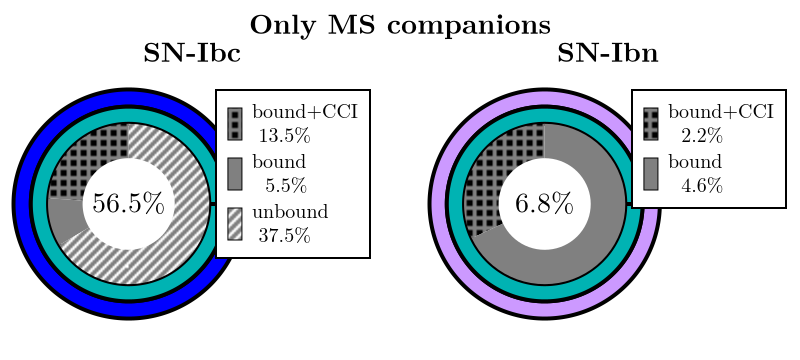

In [33]:

FIG = Figure(size=(400, 180), figure_padding = 1)
set_theme!(theme_latexfonts())

grid = FIG[1,1] = GridLayout()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8

# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
aspect_ratio = 1.5

n = 500
kick_dict = Dict("Inf" => "Inf", "Unbound"=>"Unbound",
                          "MM_n$n" =>      "M16" ,
                          "Hobbs_n$n" =>   "H50" ,
                          "DM25_n$n" =>    "DM25",
                        "COMBINE_n$n" => "K18" ,
                          "Valli25_n$n" => "V25", 
                          "None" => "None"
                          )

# row1=1
# row2=2
row3=1
col1=1
col2=2
ax_pie = Dict()

ax_ghost = Axis( grid[row3,col1:col2],
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Only MS companions")
ax_ghost.rightspinevisible  = false
ax_ghost.topspinevisible    = false
ax_ghost.leftspinevisible   = false
ax_ghost.bottomspinevisible = false

# ax_pie[:IIP] = Axis( grid[row1,col1],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-IIP/L")
# ax_pie[:IIb] = Axis( grid[row2,col1],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-IIb")
ax_pie[:Ibc] = Axis( grid[row3,col1],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "SN-Ibc")

# ax_pie[:SN87A] = Axis( grid[row1,col2],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-87A")
# ax_pie[:IIn] = Axis( grid[row2,col2],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-IIn")
ax_pie[:Ibn] = Axis( grid[row3,col2],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "SN-Ibn")
      
                
colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=style, line_color=color,
                        bg_color= color2)

sn_interface = Dict(:IIP=>"IIP/L", :Ibc=>"Ibc", :SN87A=>"87A",
                     :IIb=>"IIb", :IIn=>"IIn", :Ibn=>"Ibn")

for companion in [:WD, :BH, :NS, :MS, :X]
    color_coding_new[companion]=Dict()
    for extraCCI in [:normal, :CCI]
        color_coding_new[companion][extraCCI] = Dict()
        color_coding_new[companion][extraCCI][:unbound]  = Pattern(colorhatch(RGBAf(0.5,0.5,0.5,1),color2=RGBAf(1.,1.,1.,1), style = :slash))
        # color_coding_new[companion][extraCCI][:unbound]  = color_coding[companion]
        color_coding_new[companion][extraCCI][:TZO]      = color_coding[:TZO]
    end
    color_coding_new[companion][:normal][:bound]    = RGBAf(0.5,0.5,0.5,1)
    color_coding_new[companion][:CCI][:bound]       = Pattern(colorhatch(RGBAf(0.5,0.5,0.5,1),color2=RGBAf(0.,0.,0.,1), style = :plus))

 end

 companions = [:MS, :NS, :WD, :BH, :X]
 state = [:bound, :unbound]
 
state_to_t(state) = Dict(:bound=>"B", :unbound=>"U", :TZO=>"TZO")[state]
normalization = sum([ 
            SNc_direct[ttp][o][c][cci]
            for c in companions 
            for o in state
            for cci in [:CCI, :normal]
            for ttp in [:Ibn, :Ibc]
            ] )/100 # 1

# for ttp in [:IIP, :IIb, :Ibc, :SN87A, :IIn, :Ibn]
for ttp in [:Ibc, :Ibn]
    vals = [ 
            SNc_direct[ttp][o][c][cci] + 1e-16 
            for c in  [:MS]  
            for o in state
            for cci in [:CCI, :normal]
            ]./normalization

    cols = [ color_coding_new[c][cci][o]    
            for c in [:MS] 
            for o in state
            for cci in [:CCI, :normal]
            ]
            

   pie!(ax_pie[ttp], [1]; color=color_coding[ttp], inner_radius=.85,radius =1, strokewidth=2 )
   pie!(ax_pie[ttp], [1]; color=color_coding[:MS], inner_radius=.7,radius =0.85, strokewidth=2 )
#   pie!(ax_pie[ttp], [1]; color=color_coding[ttp], inner_radius=.9,radius =1, strokewidth=2 )
   hatched_pie!(ax_pie[ttp], vals, colors=cols, inner_radius = 0.4, radius =.7, )
    text!(ax_pie[ttp], 0., 0., text=@sprintf("%.1f%%", sum([SNc_direct[ttp][o][:MS][cci]/normalization for cci in [:normal, :CCI] for o in state])), 
    align = (:center, :center))

    yl,yh=-1.1,1.1
    xlims!(ax_pie[ttp],yl,(yh-yl)*aspect_ratio + yl)
    ylims!(ax_pie[ttp],yl, yh)

    ax_pie[ttp].rightspinevisible = false
    ax_pie[ttp].topspinevisible = false
    ax_pie[ttp].leftspinevisible = false
    ax_pie[ttp].bottomspinevisible = false
    
    for o in state 
        for cci in [:CCI, :normal]
            n = SNc_direct[ttp][o][:MS][cci] / normalization
            n<0.049  && continue
            label =  @sprintf("%s%s", o, cci==:CCI ? "+CCI" : "")
            label *= @sprintf("\n%5.1f%%", n)
            barplot!(ax_pie[ttp], [-100], [-100], label = label, color=color_coding_new[:MS][cci][o], strokewidth=.5)
        end
    end
    axislegend(ax_pie[ttp], nbanks=1, labelsize=10, patchsize=[7,16])
end 




save_directory = "../output/ECI/"
outfilename = @sprintf("pies_companion_MS_IbcIbn_%s_%s_%2d_%s.pdf", MERGER_CRITERION, EXP_CRIT, 100*f_B, KICKS)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG

 

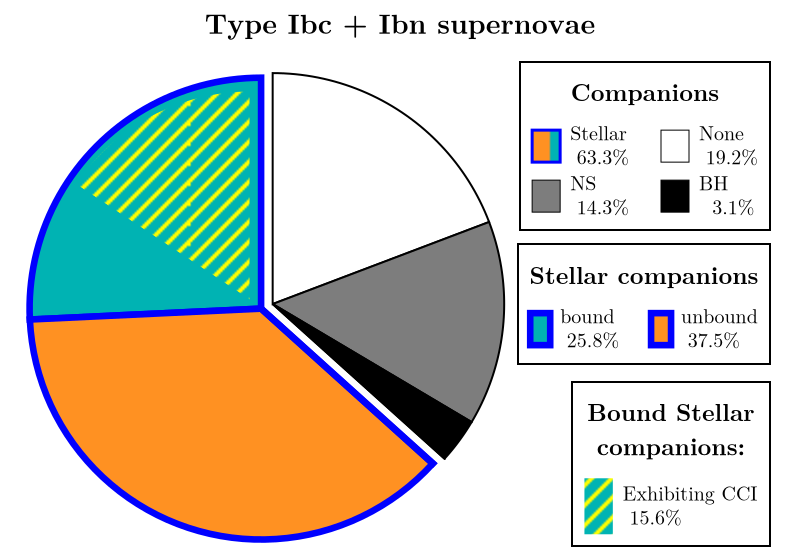

In [13]:

FIG = Figure(size=(400, 280), figure_padding = 1)
set_theme!(theme_latexfonts())

grid = FIG[1,1] = GridLayout()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8

# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
aspect_ratio = 1.5

n = 500
kick_dict = Dict("Inf" => "Inf", "Unbound"=>"Unbound",
                          "MM_n$n" =>      "M16" ,
                          "Hobbs_n$n" =>   "H50" ,
                          "DM25_n$n" =>    "DM25",
                        "COMBINE_n$n" => "K18" ,
                          "Valli25_n$n" => "V25", 
                          "None" => "None"
                          )

# ax_pie[:IIP] = Axis( grid[row1,col1],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-IIP/L")
# ax_pie[:IIb] = Axis( grid[row2,col1],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-IIb")
ax_pie = Axis( grid[1,1],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Type Ibc + Ibn supernovae")

# ax_pie[:SN87A] = Axis( grid[row1,col2],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-87A")
# ax_pie[:IIn] = Axis( grid[row2,col2],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-IIn")
      

colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus, size=92, spacing=8, thickness=2) = make_hatch_pattern(size = size, spacing=spacing, thickness=thickness,
                style=style, line_color=color,
                bg_color= color2)
    

alpha = 1
color_coding = Dict() 
color_coding_new = Dict() 
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding[:BH] = RGBAf(.15, .15, .15 ,alpha) 

alpha=1
color_coding[:RLOF1] = RGBAf(0,1,1 ,alpha)   
color_coding[:RLOF2]= RGBAf(1,0,1 ,alpha)    
color_coding[:M]     =RGBAf(1,1,0 ,alpha)   
color_coding[:NI]    = RGBAf(.55, .55, .55 ,alpha) 

color_coding[:WD] = RGBAf(.6,.6,.6,alpha)   
color_coding[:MS] =  RGBAf(  0/256,180/256,180/256,alpha) 
color_coding[:NS] = RGBAf(125/256,125/256,125/256,alpha)    
color_coding[:BH] = RGBAf(0,0,0,alpha) 
color_coding[:X] = RGBAf(1,1,1,alpha) 
color_coding[:TZO] = RGBAf(1,0,0,alpha) 

color_coding[:bound]   =   RGBAf(  0/256,180/256,180/256,alpha)   
color_coding[:unbound] = RGBAf(255/255, 145/255, 33/245 ,alpha) 
color_coding2 = Dict()

color_coding2[:CCI]    = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(1.,1.,0.,1), style = :slash, spacing = 10, thickness = 3, size=150))
color_coding2[:normal] = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(0.5,0.5,0.5,1), style = :plus))
color_coding2[:normal] = color_coding[:bound]  

sn_interface = Dict(:IIP=>"IIP/L", :Ibc=>"Ibc", :SN87A=>"87A",
                     :IIb=>"IIb", :IIn=>"IIn", :Ibn=>"Ibn")

for companion in [:WD, :BH, :NS, :MS, :X]
    color_coding_new[companion]=Dict()
    for extraCCI in [:normal, :CCI]
        color_coding_new[companion][extraCCI] = Dict()
        color_coding_new[companion][extraCCI][:unbound]  = Pattern(colorhatch(color_coding[companion],color2=RGBAf(1.,1.,1.,1), style = :slash))
        # color_coding_new[companion][extraCCI][:unbound]  = color_coding[companion]
        color_coding_new[companion][extraCCI][:TZO]      = color_coding[:TZO]
    end
    color_coding_new[companion][:normal][:bound]    = color_coding[companion]
    color_coding_new[companion][:CCI][:bound]       = Pattern(colorhatch(color_coding[companion],color2=RGBAf(0.,0.,0.,1), style = :plus))
    
    color_coding_new[companion][:bound]    = color_coding[companion]
    color_coding_new[companion][:unbound]  =  Pattern(colorhatch(color_coding[companion],color2=RGBAf(1.,1.,1.,1), style = :slash))
    color_coding_new[companion][:unbound]  =  color_coding[:unbound]
    color_coding_new[companion][:TZO]  = color_coding[:TZO]

 end


 function hatched_pie!(ax, values::AbstractVector; direction= :anticlockwise,
                      colors,
                      radius=0.4,
                      inner_radius=0.0,
                      offset=π/2,
                      strokewidth=0.0,
                      strokecolor=:black,
                      center = (0,0),
                      normalize = true)

    if any(values .< 0)
        error("All values must be non-negative")
    end
    if length(values) != length(colors)
        error("Length of `values` and `colors` must match")
    end

    total = normalize == true ?  sum(values) : normalize
    total *= direction == :anticlockwise ? 1 : -1
    θ0 = offset
    center = Point2f(center)

    for idx in eachindex(values)
        v = values[idx]
        c = colors[idx]  # Extract individually to avoid conversions

        if v == 0
            continue
        end

        θ1 = θ0 + 2π * v / total
        n = 50
        θs = range(θ0, θ1, length=n)

        outer = [center + radius * Point2f(cos(θ), sin(θ)) for θ in θs]

        if inner_radius == 0
        # Triangle fan: center point followed by arc
                verts = [center]
                append!(verts, outer)
        else
                inner = [center + inner_radius * Point2f(cos(θ), sin(θ)) for θ in reverse(θs)]
                verts = vcat(outer, inner)
        end

        # Use poly! per slice with individual color — avoids list conversion
        poly!(ax, verts; color=c, strokewidth=strokewidth, strokecolor=strokecolor)

        θ0 = θ1
    end

    return nothing
end


companions = [:MS, :X, :NS, :BH, :WD]
state = [:bound, :unbound, :TZO]
 
state_to_t(state) = Dict(:bound=>"B", :unbound=>"U", :TZO=>"TZO")[state]

normalization = sum([ 
            SNc_direct[ttp][o][c][cci]
            for c in companions 
            for o in state
            for cci in [:CCI, :normal]
            for ttp in [:Ibn, :Ibc]
            ] )/100 # 1
# for ttp in [:IIP, :IIb, :Ibc, :SN87A, :IIn, :Ibn]
vals = [ 
        sum([SNc_direct[ttp][o][c][cci]+1e-56 for ttp in [:Ibc,:Ibn]])
        for c in companions 
        for o in state
        for cci in [:CCI, :normal]
        ] ./ normalization
vals2 = [ 
        sum([SNc_direct[ttp][o][c][cci]+1e-56 
                for ttp in [:Ibc,:Ibn] for o in state
                for cci in [:CCI, :normal]])
        for c in companions 
        ] ./ normalization
vals2b = [ 
        sum([SNc_direct[ttp][o][c][cci]+1e-56 
                for ttp in [:Ibc,:Ibn] for o in state
                for cci in [:CCI, :normal]])
        for c in  [:X, :NS, :BH, :WD] 
        ] ./ normalization
vals3 = [ 
        sum([SNc_direct[ttp][o][:MS][cci]+1e-56 
                for ttp in [:Ibc,:Ibn] 
                for cci in [:CCI, :normal]
        ])
        for o in state
        ] ./ normalization
vals4 = [ 
        sum([SNc_direct[ttp][:bound][:MS][cci]+1e-56 
                for ttp in [:Ibc,:Ibn] 
        ])
        for cci in [:CCI, :normal]
        ] ./ normalization

cols = [ color_coding_new[c][cci][o]    
        for c in companions 
        for o in state
        for cci in [:CCI, :normal]
        ]
cols2 = [ color_coding_new[c][:normal][:bound]    
        for c in companions 
        ]
cols2b = [ color_coding_new[c][:normal][:bound]    
        for c in  [:X, :NS, :BH, :WD] 
        ]
cols3 = [ color_coding_new[:MS][o]    
        for o in state
        ]
cols4 = [ color_coding2[cci]    
        for cci in [:CCI, :normal]
        ]
            

# hatched_pie!(ax_pie, vals2, colors=cols2, inner_radius = 0., radius =1, 
#             strokecolor = :black, strokewidth = 1, normalize = 100)
hatched_pie!(ax_pie, vals2b, colors=cols2b, inner_radius = 0., radius =1, direction=:clockwise,
            strokecolor = :black, strokewidth = 1, normalize = 100)
# hatched_pie!(ax_pie, vals, colors=cols, inner_radius = 0.5, radius =1.)
hatched_pie!(ax_pie, vals3, colors=cols3, inner_radius = 0., radius =1,  
            strokecolor = :blue, strokewidth = 3.3, normalize=100, center = (-0.05,-0.02))
hatched_pie!(ax_pie, vals4, colors=cols4, inner_radius = 0., radius =.9,  
            strokecolor = :black, strokewidth = 0, normalize=100, center = (-0.1,0.02))


yl,yh=-1.1,1.1
xlims!(ax_pie,yl,(yh-yl)*aspect_ratio + yl)
ylims!(ax_pie,yl, yh)

ax_pie.rightspinevisible = false
ax_pie.topspinevisible = false
ax_pie.leftspinevisible = false
ax_pie.bottomspinevisible = false
    



color_coding[:MS] =  Pattern(colorhatch(  RGBAf(255/255, 145/255, 33/245 ,alpha),color2=RGBAf(  0/256,180/256,180/256,alpha),
                        size = 49, style = :horizontal, spacing=15, thickness=8))

bar_companion = []
for c in  [:MS, :X, :NS, :BH, :WD]  
    n = sum([SNc_direct[ttp][o][c][cci] for o in state for cci in [:normal, :CCI] for ttp in [:Ibc,:Ibn]])/normalization
    n<0.01  && continue
    label =  @sprintf("%s", c == :MS ? "Stellar" : c)
    label == "X" && (label = "None")
    label == "MSTZO" && (label = "TZO")
    label *= @sprintf("\n%5.1f%%", n)
    b = barplot!(ax_pie, [-100], [-100], label = label, color=color_coding[c], strokewidth= c == :MS ? 1.5 : .5, strokecolor = c==:MS ? :blue : :black)
        push!(bar_companion, b)
end

bar_state = []
for s in [:bound, :unbound] 
    n = sum([SNc_direct[ttp][s][:MS][cci] for cci in [:normal, :CCI] for ttp in [:Ibc,:Ibn]])/normalization
    n<0.01  && continue
    label =  @sprintf("%s", s)
    label *= @sprintf("\n%5.1f%%", n)
    b = barplot!(ax_pie, [-100], [-100], label = label, color=color_coding[s], strokewidth=3.3, strokecolor = :blue)
        push!(bar_state, b)
end

bar_cci = []
for cci in [:CCI] 
    n = sum([SNc_direct[ttp][:bound][:MS][cci] for ttp in [:Ibc,:Ibn]])/normalization
    n<0.001  && continue
    label =  @sprintf("%s", cci == :CCI ? "Exhibiting CCI" : "only\nECI")
    label *= @sprintf("\n%5.1f%%", n)
    b = barplot!(ax_pie, [-100], [-100], label = label, color=color_coding2[cci], strokewidth=0)
        push!(bar_cci, b)
end

patchsize=[14,16]
axislegend(ax_pie, [b for b in bar_companion], [b.label[] for b in bar_companion], "Companions", 
                nbanks=2, labelsize=10, patchsize=patchsize,position = :rt, titlesize=12)
axislegend(ax_pie, [bar_state[1], bar_state[2]], [bar_state[1].label[], bar_state[2].label[]], "Stellar companions", 
                nbanks=2, labelsize=10, patchsize=[patchsize[1]-4, patchsize[2]] ,position = :rc, titlesize=12)
axislegend(ax_pie, [b for b in bar_cci], [b.label[] for b in bar_cci], "Bound Stellar\ncompanions:",
                nbanks=2, labelsize=10, patchsize=[patchsize[1]+.2, patchsize[2]+12],position = :rb, titlesize=12)



save_directory = "../output/ECI/"
outfilename = @sprintf("pies_companion_detail_%s_%s_%2d_%s.pdf", MERGER_CRITERION, EXP_CRIT, 100*f_B, KICKS)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG

 

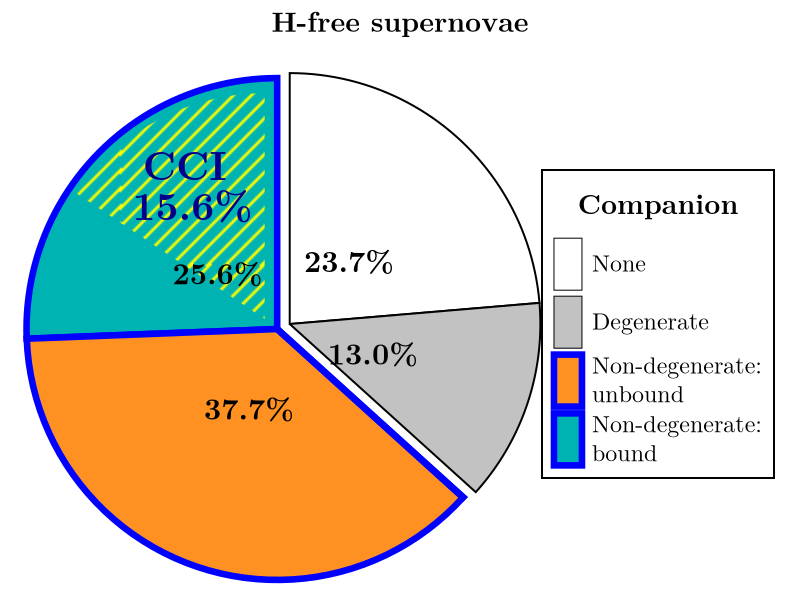

In [15]:

FIG = Figure(size=(400, 300), figure_padding = 0)
set_theme!(theme_latexfonts())

grid = FIG[1,1] = GridLayout()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8

# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
aspect_ratio = 1.4

n = 500
kick_dict = Dict("Inf" => "Inf", "Unbound"=>"Unbound",
                          "MM_n$n" =>      "M16" ,
                          "Hobbs_n$n" =>   "H50" ,
                          "DM25_n$n" =>    "DM25",
                        "COMBINE_n$n" => "K18" ,
                          "Valli25_n$n" => "V25", 
                          "None" => "None"
                          )

# ax_pie[:IIP] = Axis( grid[row1,col1],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-IIP/L")
# ax_pie[:IIb] = Axis( grid[row2,col1],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-IIb")
ax_pie = Axis( grid[1,1],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "H-free supernovae")

# ax_pie[:SN87A] = Axis( grid[row1,col2],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-87A")
# ax_pie[:IIn] = Axis( grid[row2,col2],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-IIn")
      

colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus, size=92, spacing=8, thickness=2) = make_hatch_pattern(size = size, spacing=spacing, thickness=thickness,
                style=style, line_color=color,
                bg_color= color2)
    

alpha = 1
color_coding = Dict() 
color_coding_new = Dict() 
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding[:BH] = RGBAf(.15, .15, .15 ,alpha) 

alpha=1
color_coding[:RLOF1] = RGBAf(0,1,1 ,alpha)   
color_coding[:RLOF2]= RGBAf(1,0,1 ,alpha)    
color_coding[:M]     =RGBAf(1,1,0 ,alpha)   
color_coding[:NI]    = RGBAf(.55, .55, .55 ,alpha) 

color_coding[:WD] = RGBAf(.6,.6,.6,alpha)   
color_coding[:MS] =  RGBAf(  0/256,180/256,180/256,alpha) 
color_coding[:NS] = RGBAf(195/256,195/256,195/256,alpha)    
color_coding[:BH] = RGBAf(0,0,0,alpha) 
color_coding[:deg] = color_coding[:NS]
color_coding[:X] = RGBAf(1,1,1,alpha) 
color_coding[:TZO] = RGBAf(1,0,0,alpha) 

color_coding[:bound]   =   RGBAf(  0/256,180/256,180/256,alpha)   
color_coding[:unbound] = RGBAf(255/255, 145/255, 33/245 ,alpha) 
color_coding2 = Dict()

color_coding2[:CCI]    = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(1.,1.,0.,1), style = :slash, spacing = 9, thickness = 3, size=109))
color_coding2[:normal] = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(0.5,0.5,0.5,1), style = :plus))
color_coding2[:normal] = color_coding[:bound]  

sn_interface = Dict(:IIP=>"IIP/L", :Ibc=>"Ibc", :SN87A=>"87A",
                     :IIb=>"IIb", :IIn=>"IIn", :Ibn=>"Ibn")

for companion in [:deg, :MS, :X]
    color_coding_new[companion]=Dict()
    for extraCCI in [:normal, :CCI]
        color_coding_new[companion][extraCCI] = Dict()
        color_coding_new[companion][extraCCI][:unbound]  = Pattern(colorhatch(color_coding[companion],color2=RGBAf(1.,1.,1.,1), style = :slash))
        # color_coding_new[companion][extraCCI][:unbound]  = color_coding[companion]
        color_coding_new[companion][extraCCI][:TZO]      = color_coding[:TZO]
    end
    color_coding_new[companion][:normal][:bound]    = color_coding[companion]
    color_coding_new[companion][:CCI][:bound]       = Pattern(colorhatch(color_coding[companion],color2=RGBAf(0.,0.,0.,1), style = :plus))
    
    color_coding_new[companion][:bound]    = color_coding[companion]
    color_coding_new[companion][:unbound]  =  Pattern(colorhatch(color_coding[companion],color2=RGBAf(1.,1.,1.,1), style = :slash))
    color_coding_new[companion][:unbound]  =  color_coding[:unbound]
    color_coding_new[companion][:TZO]  = color_coding[:TZO]

 end


 function hatched_pie!(ax, values::AbstractVector; direction= :anticlockwise,
                      colors,
                      radius=0.4,
                      inner_radius=0.0,
                      offset=π/2,
                      strokewidth=0.0,
                      strokecolor=:black,
                      center = (0,0),
                      normalize = true,
                      draw_percentage = false,
                      r_draw = 0.5, fontsize=10,
                      draw_text_only=false)

    if any(values .< 0)
        error("All values must be non-negative")
    end
    if length(values) != length(colors)
        error("Length of `values` and `colors` must match")
    end

    total = normalize == true ?  sum(values) : normalize
    total *= direction == :anticlockwise ? 1 : -1
    θ0 = offset
    center = Point2f(center)

    for idx in eachindex(values)
        v = values[idx]
        c = colors[idx]  # Extract individually to avoid conversions

        if v == 0
            continue
        end

        θ1 = θ0 + 2π * v / total
        n = 50
        θs = range(θ0, θ1, length=n)

        outer = [center + radius * Point2f(cos(θ), sin(θ)) for θ in θs]

        if inner_radius == 0
        # Triangle fan: center point followed by arc
                verts = [center]
                append!(verts, outer)
        else
                inner = [center + inner_radius * Point2f(cos(θ), sin(θ)) for θ in reverse(θs)]
                verts = vcat(outer, inner)
        end

        # Use poly! per slice with individual color — avoids list conversion
        !draw_text_only && poly!(ax, verts; color=c, strokewidth=strokewidth, strokecolor=strokecolor)
        draw_percentage && v> 0.1 && text!(ax, center .+ r_draw .* (cos((θ1+θ0)/2), sin((θ1+θ0)/2)),
                                 text = rich(@sprintf("%3.1f%%",v), font=:bold),
                                 fontsize=fontsize, align =(:center,:center))
        θ0 = θ1
    end

    return nothing
end


companions = [:MS, :deg, :X]
state = [:bound, :unbound, :TZO]
 
state_to_t(state) = Dict(:bound=>"B", :unbound=>"U", :TZO=>"TZO")[state]

normalization = sum([ 
            SNc_direct2[ttp][o][c][cci]
            for c in companions 
            for o in state
            for cci in [:CCI, :normal]
            for ttp in [:Ibn, :Ibc]
            ] )/100 # 1
# for ttp in [:IIP, :IIb, :Ibc, :SN87A, :IIn, :Ibn]
vals = [ 
        sum([SNc_direct2[ttp][o][c][cci]+1e-56 for ttp in [:Ibc,:Ibn]])
        for c in companions 
        for o in state
        for cci in [:CCI, :normal]
        ] ./ normalization
vals2 = [ 
        sum([SNc_direct2[ttp][o][c][cci]+1e-56 
                for ttp in [:Ibc,:Ibn] for o in state
                for cci in [:CCI, :normal]])
        for c in companions 
        ] ./ normalization
vals2b = [ 
        sum([SNc_direct2[ttp][o][c][cci]+1e-56 
                for ttp in [:Ibc,:Ibn] for o in state
                for cci in [:CCI, :normal]])
        for c in  [:X, :deg] 
        ] ./ normalization
vals3 = [ 
        sum([SNc_direct2[ttp][o][:MS][cci]+1e-56 
                for ttp in [:Ibc,:Ibn] 
                for cci in [:CCI, :normal]
        ])
        for o in state
        ] ./ normalization
vals4 = [ 
        sum([SNc_direct2[ttp][:bound][:MS][cci]+1e-56 
                for ttp in [:Ibc,:Ibn] 
        ])
        for cci in [:CCI]
        ] ./ normalization

cols = [ color_coding_new[c][cci][o]    
        for c in companions 
        for o in state
        for cci in [:CCI, :normal]
        ]
cols2 = [ color_coding_new[c][:normal][:bound]    
        for c in companions 
        ]
cols2b = [ color_coding_new[c][:normal][:bound]    
        for c in  [:X, :deg] 
        ]
cols3 = [ color_coding_new[:MS][o]    
        for o in state
        ]
cols4 = [ color_coding2[cci]    
        for cci in [:CCI]
        ]
            

hatched_pie!(ax_pie, vals2b, colors=cols2b, inner_radius = 0., radius =1, direction=:clockwise,
            strokecolor = :black, strokewidth = 1, normalize = 100, draw_percentage=false)
hatched_pie!(ax_pie, vals3, colors=cols3, inner_radius = 0., radius =1,  
            strokecolor = :blue, strokewidth = 3.3, normalize=100, center = (-0.05,-0.02), draw_percentage=false)
hatched_pie!(ax_pie, vals4, colors=cols4, inner_radius = 0., radius =.9,  
            strokecolor = :black, strokewidth = 0, normalize=100, center = (-0.1,0.02))

            hatched_pie!(ax_pie, vals2b, colors=cols2b, inner_radius = 0., radius =1, direction=:clockwise,
            strokecolor = :black, strokewidth = 1, normalize = 100, draw_percentage=true, r_draw=0.35, fontsize=15, draw_text_only=true)
hatched_pie!(ax_pie, vals3, colors=cols3, inner_radius = 0., radius =1,  
            strokecolor = :blue, strokewidth = 3.3, normalize=100, center = (-0.05,-0.02), draw_percentage=true, r_draw=0.33, fontsize=15, draw_text_only=true)


yl,yh=-1.1,1.1
xlims!(ax_pie,yl,(yh-yl)*aspect_ratio + yl)
ylims!(ax_pie,yl, yh)

ax_pie.rightspinevisible = false
ax_pie.topspinevisible = false
ax_pie.leftspinevisible = false
ax_pie.bottomspinevisible = false
    



color_coding[:MS] =  Pattern(colorhatch(  RGBAf(255/255, 145/255, 33/245 ,alpha),color2=RGBAf(  0/256,180/256,180/256,alpha),
                        size = 49, style = :horizontal, spacing=15, thickness=8))

bar_companion = []
for c in  [:X, :deg]  
    n = sum([SNc_direct2[ttp][o][c][cci] for o in state for cci in [:normal, :CCI] for ttp in [:Ibc,:Ibn]])/normalization
    n<0.01  && continue
    label =  Dict(:MS =>"MS", :deg=>"Degenerate", :X=>"None")[c]
#     label *= @sprintf("\n%5.1f%%", n)
    b = barplot!(ax_pie, [-100], [-100], label = label, color=color_coding[c], strokewidth= c == :MS ? 1.5 : .5, strokecolor = c==:MS ? :blue : :black)
        push!(bar_companion, b)
end

bar_state = []
for s in [:unbound, :bound] 
    n = sum([SNc_direct2[ttp][s][:MS][cci] for cci in [:normal, :CCI] for ttp in [:Ibc,:Ibn]])/normalization
    n<0.01  && continue
    label =  Dict(:bound =>"Non-degenerate:\nbound", :unbound=>"Non-degenerate:\nunbound")[s]
#     label *= @sprintf("\n%5.1f%%", n)
    b = barplot!(ax_pie, [-100], [-100], label = label, color=color_coding[s], strokewidth=3.3, strokecolor = :blue)
        push!(bar_state, b)
end

bar_cci = []
for cci in [:CCI] 
    n = sum([SNc_direct2[ttp][:bound][:MS][cci] for ttp in [:Ibc,:Ibn]])/normalization
    n<0.001  && continue
    label =  @sprintf("%s", cci == :CCI ? "+CCI" : "only\nECI")
#     label *= @sprintf("\n%5.1f%%", n)
    b = barplot!(ax_pie, [-100], [-100], label = label, color=color_coding2[cci], strokewidth=0)
        push!(bar_cci, b)
end
bar_cci= []
patchsize=[14,14]
axislegend(ax_pie, [b for b in [bar_companion ;bar_state; bar_cci ]], [b.label[] for b in [bar_companion ;bar_state;  bar_cci ]],  "Companion",
                 nbanks=1, labelsize=12, patchsize=[patchsize[1], patchsize[2]+12],position = :rc, titlesize=14)
# axislegend(ax_pie, [b for b in bar_cci], [b.label[] for b in bar_cci], "Bound Stellar\ncompanions:",
#                 nbanks=2, labelsize=10, patchsize=[patchsize[1]+.2, patchsize[2]+12],position = :rb, titlesize=12)
r=0.33
# θ,v= .7π/4, 23.7; text!(ax_pie, r*cos(θ), r*sin(θ); align =(:center,:center),text=rich(@sprintf("%5.1f%%",v), color=:black, font=:bold), fontsize=17)
# θ,v=-.7π/12, 13.0; text!(ax_pie, r*cos(θ), r*sin(θ); align =(:center,:center),text=rich(@sprintf("%5.1f%%",v), color=:white, font=:bold), fontsize=17)
# θ,v=-2.3π/3, 37.5; text!(ax_pie, .8*r*cos(θ), .8*r*sin(θ); align =(:center,:center),text=rich(@sprintf("%5.1f%%",v), color=:black, font=:bold), fontsize=17)
# θ,v=4.5π/5, 25.8; text!(ax_pie, r*cos(θ), r*sin(θ); align =(:center,:center),text=rich(@sprintf("%5.1f%%",v), color=:black, font=:bold), fontsize=17)
r=0.7
# θ,v=3.4π/5, 15.6; text!(ax_pie, r*cos(θ), r*sin(θ); align =(:center,:center),text=rich(@sprintf("%5.1f%%",v), color=:white, font=:bold), fontsize=23)
θ,v=3.52π/5,  sum([SNc_direct2[ttp][:bound][:MS][:CCI] for ttp in [:Ibc,:Ibn]])/normalization
text!(ax_pie, r*cos(θ), r*sin(θ); align =(:center,:center),text=rich(@sprintf("CCI\n%5.1f%%",v), color=:darkblue, font=:bold), fontsize=20)


save_directory = "../output/ECI/"
outfilename = @sprintf("pies_companion_detail_%s_%s_%2d_%s.pdf", MERGER_CRITERION, EXP_CRIT, 100*f_B, KICKS)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG

 

In [ ]:

FIG = Figure(size=(400, 300), figure_padding = 0)
set_theme!(theme_latexfonts())

grid = FIG[1,1] = GridLayout()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8

# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
aspect_ratio = 1.4

n = 500
kick_dict = Dict("Inf" => "Inf", "Unbound"=>"Unbound",
                          "MM_n$n" =>      "M16" ,
                          "Hobbs_n$n" =>   "H50" ,
                          "DM25_n$n" =>    "DM25",
                        "COMBINE_n$n" => "K18" ,
                          "Valli25_n$n" => "V25", 
                          "None" => "None"
                          )

# ax_pie[:IIP] = Axis( grid[row1,col1],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-IIP/L")
# ax_pie[:IIb] = Axis( grid[row2,col1],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-IIb")
ax_pie = Axis( grid[1,1],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "H-free supernovae\n")

# ax_pie[:SN87A] = Axis( grid[row1,col2],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-87A")
# ax_pie[:IIn] = Axis( grid[row2,col2],aspect=aspect_ratio,
#                 ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
#                 xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
#                 xgridvisible = false, ygridvisible = false,
#                 title = "SN-IIn")
      

colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus, size=92, spacing=8, thickness=2) = make_hatch_pattern(size = size, spacing=spacing, thickness=thickness,
                style=style, line_color=color,
                bg_color= color2)
    

alpha = 1
color_coding = Dict() 
color_coding_new = Dict() 
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding[:BH] = RGBAf(.15, .15, .15 ,alpha) 

alpha=1
color_coding[:RLOF1] = RGBAf(0,1,1 ,alpha)   
color_coding[:RLOF2]= RGBAf(1,0,1 ,alpha)    
color_coding[:M]     =RGBAf(1,1,0 ,alpha)   
color_coding[:NI]    = RGBAf(.55, .55, .55 ,alpha) 

color_coding[:WD] = RGBAf(.6,.6,.6,alpha)   
color_coding[:MS] =  RGBAf(  0/256,180/256,180/256,alpha) 
color_coding[:NS] = RGBAf(195/256,195/256,195/256,alpha)    
color_coding[:BH] = RGBAf(0,0,0,alpha) 
color_coding[:deg] = color_coding[:NS]
color_coding[:X] = RGBAf(1,1,1,alpha) 
color_coding[:TZO] = RGBAf(1,0,0,alpha) 

color_coding[:bound]   =   RGBAf(  0/256,180/256,180/256,alpha)   
color_coding[:unbound] = RGBAf(255/255, 145/255, 33/245 ,alpha) 
color_coding2 = Dict()

color_coding2[:CCI]    = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(1.,1.,0.,1), style = :slash, spacing = 9, thickness = 3, size=109))
color_coding2[:normal] = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(0.5,0.5,0.5,1), style = :plus))
color_coding2[:normal] = color_coding[:bound]  

sn_interface = Dict(:IIP=>"IIP/L", :Ibc=>"Ibc", :SN87A=>"87A",
                     :IIb=>"IIb", :IIn=>"IIn", :Ibn=>"Ibn")

for companion in [:deg, :MS, :X]
    color_coding_new[companion]=Dict()
    for extraCCI in [:normal, :CCI]
        color_coding_new[companion][extraCCI] = Dict()
        color_coding_new[companion][extraCCI][:unbound]  = Pattern(colorhatch(color_coding[companion],color2=RGBAf(1.,1.,1.,1), style = :slash))
        # color_coding_new[companion][extraCCI][:unbound]  = color_coding[companion]
        color_coding_new[companion][extraCCI][:TZO]      = color_coding[:TZO]
    end
    color_coding_new[companion][:normal][:bound]    = color_coding[companion]
    color_coding_new[companion][:CCI][:bound]       = Pattern(colorhatch(color_coding[companion],color2=RGBAf(0.,0.,0.,1), style = :plus))
    
    color_coding_new[companion][:bound]    = color_coding[companion]
    color_coding_new[companion][:unbound]  =  Pattern(colorhatch(color_coding[companion],color2=RGBAf(1.,1.,1.,1), style = :slash))
    color_coding_new[companion][:unbound]  =  color_coding[:unbound]
    color_coding_new[companion][:TZO]  = color_coding[:TZO]

 end


 function hatched_pie!(ax, values::AbstractVector; direction= :anticlockwise,
                      colors,
                      radius=0.4,
                      inner_radius=0.0,
                      offset=π/2,
                      strokewidth=0.0,
                      strokecolor=:black,
                      center = (0,0),
                      normalize = true,
                      draw_percentage = false,
                      r_draw = 0.5, fontsize=10,
                      draw_text_only=false)

    if any(values .< 0)
        error("All values must be non-negative")
    end
    if length(values) != length(colors)
        error("Length of `values` and `colors` must match")
    end

    total = normalize == true ?  sum(values) : normalize
    total *= direction == :anticlockwise ? 1 : -1
    θ0 = offset
    center = Point2f(center)

    for idx in eachindex(values)
        v = values[idx]
        c = colors[idx]  # Extract individually to avoid conversions

        if v == 0
            continue
        end

        θ1 = θ0 + 2π * v / total
        n = 50
        θs = range(θ0, θ1, length=n)

        outer = [center + radius * Point2f(cos(θ), sin(θ)) for θ in θs]

        if inner_radius == 0
        # Triangle fan: center point followed by arc
                verts = [center]
                append!(verts, outer)
        else
                inner = [center + inner_radius * Point2f(cos(θ), sin(θ)) for θ in reverse(θs)]
                verts = vcat(outer, inner)
        end

        # Use poly! per slice with individual color — avoids list conversion
        !draw_text_only && poly!(ax, verts; color=c, strokewidth=strokewidth, strokecolor=strokecolor)
        draw_percentage && v> 0.1 && text!(ax, center .+ r_draw .* (cos((θ1+θ0)/2), sin((θ1+θ0)/2)),
                                 text = rich(@sprintf("%3.1f%%",v), font=:bold),
                                 fontsize=fontsize, align =(:center,:center))
        θ0 = θ1
    end

    return nothing
end


companions = [:MS, :deg, :X]
state = [:bound, :unbound, :TZO]
 
state_to_t(state) = Dict(:bound=>"B", :unbound=>"U", :TZO=>"TZO")[state]

normalization = sum([ 
            SNc_direct2[ttp][o][c][cci]
            for c in companions 
            for o in state
            for cci in [:CCI, :normal]
            for ttp in [:Ibn, :Ibc]
            ] )/100 # 1
# for ttp in [:IIP, :IIb, :Ibc, :SN87A, :IIn, :Ibn]
vals = [ 
        sum([SNc_direct2[ttp][o][c][cci]+1e-56 for ttp in [:Ibc,:Ibn]])
        for c in companions 
        for o in state
        for cci in [:CCI, :normal]
        ] ./ normalization
vals2 = [ 
        sum([SNc_direct2[ttp][o][c][cci]+1e-56 
                for ttp in [:Ibc,:Ibn] for o in state
                for cci in [:CCI, :normal]])
        for c in companions 
        ] ./ normalization
vals2b = [ 
        sum([SNc_direct2[ttp][o][c][cci]+1e-56 
                for ttp in [:Ibc,:Ibn] for o in state
                for cci in [:CCI, :normal]])
        for c in  [:X, :deg] 
        ] ./ normalization
vals3 = [ 
        sum([SNc_direct2[ttp][o][:MS][cci]+1e-56 
                for ttp in [:Ibc,:Ibn] 
                for cci in [:CCI, :normal]
        ])
        for o in state
        ] ./ normalization
vals4 = [ 
        sum([SNc_direct2[ttp][:bound][:MS][cci]+1e-56 
                for ttp in [:Ibc,:Ibn] 
        ])
        for cci in [:CCI]
        ] ./ normalization

cols = [ color_coding_new[c][cci][o]    
        for c in companions 
        for o in state
        for cci in [:CCI, :normal]
        ]
cols2 = [ color_coding_new[c][:normal][:bound]    
        for c in companions 
        ]
cols2b = [ color_coding_new[c][:normal][:bound]    
        for c in  [:X, :deg] 
        ]
cols3 = [ color_coding_new[:MS][o]    
        for o in state
        ]
cols4 = [ color_coding2[cci]    
        for cci in [:CCI]
        ]
            

hatched_pie!(ax_pie, vals2b, colors=cols2b, inner_radius = 0., radius =1, direction=:clockwise,
            strokecolor = :black, strokewidth = 1, normalize = 100, draw_percentage=false)
hatched_pie!(ax_pie, vals3, colors=cols3, inner_radius = 0., radius =1,  
            strokecolor = :blue, strokewidth = 3.3, normalize=100, center = (-0.05,-0.02), draw_percentage=false)
hatched_pie!(ax_pie, vals4, colors=cols4, inner_radius = 0., radius =.9,  
            strokecolor = :black, strokewidth = 0, normalize=100, center = (-0.1,0.02))

            hatched_pie!(ax_pie, vals2b, colors=cols2b, inner_radius = 0., radius =1, direction=:clockwise,
            strokecolor = :black, strokewidth = 1, normalize = 100, draw_percentage=true, r_draw=0.35, fontsize=15, draw_text_only=true)
hatched_pie!(ax_pie, vals3, colors=cols3, inner_radius = 0., radius =1,  
            strokecolor = :blue, strokewidth = 3.3, normalize=100, center = (-0.05,-0.02), draw_percentage=true, r_draw=0.33, fontsize=15, draw_text_only=true)


yl,yh=-1.1,1.1
xlims!(ax_pie,yl,(yh-yl)*aspect_ratio + yl)
ylims!(ax_pie,yl, yh)

ax_pie.rightspinevisible = false
ax_pie.topspinevisible = false
ax_pie.leftspinevisible = false
ax_pie.bottomspinevisible = false
    



color_coding[:MS] =  Pattern(colorhatch(  RGBAf(255/255, 145/255, 33/245 ,alpha),color2=RGBAf(  0/256,180/256,180/256,alpha),
                        size = 49, style = :horizontal, spacing=15, thickness=8))

bar_companion = []
for c in  [:X, :deg]  
    n = sum([SNc_direct2[ttp][o][c][cci] for o in state for cci in [:normal, :CCI] for ttp in [:Ibc,:Ibn]])/normalization
    n<0.01  && continue
    label =  Dict(:MS =>"MS", :deg=>"Degenerate", :X=>"None")[c]
#     label *= @sprintf("\n%5.1f%%", n)
    b = barplot!(ax_pie, [-100], [-100], label = label, color=color_coding[c], strokewidth= c == :MS ? 1.5 : .5, strokecolor = c==:MS ? :blue : :black)
        push!(bar_companion, b)
end

bar_state = []
for s in [:unbound, :bound] 
    n = sum([SNc_direct2[ttp][s][:MS][cci] for cci in [:normal, :CCI] for ttp in [:Ibc,:Ibn]])/normalization
    n<0.01  && continue
    label =  Dict(:bound =>"Non-degenerate:\nbound", :unbound=>"Non-degenerate:\nunbound")[s]
#     label *= @sprintf("\n%5.1f%%", n)
    b = barplot!(ax_pie, [-100], [-100], label = label, color=color_coding[s], strokewidth=3.3, strokecolor = :blue)
        push!(bar_state, b)
end

bar_cci = []
for cci in [:CCI] 
    n = sum([SNc_direct2[ttp][:bound][:MS][cci] for ttp in [:Ibc,:Ibn]])/normalization
    n<0.001  && continue
    label =  @sprintf("%s", cci == :CCI ? "+CCI" : "only\nECI")
#     label *= @sprintf("\n%5.1f%%", n)
    b = barplot!(ax_pie, [-100], [-100], label = label, color=color_coding2[cci], strokewidth=0)
        push!(bar_cci, b)
end
bar_cci= []
patchsize=[14,14]
axislegend(ax_pie, [b for b in [bar_companion ;bar_state; bar_cci ]], [b.label[] for b in [bar_companion ;bar_state;  bar_cci ]],  "Companion",
                 nbanks=1, labelsize=12, patchsize=[patchsize[1], patchsize[2]+12],position = :rc, titlesize=14)
# axislegend(ax_pie, [b for b in bar_cci], [b.label[] for b in bar_cci], "Bound Stellar\ncompanions:",
#                 nbanks=2, labelsize=10, patchsize=[patchsize[1]+.2, patchsize[2]+12],position = :rb, titlesize=12)
r=0.33
# θ,v= .7π/4, 23.7; text!(ax_pie, r*cos(θ), r*sin(θ); align =(:center,:center),text=rich(@sprintf("%5.1f%%",v), color=:black, font=:bold), fontsize=17)
# θ,v=-.7π/12, 13.0; text!(ax_pie, r*cos(θ), r*sin(θ); align =(:center,:center),text=rich(@sprintf("%5.1f%%",v), color=:white, font=:bold), fontsize=17)
# θ,v=-2.3π/3, 37.5; text!(ax_pie, .8*r*cos(θ), .8*r*sin(θ); align =(:center,:center),text=rich(@sprintf("%5.1f%%",v), color=:black, font=:bold), fontsize=17)
# θ,v=4.5π/5, 25.8; text!(ax_pie, r*cos(θ), r*sin(θ); align =(:center,:center),text=rich(@sprintf("%5.1f%%",v), color=:black, font=:bold), fontsize=17)
r=0.7
# θ,v=3.4π/5, 15.6; text!(ax_pie, r*cos(θ), r*sin(θ); align =(:center,:center),text=rich(@sprintf("%5.1f%%",v), color=:white, font=:bold), fontsize=23)
θ,v=3.52π/5,  sum([SNc_direct2[ttp][:bound][:MS][:CCI] for ttp in [:Ibc,:Ibn]])/normalization
text!(ax_pie, r*cos(θ), r*sin(θ); align =(:center,:center),text=rich(@sprintf("CCI\n%5.1f%%",v), color=:darkblue, font=:bold), fontsize=20)


save_directory = "../output/ECI/"
outfilename = @sprintf("pies_companion_detail_%s_%s_%2d_%s.pdf", MERGER_CRITERION, EXP_CRIT, 100*f_B, KICKS)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG

 

## Tables

In [7]:

does_eci        = ECI .&&  (tau_ECI .> tau_periastron)
post_SN_bound   = does_eci .&& (post_SN_orbit .== :bound)            
post_SN_unbound = does_eci .&& (post_SN_orbit .== :unbound) .&& (tau_periastron .>= 0.001)       
post_SN_u_noperi= does_eci .&& (post_SN_orbit .== :unbound) .&& (tau_periastron .<  0.001)    
post_SN_dc      = does_eci .&& (post_SN_orbit .== :direct_collision) 
post_SN_unknown = does_eci .&& (post_SN_orbit .== :unkown)               



sum_pdfs(prg,sn,filter) = sum(pdfs[ (prgs .== prg) .&& (SNe .== sn) .&& filter])


sn_types = [:IIP, :SN87A, :IIb, :IIn, :Ibc, :Ibn]

@printf("%5s - %5s : %5s %6s %8s %8s %8s %8s\n", "PRG", "SN", "%", "ECI(%)", "Bound", "Unbound", "(no-peri)", "collision")

for prg in ["MT-1", "NI-1", "MT-2", "NI-2", "NI-S", "M"]
    for sn in sn_types
        number_sne = sum_pdfs(prg, sn, true)
        number_sne <= 0.001 && continue
        @printf("%5s - %5s : %5.2f ", prg, sn, number_sne)

               
        number_sne_ECI = sum_pdfs(prg, sn,  does_eci)
        number_sne_ECI >  0 && @printf("%8.2f", number_sne_ECI )
        number_sne_ECI == 0 && @printf("%8d", number_sne_ECI )
        

        n_eci_bound = sum_pdfs(prg, sn,  post_SN_bound )
        n_eci_bound >  0 && @printf("%8.2f", n_eci_bound )
        n_eci_bound == 0 && @printf("%8d", n_eci_bound )
        
        n_eci_unbound = sum_pdfs(prg, sn,  post_SN_unbound )
        n_eci_unbound >  0 && @printf("%8.2f", n_eci_unbound )
        n_eci_unbound == 0 && @printf("%8d", n_eci_unbound )

        n_eci_unbound = sum_pdfs(prg, sn,  post_SN_u_noperi )
        n_eci_unbound >  0 && @printf("%8.2f", n_eci_unbound )
        n_eci_unbound == 0 && @printf("%8d", n_eci_unbound )

        n_eci_dc = sum_pdfs(prg, sn,  post_SN_dc )
        n_eci_dc >  0 && @printf("%8.2f", n_eci_dc )
        n_eci_dc == 0 && @printf("%8d", n_eci_dc )
        
        @printf("\n")

    end
    @printf("\n")
end



  PRG -    SN :     % ECI(%)    Bound  Unbound (no-peri) collision
 MT-1 -   IIP :  0.11        0       0       0       0       0
 MT-1 -   IIb :  1.12        0       0       0       0       0
 MT-1 -   IIn :  2.23     0.02       0       0    0.02    0.00
 MT-1 -   Ibc : 17.45     6.79    5.79    0.50    0.51       0
 MT-1 -   Ibn :  2.47     0.86    0.86       0       0       0

 NI-1 -   IIP :  4.59     0.01       0       0       0    0.01
 NI-1 -   IIb :  0.09     0.00       0       0       0    0.00
 NI-1 -   Ibc :  3.00     0.19    0.00    0.08    0.07    0.04

 MT-2 -   IIP :  9.16        0       0       0       0       0
 MT-2 -   IIb :  0.36        0       0       0       0       0
 MT-2 -   IIn :  0.07        0       0       0       0       0
 MT-2 -   Ibc :  5.07        0       0       0       0       0

 NI-2 -   IIP :  1.79        0       0       0       0       0
 NI-2 -   IIb :  0.23        0       0       0       0       0
 NI-2 -   Ibc :  1.24        0       0       0  

In [8]:

post_SN_bound   = (post_SN_orbit .== :bound)                                 .&&   sn1
post_SN_unbound = (post_SN_orbit .== :unbound) .&& (tau_periastron .>=0.001) .&&   sn1
post_SN_u_noperi= (post_SN_orbit .== :unbound) .&& (tau_periastron .< 0.001) .&&   sn1
post_SN_dc      = (post_SN_orbit .== :direct_collision)                      .&&   sn1
post_SN_unknown = (post_SN_orbit .== :unknown)                               .&&   sn1
post_SN_m       = (post_SN_orbit .== :merged)                                .&&   sn1 


sum_pdfs(prg,sn,filter) = sum(pdfs[ (prgs .== prg) .&& (SNe .== sn) .&& filter])


sn_types = [:IIP, :SN87A, :IIb, :IIn, :Ibc, :Ibn]

@printf("%5s - %5s : %5s %8s %8s %8s %8s %8s\n", "PRG", "SN", "%", "Bound", "Unbound", "(no-per)", "collide", "?")

for prg in ["MT-1", "NI-1", "MT-2", "NI-2", "NI-S", "M"]
    for sn in sn_types
        number_sne = sum_pdfs(prg, sn, true)
        number_sne <= 0.001 && continue
        @printf("%5s - %5s : %5.2f ", prg, sn, number_sne)

        n_eci_bound = sum_pdfs(prg, sn,  post_SN_bound )
        n_eci_bound >  0 && @printf("%8.2f", n_eci_bound )
        n_eci_bound == 0 && @printf("%8d", n_eci_bound )
        
        n_eci_unbound = sum_pdfs(prg, sn,  post_SN_unbound )
        n_eci_unbound >  0 && @printf("%8.2f", n_eci_unbound )
        n_eci_unbound == 0 && @printf("%8d", n_eci_unbound )

        n_eci_unbound = sum_pdfs(prg, sn,  post_SN_u_noperi )
        n_eci_unbound >  0 && @printf("%8.2f", n_eci_unbound )
        n_eci_unbound == 0 && @printf("%8d", n_eci_unbound )

        n_eci_dc = sum_pdfs(prg, sn,  post_SN_dc )
        n_eci_dc >  0 && @printf("%8.2f", n_eci_dc )
        n_eci_dc == 0 && @printf("%8d", n_eci_dc )
        
        n_eci_dc = sum_pdfs(prg, sn,  post_SN_unknown )
        n_eci_dc >  0 && @printf("%8.2f", n_eci_dc )
        n_eci_dc == 0 && @printf("%8d", n_eci_dc )
                
        @printf("\n")

    end
    @printf("\n")
end

  PRG -    SN :     %    Bound  Unbound (no-per)  collide        ?
 MT-1 -   IIP :  0.11        0    0.07    0.04       0       0
 MT-1 -   IIb :  1.12        0    0.57    0.55       0       0
 MT-1 -   IIn :  2.23        0    1.03    1.20    0.00       0
 MT-1 -   Ibc : 17.45     6.79    5.33    5.32       0       0
 MT-1 -   Ibn :  2.47     2.44    0.01    0.02       0       0

 NI-1 -   IIP :  4.59        0    2.30    2.28    0.01       0
 NI-1 -   IIb :  0.09        0    0.04    0.05    0.00       0
 NI-1 -   Ibc :  3.00     0.00    1.17    1.16    0.04    0.55

 MT-2 -   IIP :  9.16        0       0       0       0       0
 MT-2 -   IIb :  0.36        0       0       0       0       0
 MT-2 -   IIn :  0.07        0       0       0       0       0
 MT-2 -   Ibc :  5.07        0       0    0.01       0       0

 NI-2 -   IIP :  1.79        0       0       0       0       0
 NI-2 -   IIb :  0.23        0       0       0       0       0
 NI-2 -   Ibc :  1.24        0       0    0.08  

## cornerplots

The data in this plot affects 2.853 % of all CCSNe
Weights: min=4.774e-05, max=2.535e+00, min/max=1.883e-05
Weights: min=2.103e-04, max=1.008e+00, min/max=2.086e-04
Weights: min=6.066e-05, max=2.349e+00, min/max=2.582e-05
Weights: min=2.417e-03, max=1.875e+00, min/max=1.289e-03
Weights: min=3.353e-04, max=1.733e+00, min/max=1.934e-04
Weights: min=9.669e-05, max=1.406e+00, min/max=6.877e-05
Weights: min=9.669e-05, max=2.371e+00, min/max=4.078e-05
Weights: min=8.277e-05, max=2.206e+00, min/max=3.752e-05
Weights: min=2.789e-05, max=1.410e+00, min/max=1.978e-05
Weights: min=6.515e-05, max=2.281e+00, min/max=2.857e-05
Weights: min=1.319e-04, max=2.527e+00, min/max=5.221e-05
Weights: min=2.930e-04, max=2.191e+00, min/max=1.337e-04
Weights: min=6.515e-05, max=1.793e+00, min/max=3.634e-05
Weights: min=9.638e-05, max=3.396e+00, min/max=2.838e-05
Weights: min=2.789e-05, max=2.669e+00, min/max=1.045e-05
Weights: min=2.789e-05, max=1.436e+00, min/max=1.941e-05
Weights: min=3.916e-04, max=1.936e+00

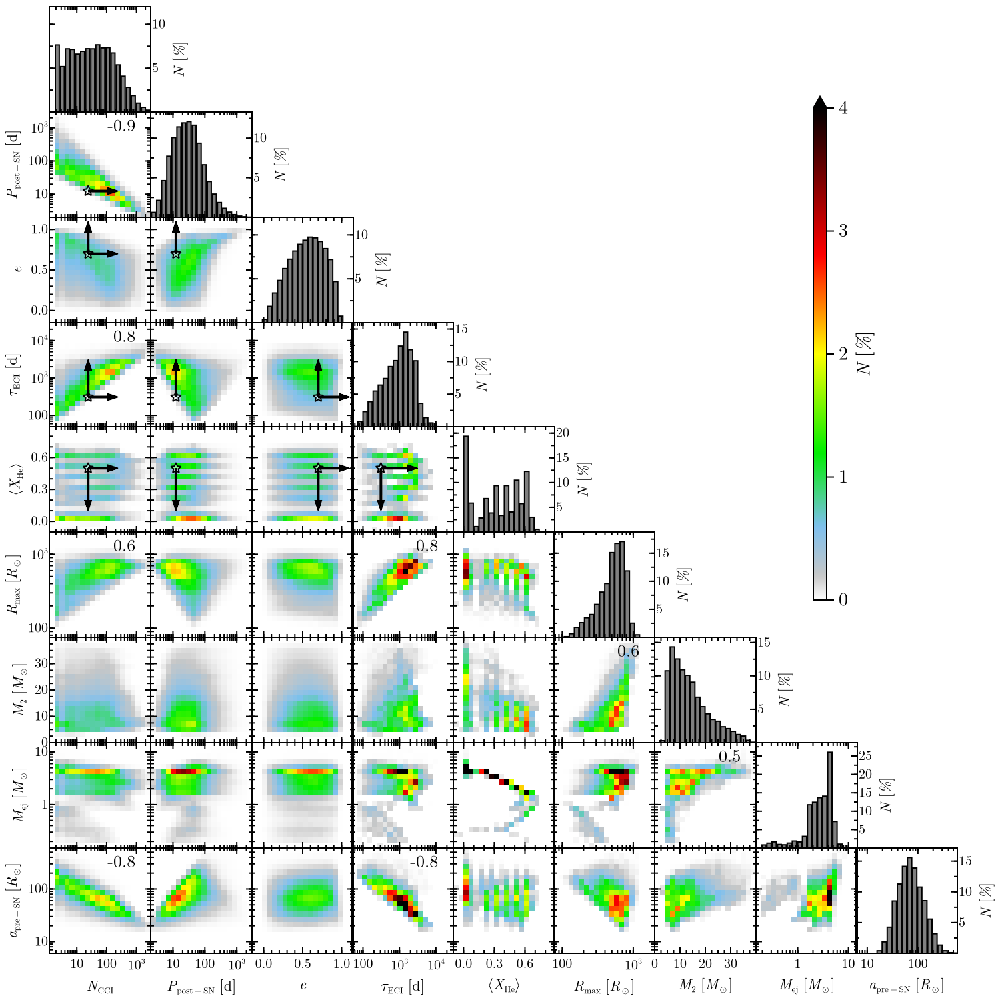

In [ ]:
fff_basic = sn1 .&& ccsne .&& .! (prgs .== "M" .|| prgs .== "NI-S") .&&  (SNe .== :Ibc .|| SNe .== :Ibn)

mycmap = cgrad([:white, :gray78, :skyblue2, :green2, :yellow, :red,  :black], 
                [0,      0.05,  0.15,  0.3,     0.5,  0.7,       1])

fff = fff_basic  .&& (Rmax .> R2) .&& (post_SN_orbit .== :bound) .&& (n_passages .> 1) .&& ECI

@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

mlogticks = [k  for j in -90:1:90 for k in  (10. ^j):(10. ^j):(10. ^(j+1))]
mlinticks = 0:0.1:100
xticks10    = [10^t for t in -90.:1.:+90.]
logxticks10 = [t    for t in -90.:1.:+90.]
ticklabels  = [latexstring(@sprintf("10^{%d}", t)) for t in -90:90]
# ticklabels[findfirst(x->x==-2, logxticks10)]="0.01"
ticklabels[findfirst(x->x==-1, logxticks10)]="0.1"
ticklabels[findfirst(x->x== 0, logxticks10)]="1"
ticklabels[findfirst(x->x==+1, logxticks10)]="10"
ticklabels[findfirst(x->x==+2, logxticks10)]="100"
ticks    = (   xticks10, ticklabels)
logticks = (logxticks10, ticklabels)
linticks = 0:0.5:100
ticksize=11
FIGURE = Figure(size=(750,750), figure_padding = 5)
grid = GridLayout(FIGURE[0:10,0:10])
ax = Dict()
val_range = Dict("P"=>[2e0,3e3], 
                 "T"=>[50,3e4], 
                 "N"=>[1.2,3e3],
                 "e"=>[-.15,1.15],
                 "Mej"=>[0.15,15],
                 "S"=>[1.3,2.25],
                 "Eexp"=>[3e50,1e52],
                 "M2"=>[0,39.999],
                 "Omega"=>[1.2e-4,0.15],
                 "h"=>[1e42,2e49],
                 "Rmax"=>[75,2_000],
                 "Lmax"=>[1e38,2e40],
                 "v_kick"=>[1,300],
                 "<He>"=>[-.1,.89],
                 "Mi"=>[8,150],
                 "Pi"=>[0.1,5e3],
                 "qi"=>[0,1],
                 "a_pre"=>[6,600])
val_scale = Dict("P"=>log10,"<He>"=>identity,"qi"=>identity, "Mi"=>log10, "Pi"=>log10,
                 "T"=>log10, "N"=>log10, "e"=>identity, "h"=>log10,"v_kick"=>log10,
                 "Mej"=>log10, "S"=>identity, "Eexp"=>log10, "M2"=>identity,
                 "Omega"=>log10, "Rmax"=>log10, "Lmax"=>log10, "a_pre"=>log10)
dbins     = Dict("P"=>.25, "T"=>.15, "N"=>.20, "h"=>0.5, "Omega"=>0.2,"a_pre"=>0.10,
                "Mej"=>0.1, "S"=>0.05, "e"=>0.05, "Eexp"=>0.1, "M2"=>2.5,
                "v_kick"=>0.1,"<He>"=>0.1, "Mi"=>0.1, "Pi"=>0.1, "qi"=>0.1, 
                "Rmax"=>0.05, "Lmax"=>0.15)
vals      = Dict("P" => P_postSN[fff], 
                 "T"=>tau_ECI[fff], 
                 "N"=>n_passages[fff], 
                 "Mej"=>Mej[fff],
                 "S"=>M_b_ns[fff],
                 "pdf"=>pdfs[fff]/sum(pdfs[fff]) *100,
                 "e"=>eccentricity[fff],
                 "Eexp"=>E_exp[fff],
                 "M2"=>M2[fff],
                 "h"=>Eheat[fff],
                 "Omega"=>Omegaeff[fff],
                 "Rmax" => Rmax[fff],
                 "v_kick"=>v_kick[fff],
                 "Lmax"=>Lmax[fff],
                 "<He>"=>avg_he[fff],
                 "Mi"=>M1[fff],
                 "Pi"=>Pi[fff],
                 "qi"=>qi[fff],
                 "a_pre"=>a_pre[fff])
ticks_xtra      = Dict("P" => nothing,
                 "T"=> nothing, 
                 "N"=>nothing, 
                 "Mej"=>nothing,
                 "S"=>nothing,
                 "Mi"=>nothing,
                 "Pi"=>nothing,
                 "<He>"=>(0.:0.3:1, 0.:0.1:1.0),
                 "qi"=>(0.:0.5:1, 0.:0.1:1.0),
                 "e"=>(0.:0.5:1, 0.:0.1:1.0),
                 "Eexp"=>nothing,
                 "M2"=>(0:10:100, 0:2.5:100),
                 "v_kick"=>nothing,
                 "h"=>nothing,
                 "Omega"=>nothing,
                 "Rmax" => nothing,
                 "Lmax"=>nothing,
                 "a_pre"=>nothing)
labels    = Dict("P"=>L"P_\mathrm{post-SN} \ [\mathrm{d}]",
                 "T"=>L"\tau_\mathrm{ECI} \ [\mathrm{d}]",
                 "N"=>L"N_\mathrm{CCI}",
                 "Mej"=>L"M_\mathrm{ej} \ [M_\odot]",
                 "S"=>L"M_\mathrm{NS} \ [M_\odot]",
                 "e"=>L"e",
                 "Eexp"=>L"E_\mathrm{kin,ej} \ [\mathrm{erg}]",
                 "M2"=>L"M_\mathrm{2} \ [M_\odot]",
                 "h"=>L"E_\mathrm{heat} \ [\mathrm{erg}]",
                 "Rmax"=>L"R_\mathrm{max} \ [R_\odot]",
                 "a_pre"=>L"a_\mathrm{pre-SN} \ [R_\odot]",
                 "<He>"=>L"⟨X_\mathrm{He}⟩",
                 "Mi"=>L"M_\mathrm{1,i} \ [M_\odot]",
                 "Pi"=>L"P_\mathrm{i} \ [\mathrm{d}]",
                 "qi"=>"q_i",
                 "v_kick"=>L"v_\mathrm{kick} \ [\mathrm{km}\,\mathrm{s}^{-1}]",
                 "Lmax"=>L"L_\mathrm{max} \ [\mathrm{erg}\,\mathrm{s}^{-1}]",
                 "Omega"=>L"\tilde{\Omega}_\mathrm{eff}")
digits    = Dict("P"=>0,
                 "T"=>0,
                 "N"=>0,
                 "Mej"=>1,
                 "S"=>2,
                 "e"=>2,
                 "Eexp"=>1,
                 "M2"=>1,
                 "h"=>1,
                 "Rmax"=>0,
                 "a_pre"=>0,
                 "Lmax"=>0,
                 "Omega"=>4, "v_kick"=>0)
SN2022jli     = Dict("P"=>[12.4, :value], "T"=>[310, :lowerlimit], 
                     "N"=>[floor(305/12.4), :lowerlimit], "h"=>[NaN, :unknown],
                     "Omega"=>[NaN,:unknown], "Mej"=>[NaN, :unknown],
                     "S"=>[NaN,:unknown], "e"=>[0.7, :lowerlimit], "v_kick"=>[NaN, :unknown],
                     "E"=>[NaN,:unknown], "M2"=>[NaN,:unknown], "<He>"=>[0.5, :upperlimit],
                     "Rmax"=>[NaN,:unknown], "a_pre"=>[NaN,:unknown])

colorrange=[0.,4]
bin_scale = :uniform # :custom
variables    = [ "N", "P", "e",  "T", "<He>", "Rmax", "M2", "Mej", "a_pre"]
positions = Dict()
for k in range(1,length(variables)) 
        positions[variables[k]] = k  
end
cornerplots  = [[variables[i],variables[j]]
                        for i in 1:length(variables) 
                        for j in (i+1):length(variables)
                ]
for cornerplot in cornerplots
        x=cornerplot[1]
        y=cornerplot[2]
        ax[cornerplot] = plot_settings(grid[positions[y],positions[x]]; 
                ylabel=labels[y],
                xlabel=labels[x], 
                title =" ", 
                ymticks = val_scale[y] == log10 ? val_scale[y].(mlogticks) : ticks_xtra[y][2], 
                xmticks = val_scale[x] == log10 ? val_scale[x].(mlogticks) : ticks_xtra[x][2], 
                yticks  = val_scale[y] == log10 ? logticks  : ticks_xtra[y][1],
                xticks  = val_scale[x] == log10 ? logticks  : ticks_xtra[x][1],
                xlabelvisible = positions[y]==length(variables),
                xticklabelsvisible = positions[y]==length(variables),
                ylabelvisible = positions[x]==1,
                yticklabelsvisible = positions[x]==1,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1

                )
end
for h in variables
        ax[h] = plot_settings(grid[positions[h],positions[h]]; 
                ylabel=L"N \ [%]", 
                xlabel=labels[h], 
                title =" ",
                xscale=val_scale[h],
                xticks  = val_scale[h] == log10 ? ticks     : ticks_xtra[h][1],
                xmticks = val_scale[h] == log10 ? mlogticks : ticks_xtra[h][2], 
                yaxisposition=:right,
                xlabelvisible = positions[h]==length(variables),
                xticklabelsvisible = positions[h]==length(variables),
                yticks=5:5:100,
                ymticks=0:2.5:100,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1
                )
end

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_crit = Dict(occursin("Valli", KICKS) => "V25", occursin("MM", KICKS)=>"M16", occursin("DM25", KICKS)=>"DM25",occursin("COMBINE", KICKS)=>"K18", KICKS=="None"=>"None")[true]
simulation_settings = @sprintf("Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\nKicks: %s", f_B*100, exp_crit, mer_crit, kick_crit)

# # text!(FIGURE.scene, (.40, .85), text = simulation_settings, fontsize = 20, space = :relative)
# important_data = @sprintf(
# "Only %5.1f%% of Ibc+Ibn supernovae\nwith a MS companion are shown", 
#                 sum(pdfs[fff])/sum(pdfs[fff_basic])*100,
#                 )
# text!(FIGURE.scene, (.45, .9), text = important_data, fontsize = 14, space = :relative)
nbins = 20
hm = nothing           
for cornerplot in cornerplots
        xlab = cornerplot[1]
        ylab = cornerplot[2]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        ymin = val_range[ylab][1]
        ymax = val_range[ylab][2]
        scalex = val_scale[xlab]
        scaley = val_scale[ylab]
        dxb = (bin_scale == :custom) ? dbins[xlab] : (scalex(xmax)-scalex(xmin))/nbins
        dyb = (bin_scale == :custom) ? dbins[ylab] : (scaley(ymax)-scaley(ymin))/nbins

        
        xbins=scalex(xmin):dxb:scalex(xmax)
        ybins=scaley(ymin):dyb:scaley(ymax)

        x = scalex.(vals[xlab])
        y = scaley.(vals[ylab])
        
        hm = sn_heatmap(ax[cornerplot], x, y, vals["pdf"], xbins, ybins; colorrange=colorrange,
                cmap=mycmap, print_data=true, highclip=:black)
        PearsonCoeff = cor(reduce(hcat, [x,y]), Weights(vals["pdf"]))[1,2]
        abs(PearsonCoeff) > 0.5 && text!(ax[cornerplot], @sprintf("%5.1f", PearsonCoeff),
        position = (.85, .95),        # relative coords in axis space
        align = (:right, :top),   # anchor point
        space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        )
        
        scatter!(ax[cornerplot], scalex.(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1]), marker = :star5, color=RGBAf(1,1,1,0.5), strokecolor=:black, strokewidth=1 )
        if SN2022jli[xlab][2] == :lowerlimit 
                arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (1, 0),
                lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        elseif SN2022jli[xlab][2] == :upperlimit 
                arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (-1, 0),
                lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        end
        if SN2022jli[ylab][2] == :lowerlimit 
                arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (0, 1),
                lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        elseif SN2022jli[ylab][2] == :upperlimit 
                arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (0, -1),
                lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        end

        xlims!(ax[cornerplot], scalex(xmin), scalex(xmax))
        ylims!(ax[cornerplot], scaley(ymin), scaley(ymax))

end


for histogram in variables
        xlab = histogram
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        scalex = val_scale[xlab]
        dxb = (bin_scale == :custom) ? dbins[xlab] : (scalex(xmax)-scalex(xmin))/nbins
        xbins=scalex(xmin):dxb:scalex(xmax)
        x = (vals[xlab])
        xlims!(ax[histogram], xmin, xmax)
        bins, y_bins = run_histogram(ax[histogram], x, vals["pdf"], xbins, dxb * (scalex==log10 ? 1.2 : 1.), datascale=scalex, norm=1)
        ylims!(ax[histogram], 0, max( maximum(y_bins)*1.1, 12) )
        # stats = POPSYNTH.report_stats(x, vals["pdf"], label = xlab, print2screen=true, unit = (1, ""), multip_percentiles=[0,2.5,5,10,25,50,75,90,95,97.5,100], format_str="%5.1f")    
        
        # stats_string = @sprintf "%*.*f^{+%*.*f}_{-%*.*f}" 5 digits[xlab] stats[1][1]  5 digits[xlab] stats[1][2]  5 digits[xlab] stats[1][3]
        # text!(ax[histogram], latexstring(stats_string),
        #         position = (.85, .95),        # relative coords in axis space
        #         align = (:right, :top),   # anchor point
        #         space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        # )

end
Colorbar(FIGURE[1:6,9], hm, label=L"N \ [%]",size = 10)
colgap!(grid, -27)
rowgap!(grid,0)

save_directory = "../output/ECI/cornerplots/"
outfilename = @sprintf("cps_CCI_%s_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT, KICKS)
save(save_directory*outfilename, FIGURE)

FIGURE

### with colors

The data in this plot affects 22.907 % of all CCSNe
Weights: min=2.778e-03, max=2.231e+00, min/max=1.246e-03
Weights: min=8.335e-03, max=2.100e+00, min/max=3.969e-03
Weights: min=1.492e-03, max=5.889e+00, min/max=2.534e-04
Weights: min=2.984e-06, max=5.649e+00, min/max=5.283e-07
Weights: min=1.743e-03, max=1.795e+00, min/max=9.710e-04
Weights: min=2.778e-03, max=2.279e+00, min/max=1.219e-03
Weights: min=1.492e-03, max=3.381e+00, min/max=4.414e-04
Weights: min=2.984e-06, max=2.665e+00, min/max=1.120e-06
Weights: min=2.984e-06, max=1.969e+00, min/max=1.516e-06
Weights: min=3.246e-03, max=3.430e+00, min/max=9.463e-04
Weights: min=1.743e-03, max=1.393e+01, min/max=1.251e-04
Weights: min=2.984e-06, max=1.112e+01, min/max=2.685e-07
Weights: min=1.743e-03, max=1.695e+00, min/max=1.029e-03
Weights: min=3.246e-03, max=1.527e+01, min/max=2.125e-04
Weights: min=1.743e-03, max=2.097e+00, min/max=8.310e-04
Weights: min=3.486e-06, max=2.393e+00, min/max=1.457e-06
Weights: min=6.491e-06, max=1.293e+0

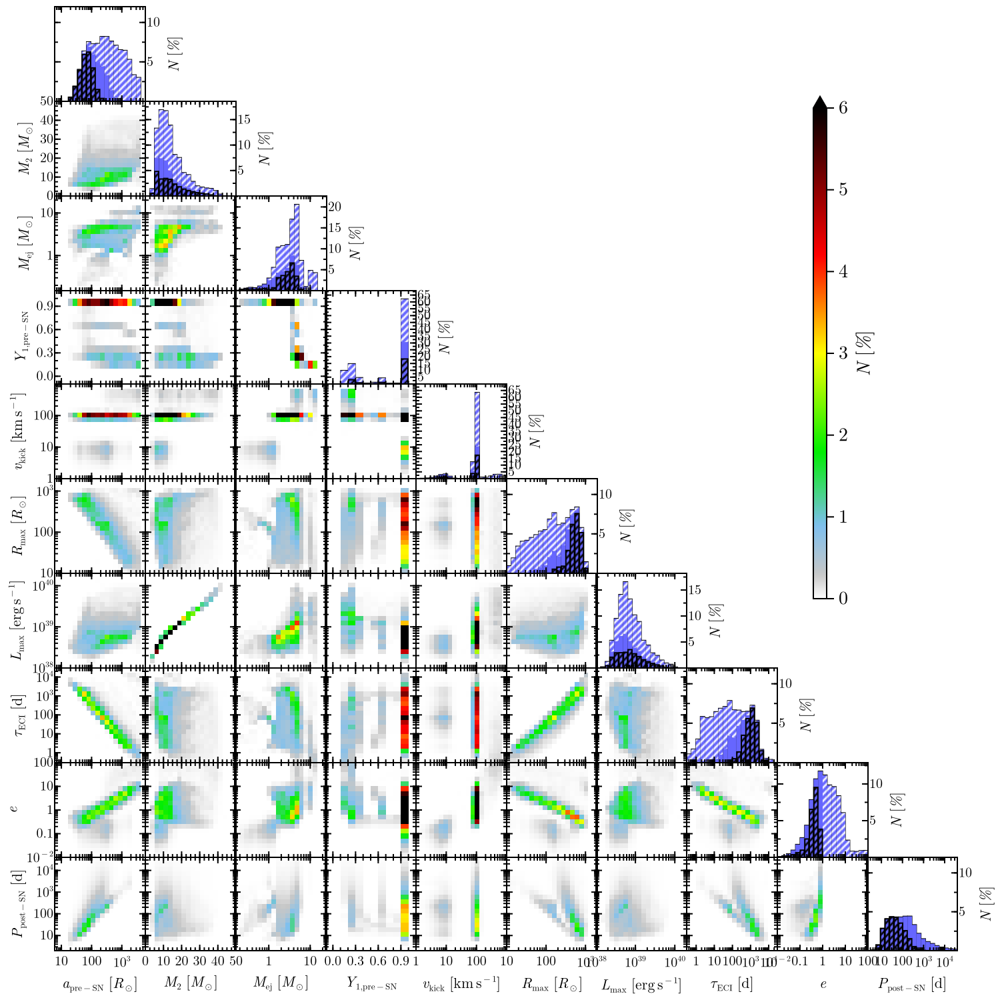

In [70]:
fff_basic = sn1 .&& ccsne .&& .! (prgs .== "M" .|| prgs .== "NI-S") .&&  (SNe .== :Ibc .|| SNe .== :Ibn)

mycmap = cgrad([:white, :gray78, :skyblue2, :green2, :yellow, :red,  :black], 
                [0,      0.05,  0.15,  0.3,     0.5,  0.7,       1])

fff = fff_basic # .&& (Rmax .> R2) .&& (post_SN_orbit .== :bound) .&& (n_passages .> 1) .&& ECI
isreplaceable(x) = x < 0

eccentricity = [isreplaceable(e) ? NaN : e for e in eccentricity]
P_postSN     = [isreplaceable(p) ? NaN : p for p in P_postSN    ]

@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

mlogticks = [k  for j in -90:1:90 for k in  (10. ^j):(10. ^j):(10. ^(j+1))]
mlinticks = 0:0.1:100
xticks10    = [10^t for t in -90.:1.:+90.]
logxticks10 = [t    for t in -90.:1.:+90.]
ticklabels  = [latexstring(@sprintf("10^{%d}", t)) for t in -90:90]
# ticklabels[findfirst(x->x==-2, logxticks10)]="0.01"
ticklabels[findfirst(x->x==-1, logxticks10)]="0.1"
ticklabels[findfirst(x->x== 0, logxticks10)]="1"
ticklabels[findfirst(x->x==+1, logxticks10)]="10"
ticklabels[findfirst(x->x==+2, logxticks10)]="100"
ticks    = (   xticks10, ticklabels)
logticks = (logxticks10, ticklabels)
linticks = 0:0.5:100
ticksize=11
FIGURE = Figure(size=(750,750), figure_padding = 5)
grid = GridLayout(FIGURE[0:10,0:10])
ax = Dict()
val_range = Dict("P"=>[2e0,4e4], 
                 "T"=>[.3,3e4], 
                 "N"=>[1.2,3e3],
                 "e"=>[.01,100],
                 "Mej"=>[0.15,25],
                 "S"=>[1.3,2.25],
                 "Eexp"=>[3e50,1e52],
                 "M2"=>[0,50],
                 "Omega"=>[1.2e-6,0.15],
                 "h"=>[1e42,2e49],
                 "Rmax"=>[10,2_000],
                 "Lmax"=>[1e38,2e40],
                 "v_kick"=>[1,999],
                 "<He>"=>[-0.1,1.1],
                 "Mi"=>[8,150],
                 "Pi"=>[0.1,5e3],
                 "qi"=>[0,1],
                 "a_pre"=>[6,6000])
val_scale = Dict("P"=>log10,"<He>"=>identity,"qi"=>identity, "Mi"=>log10, "Pi"=>log10,
                 "T"=>log10, "N"=>log10, "e"=>log10, "h"=>log10,"v_kick"=>log10,
                 "Mej"=>log10, "S"=>identity, "Eexp"=>log10, "M2"=>identity,
                 "Omega"=>log10, "Rmax"=>log10, "Lmax"=>log10, "a_pre"=>log10)
dbins     = Dict("P"=>nothing, "T"=>nothing, "N"=>nothing, "h"=>nothing, 
                "Omega"=>nothing,"a_pre"=>nothing, "Eexp"=>nothing,
                "Mej"=>nothing, "S"=>nothing, "e"=>nothing,  "M2"=>nothing,
                "v_kick"=>nothing,"<He>"=>0.1, "Mi"=>nothing, "Pi"=>nothing, "qi"=>nothing, 
                "Rmax"=>nothing, "Lmax"=>nothing)
vals      = Dict("P" => P_postSN, 
                 "T"=>tau_ECI, 
                 "N"=>n_passages, 
                 "Mej"=>Mej,
                 "S"=>M_b_ns,
                 "pdf"=>pdfs/sum(pdfs[fff]) *100,
                 "e"=>eccentricity,
                 "Eexp"=>E_exp,
                 "M2"=>M2,
                 "h"=>Eheat,
                 "Omega"=>Omegaeff,
                 "Rmax" => Rmax,
                 "v_kick"=>v_kick,
                 "Lmax"=>Lmax,
                 "<He>"=>Y1,
                 "Mi"=>M1,
                 "Pi"=>Pi,
                 "qi"=>qi,
                 "a_pre"=>a_pre)
ticks_xtra      = Dict("P" => nothing,
                 "T"=> nothing, 
                 "N"=>nothing, 
                 "Mej"=>nothing,
                 "S"=>nothing,
                 "Mi"=>nothing,
                 "Pi"=>nothing,
                 "<He>"=>(0.:0.3:1, 0.:0.1:1.0),
                 "qi"=>(0.:0.5:1, 0.:0.1:1.0),
                 "e"=>(0.1:0.5:1, 0.1:0.1:1.0),
                 "Eexp"=>nothing,
                 "M2"=>(0:10:100, 0:2.5:100),
                 "v_kick"=>nothing,
                 "h"=>nothing,
                 "Omega"=>nothing,
                 "Rmax" => nothing,
                 "Lmax"=>nothing,
                 "a_pre"=>nothing)
labels    = Dict("P"=>L"P_\mathrm{post-SN} \ [\mathrm{d}]",
                 "T"=>L"\tau_\mathrm{ECI} \ [\mathrm{d}]",
                 "N"=>L"N_\mathrm{CCI}",
                 "Mej"=>L"M_\mathrm{ej} \ [M_\odot]",
                 "S"=>L"M_\mathrm{NS} \ [M_\odot]",
                 "e"=>L"e",
                 "Eexp"=>L"E_\mathrm{kin,ej} \ [\mathrm{erg}]",
                 "M2"=>L"M_\mathrm{2} \ [M_\odot]",
                 "h"=>L"E_\mathrm{heat} \ [\mathrm{erg}]",
                 "Rmax"=>L"R_\mathrm{max} \ [R_\odot]",
                 "a_pre"=>L"a_\mathrm{pre-SN} \ [R_\odot]",
                 "<He>"=>L"Y_\mathrm{1, pre-SN}",
                 "Mi"=>L"M_\mathrm{1,i} \ [M_\odot]",
                 "Pi"=>L"P_\mathrm{i} \ [\mathrm{d}]",
                 "qi"=>"q_i",
                 "v_kick"=>L"v_\mathrm{kick} \ [\mathrm{km}\,\mathrm{s}^{-1}]",
                 "Lmax"=>L"L_\mathrm{max} \ [\mathrm{erg}\,\mathrm{s}^{-1}]",
                 "Omega"=>L"\tilde{\Omega}_\mathrm{eff}")
digits    = Dict("P"=>0,
                 "T"=>0,
                 "N"=>0,
                 "Mej"=>1,
                 "S"=>2,
                 "e"=>2,
                 "Eexp"=>1,
                 "M2"=>1,
                 "h"=>1,
                 "Rmax"=>0,
                 "a_pre"=>0,
                 "Lmax"=>0,
                 "Omega"=>4, "v_kick"=>0)
SN2022jli     = Dict("P"=>[12.4, :value], "T"=>[310, :lowerlimit], 
                     "N"=>[floor(305/12.4), :lowerlimit], "h"=>[NaN, :unknown],
                     "Omega"=>[NaN,:unknown], "Mej"=>[NaN, :unknown],
                     "S"=>[NaN,:unknown], "e"=>[0.7, :lowerlimit], "v_kick"=>[NaN, :unknown],
                     "E"=>[NaN,:unknown], "M2"=>[NaN,:unknown], "<He>"=>[0.5, :upperlimit],
                     "Rmax"=>[NaN,:unknown], "a_pre"=>[NaN,:unknown])

colorrange=[0.,6]
bin_scale = :uniform # :custom
variables    = ["a_pre", "M2", "Mej","<He>",  "v_kick", "Rmax", "Lmax", "T", "e", "P"]
# variables    = ["a_pre", "M2", "Mej"]#, "Mej","<He>",  "v_kick", "Rmax", "Lmax", "T", "e", "P"]
positions = Dict()
for k in range(1,length(variables)) 
        positions[variables[k]] = k  
end
cornerplots  = [[variables[i],variables[j]]
                        for i in 1:length(variables) 
                        for j in (i+1):length(variables)
                ]
for cornerplot in cornerplots
        x=cornerplot[1]
        y=cornerplot[2]
        ax[cornerplot] = plot_settings(grid[positions[y],positions[x]]; 
                ylabel=labels[y],
                xlabel=labels[x], 
                title =" ", 
                ymticks = val_scale[y] == log10 ? val_scale[y].(mlogticks) : ticks_xtra[y][2], 
                xmticks = val_scale[x] == log10 ? val_scale[x].(mlogticks) : ticks_xtra[x][2], 
                yticks  = val_scale[y] == log10 ? logticks  : ticks_xtra[y][1],
                xticks  = val_scale[x] == log10 ? logticks  : ticks_xtra[x][1],
                xlabelvisible = positions[y]==length(variables),
                xticklabelsvisible = positions[y]==length(variables),
                ylabelvisible = positions[x]==1,
                yticklabelsvisible = positions[x]==1,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1

                )
end
for h in variables
        ax[h] = plot_settings(grid[positions[h],positions[h]]; 
                ylabel=L"N \ [%]", 
                xlabel=labels[h], 
                title =" ",
                # xscale=val_scale[h],
                xticks  = val_scale[h] == log10 ? logticks  : ticks_xtra[h][1],
                xmticks = val_scale[h] == log10 ? val_scale[h].(mlogticks) : ticks_xtra[h][2], 
                yaxisposition=:right,
                xlabelvisible = positions[h]==length(variables),
                xticklabelsvisible = positions[h]==length(variables),
                yticks=5:5:100,
                ymticks=0:2.5:100,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1
                )
end

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_crit = Dict(occursin("Valli", KICKS) => "V25", occursin("MM", KICKS)=>"M16", occursin("DM25", KICKS)=>"DM25",occursin("COMBINE", KICKS)=>"K18", KICKS=="None"=>"None")[true]
simulation_settings = @sprintf("Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\nKicks: %s", f_B*100, exp_crit, mer_crit, kick_crit)

# # text!(FIGURE.scene, (.40, .85), text = simulation_settings, fontsize = 20, space = :relative)
# important_data = @sprintf(
# "Only %5.1f%% of Ibc+Ibn supernovae\nwith a MS companion are shown", 
#                 sum(pdfs[fff])/sum(pdfs[fff_basic])*100,
#                 )
# text!(FIGURE.scene, (.45, .9), text = important_data, fontsize = 14, space = :relative)
nbins = 20
hm = nothing   

alpha=1

color_coding = Dict()
color_coding[:MS] = RGBAf(.4,.4,1,alpha)   
color_coding[:bound] = color_coding[:MS] 
colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=style, line_color=color,
                        bg_color= color2)
color_coding[:CCI] = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(0.,0.,0.,1), style = :plus))
color_coding[:unbound] = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(1.,1.,1.,1), style = :slash))
color_coding[:CCI] = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(0,0,0,1), style = :slash))

for cornerplot in cornerplots
        xlab = cornerplot[1]
        ylab = cornerplot[2]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        ymin = val_range[ylab][1]
        ymax = val_range[ylab][2]
        scalex = val_scale[xlab]
        scaley = val_scale[ylab]
        dxb = isnothing(dbins[xlab]) ?  (scalex(xmax)-scalex(xmin))/nbins : dbins[xlab]
        dyb = isnothing(dbins[ylab]) ?  (scaley(ymax)-scaley(ymin))/nbins : dbins[ylab]

        
        xbins=scalex(xmin):dxb:scalex(xmax)
        ybins=scaley(ymin):dyb:scaley(ymax)

        x = scalex.(vals[xlab][fff])
        y = scaley.(vals[ylab][fff])
        p = vals["pdf"][fff]
        hm = sn_heatmap(ax[cornerplot], x, y, p, xbins, ybins; colorrange=colorrange,
                cmap=mycmap, print_data=true, highclip=:black)
        PearsonCoeff = cor(reduce(hcat, [x,y]), Weights(p))[1,2]
        abs(PearsonCoeff) > 0.5 && text!(ax[cornerplot], @sprintf("%5.1f", PearsonCoeff),
        position = (.85, .95),        # relative coords in axis space
        align = (:right, :top),   # anchor point
        space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        )
        
        # scatter!(ax[cornerplot], scalex.(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1]), marker = :star5, color=RGBAf(1,1,1,0.5), strokecolor=:black, strokewidth=1 )
        # if SN2022jli[xlab][2] == :lowerlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (1, 0),
        #         lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # elseif SN2022jli[xlab][2] == :upperlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (-1, 0),
        #         lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # end
        # if SN2022jli[ylab][2] == :lowerlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (0, 1),
        #         lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # elseif SN2022jli[ylab][2] == :upperlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (0, -1),
        #         lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # end

        xlims!(ax[cornerplot], scalex(xmin), scalex(xmax))
        ylims!(ax[cornerplot], scaley(ymin), scaley(ymax))

end

fff_bc = fff .&& (post_SN_orbit .== :bound) .&& (Rmax .> R2) .&& (n_passages .> 1) .&& (ECI)
fff_bn = fff .&& (post_SN_orbit .== :bound) .&& .! fff_bc
fff_ub = fff .&& ((post_SN_orbit .== :unbound) .|| (post_SN_orbit .== :unknown))

for histogram in variables
        print(histogram, "\n")
        xlab = histogram
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        scalex = val_scale[xlab]
        dxb = isnothing(dbins[xlab]) ?  (scalex(xmax)-scalex(xmin))/nbins : dbins[xlab]
        xbins=scalex(xmin):dxb:scalex(xmax)

        x =  (vals[xlab])
        p =  vals["pdf"]
        bins, y_bins           = run_histogram(ax[histogram], scalex.(x[fff]),    p[fff],    xbins, dxb, norm=1, color = :white)
        _, y_bins_bound_andCCI = run_histogram(ax[histogram], scalex.(x[fff_bc]), p[fff_bc], xbins, dxb, norm=1, to_plot = false)
        _, y_bins_bound_noCCI  = run_histogram(ax[histogram], scalex.(x[fff_bn]), p[fff_bn], xbins, dxb, norm=1, to_plot = false)
        _, y_bins_unbound      = run_histogram(ax[histogram], scalex.(x[fff_ub]), p[fff_ub], xbins, dxb, norm=1, to_plot = false)
        # @show (xbins)
        # @show (dxb)
        # @show sum(y_bins)
        # @show minimum(bins)
        # # @show length(y_bins_bound_andCCI)
        # # @show length(y_bins_bound_noCCI)
        # # @show length(y_bins_unbound)
        ylims!(ax[histogram], 0, max( maximum(y_bins)*1.1, 12) )
        xlims!(ax[histogram], scalex(xmin), scalex(xmax))

        stacked_barplot!(ax[histogram],  (bins), [y_bins_bound_andCCI, y_bins_bound_noCCI, y_bins_unbound],
                                width = dxb, colors = [color_coding[:CCI], color_coding[:bound], color_coding[:unbound]] )
        _, y_bins_bound_andCCI = run_histogram(ax[histogram], scalex.(x[fff_bc]), p[fff_bc], xbins, dxb, norm=1, to_plot = true, color = RGBAf(0,0,0,0))


        # stats = POPSYNTH.report_stats(x, vals["pdf"], label = xlab, print2screen=true, unit = (1, ""), multip_percentiles=[0,2.5,5,10,25,50,75,90,95,97.5,100], format_str="%5.1f")    
        
        # stats_string = @sprintf "%*.*f^{+%*.*f}_{-%*.*f}" 5 digits[xlab] stats[1][1]  5 digits[xlab] stats[1][2]  5 digits[xlab] stats[1][3]
        # text!(ax[histogram], latexstring(stats_string),
        #         position = (.85, .95),        # relative coords in axis space
        #         align = (:right, :top),   # anchor point
        #         space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        # )

end

Colorbar(FIGURE[1:6,9], hm, label=L"N \ [%]",size = 10)
colgap!(grid, -27)
rowgap!(grid,0)

save_directory = "../output/ECI/cornerplots/"
outfilename = @sprintf("cps_ECI_%s_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT, KICKS)
save(save_directory*outfilename, FIGURE)

FIGURE

In [61]:
fff_basic = sn1 .&& ccsne .&& .! (prgs .== "M" .|| prgs .== "NI-S") .&&  (SNe .== :Ibc .|| SNe .== :Ibn)

mycmap = cgrad([:white, :gray78, :skyblue2, :green2, :yellow, :red,  :black], 
                [0,      0.05,  0.15,  0.3,     0.5,  0.7,       1])

fff = fff_basic .&& (post_SN_orbit .== :bound)  # .&& (Rmax .> R2) .&& (post_SN_orbit .== :bound) .&& (n_passages .> 1) .&& ECI
isreplaceable(x) = x < 0

eccentricity = [isreplaceable(e) ? NaN : e for e in eccentricity]
P_postSN     = [isreplaceable(p) ? NaN : p for p in P_postSN    ]

@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

mlogticks = [k  for j in -90:1:90 for k in  (10. ^j):(10. ^j):(10. ^(j+1))]
mlinticks = 0:0.1:100
xticks10    = [10^t for t in -90.:1.:+90.]
logxticks10 = [t    for t in -90.:1.:+90.]
ticklabels  = [latexstring(@sprintf("10^{%d}", t)) for t in -90:90]
# ticklabels[findfirst(x->x==-2, logxticks10)]="0.01"
ticklabels[findfirst(x->x==-1, logxticks10)]="0.1"
ticklabels[findfirst(x->x== 0, logxticks10)]="1"
ticklabels[findfirst(x->x==+1, logxticks10)]="10"
ticklabels[findfirst(x->x==+2, logxticks10)]="100"
ticks    = (   xticks10, ticklabels)
logticks = (logxticks10, ticklabels)
linticks = 0:0.5:100
ticksize=11
FIGURE = Figure(size=(750,750), figure_padding = 5)
grid = GridLayout(FIGURE[0:10,0:10])
ax = Dict()
val_range = Dict("P"=>[2e0,4e4], 
                 "T"=>[.3,3e4], 
                 "N"=>[1.2,3e3],
                 "e"=>[-0.05,1.05],
                 "Mej"=>[0.15,25],
                 "S"=>[1.3,2.25],
                 "Eexp"=>[3e50,1e52],
                 "M2"=>[0,50],
                 "Omega"=>[1.2e-6,0.15],
                 "h"=>[1e42,2e49],
                 "Rmax"=>[10,2_000],
                 "Lmax"=>[1e38,2e40],
                 "v_kick"=>[1,999],
                 "<He>"=>[-.1,.89],
                 "Mi"=>[8,150],
                 "Pi"=>[0.1,5e3],
                 "qi"=>[0,1],
                 "a_pre"=>[6,6000])
val_scale = Dict("P"=>log10,"<He>"=>identity,"qi"=>identity, "Mi"=>log10, "Pi"=>log10,
                 "T"=>log10, "N"=>log10, "e"=>identity, "h"=>log10,"v_kick"=>log10,
                 "Mej"=>log10, "S"=>identity, "Eexp"=>log10, "M2"=>identity,
                 "Omega"=>log10, "Rmax"=>log10, "Lmax"=>log10, "a_pre"=>log10)
dbins     = Dict("P"=>nothing, "T"=>nothing, "N"=>nothing, "h"=>nothing, 
                "Omega"=>nothing,"a_pre"=>nothing, "Eexp"=>nothing,
                "Mej"=>nothing, "S"=>nothing, "e"=>nothing,  "M2"=>nothing,
                "v_kick"=>nothing,"<He>"=>0.1, "Mi"=>nothing, "Pi"=>nothing, "qi"=>nothing, 
                "Rmax"=>nothing, "Lmax"=>nothing)
vals      = Dict("P" => P_postSN, 
                 "T"=>tau_ECI, 
                 "N"=>n_passages, 
                 "Mej"=>Mej,
                 "S"=>M_b_ns,
                 "pdf"=>pdfs/sum(pdfs[fff]) *100,
                 "e"=>eccentricity,
                 "Eexp"=>E_exp,
                 "M2"=>M2,
                 "h"=>Eheat,
                 "Omega"=>Omegaeff,
                 "Rmax" => Rmax,
                 "v_kick"=>v_kick,
                 "Lmax"=>Lmax,
                 "<He>"=>avg_he,
                 "Mi"=>M1,
                 "Pi"=>Pi,
                 "qi"=>qi,
                 "a_pre"=>a_pre)
ticks_xtra      = Dict("P" => nothing,
                 "T"=> nothing, 
                 "N"=>nothing, 
                 "Mej"=>nothing,
                 "S"=>nothing,
                 "Mi"=>nothing,
                 "Pi"=>nothing,
                 "<He>"=>(0.:0.3:1, 0.:0.1:1.0),
                 "qi"=>(0.:0.5:1, 0.:0.1:1.0),
                 "e"=>(0.1:0.5:1, 0.1:0.1:1.0),
                 "Eexp"=>nothing,
                 "M2"=>(0:10:100, 0:2.5:100),
                 "v_kick"=>nothing,
                 "h"=>nothing,
                 "Omega"=>nothing,
                 "Rmax" => nothing,
                 "Lmax"=>nothing,
                 "a_pre"=>nothing)
labels    = Dict("P"=>L"P_\mathrm{post-SN} \ [\mathrm{d}]",
                 "T"=>L"\tau_\mathrm{ECI} \ [\mathrm{d}]",
                 "N"=>L"N_\mathrm{CCI}",
                 "Mej"=>L"M_\mathrm{ej} \ [M_\odot]",
                 "S"=>L"M_\mathrm{NS} \ [M_\odot]",
                 "e"=>L"e",
                 "Eexp"=>L"E_\mathrm{kin,ej} \ [\mathrm{erg}]",
                 "M2"=>L"M_\mathrm{2} \ [M_\odot]",
                 "h"=>L"E_\mathrm{heat} \ [\mathrm{erg}]",
                 "Rmax"=>L"R_\mathrm{max} \ [R_\odot]",
                 "a_pre"=>L"a_\mathrm{pre-SN} \ [R_\odot]",
                 "<He>"=>L"⟨X_\mathrm{He}⟩",
                 "Mi"=>L"M_\mathrm{1,i} \ [M_\odot]",
                 "Pi"=>L"P_\mathrm{i} \ [\mathrm{d}]",
                 "qi"=>"q_i",
                 "v_kick"=>L"v_\mathrm{kick} \ [\mathrm{km}\,\mathrm{s}^{-1}]",
                 "Lmax"=>L"L_\mathrm{max} \ [\mathrm{erg}\,\mathrm{s}^{-1}]",
                 "Omega"=>L"\tilde{\Omega}_\mathrm{eff}")
digits    = Dict("P"=>0,
                 "T"=>0,
                 "N"=>0,
                 "Mej"=>1,
                 "S"=>2,
                 "e"=>2,
                 "Eexp"=>1,
                 "M2"=>1,
                 "h"=>1,
                 "Rmax"=>0,
                 "a_pre"=>0,
                 "Lmax"=>0,
                 "Omega"=>4, "v_kick"=>0)
SN2022jli     = Dict("P"=>[12.4, :value], "T"=>[310, :lowerlimit], 
                     "N"=>[floor(305/12.4), :lowerlimit], "h"=>[NaN, :unknown],
                     "Omega"=>[NaN,:unknown], "Mej"=>[NaN, :unknown],
                     "S"=>[NaN,:unknown], "e"=>[0.7, :lowerlimit], "v_kick"=>[NaN, :unknown],
                     "E"=>[NaN,:unknown], "M2"=>[NaN,:unknown], "<He>"=>[0.5, :upperlimit],
                     "Rmax"=>[NaN,:unknown], "a_pre"=>[NaN,:unknown])

colorrange=[0.,6]
bin_scale = :uniform # :custom
variables    = ["a_pre", "M2", "Mej","<He>",  "v_kick", "Rmax", "Lmax", "T", "e", "P"]
# variables    = ["a_pre", "M2", "Mej"]#, "Mej","<He>",  "v_kick", "Rmax", "Lmax", "T", "e", "P"]
positions = Dict()
for k in range(1,length(variables)) 
        positions[variables[k]] = k  
end
cornerplots  = [[variables[i],variables[j]]
                        for i in 1:length(variables) 
                        for j in (i+1):length(variables)
                ]
for cornerplot in cornerplots
        x=cornerplot[1]
        y=cornerplot[2]
        ax[cornerplot] = plot_settings(grid[positions[y],positions[x]]; 
                ylabel=labels[y],
                xlabel=labels[x], 
                title =" ", 
                ymticks = val_scale[y] == log10 ? val_scale[y].(mlogticks) : ticks_xtra[y][2], 
                xmticks = val_scale[x] == log10 ? val_scale[x].(mlogticks) : ticks_xtra[x][2], 
                yticks  = val_scale[y] == log10 ? logticks  : ticks_xtra[y][1],
                xticks  = val_scale[x] == log10 ? logticks  : ticks_xtra[x][1],
                xlabelvisible = positions[y]==length(variables),
                xticklabelsvisible = positions[y]==length(variables),
                ylabelvisible = positions[x]==1,
                yticklabelsvisible = positions[x]==1,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1

                )
end
for h in variables
        ax[h] = plot_settings(grid[positions[h],positions[h]]; 
                ylabel=L"N \ [%]", 
                xlabel=labels[h], 
                title =" ",
                # xscale=val_scale[h],
                xticks  = val_scale[h] == log10 ? logticks  : ticks_xtra[h][1],
                xmticks = val_scale[h] == log10 ? val_scale[h].(mlogticks) : ticks_xtra[h][2], 
                yaxisposition=:right,
                xlabelvisible = positions[h]==length(variables),
                xticklabelsvisible = positions[h]==length(variables),
                yticks=5:5:100,
                ymticks=0:2.5:100,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1
                )
end

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_crit = Dict(occursin("Valli", KICKS) => "V25", occursin("MM", KICKS)=>"M16", occursin("DM25", KICKS)=>"DM25",occursin("COMBINE", KICKS)=>"K18", KICKS=="None"=>"None")[true]
simulation_settings = @sprintf("Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\nKicks: %s", f_B*100, exp_crit, mer_crit, kick_crit)

# # text!(FIGURE.scene, (.40, .85), text = simulation_settings, fontsize = 20, space = :relative)
# important_data = @sprintf(
# "Only %5.1f%% of Ibc+Ibn supernovae\nwith a MS companion are shown", 
#                 sum(pdfs[fff])/sum(pdfs[fff_basic])*100,
#                 )
# text!(FIGURE.scene, (.45, .9), text = important_data, fontsize = 14, space = :relative)
nbins = 20
hm = nothing   

alpha=1

color_coding = Dict()
color_coding[:MS] = RGBAf(.4,.4,1,alpha)   
color_coding[:bound] = color_coding[:MS] 
colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=style, line_color=color,
                        bg_color= color2)
color_coding[:CCI] = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(0.,0.,0.,1), style = :plus))
color_coding[:unbound] = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(1.,1.,1.,1), style = :slash))
color_coding[:CCI] = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(0,0,0,1), style = :slash))

for cornerplot in cornerplots
        xlab = cornerplot[1]
        ylab = cornerplot[2]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        ymin = val_range[ylab][1]
        ymax = val_range[ylab][2]
        scalex = val_scale[xlab]
        scaley = val_scale[ylab]
        dxb = isnothing(dbins[xlab]) ?  (scalex(xmax)-scalex(xmin))/nbins : dbins[xlab]
        dyb = isnothing(dbins[ylab]) ?  (scaley(ymax)-scaley(ymin))/nbins : dbins[ylab]

        
        xbins=scalex(xmin):dxb:scalex(xmax)
        ybins=scaley(ymin):dyb:scaley(ymax)

        x = scalex.(vals[xlab][fff])
        y = scaley.(vals[ylab][fff])
        p = vals["pdf"][fff]
        hm = sn_heatmap(ax[cornerplot], x, y, p, xbins, ybins; colorrange=colorrange,
                cmap=mycmap, print_data=true, highclip=:black)
        PearsonCoeff = cor(reduce(hcat, [x,y]), Weights(p))[1,2]
        abs(PearsonCoeff) > 0.5 && text!(ax[cornerplot], @sprintf("%5.1f", PearsonCoeff),
        position = (.85, .95),        # relative coords in axis space
        align = (:right, :top),   # anchor point
        space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        )
        
        # scatter!(ax[cornerplot], scalex.(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1]), marker = :star5, color=RGBAf(1,1,1,0.5), strokecolor=:black, strokewidth=1 )
        # if SN2022jli[xlab][2] == :lowerlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (1, 0),
        #         lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # elseif SN2022jli[xlab][2] == :upperlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (-1, 0),
        #         lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # end
        # if SN2022jli[ylab][2] == :lowerlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (0, 1),
        #         lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # elseif SN2022jli[ylab][2] == :upperlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (0, -1),
        #         lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # end

        xlims!(ax[cornerplot], scalex(xmin), scalex(xmax))
        ylims!(ax[cornerplot], scaley(ymin), scaley(ymax))

end

fff_bc = fff .&& (post_SN_orbit .== :bound) .&& (Rmax .> R2) .&& (n_passages .> 1) .&& (ECI)
fff_bn = fff .&& (post_SN_orbit .== :bound) .&& .! fff_bc
fff_ub = fff .&& ((post_SN_orbit .== :unbound) .|| (post_SN_orbit .== :unknown))

for histogram in variables
        print(histogram, "\n")
        xlab = histogram
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        scalex = val_scale[xlab]
        dxb = isnothing(dbins[xlab]) ?  (scalex(xmax)-scalex(xmin))/nbins : dbins[xlab]
        xbins=scalex(xmin):dxb:scalex(xmax)

        x =  (vals[xlab])
        p =  vals["pdf"]
        bins, y_bins           = run_histogram(ax[histogram], scalex.(x[fff]),    p[fff],    xbins, dxb, norm=1, color = :white)
        _, y_bins_bound_andCCI = run_histogram(ax[histogram], scalex.(x[fff_bc]), p[fff_bc], xbins, dxb, norm=1, to_plot = false)
        _, y_bins_bound_noCCI  = run_histogram(ax[histogram], scalex.(x[fff_bn]), p[fff_bn], xbins, dxb, norm=1, to_plot = false)
        _, y_bins_unbound      = run_histogram(ax[histogram], scalex.(x[fff_ub]), p[fff_ub], xbins, dxb, norm=1, to_plot = false)
        # @show (xbins)
        # @show (dxb)
        # @show sum(y_bins)
        # @show minimum(bins)
        # # @show length(y_bins_bound_andCCI)
        # # @show length(y_bins_bound_noCCI)
        # # @show length(y_bins_unbound)
        ylims!(ax[histogram], 0, max( maximum(y_bins)*1.1, 12) )
        xlims!(ax[histogram], scalex(xmin), scalex(xmax))

        stacked_barplot!(ax[histogram],  (bins), [y_bins_bound_andCCI, y_bins_bound_noCCI, y_bins_unbound],
                                width = dxb, colors = [color_coding[:CCI], color_coding[:bound], color_coding[:unbound]] )
        _, y_bins_bound_andCCI = run_histogram(ax[histogram], scalex.(x[fff_bc]), p[fff_bc], xbins, dxb, norm=1, to_plot = true, color = RGBAf(0,0,0,0))


        # stats = POPSYNTH.report_stats(x, vals["pdf"], label = xlab, print2screen=true, unit = (1, ""), multip_percentiles=[0,2.5,5,10,25,50,75,90,95,97.5,100], format_str="%5.1f")    
        
        # stats_string = @sprintf "%*.*f^{+%*.*f}_{-%*.*f}" 5 digits[xlab] stats[1][1]  5 digits[xlab] stats[1][2]  5 digits[xlab] stats[1][3]
        # text!(ax[histogram], latexstring(stats_string),
        #         position = (.85, .95),        # relative coords in axis space
        #         align = (:right, :top),   # anchor point
        #         space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        # )

end

Colorbar(FIGURE[1:6,9], hm, label=L"N \ [%]",size = 10)
colgap!(grid, -27)
rowgap!(grid,0)

save_directory = "../output/ECI/cornerplots/"
outfilename = @sprintf("cps_ECI_boundonly_%s_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT, KICKS)
save(save_directory*outfilename, FIGURE)

FIGURE

The data in this plot affects 11.535 % of all CCSNe
Weights: min=9.037e-06, max=3.606e+00, min/max=2.506e-06


DomainError: DomainError with -0.0859375:
log10 was called with a negative real argument but will only return a complex result if called with a complex argument. Try log10(Complex(x)).

The data in this plot affects 5.659 % of all CCSNe
Weights: min=1.649e-05, max=2.971e+00, min/max=5.548e-06
Weights: min=1.649e-05, max=5.928e+00, min/max=2.781e-06
Weights: min=1.649e-05, max=1.685e+01, min/max=9.783e-07
Weights: min=1.208e-05, max=1.620e+01, min/max=7.456e-07
Weights: min=1.411e-05, max=4.486e+00, min/max=3.146e-06
Weights: min=1.411e-05, max=3.780e+00, min/max=3.733e-06
Weights: min=1.208e-05, max=7.082e+00, min/max=1.706e-06
Weights: min=1.208e-05, max=2.668e+00, min/max=4.528e-06
Weights: min=1.649e-05, max=5.063e+00, min/max=3.256e-06
Weights: min=1.649e-05, max=3.350e+00, min/max=4.922e-06
Weights: min=1.350e-04, max=3.215e+00, min/max=4.198e-05
Weights: min=1.289e-04, max=1.117e+01, min/max=1.154e-05
Weights: min=1.208e-05, max=8.705e+00, min/max=1.388e-06
Weights: min=1.411e-05, max=3.191e+00, min/max=4.423e-06
Weights: min=9.741e-03, max=1.185e+01, min/max=8.219e-04
Weights: min=1.411e-05, max=2.168e+00, min/max=6.510e-06
Weights: min=1.208e-05, max=1.617e+00

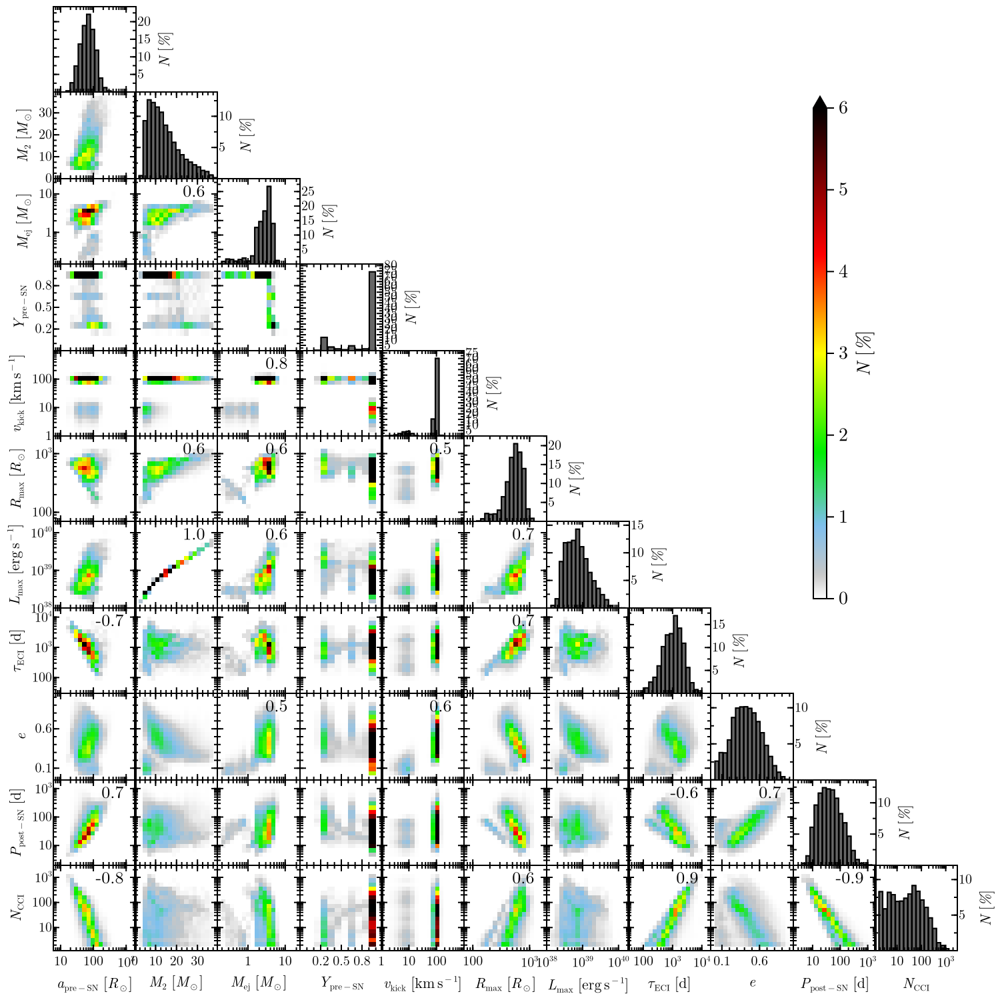

In [ ]:
fff_basic = sn1 .&& ccsne .&& .! (prgs .== "M" .|| prgs .== "NI-S") .&&  (SNe .== :Ibc .|| SNe .== :Ibn)

mycmap = cgrad([:white, :gray78, :skyblue2, :green2, :yellow, :red,  :black], 
                [0,      0.05,  0.15,  0.3,     0.5,  0.7,       1])

fff = fff_basic .&& (Rmax .> R2) .&& (post_SN_orbit .== :bound) .&& (n_passages .> 1) .&& ECI
isreplaceable(x) = x < 0

eccentricity = [isreplaceable(e) ? NaN : e for e in eccentricity]
P_postSN     = [isreplaceable(p) ? NaN : p for p in P_postSN    ]

@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

mlogticks = [k  for j in -90:1:90 for k in  (10. ^j):(10. ^j):(10. ^(j+1))]
mlinticks = 0:0.1:100
xticks10    = [10^t for t in -90.:1.:+90.]
logxticks10 = [t    for t in -90.:1.:+90.]
ticklabels  = [latexstring(@sprintf("10^{%d}", t)) for t in -90:90]
# ticklabels[findfirst(x->x==-2, logxticks10)]="0.01"
ticklabels[findfirst(x->x==-1, logxticks10)]="0.1"
ticklabels[findfirst(x->x== 0, logxticks10)]="1"
ticklabels[findfirst(x->x==+1, logxticks10)]="10"
ticklabels[findfirst(x->x==+2, logxticks10)]="100"
ticks    = (   xticks10, ticklabels)
logticks = (logxticks10, ticklabels)
linticks = 0:0.5:100
ticksize=11
FIGURE = Figure(size=(750,750), figure_padding = 5)
grid = GridLayout(FIGURE[0:10,0:10])
ax = Dict()
val_range = Dict("P"=>[2e0,2e3], 
                 "T"=>[30,2e4], 
                 "N"=>[1.2,3e3],
                 "e"=>[-0.05,1.05],
                 "Mej"=>[0.15,25],
                 "S"=>[1.3,2.25],
                 "Eexp"=>[3e50,1e52],
                 "M2"=>[0,39.5],
                 "Omega"=>[1.2e-6,0.15],
                 "h"=>[1e42,2e49],
                 "Rmax"=>[70,2_000],
                 "Lmax"=>[1e38,2e40],
                 "v_kick"=>[1,999],
                 "Y"=>[-.1,1.1],
                 "MejHe"=>[0,3],
                 "Teff"=>[1e3,1e4],
                 "Mi"=>[8,150],
                 "Pi"=>[0.1,5e3],
                 "qi"=>[0,1],
                 "a_pre"=>[6,2000])
val_scale = Dict("P"=>log10,"Y"=>identity,"qi"=>identity, "Mi"=>log10, "Pi"=>log10,
                 "T"=>log10, "N"=>log10, "e"=>identity, "h"=>log10,"v_kick"=>log10,
                 "Mej"=>log10, "MejHe"=>log10, "S"=>identity, "Eexp"=>log10, "M2"=>identity, "Teff"=>log10, 
                 "Omega"=>log10, "Rmax"=>log10, "Lmax"=>log10, "a_pre"=>log10)
dbins     = Dict("P"=>nothing, "T"=>nothing,"Teff"=>nothing, "N"=>nothing, "h"=>nothing, 
                "Omega"=>nothing,"a_pre"=>nothing, "Eexp"=>nothing,
                "Mej"=>nothing,"MejHe"=>nothing, "S"=>nothing, "e"=>nothing,  "M2"=>nothing,
                "v_kick"=>nothing,"Y"=>0.1, "Mi"=>nothing, "Pi"=>nothing, "qi"=>nothing, 
                "Rmax"=>nothing, "Lmax"=>nothing)
vals      = Dict("P" => P_postSN, 
                 "T"=>tau_ECI, 
                 "Teff"=>Teff_min,
                 "N"=>n_passages, 
                 "Mej"=>Mej,
                 "S"=>M_b_ns,
                 "pdf"=>pdfs/sum(pdfs[fff]) *100,
                 "e"=>eccentricity,
                 "Eexp"=>E_exp,
                 "M2"=>M2,
                 "h"=>Eheat,
                 "Omega"=>Omegaeff,
                 "Rmax" => Rmax,
                 "v_kick"=>v_kick,
                 "Lmax"=>Lmax,
                 "Y"=>Y1,
                 "Mi"=>M1,
                 "Pi"=>Pi,
                 "qi"=>qi,
                 "a_pre"=>a_pre)
ticks_xtra      = Dict("P" => nothing,
                 "T"=> nothing, 
                 "N"=>nothing, 
                 "Mej"=>nothing,
                 "S"=>nothing,
                 "Mi"=>nothing,
                 "Pi"=>nothing,
                 "Y"=>(0.2:0.3:1, 0.:0.1:1.0),
                 "qi"=>(0.:0.5:1, 0.:0.1:1.0),
                 "e"=>(0.1:0.5:1, 0.1:0.1:1.0),
                 "Eexp"=>nothing,
                 "M2"=>(0:10:100, 0:2.5:100),
                 "v_kick"=>nothing,
                 "h"=>nothing,
                 "Omega"=>nothing,
                 "Rmax" => nothing,
                 "Lmax"=>nothing,
                 "a_pre"=>nothing)
labels    = Dict("P"=>L"P_\mathrm{post-SN} \ [\mathrm{d}]",
                 "T"=>L"\tau_\mathrm{ECI} \ [\mathrm{d}]",
                 "N"=>L"N_\mathrm{CCI}",
                 "Mej"=>L"M_\mathrm{ej} \ [M_\odot]",
                 "S"=>L"M_\mathrm{NS} \ [M_\odot]",
                 "e"=>L"e",
                 "Eexp"=>L"E_\mathrm{kin,ej} \ [\mathrm{erg}]",
                 "M2"=>L"M_\mathrm{2} \ [M_\odot]",
                 "h"=>L"E_\mathrm{heat} \ [\mathrm{erg}]",
                 "Rmax"=>L"R_\mathrm{max} \ [R_\odot]",
                 "a_pre"=>L"a_\mathrm{pre-SN} \ [R_\odot]",
                 "<He>"=>L"Y_\mathrm{pre-SN}",
                 "Mi"=>L"M_\mathrm{1,i} \ [M_\odot]",
                 "Pi"=>L"P_\mathrm{i} \ [\mathrm{d}]",
                 "qi"=>"q_i",
                 "v_kick"=>L"v_\mathrm{kick} \ [\mathrm{km}\,\mathrm{s}^{-1}]",
                 "Lmax"=>L"L_\mathrm{max} \ [\mathrm{erg}\,\mathrm{s}^{-1}]",
                 "Omega"=>L"\tilde{\Omega}_\mathrm{eff}")
digits    = Dict("P"=>0,
                 "T"=>0,
                 "N"=>0,
                 "Mej"=>1,
                 "S"=>2,
                 "e"=>2,
                 "Eexp"=>1,
                 "M2"=>1,
                 "h"=>1,
                 "Rmax"=>0,
                 "a_pre"=>0,
                 "Lmax"=>0,
                 "Omega"=>4, "v_kick"=>0)
SN2022jli     = Dict("P"=>[12.4, :value], "T"=>[310, :lowerlimit], 
                     "N"=>[floor(305/12.4), :lowerlimit], "h"=>[NaN, :unknown],
                     "Omega"=>[NaN,:unknown], "Mej"=>[NaN, :unknown],
                     "S"=>[NaN,:unknown], "e"=>[0.7, :lowerlimit], "v_kick"=>[NaN, :unknown],
                     "E"=>[NaN,:unknown], "M2"=>[NaN,:unknown], "<He>"=>[0.5, :upperlimit],
                     "Rmax"=>[NaN,:unknown], "a_pre"=>[NaN,:unknown])

colorrange=[0.,6]
bin_scale = :uniform # :custom
variables    = ["a_pre", "M2", "Mej","MejHe", "Y", "Teff", "Lmax", "T", "e", "P", "N"]
# variables    = ["a_pre", "M2", "Mej"]#, "Mej","<He>",  "v_kick", "Rmax", "Lmax", "T", "e", "P"]
positions = Dict()
for k in range(1,length(variables)) 
        positions[variables[k]] = k  
end
cornerplots  = [[variables[i],variables[j]]
                        for i in 1:length(variables) 
                        for j in (i+1):length(variables)
                ]
for cornerplot in cornerplots
        x=cornerplot[1]
        y=cornerplot[2]
        ax[cornerplot] = plot_settings(grid[positions[y],positions[x]]; 
                ylabel=labels[y],
                xlabel=labels[x], 
                title =" ", 
                ymticks = val_scale[y] == log10 ? val_scale[y].(mlogticks) : ticks_xtra[y][2], 
                xmticks = val_scale[x] == log10 ? val_scale[x].(mlogticks) : ticks_xtra[x][2], 
                yticks  = val_scale[y] == log10 ? logticks  : ticks_xtra[y][1],
                xticks  = val_scale[x] == log10 ? logticks  : ticks_xtra[x][1],
                xlabelvisible = positions[y]==length(variables),
                xticklabelsvisible = positions[y]==length(variables),
                ylabelvisible = positions[x]==1,
                yticklabelsvisible = positions[x]==1,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1

                )
end
for h in variables
        ax[h] = plot_settings(grid[positions[h],positions[h]]; 
                ylabel=L"N \ [%]", 
                xlabel=labels[h], 
                title =" ",
                # xscale=val_scale[h],
                xticks  = val_scale[h] == log10 ? logticks  : ticks_xtra[h][1],
                xmticks = val_scale[h] == log10 ? val_scale[h].(mlogticks) : ticks_xtra[h][2], 
                yaxisposition=:right,
                xlabelvisible = positions[h]==length(variables),
                xticklabelsvisible = positions[h]==length(variables),
                yticks=5:5:100,
                ymticks=0:2.5:100,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1
                )
end

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_crit = Dict(occursin("Valli", KICKS) => "V25", occursin("MM", KICKS)=>"M16", occursin("DM25", KICKS)=>"DM25",occursin("COMBINE", KICKS)=>"K18", KICKS=="None"=>"None")[true]
simulation_settings = @sprintf("Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\nKicks: %s", f_B*100, exp_crit, mer_crit, kick_crit)

# # text!(FIGURE.scene, (.40, .85), text = simulation_settings, fontsize = 20, space = :relative)
# important_data = @sprintf(
# "Only %5.1f%% of Ibc+Ibn supernovae\nwith a MS companion are shown", 
#                 sum(pdfs[fff])/sum(pdfs[fff_basic])*100,
#                 )
# text!(FIGURE.scene, (.45, .9), text = important_data, fontsize = 14, space = :relative)
nbins = 20
hm = nothing   

alpha=1

color_coding = Dict()
color_coding[:MS] = RGBAf(.4,.4,.4,alpha)   
color_coding[:bound] = color_coding[:MS] 
colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=style, line_color=color,
                        bg_color= color2)
color_coding[:CCI] = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(0.,0.,0.,1), style = :plus))
color_coding[:unbound] = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(1.,1.,1.,1), style = :slash))
color_coding[:CCI] = color_coding[:MS] 

for cornerplot in cornerplots
        xlab = cornerplot[1]
        ylab = cornerplot[2]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        ymin = val_range[ylab][1]
        ymax = val_range[ylab][2]
        scalex = val_scale[xlab]
        scaley = val_scale[ylab]
        dxb = isnothing(dbins[xlab]) ?  (scalex(xmax)-scalex(xmin))/nbins : dbins[xlab]
        dyb = isnothing(dbins[ylab]) ?  (scaley(ymax)-scaley(ymin))/nbins : dbins[ylab]

        
        xbins=scalex(xmin):dxb:scalex(xmax)
        ybins=scaley(ymin):dyb:scaley(ymax)

        x = scalex.(vals[xlab][fff])
        y = scaley.(vals[ylab][fff])
        p = vals["pdf"][fff]
        hm = sn_heatmap(ax[cornerplot], x, y, p, xbins, ybins; colorrange=colorrange,
                cmap=mycmap, print_data=true, highclip=:black)
        PearsonCoeff = cor(reduce(hcat, [x,y]), Weights(p))[1,2]
        abs(PearsonCoeff) > 0.5 && text!(ax[cornerplot], @sprintf("%5.1f", PearsonCoeff),
        position = (.85, .95),        # relative coords in axis space
        align = (:right, :top),   # anchor point
        space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        )
        
        # scatter!(ax[cornerplot], scalex.(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1]), marker = :star5, color=RGBAf(1,1,1,0.5), strokecolor=:black, strokewidth=1 )
        # if SN2022jli[xlab][2] == :lowerlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (1, 0),
        #         lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # elseif SN2022jli[xlab][2] == :upperlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (-1, 0),
        #         lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # end
        # if SN2022jli[ylab][2] == :lowerlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (0, 1),
        #         lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # elseif SN2022jli[ylab][2] == :upperlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (0, -1),
        #         lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # end

        xlims!(ax[cornerplot], scalex(xmin), scalex(xmax))
        ylims!(ax[cornerplot], scaley(ymin), scaley(ymax))

end

fff_bc = fff .&& (post_SN_orbit .== :bound) .&& (Rmax .> R2) .&& (n_passages .> 1) .&& (ECI)
fff_bn = fff .&& (post_SN_orbit .== :bound) .&& .! fff_bc
fff_ub = fff .&& ((post_SN_orbit .== :unbound) .|| (post_SN_orbit .== :unknown))

for histogram in variables
        print(histogram, "\n")
        xlab = histogram
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        scalex = val_scale[xlab]
        dxb = isnothing(dbins[xlab]) ?  (scalex(xmax)-scalex(xmin))/nbins : dbins[xlab]
        xbins=scalex(xmin):dxb:scalex(xmax)

        x =  (vals[xlab])
        p =  vals["pdf"]
        bins, y_bins           = run_histogram(ax[histogram], scalex.(x[fff]),    p[fff],    xbins, dxb, norm=1, color = :white)
        _, y_bins_bound_andCCI = run_histogram(ax[histogram], scalex.(x[fff_bc]), p[fff_bc], xbins, dxb, norm=1, to_plot = false)
        _, y_bins_bound_noCCI  = run_histogram(ax[histogram], scalex.(x[fff_bn]), p[fff_bn], xbins, dxb, norm=1, to_plot = false)
        _, y_bins_unbound      = run_histogram(ax[histogram], scalex.(x[fff_ub]), p[fff_ub], xbins, dxb, norm=1, to_plot = false)
        # @show (xbins)
        # @show (dxb)
        # @show sum(y_bins)
        # @show minimum(bins)
        # # @show length(y_bins_bound_andCCI)
        # # @show length(y_bins_bound_noCCI)
        # # @show length(y_bins_unbound)
        ylims!(ax[histogram], 0, max( maximum(y_bins)*1.1, 12) )
        xlims!(ax[histogram], scalex(xmin), scalex(xmax))

        stacked_barplot!(ax[histogram],  (bins), [y_bins_bound_andCCI, y_bins_bound_noCCI, y_bins_unbound],
                                width = dxb, colors = [color_coding[:CCI], color_coding[:bound], color_coding[:unbound]] )
        _, y_bins_bound_andCCI = run_histogram(ax[histogram], scalex.(x[fff_bc]), p[fff_bc], xbins, dxb, norm=1, to_plot = true, color = RGBAf(0,0,0,0))


        # stats = POPSYNTH.report_stats(x, vals["pdf"], label = xlab, print2screen=true, unit = (1, ""), multip_percentiles=[0,2.5,5,10,25,50,75,90,95,97.5,100], format_str="%5.1f")    
        
        # stats_string = @sprintf "%*.*f^{+%*.*f}_{-%*.*f}" 5 digits[xlab] stats[1][1]  5 digits[xlab] stats[1][2]  5 digits[xlab] stats[1][3]
        # text!(ax[histogram], latexstring(stats_string),
        #         position = (.85, .95),        # relative coords in axis space
        #         align = (:right, :top),   # anchor point
        #         space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        # )

end

Colorbar(FIGURE[1:6,9], hm, label=L"N \ [%]",size = 10)
colgap!(grid, -27)
rowgap!(grid,0)

save_directory = "../output/ECI/cornerplots/"
outfilename = @sprintf("cps_ECI_CCIonly_%s_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT, KICKS)
save(save_directory*outfilename, FIGURE)

FIGURE

The data in this plot affects 22.907 % of all CCSNe
["M2", "Teff"]
Weights: min=1.492e-03, max=2.267e+00, min/max=6.582e-04
["M2", "Lmax"]
Weights: min=3.246e-03, max=9.803e+00, min/max=3.311e-04
["M2", "T"]
Weights: min=1.743e-03, max=1.373e+00, min/max=1.269e-03
["Teff", "Lmax"]
Weights: min=2.036e-03, max=1.839e+00, min/max=1.107e-03
["Teff", "T"]
Weights: min=3.791e-03, max=5.844e+00, min/max=6.488e-04
["Lmax", "T"]
Weights: min=1.743e-03, max=1.092e+00, min/max=1.596e-03
M2
Teff
Lmax
T


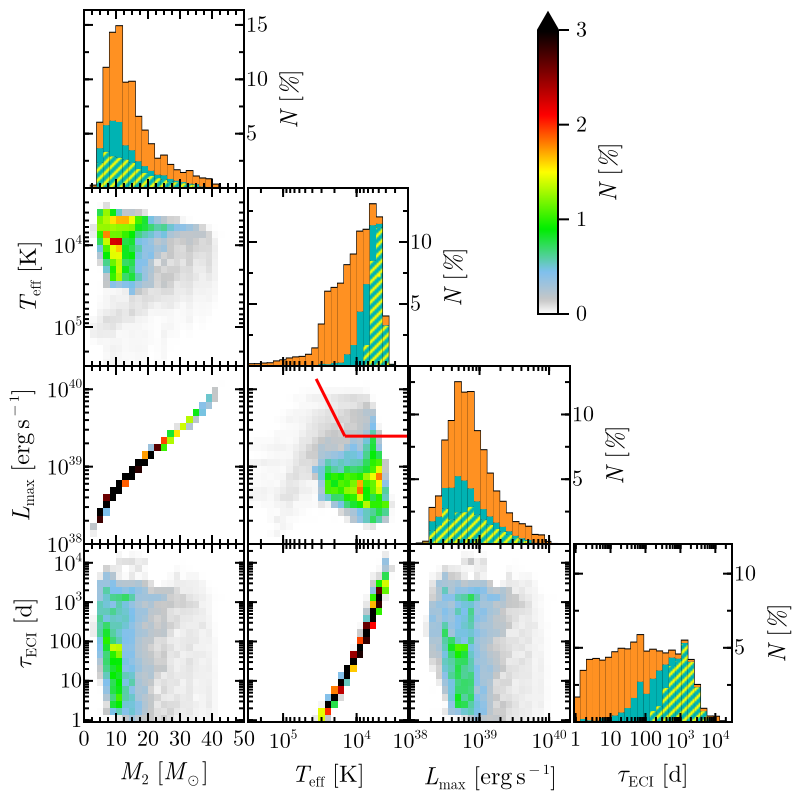

In [141]:
fff_basic = sn1 .&& ccsne .&& .! (prgs .== "M" .|| prgs .== "NI-S") .&&  (SNe .== :Ibc .|| SNe .== :Ibn)
fff_all = sn1 .&& ccsne .&& .! (prgs .== "M" .|| prgs .== "NI-S")
mycmap = cgrad([:white, :gray78, :skyblue2, :green2, :yellow, :red,  :black], 
                [0,      0.05,  0.15,  0.3,     0.5,  0.7,       1])

fff = fff_basic # .&& (Rmax .> R2) .&& (post_SN_orbit .== :bound) .&& (n_passages .> 1) .&& ECI
isreplaceable(x) = x < 0

#L=4 pi sigma R²T⁴

eccentricity = [isreplaceable(e) ? NaN : e for e in eccentricity]
P_postSN     = [isreplaceable(p) ? NaN : p for p in P_postSN    ]

@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

mlogticks = [k  for j in -90:1:90 for k in  (10. ^j):(10. ^j):(10. ^(j+1))]
mlinticks = 0:0.1:100
xticks10    = [10^t for t in -90.:1.:+90.]
logxticks10 = [t    for t in -90.:1.:+90.]
ticklabels  = [latexstring(@sprintf("10^{%d}", t)) for t in -90:90]
# ticklabels[findfirst(x->x==-2, logxticks10)]="0.01"
ticklabels[findfirst(x->x==-1, logxticks10)]="0.1"
ticklabels[findfirst(x->x== 0, logxticks10)]="1"
ticklabels[findfirst(x->x==+1, logxticks10)]="10"
ticklabels[findfirst(x->x==+2, logxticks10)]="100"
ticks    = (   xticks10, ticklabels)
logticks = (logxticks10, ticklabels)
linticks = 0:0.5:100
ticksize=12
FIGURE = Figure(size=(400,400), figure_padding = 5)
grid = GridLayout(FIGURE[0:10,0:10])
ax = Dict()
val_range = Dict("P"=>[2e0,4e4,:normal], 
                 "T"=>[.9,3e4,:normal], 
                 "N"=>[1.2,3e3,:normal],
                 "e"=>[-0.05,1.05,:normal],
                 "Mej"=>[0.15,25,:normal],
                 "S"=>[1.3,2.25,:normal],
                 "Eexp"=>[3e50,1e52,:normal],
                 "M2"=>[0,50,:normal],
                 "Omega"=>[1.2e-6,0.15,:normal],
                 "h"=>[1e42,2e49,:normal],
                 "Rmax"=>[10,2_000,:normal],
                 "Lmax"=>[1e38,2e40,:normal],
                 "v_kick"=>[1,999,:normal],
                 "<He>"=>[-.1,.89, :normal],
                 "Teff"=>[2_000, 3e5, :reverse],
                 "Mi"=>[8,150,:normal],
                 "Pi"=>[0.1,5e3,:normal],
                 "qi"=>[0,1,:normal],
                 "a_pre"=>[6,6000,:normal])
val_scale = Dict("P"=>log10,"<He>"=>identity,"qi"=>identity, "Mi"=>log10, "Pi"=>log10,
                 "T"=>log10, "N"=>log10, "e"=>identity, "h"=>log10,"v_kick"=>log10,
                 "Mej"=>log10, "S"=>identity, "Eexp"=>log10, "M2"=>identity,
                 "Omega"=>log10, "Rmax"=>log10, "Lmax"=>log10, "a_pre"=>log10,
                 "Teff"=>log10)
dbins     = Dict("P"=>nothing, "T"=>nothing, "N"=>nothing, "h"=>nothing, 
                "Omega"=>nothing,"a_pre"=>nothing, "Eexp"=>nothing, "Teff"=>nothing,
                "Mej"=>nothing, "S"=>nothing, "e"=>nothing,  "M2"=>nothing,
                "v_kick"=>nothing,"<He>"=>0.1, "Mi"=>nothing, "Pi"=>nothing, "qi"=>nothing, 
                "Rmax"=>nothing, "Lmax"=>nothing)
vals      = Dict("P" => P_postSN, 
                 "T"=>tau_ECI, 
                 "N"=>n_passages, 
                 "Mej"=>Mej,
                 "S"=>M_b_ns,
                 "pdf"=>pdfs/sum(pdfs[fff]) *100,
                 "e"=>eccentricity,
                 "Eexp"=>E_exp,
                 "M2"=>M2,
                 "h"=>Eheat,
                 "Omega"=>Omegaeff,
                 "Rmax" => Rmax,
                 "v_kick"=>v_kick,
                 "Lmax"=>Lmax,
                 "<He>"=>avg_he,
                 "Mi"=>M1,
                 "Pi"=>Pi,
                 "Teff"=>Teff_min,
                 "qi"=>qi,
                 "a_pre"=>a_pre)
ticks_xtra      = Dict("P" => nothing,
                 "T"=> nothing, 
                 "N"=>nothing, 
                 "Mej"=>nothing,
                 "S"=>nothing,
                 "Mi"=>nothing,
                 "Pi"=>nothing,
                 "Teff"=>nothing,
                 "<He>"=>(0.:0.3:1, 0.:0.1:1.0),
                 "qi"=>(0.:0.5:1, 0.:0.1:1.0),
                 "e"=>(0.1:0.5:1, 0.1:0.1:1.0),
                 "Eexp"=>nothing,
                 "M2"=>(0:10:100, 0:2.5:100),
                 "v_kick"=>nothing,
                 "h"=>nothing,
                 "Omega"=>nothing,
                 "Rmax" => nothing,
                 "Lmax"=>nothing,
                 "a_pre"=>nothing)
labels    = Dict("P"=>L"P_\mathrm{post-SN} \ [\mathrm{d}]",
                 "T"=>L"\tau_\mathrm{ECI} \ [\mathrm{d}]",
                 "N"=>L"N_\mathrm{CCI}",
                 "Mej"=>L"M_\mathrm{ej} \ [M_\odot]",
                 "S"=>L"M_\mathrm{NS} \ [M_\odot]",
                 "e"=>L"e",
                 "Teff"=>L"T_\mathrm{eff} \ [\mathrm{K}]",
                 "Eexp"=>L"E_\mathrm{kin,ej} \ [\mathrm{erg}]",
                 "M2"=>L"M_\mathrm{2} \ [M_\odot]",
                 "h"=>L"E_\mathrm{heat} \ [\mathrm{erg}]",
                 "Rmax"=>L"R_\mathrm{max} \ [R_\odot]",
                 "a_pre"=>L"a_\mathrm{pre-SN} \ [R_\odot]",
                 "<He>"=>L"⟨X_\mathrm{He}⟩",
                 "Mi"=>L"M_\mathrm{1,i} \ [M_\odot]",
                 "Pi"=>L"P_\mathrm{i} \ [\mathrm{d}]",
                 "qi"=>"q_i",
                 "v_kick"=>L"v_\mathrm{kick} \ [\mathrm{km}\,\mathrm{s}^{-1}]",
                 "Lmax"=>L"L_\mathrm{max} \ [\mathrm{erg}\,\mathrm{s}^{-1}]",
                 "Omega"=>L"\tilde{\Omega}_\mathrm{eff}")
digits    = Dict("P"=>0,
                 "T"=>0,
                 "N"=>0,
                 "Mej"=>1,
                 "S"=>2,
                 "e"=>2,
                 "Eexp"=>1,
                 "M2"=>1,
                 "h"=>1,
                 "Teff"=>1,
                 "Rmax"=>0,
                 "a_pre"=>0,
                 "Lmax"=>0,
                 "Omega"=>4, "v_kick"=>0)

colorrange=[0.,3]
bin_scale = :uniform # :custom
variables    = ["M2", "Teff", "Lmax", "T"]
# variables    = ["a_pre", "M2", "Mej"]#, "Mej","<He>",  "v_kick", "Rmax", "Lmax", "T", "e", "P"]
positions = Dict()
for k in range(1,length(variables)) 
        positions[variables[k]] = k  
end
cornerplots  = [[variables[i],variables[j]]
                        for i in 1:length(variables) 
                        for j in (i+1):length(variables)
                ]
for cornerplot in cornerplots
        x=cornerplot[1]
        y=cornerplot[2]
        ax[cornerplot] = plot_settings(grid[positions[y],positions[x]]; 
                ylabel=labels[y],
                xlabel=labels[x], 
                title =" ", 
                ymticks = val_scale[y] == log10 ? val_scale[y].(mlogticks) : ticks_xtra[y][2], 
                xmticks = val_scale[x] == log10 ? val_scale[x].(mlogticks) : ticks_xtra[x][2], 
                yticks  = val_scale[y] == log10 ? logticks  : ticks_xtra[y][1],
                xticks  = val_scale[x] == log10 ? logticks  : ticks_xtra[x][1],
                xlabelvisible = positions[y]==length(variables),
                xticklabelsvisible = positions[y]==length(variables),
                ylabelvisible = positions[x]==1,
                yticklabelsvisible = positions[x]==1,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1,
                xreversed=(val_range[x][3] == :reverse),
                yreversed=(val_range[y][3] == :reverse),
                )
end
for h in variables
        ax[h] = plot_settings(grid[positions[h],positions[h]]; 
                ylabel=L"N \ [%]", 
                xlabel=labels[h], 
                title =" ",
                # xscale=val_scale[h],
                xticks  = val_scale[h] == log10 ? logticks  : ticks_xtra[h][1],
                xmticks = val_scale[h] == log10 ? val_scale[h].(mlogticks) : ticks_xtra[h][2], 
                yaxisposition=:right,
                xlabelvisible = positions[h]==length(variables),
                xticklabelsvisible = positions[h]==length(variables),
                yticks=5:5:100,
                ymticks=0:2.5:100,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1,
                yreversed=(val_range[h][3] == :reverse),
                )
end

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_crit = Dict(occursin("Valli", KICKS) => "V25", occursin("MM", KICKS)=>"M16", occursin("DM25", KICKS)=>"DM25",occursin("COMBINE", KICKS)=>"K18", KICKS=="None"=>"None")[true]
simulation_settings = @sprintf("Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\nKicks: %s", f_B*100, exp_crit, mer_crit, kick_crit)

# # text!(FIGURE.scene, (.40, .85), text = simulation_settings, fontsize = 20, space = :relative)
# important_data = @sprintf(
# "Only %5.1f%% of Ibc+Ibn supernovae\nwith a MS companion are shown", 
#                 sum(pdfs[fff])/sum(pdfs[fff_basic])*100,
#                 )
# text!(FIGURE.scene, (.45, .9), text = important_data, fontsize = 14, space = :relative)
nbins = 25
hm = nothing   

alpha=1

color_coding = Dict()
color_coding[:bound]   =   RGBAf(  0/256,180/256,180/256,1)   
colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=style, line_color=color,
                        bg_color= color2)
# color_coding[:CCI] = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(0.,0.,0.,1), style = :plus))
color_coding[:unbound] = RGBAf(255/255, 145/255, 33/245 ,1) 
# color_coding[:CCI] = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(0,0,0,1), style = :slash))
color_coding[:CCI] = Pattern(colorhatch(color_coding[:bound],color2=RGBAf(1.,1.,0.,1), style = :slash))

for cornerplot in cornerplots
        print(cornerplot, "\n")
        xlab = cornerplot[1]
        ylab = cornerplot[2]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        ymin = val_range[ylab][1]
        ymax = val_range[ylab][2]
        scalex = val_scale[xlab]
        scaley = val_scale[ylab]
        dxb = isnothing(dbins[xlab]) ?  (scalex(xmax)-scalex(xmin))/nbins : dbins[xlab]
        dyb = isnothing(dbins[ylab]) ?  (scaley(ymax)-scaley(ymin))/nbins : dbins[ylab]
        
        xbins=scalex(xmin):dxb:scalex(xmax)
        ybins=scaley(ymin):dyb:scaley(ymax)
        # print(xbins, "\n", ybins)
        x = scalex.(vals[xlab][fff])
        y = scaley.(vals[ylab][fff])
        if isempty(x)  || isempty(xbins)
                print("x=$xlab is empty! xbins = $xbins")
        end
        if isempty(y) || isempty(ybins)
                print("y=$ylab is empty! ybins = $ybins")
        end
        (isempty(x) || isempty(y)) && throw(ErrorException("X or Y arrays are empty! Check!"))
        
        p = vals["pdf"][fff]
        hm = sn_heatmap(ax[cornerplot], x, y, p, xbins, ybins; colorrange=colorrange,
                cmap=mycmap, print_data=true, highclip=:black)
        PearsonCoeff = cor(reduce(hcat, [x,y]), Weights(p))[1,2]
        abs(PearsonCoeff) > 0.5 && text!(ax[cornerplot], @sprintf("%5.1f", PearsonCoeff),
                position = (.85, .95),        # relative coords in axis space
                align = (:right, :top),   # anchor point
                space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        )
        
        # scatter!(ax[cornerplot], scalex.(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1]), marker = :star5, color=RGBAf(1,1,1,0.5), strokecolor=:black, strokewidth=1 )
        # if SN2022jli[xlab][2] == :lowerlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (1, 0),
        #         lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # elseif SN2022jli[xlab][2] == :upperlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (-1, 0),
        #         lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # end
        # if SN2022jli[ylab][2] == :lowerlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (0, 1),
        #         lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # elseif SN2022jli[ylab][2] == :upperlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (0, -1),
        #         lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # end

        xlims!(ax[cornerplot], scalex(val_range[xlab][3]==:reverse ? xmax : xmin ), scalex(val_range[xlab][3]==:reverse ? xmin : xmax ))
        ylims!(ax[cornerplot], scaley(val_range[ylab][3]==:reverse ? ymax : ymin ), scaley(val_range[ylab][3]==:reverse ? ymin : ymax ))

end

if ["Teff", "Lmax"] in cornerplots 
        hrd = ax[["Teff", "Lmax"]]
        scalex = val_scale["Teff"]
        scaley = val_scale["Lmax"]
        cool_hd = (10. .^ [4.16, 3.00], 10. .^ [5.81, 5.81] .* POPSYNTH.Lsun)
        hot_hd =  (10. .^ [4.55, 4.16], 10. .^ [6.55, 5.81] .* POPSYNTH.Lsun)
        lines!(hrd, scalex.(cool_hd[1]), scaley.(cool_hd[2]), color = :red)
        lines!(hrd, scalex.(hot_hd[1]), scaley.(hot_hd[2]), color = :red)
end


fff_bc = fff .&& (post_SN_orbit .== :bound) .&& (Rmax .> R2) .&& (n_passages .> 1) .&& (ECI)
fff_bn = fff .&& (post_SN_orbit .== :bound) .&& .! fff_bc
fff_ub = fff .&& ((post_SN_orbit .== :unbound) .|| (post_SN_orbit .== :unknown))

for histogram in variables
        print(histogram, "\n")
        xlab = histogram
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        scalex = val_scale[xlab]
        dxb = isnothing(dbins[xlab]) ?  (scalex(xmax)-scalex(xmin))/nbins : dbins[xlab]
        xbins=scalex(xmin):dxb:scalex(xmax)
        ax[histogram].xreversed = (val_range[xlab][3] == :reverse)

        x =  (vals[xlab])
        p =  vals["pdf"]
        bins, y_bins           = run_histogram(ax[histogram], scalex.(x[fff]),    p[fff],    xbins, dxb, norm=1, color = :gray)
        _, y_bins_bound_andCCI = run_histogram(ax[histogram], scalex.(x[fff_bc]), p[fff_bc], xbins, dxb, norm=1, to_plot = false)
        _, y_bins_bound_noCCI  = run_histogram(ax[histogram], scalex.(x[fff_bn]), p[fff_bn], xbins, dxb, norm=1, to_plot = false)
        _, y_bins_unbound      = run_histogram(ax[histogram], scalex.(x[fff_ub]), p[fff_ub], xbins, dxb, norm=1, to_plot = false)
        # @show (xbins)
        # @show (dxb)
        # @show sum(y_bins)
        # @show minimum(bins)
        # # @show length(y_bins_bound_andCCI)
        # # @show length(y_bins_bound_noCCI)
        # # @show length(y_bins_unbound)
        ylims!(ax[histogram], 0, max( maximum(y_bins)*1.1, 12) )
        xlims!(ax[histogram], scalex(val_range[xlab][3]==:reverse ? xmax : xmin ), scalex(val_range[xlab][3]==:reverse ? xmin : xmax ))

        stacked_barplot!(ax[histogram],  (bins), [y_bins_bound_andCCI, y_bins_bound_noCCI, y_bins_unbound],
                                width = dxb, colors = [color_coding[:CCI], color_coding[:bound], color_coding[:unbound]] )


        # stats = POPSYNTH.report_stats(x, vals["pdf"], label = xlab, print2screen=true, unit = (1, ""), multip_percentiles=[0,2.5,5,10,25,50,75,90,95,97.5,100], format_str="%5.1f")    
        
        # stats_string = @sprintf "%*.*f^{+%*.*f}_{-%*.*f}" 5 digits[xlab] stats[1][1]  5 digits[xlab] stats[1][2]  5 digits[xlab] stats[1][3]
        # text!(ax[histogram], latexstring(stats_string),
        #         position = (.85, .95),        # relative coords in axis space
        #         align = (:right, :top),   # anchor point
        #         space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        # )

end

Colorbar(FIGURE[0:4,8], hm, label=L"N \ [%]", size = 10, 
                labelsize=ticksize, ticklabelsize=ticksize-1)
colgap!(grid, -27)
rowgap!(grid,0)

save_directory = "../output/ECI/cornerplots/"
outfilename = @sprintf("cps_ECI_LTM_%s_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT, KICKS)
save(save_directory*outfilename, FIGURE)

FIGURE

In [137]:
10^4*POPSYNTH.day/POPSYNTH.yr

27.393785668991757

The data in this plot affects 1.889 % of all CCSNe
["M2", "Teff"]
Weights: min=2.114e-02, max=4.806e+00, min/max=4.399e-03
["M2", "Lmax"]
Weights: min=3.937e-02, max=1.504e+01, min/max=2.618e-03
["M2", "T"]
Weights: min=2.114e-02, max=2.356e+00, min/max=8.974e-03
["Teff", "Lmax"]
Weights: min=2.114e-02, max=3.841e+00, min/max=5.504e-03
["Teff", "T"]
Weights: min=6.394e-02, max=7.968e+00, min/max=8.025e-03
["Lmax", "T"]
Weights: min=2.114e-02, max=1.920e+00, min/max=1.101e-02
M2
Teff
Lmax
T


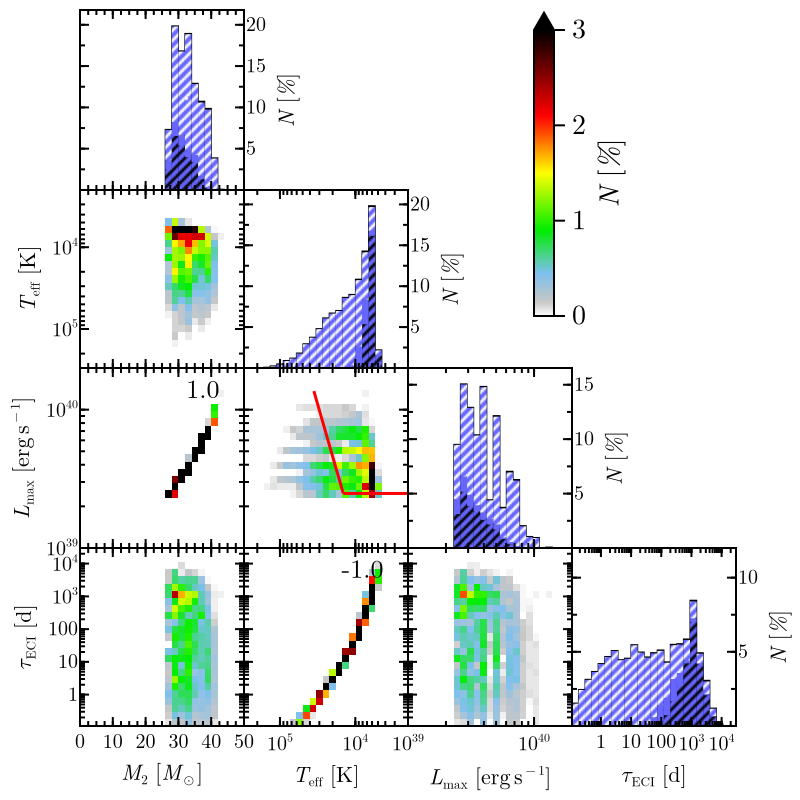

In [135]:
fff_basic = sn1 .&& ccsne .&& .! (prgs .== "M" .|| prgs .== "NI-S") .&&  (SNe .== :Ibc .|| SNe .== :Ibn)
fff_all = sn1 .&& ccsne .&& .! (prgs .== "M" .|| prgs .== "NI-S")
mycmap = cgrad([:white, :gray78, :skyblue2, :green2, :yellow, :red,  :black], 
                [0,      0.05,  0.15,  0.3,     0.5,  0.7,       1])

fff = fff_basic .&& (Lmax .> 10. .^ 5.8 .* POPSYNTH.Lsun) # .&& (Rmax .> R2) .&& (post_SN_orbit .== :bound) .&& (n_passages .> 1) .&& ECI
isreplaceable(x) = x < 0

#L=4 pi sigma R²T⁴
Teff_min =  @. ( Lmax/(4*π*POPSYNTH.sigma_boltz*(Rmax*Rsun)^2) ) .^ (1/4)

eccentricity = [isreplaceable(e) ? NaN : e for e in eccentricity]
P_postSN     = [isreplaceable(p) ? NaN : p for p in P_postSN    ]

@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

mlogticks = [k  for j in -90:1:90 for k in  (10. ^j):(10. ^j):(10. ^(j+1))]
mlinticks = 0:0.1:100
xticks10    = [10^t for t in -90.:1.:+90.]
logxticks10 = [t    for t in -90.:1.:+90.]
ticklabels  = [latexstring(@sprintf("10^{%d}", t)) for t in -90:90]
# ticklabels[findfirst(x->x==-2, logxticks10)]="0.01"
ticklabels[findfirst(x->x==-1, logxticks10)]="0.1"
ticklabels[findfirst(x->x== 0, logxticks10)]="1"
ticklabels[findfirst(x->x==+1, logxticks10)]="10"
ticklabels[findfirst(x->x==+2, logxticks10)]="100"
ticks    = (   xticks10, ticklabels)
logticks = (logxticks10, ticklabels)
linticks = 0:0.5:100
ticksize=11
FIGURE = Figure(size=(400,400), figure_padding = 5)
grid = GridLayout(FIGURE[0:10,0:10])
ax = Dict()
val_range = Dict("P"=>[2e0,4e4,:normal], 
                 "T"=>[.11,3e4,:normal], 
                 "N"=>[1.2,3e3,:normal],
                 "e"=>[-0.05,1.05,:normal],
                 "Mej"=>[0.15,25,:normal],
                 "S"=>[1.3,2.25,:normal],
                 "Eexp"=>[3e50,1e52,:normal],
                 "M2"=>[0,50,:normal],
                 "Omega"=>[1.2e-6,0.15,:normal],
                 "h"=>[1e42,2e49,:normal],
                 "Rmax"=>[10,2_000,:normal],
                 "Lmax"=>[1e39,2e40,:normal],
                 "v_kick"=>[1,999,:normal],
                 "<He>"=>[-.1,.89, :normal],
                 "Teff"=>[2_000, 3e5, :reverse],
                 "Mi"=>[8,150,:normal],
                 "Pi"=>[0.1,5e3,:normal],
                 "qi"=>[0,1,:normal],
                 "a_pre"=>[6,6000,:normal])
val_scale = Dict("P"=>log10,"<He>"=>identity,"qi"=>identity, "Mi"=>log10, "Pi"=>log10,
                 "T"=>log10, "N"=>log10, "e"=>identity, "h"=>log10,"v_kick"=>log10,
                 "Mej"=>log10, "S"=>identity, "Eexp"=>log10, "M2"=>identity,
                 "Omega"=>log10, "Rmax"=>log10, "Lmax"=>log10, "a_pre"=>log10,
                 "Teff"=>log10)
dbins     = Dict("P"=>nothing, "T"=>nothing, "N"=>nothing, "h"=>nothing, 
                "Omega"=>nothing,"a_pre"=>nothing, "Eexp"=>nothing, "Teff"=>nothing,
                "Mej"=>nothing, "S"=>nothing, "e"=>nothing,  "M2"=>nothing,
                "v_kick"=>nothing,"<He>"=>0.1, "Mi"=>nothing, "Pi"=>nothing, "qi"=>nothing, 
                "Rmax"=>nothing, "Lmax"=>nothing)
vals      = Dict("P" => P_postSN, 
                 "T"=>tau_ECI, 
                 "N"=>n_passages, 
                 "Mej"=>Mej,
                 "S"=>M_b_ns,
                 "pdf"=>pdfs/sum(pdfs[fff]) *100,
                 "e"=>eccentricity,
                 "Eexp"=>E_exp,
                 "M2"=>M2,
                 "h"=>Eheat,
                 "Omega"=>Omegaeff,
                 "Rmax" => Rmax,
                 "v_kick"=>v_kick,
                 "Lmax"=>Lmax,
                 "<He>"=>avg_he,
                 "Mi"=>M1,
                 "Pi"=>Pi,
                 "Teff"=>Teff_min,
                 "qi"=>qi,
                 "a_pre"=>a_pre)
ticks_xtra      = Dict("P" => nothing,
                 "T"=> nothing, 
                 "N"=>nothing, 
                 "Mej"=>nothing,
                 "S"=>nothing,
                 "Mi"=>nothing,
                 "Pi"=>nothing,
                 "Teff"=>nothing,
                 "<He>"=>(0.:0.3:1, 0.:0.1:1.0),
                 "qi"=>(0.:0.5:1, 0.:0.1:1.0),
                 "e"=>(0.1:0.5:1, 0.1:0.1:1.0),
                 "Eexp"=>nothing,
                 "M2"=>(0:10:100, 0:2.5:100),
                 "v_kick"=>nothing,
                 "h"=>nothing,
                 "Omega"=>nothing,
                 "Rmax" => nothing,
                 "Lmax"=>nothing,
                 "a_pre"=>nothing)
labels    = Dict("P"=>L"P_\mathrm{post-SN} \ [\mathrm{d}]",
                 "T"=>L"\tau_\mathrm{ECI} \ [\mathrm{d}]",
                 "N"=>L"N_\mathrm{CCI}",
                 "Mej"=>L"M_\mathrm{ej} \ [M_\odot]",
                 "S"=>L"M_\mathrm{NS} \ [M_\odot]",
                 "e"=>L"e",
                 "Teff"=>L"T_\mathrm{eff} \ [\mathrm{K}]",
                 "Eexp"=>L"E_\mathrm{kin,ej} \ [\mathrm{erg}]",
                 "M2"=>L"M_\mathrm{2} \ [M_\odot]",
                 "h"=>L"E_\mathrm{heat} \ [\mathrm{erg}]",
                 "Rmax"=>L"R_\mathrm{max} \ [R_\odot]",
                 "a_pre"=>L"a_\mathrm{pre-SN} \ [R_\odot]",
                 "<He>"=>L"⟨X_\mathrm{He}⟩",
                 "Mi"=>L"M_\mathrm{1,i} \ [M_\odot]",
                 "Pi"=>L"P_\mathrm{i} \ [\mathrm{d}]",
                 "qi"=>"q_i",
                 "v_kick"=>L"v_\mathrm{kick} \ [\mathrm{km}\,\mathrm{s}^{-1}]",
                 "Lmax"=>L"L_\mathrm{max} \ [\mathrm{erg}\,\mathrm{s}^{-1}]",
                 "Omega"=>L"\tilde{\Omega}_\mathrm{eff}")
digits    = Dict("P"=>0,
                 "T"=>0,
                 "N"=>0,
                 "Mej"=>1,
                 "S"=>2,
                 "e"=>2,
                 "Eexp"=>1,
                 "M2"=>1,
                 "h"=>1,
                 "Teff"=>1,
                 "Rmax"=>0,
                 "a_pre"=>0,
                 "Lmax"=>0,
                 "Omega"=>4, "v_kick"=>0)

colorrange=[0.,3]
bin_scale = :uniform # :custom
variables    = ["M2", "Teff", "Lmax", "T"]
# variables    = ["a_pre", "M2", "Mej"]#, "Mej","<He>",  "v_kick", "Rmax", "Lmax", "T", "e", "P"]
positions = Dict()
for k in range(1,length(variables)) 
        positions[variables[k]] = k  
end
cornerplots  = [[variables[i],variables[j]]
                        for i in 1:length(variables) 
                        for j in (i+1):length(variables)
                ]
for cornerplot in cornerplots
        x=cornerplot[1]
        y=cornerplot[2]
        ax[cornerplot] = plot_settings(grid[positions[y],positions[x]]; 
                ylabel=labels[y],
                xlabel=labels[x], 
                title =" ", 
                ymticks = val_scale[y] == log10 ? val_scale[y].(mlogticks) : ticks_xtra[y][2], 
                xmticks = val_scale[x] == log10 ? val_scale[x].(mlogticks) : ticks_xtra[x][2], 
                yticks  = val_scale[y] == log10 ? logticks  : ticks_xtra[y][1],
                xticks  = val_scale[x] == log10 ? logticks  : ticks_xtra[x][1],
                xlabelvisible = positions[y]==length(variables),
                xticklabelsvisible = positions[y]==length(variables),
                ylabelvisible = positions[x]==1,
                yticklabelsvisible = positions[x]==1,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1,
                xreversed=(val_range[x][3] == :reverse),
                yreversed=(val_range[y][3] == :reverse),
                )
end
for h in variables
        ax[h] = plot_settings(grid[positions[h],positions[h]]; 
                ylabel=L"N \ [%]", 
                xlabel=labels[h], 
                title =" ",
                # xscale=val_scale[h],
                xticks  = val_scale[h] == log10 ? logticks  : ticks_xtra[h][1],
                xmticks = val_scale[h] == log10 ? val_scale[h].(mlogticks) : ticks_xtra[h][2], 
                yaxisposition=:right,
                xlabelvisible = positions[h]==length(variables),
                xticklabelsvisible = positions[h]==length(variables),
                yticks=5:5:100,
                ymticks=0:2.5:100,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1,
                yreversed=(val_range[h][3] == :reverse),
                )
end

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_crit = Dict(occursin("Valli", KICKS) => "V25", occursin("MM", KICKS)=>"M16", occursin("DM25", KICKS)=>"DM25",occursin("COMBINE", KICKS)=>"K18", KICKS=="None"=>"None")[true]
simulation_settings = @sprintf("Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\nKicks: %s", f_B*100, exp_crit, mer_crit, kick_crit)

# # text!(FIGURE.scene, (.40, .85), text = simulation_settings, fontsize = 20, space = :relative)
# important_data = @sprintf(
# "Only %5.1f%% of Ibc+Ibn supernovae\nwith a MS companion are shown", 
#                 sum(pdfs[fff])/sum(pdfs[fff_basic])*100,
#                 )
# text!(FIGURE.scene, (.45, .9), text = important_data, fontsize = 14, space = :relative)
nbins = 25
hm = nothing   

alpha=1

color_coding = Dict()
color_coding[:MS] = RGBAf(.4,.4,1,alpha)   
color_coding[:bound] = color_coding[:MS] 
colorhatch(color; color2=RGBAf(0,0,0,0), style=:plus) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=style, line_color=color,
                        bg_color= color2)
color_coding[:CCI] = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(0.,0.,0.,1), style = :plus))
color_coding[:unbound] = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(1.,1.,1.,1), style = :slash))
color_coding[:CCI] = Pattern(colorhatch(color_coding[:MS],color2=RGBAf(0,0,0,1), style = :slash))

for cornerplot in cornerplots
        print(cornerplot, "\n")
        xlab = cornerplot[1]
        ylab = cornerplot[2]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        ymin = val_range[ylab][1]
        ymax = val_range[ylab][2]
        scalex = val_scale[xlab]
        scaley = val_scale[ylab]
        dxb = isnothing(dbins[xlab]) ?  (scalex(xmax)-scalex(xmin))/nbins : dbins[xlab]
        dyb = isnothing(dbins[ylab]) ?  (scaley(ymax)-scaley(ymin))/nbins : dbins[ylab]
        
        xbins=scalex(xmin):dxb:scalex(xmax)
        ybins=scaley(ymin):dyb:scaley(ymax)
        # print(xbins, "\n", ybins)
        x = scalex.(vals[xlab][fff])
        y = scaley.(vals[ylab][fff])
        if isempty(x)  || isempty(xbins)
                print("x=$xlab is empty! xbins = $xbins")
        end
        if isempty(y) || isempty(ybins)
                print("y=$ylab is empty! ybins = $ybins")
        end
        (isempty(x) || isempty(y)) && throw(ErrorException("X or Y arrays are empty! Check!"))
        
        p = vals["pdf"][fff]
        hm = sn_heatmap(ax[cornerplot], x, y, p, xbins, ybins; colorrange=colorrange,
                cmap=mycmap, print_data=true, highclip=:black)
        PearsonCoeff = cor(reduce(hcat, [x,y]), Weights(p))[1,2]
        abs(PearsonCoeff) > 0.5 && text!(ax[cornerplot], @sprintf("%5.1f", PearsonCoeff),
                position = (.85, .95),        # relative coords in axis space
                align = (:right, :top),   # anchor point
                space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        )
        
        # scatter!(ax[cornerplot], scalex.(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1]), marker = :star5, color=RGBAf(1,1,1,0.5), strokecolor=:black, strokewidth=1 )
        # if SN2022jli[xlab][2] == :lowerlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (1, 0),
        #         lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # elseif SN2022jli[xlab][2] == :upperlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (-1, 0),
        #         lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # end
        # if SN2022jli[ylab][2] == :lowerlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (0, 1),
        #         lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # elseif SN2022jli[ylab][2] == :upperlimit 
        #         arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (0, -1),
        #         lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        # end

        xlims!(ax[cornerplot], scalex(val_range[xlab][3]==:reverse ? xmax : xmin ), scalex(val_range[xlab][3]==:reverse ? xmin : xmax ))
        ylims!(ax[cornerplot], scaley(val_range[ylab][3]==:reverse ? ymax : ymin ), scaley(val_range[ylab][3]==:reverse ? ymin : ymax ))

end

if ["Teff", "Lmax"] in cornerplots 
        hrd = ax[["Teff", "Lmax"]]
        scalex = val_scale["Teff"]
        scaley = val_scale["Lmax"]
        cool_hd = (10. .^ [4.16, 3.00], 10. .^ [5.81, 5.81] .* POPSYNTH.Lsun)
        hot_hd =  (10. .^ [4.55, 4.16], 10. .^ [6.55, 5.81] .* POPSYNTH.Lsun)
        lines!(hrd, scalex.(cool_hd[1]), scaley.(cool_hd[2]), color = :red)
        lines!(hrd, scalex.(hot_hd[1]), scaley.(hot_hd[2]), color = :red)
end


fff_bc = fff .&& (post_SN_orbit .== :bound) .&& (Rmax .> R2) .&& (n_passages .> 1) .&& (ECI)
fff_bn = fff .&& (post_SN_orbit .== :bound) .&& .! fff_bc
fff_ub = fff .&& ((post_SN_orbit .== :unbound) .|| (post_SN_orbit .== :unknown))

for histogram in variables
        print(histogram, "\n")
        xlab = histogram
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        scalex = val_scale[xlab]
        dxb = isnothing(dbins[xlab]) ?  (scalex(xmax)-scalex(xmin))/nbins : dbins[xlab]
        xbins=scalex(xmin):dxb:scalex(xmax)
        ax[histogram].xreversed = (val_range[xlab][3] == :reverse)

        x =  (vals[xlab])
        p =  vals["pdf"]
        bins, y_bins           = run_histogram(ax[histogram], scalex.(x[fff]),    p[fff],    xbins, dxb, norm=1, color = :gray)
        _, y_bins_bound_andCCI = run_histogram(ax[histogram], scalex.(x[fff_bc]), p[fff_bc], xbins, dxb, norm=1, to_plot = false)
        _, y_bins_bound_noCCI  = run_histogram(ax[histogram], scalex.(x[fff_bn]), p[fff_bn], xbins, dxb, norm=1, to_plot = false)
        _, y_bins_unbound      = run_histogram(ax[histogram], scalex.(x[fff_ub]), p[fff_ub], xbins, dxb, norm=1, to_plot = false)
        # @show (xbins)
        # @show (dxb)
        # @show sum(y_bins)
        # @show minimum(bins)
        # # @show length(y_bins_bound_andCCI)
        # # @show length(y_bins_bound_noCCI)
        # # @show length(y_bins_unbound)
        ylims!(ax[histogram], 0, max( maximum(y_bins)*1.1, 12) )
        xlims!(ax[histogram], scalex(val_range[xlab][3]==:reverse ? xmax : xmin ), scalex(val_range[xlab][3]==:reverse ? xmin : xmax ))

        stacked_barplot!(ax[histogram],  (bins), [y_bins_bound_andCCI, y_bins_bound_noCCI, y_bins_unbound],
                                width = dxb, colors = [color_coding[:CCI], color_coding[:bound], color_coding[:unbound]] )


        # stats = POPSYNTH.report_stats(x, vals["pdf"], label = xlab, print2screen=true, unit = (1, ""), multip_percentiles=[0,2.5,5,10,25,50,75,90,95,97.5,100], format_str="%5.1f")    
        
        # stats_string = @sprintf "%*.*f^{+%*.*f}_{-%*.*f}" 5 digits[xlab] stats[1][1]  5 digits[xlab] stats[1][2]  5 digits[xlab] stats[1][3]
        # text!(ax[histogram], latexstring(stats_string),
        #         position = (.85, .95),        # relative coords in axis space
        #         align = (:right, :top),   # anchor point
        #         space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        # )

end

Colorbar(FIGURE[0:4,8], hm, label=L"N \ [%]",size = 10)
colgap!(grid, -27)
rowgap!(grid,0)

save_directory = "../output/ECI/cornerplots/"
outfilename = @sprintf("cps_ECI_LMT_HD_%s_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT, KICKS)
save(save_directory*outfilename, FIGURE)

FIGURE

The data in this plot affects 2.803 % of all CCSNe
Weights: min=4.938e-02, max=1.640e+01, min/max=3.011e-03
Weights: min=3.098e-02, max=1.004e+01, min/max=3.085e-03
Weights: min=3.619e-02, max=1.430e+01, min/max=2.531e-03
Weights: min=3.619e-02, max=4.580e+00, min/max=7.901e-03
Weights: min=1.664e-02, max=1.282e+01, min/max=1.298e-03
Weights: min=1.664e-02, max=5.194e+00, min/max=3.203e-03
Weights: min=1.664e-02, max=1.045e+01, min/max=1.592e-03
Weights: min=1.664e-02, max=1.317e+01, min/max=1.264e-03
Weights: min=2.270e-02, max=7.997e+00, min/max=2.839e-03
Weights: min=4.938e-02, max=1.231e+01, min/max=4.013e-03
Weights: min=9.196e-02, max=1.424e+01, min/max=6.458e-03
Weights: min=1.251e-01, max=7.557e+00, min/max=1.655e-02
Weights: min=2.000e-01, max=1.821e+01, min/max=1.098e-02
Weights: min=2.652e-02, max=7.149e+00, min/max=3.710e-03
Weights: min=8.455e-02, max=1.532e+01, min/max=5.519e-03
Weights: min=4.938e-02, max=1.985e+01, min/max=2.487e-03
Weights: min=2.270e-02, max=1.486e+01

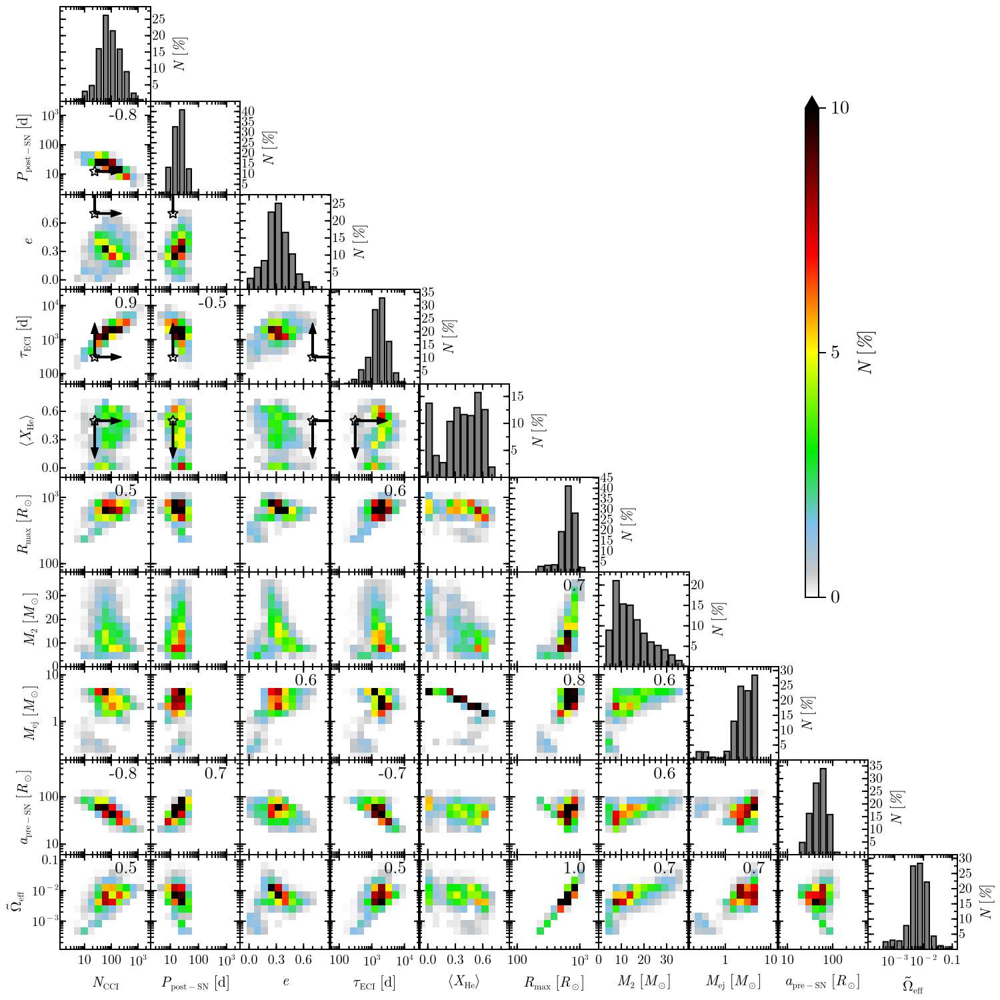

In [19]:
fff_basic = sn1 .&& ccsne .&& .! (prgs .== "M" .|| prgs .== "NI-S") .&&  (SNe .== :Ibc .|| SNe .== :Ibn)

mycmap = cgrad([:white, :gray78, :skyblue2, :green2, :yellow, :red,  :black], 
                [0,      0.05,  0.15,  0.3,     0.5,  0.7,       1])

fff = fff_basic  .&& (Rmax .> R2) .&& (post_SN_orbit .== :bound) .&& (n_passages .> 1) .&& ECI .&& (3 .< P_postSN .< 40)

@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

mlogticks = [k  for j in -90:1:90 for k in  (10. ^j):(10. ^j):(10. ^(j+1))]
mlinticks = 0:0.1:100
xticks10    = [10^t for t in -90.:1.:+90.]
logxticks10 = [t    for t in -90.:1.:+90.]
ticklabels  = [latexstring(@sprintf("10^{%d}", t)) for t in -90:90]
# ticklabels[findfirst(x->x==-2, logxticks10)]="0.01"
ticklabels[findfirst(x->x==-1, logxticks10)]="0.1"
ticklabels[findfirst(x->x== 0, logxticks10)]="1"
ticklabels[findfirst(x->x==+1, logxticks10)]="10"
ticklabels[findfirst(x->x==+2, logxticks10)]="100"
ticks    = (   xticks10, ticklabels)
logticks = (logxticks10, ticklabels)
linticks = 0:0.5:100
ticksize=11
FIGURE = Figure(size=(750,750), figure_padding = 5)
grid = GridLayout(FIGURE[0:10,0:10])
ax = Dict()
val_range = Dict("P"=>[2e0,3e3], 
                 "T"=>[50,3e4], 
                 "N"=>[1.2,3e3],
                 "e"=>[-.1,.899],
                 "Mej"=>[0.15,15],
                 "S"=>[1.3,2.25],
                 "Eexp"=>[3e50,1e52],
                 "M2"=>[0,39.999],
                 "Omega"=>[1.2e-4,0.15],
                 "h"=>[1e42,2e49],
                 "Rmax"=>[75,2_000],
                 "Lmax"=>[1e38,2e40],
                 "v_kick"=>[1,300],
                 "<He>"=>[-.1,.89],
                 "Mi"=>[8,150],
                 "Pi"=>[0.1,5e3],
                 "qi"=>[0,1],
                 "a_pre"=>[6,600])
val_scale = Dict("P"=>log10,"<He>"=>identity,"qi"=>identity, "Mi"=>log10, "Pi"=>log10,
                 "T"=>log10, "N"=>log10, "e"=>identity, "h"=>log10,"v_kick"=>log10,
                 "Mej"=>log10, "S"=>identity, "Eexp"=>log10, "M2"=>identity,
                 "Omega"=>log10, "Rmax"=>log10, "Lmax"=>log10, "a_pre"=>log10)
dbins     = Dict("P"=>.25, "T"=>.15, "N"=>.20, "h"=>0.5, "Omega"=>0.2,"a_pre"=>0.10,
                "Mej"=>0.1, "S"=>0.05, "e"=>0.05, "Eexp"=>0.1, "M2"=>2.5,
                "v_kick"=>0.1,"<He>"=>0.1, "Mi"=>0.1, "Pi"=>0.1, "qi"=>0.1, 
                "Rmax"=>0.05, "Lmax"=>0.15)
vals      = Dict("P" => P_postSN[fff], 
                 "T"=>tau_ECI[fff], 
                 "N"=>n_passages[fff], 
                 "Mej"=>Mej[fff],
                 "S"=>M_b_ns[fff],
                 "pdf"=>pdfs[fff]/sum(pdfs[fff]) *100,
                 "e"=>eccentricity[fff],
                 "Eexp"=>E_exp[fff],
                 "M2"=>M2[fff],
                 "h"=>Eheat[fff],
                 "Omega"=>Omegaeff[fff],
                 "Rmax" => Rmax[fff],
                 "v_kick"=>v_kick[fff],
                 "Lmax"=>Lmax[fff],
                 "<He>"=>avg_he[fff],
                 "Mi"=>M1[fff],
                 "Pi"=>Pi[fff],
                 "qi"=>qi[fff],
                 "a_pre"=>a_pre[fff])
ticks_xtra      = Dict("P" => nothing,
                 "T"=> nothing, 
                 "N"=>nothing, 
                 "Mej"=>nothing,
                 "S"=>nothing,
                 "Mi"=>nothing,
                 "Pi"=>nothing,
                 "<He>"=>(0.:0.3:1, 0.:0.1:1.0),
                 "qi"=>(0.:0.5:1, 0.:0.1:1.0),
                 "e"=>(0.:0.3:1, 0.:0.1:1.0),
                 "Eexp"=>nothing,
                 "M2"=>(0:10:100, 0:2.5:100),
                 "v_kick"=>nothing,
                 "h"=>nothing,
                 "Omega"=>nothing,
                 "Rmax" => nothing,
                 "Lmax"=>nothing,
                 "a_pre"=>nothing)
labels    = Dict("P"=>L"P_\mathrm{post-SN} \ [\mathrm{d}]",
                 "T"=>L"\tau_\mathrm{ECI} \ [\mathrm{d}]",
                 "N"=>L"N_\mathrm{CCI}",
                 "Mej"=>L"M_\mathrm{ej} \ [M_\odot]",
                 "S"=>L"M_\mathrm{NS} \ [M_\odot]",
                 "e"=>L"e",
                 "Eexp"=>L"E_\mathrm{kin,ej} \ [\mathrm{erg}]",
                 "M2"=>L"M_\mathrm{2} \ [M_\odot]",
                 "h"=>L"E_\mathrm{heat} \ [\mathrm{erg}]",
                 "Rmax"=>L"R_\mathrm{max} \ [R_\odot]",
                 "a_pre"=>L"a_\mathrm{pre-SN} \ [R_\odot]",
                 "<He>"=>L"⟨X_\mathrm{He}⟩",
                 "Mi"=>L"M_\mathrm{1,i} \ [M_\odot]",
                 "Pi"=>L"P_\mathrm{i} \ [\mathrm{d}]",
                 "qi"=>"q_i",
                 "v_kick"=>L"v_\mathrm{kick} \ [\mathrm{km}\,\mathrm{s}^{-1}]",
                 "Lmax"=>L"L_\mathrm{max} \ [\mathrm{erg}\,\mathrm{s}^{-1}]",
                 "Omega"=>L"\tilde{\Omega}_\mathrm{eff}")
digits    = Dict("P"=>0,
                 "T"=>0,
                 "N"=>0,
                 "Mej"=>1,
                 "S"=>2,
                 "e"=>2,
                 "Eexp"=>1,
                 "M2"=>1,
                 "h"=>1,
                 "Rmax"=>0,
                 "a_pre"=>0,
                 "Lmax"=>0,
                 "Omega"=>4, "v_kick"=>0)
SN2022jli     = Dict("P"=>[12.4, :value], "T"=>[310, :lowerlimit], 
                     "N"=>[floor(305/12.4), :lowerlimit], "h"=>[NaN, :unknown],
                     "Omega"=>[NaN,:unknown], "Mej"=>[NaN, :unknown],
                     "S"=>[NaN,:unknown], "e"=>[0.7, :lowerlimit], "v_kick"=>[NaN, :unknown],
                     "E"=>[NaN,:unknown], "M2"=>[NaN,:unknown], "<He>"=>[0.5, :upperlimit],
                     "Rmax"=>[NaN,:unknown], "a_pre"=>[NaN,:unknown])

colorrange=[0.,10]
bin_scale = :uniform # :custom
variables    = [ "N", "P", "e",  "T", "<He>", "Rmax", "M2", "Mej", "a_pre", "Omega"]
positions = Dict()
for k in range(1,length(variables)) 
        positions[variables[k]] = k  
end
cornerplots  = [[variables[i],variables[j]]
                        for i in 1:length(variables) 
                        for j in (i+1):length(variables)
                ]
for cornerplot in cornerplots
        x=cornerplot[1]
        y=cornerplot[2]
        ax[cornerplot] = plot_settings(grid[positions[y],positions[x]]; 
                ylabel=labels[y],
                xlabel=labels[x], 
                title =" ", 
                ymticks = val_scale[y] == log10 ? val_scale[y].(mlogticks) : ticks_xtra[y][2], 
                xmticks = val_scale[x] == log10 ? val_scale[x].(mlogticks) : ticks_xtra[x][2], 
                yticks  = val_scale[y] == log10 ? logticks  : ticks_xtra[y][1],
                xticks  = val_scale[x] == log10 ? logticks  : ticks_xtra[x][1],
                xlabelvisible = positions[y]==length(variables),
                xticklabelsvisible = positions[y]==length(variables),
                ylabelvisible = positions[x]==1,
                yticklabelsvisible = positions[x]==1,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1

                )
end
for h in variables
        ax[h] = plot_settings(grid[positions[h],positions[h]]; 
                ylabel=L"N \ [%]", 
                xlabel=labels[h], 
                title =" ",
                xscale=val_scale[h],
                xticks  = val_scale[h] == log10 ? ticks     : ticks_xtra[h][1],
                xmticks = val_scale[h] == log10 ? mlogticks : ticks_xtra[h][2], 
                yaxisposition=:right,
                xlabelvisible = positions[h]==length(variables),
                xticklabelsvisible = positions[h]==length(variables),
                yticks=5:5:100,
                ymticks=0:2.5:100,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1
                )
end

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_crit = Dict(occursin("Valli", KICKS) => "V25", occursin("MM", KICKS)=>"M16", occursin("DM25", KICKS)=>"DM25",occursin("COMBINE", KICKS)=>"K18", KICKS=="None"=>"None")[true]
simulation_settings = @sprintf("Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\nKicks: %s", f_B*100, exp_crit, mer_crit, kick_crit)

# # text!(FIGURE.scene, (.40, .85), text = simulation_settings, fontsize = 20, space = :relative)
# important_data = @sprintf(
# "Only %5.1f%% of Ibc+Ibn supernovae\nwith a MS companion are shown", 
#                 sum(pdfs[fff])/sum(pdfs[fff_basic])*100,
#                 )
# text!(FIGURE.scene, (.45, .9), text = important_data, fontsize = 14, space = :relative)
nbins = 13
hm = nothing           
for cornerplot in cornerplots
        xlab = cornerplot[1]
        ylab = cornerplot[2]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        ymin = val_range[ylab][1]
        ymax = val_range[ylab][2]
        scalex = val_scale[xlab]
        scaley = val_scale[ylab]
        dxb = (bin_scale == :custom) ? dbins[xlab] : (scalex(xmax)-scalex(xmin))/nbins
        dyb = (bin_scale == :custom) ? dbins[ylab] : (scaley(ymax)-scaley(ymin))/nbins

        
        xbins=scalex(xmin):dxb:scalex(xmax)
        ybins=scaley(ymin):dyb:scaley(ymax)

        x = scalex.(vals[xlab])
        y = scaley.(vals[ylab])
        
        hm = sn_heatmap(ax[cornerplot], x, y, vals["pdf"], xbins, ybins; colorrange=colorrange,
                cmap=mycmap, print_data=true, highclip=:black)
        PearsonCoeff = cor(reduce(hcat, [x,y]), Weights(vals["pdf"]))[1,2]
        abs(PearsonCoeff) > 0.5 && text!(ax[cornerplot], @sprintf("%5.1f", PearsonCoeff),
        position = (.85, .95),        # relative coords in axis space
        align = (:right, :top),   # anchor point
        space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        )
        
        scatter!(ax[cornerplot], scalex.(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1]), marker = :star5, color=RGBAf(1,1,1,0.5), strokecolor=:black, strokewidth=1 )
        if SN2022jli[xlab][2] == :lowerlimit 
                arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (1, 0),
                lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        elseif SN2022jli[xlab][2] == :upperlimit 
                arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (-1, 0),
                lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        end
        if SN2022jli[ylab][2] == :lowerlimit 
                arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (0, 1),
                lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        elseif SN2022jli[ylab][2] == :upperlimit 
                arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (0, -1),
                lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        end

        xlims!(ax[cornerplot], scalex(xmin), scalex(xmax))
        ylims!(ax[cornerplot], scaley(ymin), scaley(ymax))

end


for histogram in variables
        xlab = histogram
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        scalex = val_scale[xlab]
        dxb = (bin_scale == :custom) ? dbins[xlab] : (scalex(xmax)-scalex(xmin))/nbins
        xbins=scalex(xmin):dxb:scalex(xmax)
        x = (vals[xlab])
        xlims!(ax[histogram], xmin, xmax)
        bins, y_bins = run_histogram(ax[histogram], x, vals["pdf"], xbins, dxb * (scalex==log10 ? 1.2 : 1.), datascale=scalex, norm=1)
        ylims!(ax[histogram], 0, max( maximum(y_bins)*1.1, 12) )
        # stats = POPSYNTH.report_stats(x, vals["pdf"], label = xlab, print2screen=true, unit = (1, ""), multip_percentiles=[0,2.5,5,10,25,50,75,90,95,97.5,100], format_str="%5.1f")    
        
        # stats_string = @sprintf "%*.*f^{+%*.*f}_{-%*.*f}" 5 digits[xlab] stats[1][1]  5 digits[xlab] stats[1][2]  5 digits[xlab] stats[1][3]
        # text!(ax[histogram], latexstring(stats_string),
        #         position = (.85, .95),        # relative coords in axis space
        #         align = (:right, :top),   # anchor point
        #         space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        # )

end
Colorbar(FIGURE[1:6,9], hm, label=L"N \ [%]",size = 10)
colgap!(grid, -27)
rowgap!(grid,0)

save_directory = "../output/ECI/cornerplots/"
outfilename = @sprintf("cps_CCI_obs_%s_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT, KICKS)
save(save_directory*outfilename, FIGURE)

FIGURE

In [11]:
fff_IbcIbn =  (SNe .== :Ibc .|| SNe .== :Ibn)
fff_basic = sn1 .&& ccsne .&& .! (prgs .== "M" .|| prgs .== "NI-S") .&&  (SNe .== :Ibc .|| SNe .== :Ibn)
fff_CCI = fff_basic  .&& (Rmax .> R2) .&& (post_SN_orbit .== :bound) .&& (n_passages .> 1) .&& ECI
n_IbcIbn = sum(pdfs[fff_IbcIbn])
@show n_IbcIbn
n_ECI = sum(pdfs[fff_CCI])
@show n_ECI/n_IbcIbn * 100
n_ECI_obs = sum(pdfs[fff_CCI .&& (3 .< P_postSN .< 40)])
@show n_ECI_obs/n_IbcIbn * 100
n_ECI_obs = sum(pdfs[fff_CCI .&& (3 .< P_postSN .< 40) .&& eccentricity .> 0.4])
@show n_ECI_obs/n_IbcIbn * 100

n_IbcIbn = 36.183032442293026
(n_ECI / n_IbcIbn) * 100 = 15.6586093486802
(n_ECI_obs / n_IbcIbn) * 100 = 7.74797066303565
(n_ECI_obs / n_IbcIbn) * 100 = 1.9374772786994243


1.9374772786994243

The data in this plot affects 5.658 % of all CCSNe
["N", "P"]
Weights: min=2.417e-05, max=2.148e+00, min/max=1.125e-05
["N", "e"]
Weights: min=1.823e-04, max=1.014e+00, min/max=1.797e-04
["N", "T"]
Weights: min=7.173e-05, max=2.297e+00, min/max=3.122e-05
["P", "e"]
Weights: min=2.417e-05, max=1.514e+00, min/max=1.596e-05
["P", "T"]
Weights: min=2.417e-05, max=2.131e+00, min/max=1.134e-05
["e", "T"]
Weights: min=2.417e-05, max=1.525e+00, min/max=1.585e-05


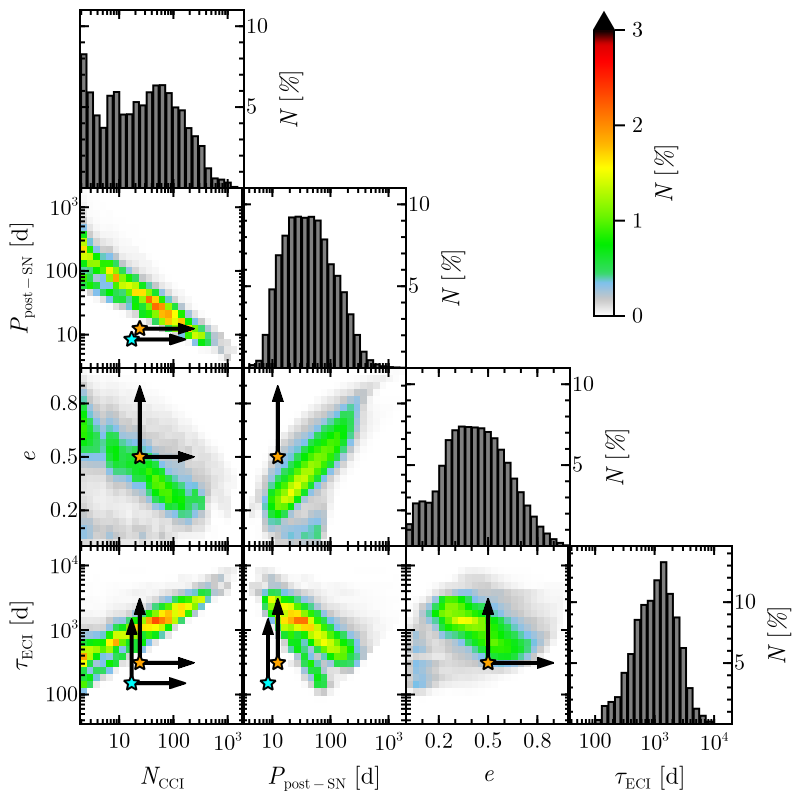

In [28]:
fff_basic = sn1 .&& ccsne .&& .! (prgs .== "M" .|| prgs .== "NI-S") .&&  (SNe .== :Ibc .|| SNe .== :Ibn)

fff = fff_basic  .&& (Rmax .> R2) .&& (post_SN_orbit .== :bound) .&& (n_passages .> 1) .&& ECI

@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

mlogticks = [k  for j in -90:1:90 for k in  (10. ^j):(10. ^j):(10. ^(j+1))]
mlinticks = 0:0.1:100
xticks10    = [10^t for t in -90.:1.:+90.]
logxticks10 = [t    for t in -90.:1.:+90.]
ticklabels  = [latexstring(@sprintf("10^{%d}", t)) for t in -90:90]
# ticklabels[findfirst(x->x==-2, logxticks10)]="0.01"
ticklabels[findfirst(x->x==-1, logxticks10)]="0.1"
ticklabels[findfirst(x->x== 0, logxticks10)]="1"
ticklabels[findfirst(x->x==+1, logxticks10)]="10"
ticklabels[findfirst(x->x==+2, logxticks10)]="100"
ticks    = (   xticks10, ticklabels)
logticks = (logxticks10, ticklabels)
linticks = 0:0.5:100

bin_scale = 25 
ticksize=12
FIGURE = Figure(size=(400,400), figure_padding = 5)
grid = GridLayout(FIGURE[0:10,0:10])
ax = Dict()
val_range = Dict("P"=>[3,2e3], 
                 "T"=>[35,2e4], 
                 "N"=>[1.9,2e3],
                 "e"=>[0,0.999],
                 "Mej"=>[0.1,15],
                 "S"=>[1.3,2.25],
                 "Eexp"=>[3e50,1e52],
                 "M2"=>[0,44],
                 "Omega"=>[1.2e-4,0.15],
                 "h"=>[1e42,2e49],
                 "Rmax"=>[75,2_000],
                 "Lmax"=>[1e38,2e40],
                 "a_pre"=>[6,600],
                 "Y"=>[.05,1.1])
val_scale = Dict("P"=>log10,
                 "T"=>log10, "N"=>log10, "e"=>identity, "h"=>log10, "Y"=>identity,
                 "Mej"=>log10, "S"=>identity, "Eexp"=>log10, "M2"=>identity,
                 "Omega"=>log10, "Rmax"=>log10, "Lmax"=>log10, "a_pre"=>log10)
vals      = Dict("P" => P_postSN[fff], 
                 "T"=>tau_ECI[fff], 
                 "N"=>n_passages[fff], 
                 "Mej"=>Mej[fff],
                 "Y"=>Y1[fff],
                 "S"=>M_b_ns[fff],
                 "pdf"=>pdfs[fff]/sum(pdfs[fff]) *100,
                 "e"=>eccentricity[fff],
                 "Eexp"=>E_exp[fff],
                 "M2"=>M2[fff],
                 "h"=>Eheat[fff],
                 "Omega"=>Omegaeff[fff],
                 "Rmax" => Rmax[fff],
                 "Lmax"=>Lmax[fff],
                 "a_pre"=>a_pre[fff])
ticks_xtra      = Dict("P" => nothing,
                 "T"=> nothing, 
                 "N"=>nothing, 
                 "Mej"=>nothing,
                 "S"=>nothing,
                 "Y"=>(0.2:0.3:1, 0.:0.1:1),
                 "e"=>(0.2:0.3:1.0, 0.:0.1:1.0),
                 "Eexp"=>nothing,
                 "M2"=>(0:10:100, 0:2.5:100),
                 "h"=>nothing,
                 "Omega"=>nothing,
                 "Rmax" => nothing,
                 "Lmax"=>nothing,
                 "a_pre"=>nothing)
labels    = Dict("P"=>L"P_\mathrm{post-SN} \ [\mathrm{d}]",
                 "T"=>L"\tau_\mathrm{ECI} \ [\mathrm{d}]",
                 "N"=>L"N_\mathrm{CCI}",
                 "Y"=>L"Y_\mathrm{pre-SN}",
                 "Mej"=>L"M_\mathrm{ej} \ [M_\odot]",
                 "S"=>L"M_\mathrm{NS} \ [M_\odot]",
                 "e"=>L"e",
                 "Eexp"=>L"E_\mathrm{kin,ej} \ [\mathrm{erg}]",
                 "M2"=>L"M_\mathrm{2} \ [M_\odot]",
                 "h"=>L"E_\mathrm{heat} \ [\mathrm{erg}]",
                 "Rmax"=>L"R_\mathrm{max} \ [R_\odot]",
                 "a_pre"=>L"a_\mathrm{pre-SN} \ [R_\odot]",
                 "Lmax"=>L"L_\mathrm{max} \ [\mathrm{erg}\,\mathrm{s}^{-1}]",
                 "Omega"=>L"\tilde{\Omega}_\mathrm{eff} \ [\mathrm{strad}/4\pi]")
digits    = Dict("P"=>0,
                 "T"=>0,
                 "N"=>0,
                 "Y"=>0,
                 "Mej"=>1,
                 "S"=>2,
                 "e"=>2,
                 "Eexp"=>1,
                 "M2"=>1,
                 "h"=>1,
                 "Rmax"=>0,
                 "a_pre"=>0,
                 "Lmax"=>0,
                 "Omega"=>4)
dbins     = Dict("P"=>nothing, "T"=>nothing, "N"=>nothing, "h"=>nothing, 
                "Omega"=>nothing,"a_pre"=>nothing, "Eexp"=>nothing,
                "Mej"=>nothing, "S"=>nothing, "e"=>nothing,  "M2"=>nothing,
                "v_kick"=>nothing,"Y"=>0.066666, "Mi"=>nothing, "Pi"=>nothing, "qi"=>nothing, 
                "Rmax"=>nothing, "Lmax"=>nothing)
SN2022jli     = Dict("P"=>[12.4, :value], "T"=>[310, :lowerlimit], 
                        "Y"=>[0.5, :upperlimit],
                     "N"=>[floor(305/12.4), :lowerlimit], "h"=>[NaN, :unknown],
                     "Omega"=>[NaN,:unknown], "Mej"=>[NaN, :unknown],
                     "S"=>[NaN,:unknown], "e"=>[0.5, :lowerlimit],
                     "E"=>[NaN,:unknown], "M2"=>[NaN,:unknown],
                     "Rmax"=>[NaN,:unknown], "a_pre"=>[NaN,:unknown],
                     "color"=>:orange)
SN2015ap     = Dict("P"=>[8.41, 0.08], "T"=>[150, :lowerlimit], 
                        "Y"=>[0., :upperlimit],
                     "N"=>[floor(150/8.41), :lowerlimit], "h"=>[NaN, :unknown],
                     "Omega"=>[NaN,:unknown], "Mej"=>[2.2, 0.6],
                     "S"=>[NaN,:unknown], "e"=>[NaN, :lowerlimit],
                     "E"=>[NaN,:unknown], "M2"=>[NaN,:unknown],
                     "Rmax"=>[NaN,:unknown], "a_pre"=>[NaN,:unknown],
                     "color"=>:cyan)
mycmap = cgrad([:white, :gray78, :skyblue2, :green2, :yellow, :red,  :black], 
                [0,      0.05,  0.15,  0.35,   0.6, 0.95, 0.1])
colorrange=[0.,3]
#ptjsn
variables    = [ "N", "P", "e",  "T"]
positions = Dict()
for k in range(1,length(variables)) 
        positions[variables[k]] = k  
end
cornerplots  = [[variables[i],variables[j]]
                        for i in 1:length(variables) 
                        for j in (i+1):length(variables)
                ]


                
for cornerplot in cornerplots
        x=cornerplot[1]
        y=cornerplot[2]
        ax[cornerplot] = plot_settings(grid[positions[y],positions[x]]; 
                ylabel=labels[y],
                xlabel=labels[x], 
                title =" ", 
                ymticks = val_scale[y] == log10 ? val_scale[y].(mlogticks) : ticks_xtra[y][2], 
                xmticks = val_scale[x] == log10 ? val_scale[x].(mlogticks) : ticks_xtra[x][2], 
                yticks  = val_scale[y] == log10 ? logticks  : ticks_xtra[y][1],
                xticks  = val_scale[x] == log10 ? logticks  : ticks_xtra[x][1],
                xlabelvisible = positions[y]==length(variables),
                xticklabelsvisible = positions[y]==length(variables),
                ylabelvisible = positions[x]==1,
                yticklabelsvisible = positions[x]==1,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1

                )
end
for h in variables
        ax[h] = plot_settings(grid[positions[h],positions[h]]; 
                ylabel=L"N \ [%]", 
                xlabel=labels[h], 
                title =" ",
                xscale=val_scale[h],
                xticks  = val_scale[h] == log10 ? ticks     : ticks_xtra[h][1],
                xmticks = val_scale[h] == log10 ? mlogticks : ticks_xtra[h][2], 
                yaxisposition=:right,
                xlabelvisible = positions[h]==length(variables),
                xticklabelsvisible = positions[h]==length(variables),
                yticks=5:5:100,
                ymticks=0:1:100,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1
                )
end

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_crit = Dict(occursin("Valli", KICKS) => "V25", occursin("MM", KICKS)=>"M16", occursin("DM25", KICKS)=>"DM25",occursin("COMBINE", KICKS)=>"K18", KICKS=="None"=>"None")[true]
simulation_settings = @sprintf("Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\nKicks: %s", f_B*100, exp_crit, mer_crit, kick_crit)

# # text!(FIGURE.scene, (.40, .85), text = simulation_settings, fontsize = 20, space = :relative)
# important_data = @sprintf(
# "Only %5.1f%% of Ibc+Ibn supernovae\nwith a MS companion are shown", 
#                 sum(pdfs[fff])/sum(pdfs[fff_basic])*100,
#                 )
# text!(FIGURE.scene, (.45, .9), text = important_data, fontsize = 14, space = :relative)

hm = nothing           
for cornerplot in cornerplots
        print(cornerplot, "\n")
        xlab = cornerplot[1]
        ylab = cornerplot[2]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        ymin = val_range[ylab][1]
        ymax = val_range[ylab][2]
        scalex = val_scale[xlab]
        scaley = val_scale[ylab]
        dxb = !isnothing(dbins[xlab]) ? dbins[xlab] : (scalex(xmax)-scalex(xmin))/bin_scale
        dyb = !isnothing(dbins[ylab]) ? dbins[ylab] : (scaley(ymax)-scaley(ymin))/bin_scale

        xbins=scalex(xmin):dxb:scalex(xmax)
        ybins=scaley(ymin):dyb:scaley(ymax)

        x = scalex.(vals[xlab])
        y = scaley.(vals[ylab])
        
        hm = sn_heatmap(ax[cornerplot], x, y, vals["pdf"], xbins, ybins; colorrange=colorrange,
                cmap=mycmap, print_data=true, highclip=:black)
        # PearsonCoeff = cor(reduce(hcat, [x,y]), Weights(vals["pdf"]))[1,2]
        # text!(ax[cornerplot], @sprintf("%5.1f", PearsonCoeff),
        # position = (.85, .95),        # relative coords in axis space
        # align = (:right, :top),   # anchor point
        # space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        # )
        for sn in [SN2022jli, SN2015ap]
                if sn[xlab][2] == :lowerlimit 
                        arrows2d!(ax[cornerplot], (scalex(sn[xlab][1]), scaley(sn[ylab][1])), (1, 0),
                        lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
                end
                if sn[ylab][2] == :lowerlimit 
                        arrows2d!(ax[cornerplot], (scalex(sn[xlab][1]), scaley(sn[ylab][1])), (0, 1),
                        lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
                end
                if sn[xlab][2] == :upperlimit 
                        arrows2d!(ax[cornerplot], (scalex(sn[xlab][1]), scaley(sn[ylab][1])), (-1, 0),
                        lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
                end
                if sn[ylab][2] == :upperlimit 
                        arrows2d!(ax[cornerplot], (scalex(sn[xlab][1]), scaley(sn[ylab][1])), (0, -1),
                        lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
                end
                scatter!(ax[cornerplot], scalex.(sn[xlab][1]), scaley(sn[ylab][1]), marker = :star5, color=sn["color"], strokecolor=:black, strokewidth=1 )

        end
        xlims!(ax[cornerplot], scalex(xmin), scalex(xmax))
        ylims!(ax[cornerplot], scaley(ymin), scaley(ymax))

end


for histogram in variables
        xlab = histogram
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        scalex = val_scale[xlab]
        dxb = !isnothing(dbins[xlab]) ? dbins[xlab] : (scalex(xmax)-scalex(xmin))/bin_scale
        xbins=scalex(xmin):dxb:scalex(xmax)
        x = (vals[xlab])
        xlims!(ax[histogram], xmin, xmax)
        bins, y_bins = run_histogram(ax[histogram], x, vals["pdf"], xbins, dxb * (scalex==log10 ? 1.2 : 1.), datascale=scalex, norm=1)
        ylims!(ax[histogram], 0, max(maximum(y_bins)*1.1,11))
        # stats = POPSYNTH.report_stats(x, vals["pdf"], label = xlab, print2screen=true, unit = (1, ""), multip_percentiles=[0,2.5,5,10,25,50,75,90,95,97.5,100], format_str="%5.1f")    
        
        # stats_string = @sprintf "%*.*f^{+%*.*f}_{-%*.*f}" 5 digits[xlab] stats[1][1]  5 digits[xlab] stats[1][2]  5 digits[xlab] stats[1][3]
        # text!(ax[histogram], latexstring(stats_string),
        #         position = (.85, .95),        # relative coords in axis space
        #         align = (:right, :top),   # anchor point
        #         space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        # )

end
Colorbar(FIGURE[0:4,9], hm, label=L"N \ [%]",size = 10, 
                labelsize=ticksize, ticklabelsize=ticksize-1)
colgap!(grid, -29)
rowgap!(grid,0)

save_directory = "../output/ECI/cornerplots/"
outfilename = @sprintf("cps_CCI_2022jli_%s_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT, KICKS)
save(save_directory*outfilename, FIGURE)

FIGURE

### 2022jli

In [5]:
fff_bin1st = sn1        .&& ccsne .&& .! (prgs .== "M" .|| prgs .== "NI-S")
fff_sesne  = fff_bin1st .&& (SNe .== :Ibc .|| SNe .== :Ibn)
fff_bound  = fff_sesne  .&& (post_SN_orbit .== :bound)
fff_ECI    = fff_bound  .&& ECI
fff        = fff_ECI    .&& (Rmax .> R2) .&&  (n_passages .> 1) 
fff_sn2022jli = (abs.(P_postSN .- 12.4) .< 0.1) .&&
                 eccentricity .>= 0.5 .&& 
                #  n_passages .>= 24 .&& 
                #  tau_ECI .>= 310 .&& 
                 Y1 .< 0.5 .&&
                 fff 
@show sum(pdfs[fff])/sum(pdfs[fff_sesne])*100
n_ok = sum(pdfs[fff_sn2022jli])/sum(pdfs[fff]) *100
@show length(pdfs[fff_sn2022jli])
@show n_ok 
@show length(Set(mods[fff_sn2022jli]))
#2500 was 0.2686

(sum(pdfs[fff]) / sum(pdfs[fff_sesne])) * 100 = 8.281728483923962
length(pdfs[fff_sn2022jli]) = 83
n_ok = 0.025770037446800387
length(Set(mods[fff_sn2022jli])) = 78


78

In [6]:
variables = Dict("P" => P_postSN, 
                 "T"=>tau_ECI, 
                 "N"=>n_passages, 
                 "Mej"=>Mej,
                 "Mns"=>M_b_ns,
                 "e"=>eccentricity,
                 "Eexp"=>E_exp./1e51,
                 "M2"=>M2,
                 "Teff"=>Teff_min,
                 "M2i"=>M1 .* qi,
                 "Eheat"=>Eheat./1e49,
                 "Omega"=>Omegaeff./1e-4,
                 "Rmax" => Rmax,
                 "Lmax"=>Lmax./1e39,
                 "a_pre"=>a_pre,
                 "Mend"=>Mend,
                 "M1i"=>M1,
                 "v_kick"=>v_kick,
                 "<He>"=>avg_he,
                 "Y1"=>Y1,
                 "Pi" => Pi, 
                 "q" => qi, 
                 "tot_he"=>tot_he,
                 )

for k in keys(variables)
    @printf("%10s", k)
    x = Float64.(variables[k])[fff_sn2022jli]
    px = Weights(pdfs[fff_sn2022jli])
    m_x = mean(x, px)
    q_05, q_95 =  quantile(x, px, 0.05), quantile(x, px, 0.95)
    q_0, q_1 =  quantile(x, px, 0.0), quantile(x, px, 1.0)
    # @printf("%10.2f +%10.2f -%10.2f  [+%10.2f -%10.2f]\n", m_x,  (+q_95-m_x), -(m_x-q_05), (+q_1-m_x), -(m_x-q_0))
    @printf("%10.2f  %10.2f %10.2f | %10.2f %10.2f\n", m_x,  (+q_0), (q_05), (q_95), (q_1))
end

#run1 
    #      T   5064.39     3248.05    3248.05 |    7125.86    7327.63
    #      P     12.40       12.30      12.31 |      12.50      12.50
    #      e      0.54        0.50       0.51 |       0.57       0.60
    #     M2      7.80        6.21       6.21 |       8.99       9.52
    #  Omega     82.28       65.66      69.80 |      93.88     105.60
    #   Mend      5.08        4.06       4.08 |       5.54       5.54
    #   Eexp      1.34        1.15       1.15 |       1.60       1.70
    #      N    408.29      259.00     262.82 |     578.00     591.00
    #  a_pre     21.89       18.93      20.05 |      24.25      24.25
    #    Mej      3.51        2.43       2.45 |       3.94       3.94
    #      q      0.32        0.25       0.25 |       0.40       0.45
    #    Mns      1.57        1.44       1.44 |       1.66       1.68
    #  Eheat      0.11        0.08       0.09 |       0.15       0.15
    #   <He>      0.21        0.00       0.00 |       0.45       0.45
    # v_kick    101.33       74.97      80.06 |     120.27     134.60
    #     Pi     15.90        7.08       8.91 |      28.18      28.18
    #   Lmax      0.37        0.29       0.29 |       0.44       0.47
    #    M1i     23.37       17.78      17.78 |      31.62      35.48
    #   Rmax    709.88      658.63     664.75 |     770.97     775.28


         T    919.48      225.00     361.76 |    1946.51    4402.90
         P     12.39       12.30      12.31 |      12.49      12.50
         e      0.67        0.50       0.53 |       0.84       0.89
        M2     17.96        5.53       6.54 |      31.44      33.62
     Omega     46.63        6.11       9.76 |     163.79     306.63
      Mend      5.98        5.30       5.34 |       6.86       7.12
      Eexp      1.65        1.17       1.17 |       2.70       3.01
         N     74.21       18.00      29.00 |     155.75     357.00
     a_pre     80.90       23.37      41.64 |     110.94     123.49
       Mej      4.35        3.73       3.77 |       5.15       5.29
         q      0.51        0.15       0.20 |       0.75       0.85
       Mns      1.63        1.48       1.48 |       1.77       1.88
    tot_he      0.20        0.17       0.17 |       0.27       0.28
     Eheat      0.07        0.01       0.02 |       0.28       0.46
      <He>      0.01        0.00       0.00 |   

In [7]:
@show  Set(mods[fff_sn2022jli])
for ix in sort(collect(Set(mods[fff_sn2022jli])))
    # POPSYNTH.print_history(f_MW, ix, ["M_1", "M_he_core_1", "M_co_core_1", "Ys_1", "M_tot_he_1", "a", "period", "M_2"], "2")
    print(ix, " ")
    fff_mod = (mods .== ix .&& fff_sn2022jli)
    px = Weights(pdfs[fff_mod])
    @printf("occurrances = %d -> pdf = %5.1f \n", length(pdfs[fff_mod]), 100*sum(pdfs[fff_mod])/sum(pdfs[fff_sn2022jli]))
    100*sum(pdfs[fff_mod])/sum(pdfs[fff_sn2022jli]) < 9 && continue 
    ixs = findall(fff_mod)
    
    for k in keys(variables)
    
        @printf("%10s", k)
        # print(variables[k][fff_mod])
        x = Float64.(variables[k])[fff_mod]
        m_x = mean(x, px)
        q_05, q_95 =  quantile(x, px, 0.05), quantile(x, px, 0.95)
        q_0, q_1 =  quantile(x, px, 0.0), quantile(x, px, 1.0)
        # @printf("%10.2f +%10.2f -%10.2f  [+%10.2f -%10.2f]\n", m_x,  (+q_95-m_x), -(m_x-q_05), (+q_1-m_x), -(m_x-q_0))
        if q_0 != q_1
            @printf("%10.2f < [%10.2f < %10.2f < %10.2f] < %10.2f\n", (+q_0), q_05, m_x, q_95, (q_1))
        else
            @printf("%10.2f\n", m_x)
        end
    end
    # @printf("\n\n")
end

#Set(mods[fff_sn2022jli])
#run1  = [15578, 15613, 15631, 15702, 16999, 17052, 17070, 17177, 18367, 18402, 18420, 18438,        19788, 19859,        21227, 21316, 21334, 22666, 24034] = 18
#run2  = [       15631,        15702, 16999, 17052, 17070, 17177, 18367,        18420, 18438, 18527, 19788, 19859,        21227, 21316, 21334, 22666, 24034] = 16
#      x [           3,           11,     2,     5,    18,    13,                  18,    25,     1,     3,    17,           22,    19,    13,     7,     1] = 178
#run3  = [15578, 15631,        15702, 16999, 17052, 17070, 17177, 18367, 18402, 18420, 18438,        19788, 19859, 20002, 21227, 21316, 21334, 22666, 24034] = 16
#      x [     1,    1,            4,     6,     6,    20,    11,     1,     1,    13,    17,            3,    18,     1,    29,    26,    14,    15,     1] = 188
#run4  = [       15631,        15702, 16999, 17052, 17070, 17177,        18402, 18420, 18438,        19788, 19859, 20002, 21227, 21316, 21334, 22666, 24034] = 16


Set(mods[fff_sn2022jli]) = Set([22459, 22477, 24003, 23914, 21299, 25246, 26562, 28056, 22632, 21319, 22635, 25320, 24374, 22444, 23773, 22722, 21248, 23843, 26771, 22669, 22685, 22599, 23848, 23967, 28038, 21266, 21603, 21164, 21232, 22547, 22511, 23968, 24196, 24178, 26651, 26719, 26668, 24303, 28072, 22529, 23918, 26667, 21354, 23931, 28122, 21353, 22615, 22775, 26689, 26672, 21249, 22441, 21460, 22863, 24036, 23936, 26633, 21214, 23025, 21215, 25300, 22601, 23895, 22617, 22580, 25304, 23842, 21147, 22564, 21231, 23953, 26704, 29440, 25213, 21145, 21711, 22476, 23735])
21145 occurrances = 1 -> pdf =   1.5 
21147 occurrances = 1 -> pdf =   1.5 
21164 occurrances = 1 -> pdf =   1.5 
21214 occurrances = 2 -> pdf =   3.1 
21215 occurrances = 1 -> pdf =   1.5 
21231 occurrances = 1 -> pdf =   1.5 
21232 occurrances = 1 -> pdf =   1.5 
21248 occurrances = 2 -> pdf =   3.1 
21249 occurrances = 1 -> pdf =   1.5 
21266 occurrances = 1 -> pdf =   1.5 
21299 occurrances = 1 -> pdf =   1.5 
213

In [11]:
kkk = collect(Set(mods[fff_sn2022jli]))
for k in kkk
    f_MW.deltaM_A[k] > 0 && continue 
    f_MW.deltaM_B[k] > 0 && continue 
    f_MW.deltaM_C[k] > 0 && continue
    print(k) 
    # @show f_MW.logM[k], f_MW.logP[k], f_MW.q[k]
end

The data in this plot affects 0.596 % of all CCSNe
Weights: min=2.436e+00, max=2.846e+00, min/max=8.561e-01
Weights: min=2.436e+00, max=5.692e+00, min/max=4.280e-01
Weights: min=2.436e+00, max=5.692e+00, min/max=4.280e-01
Weights: min=2.436e+00, max=2.846e+00, min/max=8.561e-01
Weights: min=2.436e+00, max=5.692e+00, min/max=4.280e-01
Weights: min=2.436e+00, max=2.846e+00, min/max=8.561e-01
Weights: min=2.436e+00, max=5.692e+00, min/max=4.280e-01
Weights: min=2.436e+00, max=2.846e+00, min/max=8.561e-01
Weights: min=2.436e+00, max=5.692e+00, min/max=4.280e-01
Weights: min=2.846e+00, max=2.846e+00, min/max=1.000e+00
Weights: min=2.436e+00, max=2.846e+00, min/max=8.561e-01
Weights: min=1.120e+00, max=8.128e+00, min/max=1.378e-01
Weights: min=5.179e+00, max=2.140e+01, min/max=2.420e-01
Weights: min=1.785e+00, max=4.931e+00, min/max=3.620e-01
Weights: min=1.308e+00, max=1.139e+01, min/max=1.149e-01
Weights: min=1.785e+00, max=5.692e+00, min/max=3.137e-01
Weights: min=5.179e+00, max=2.140e+01

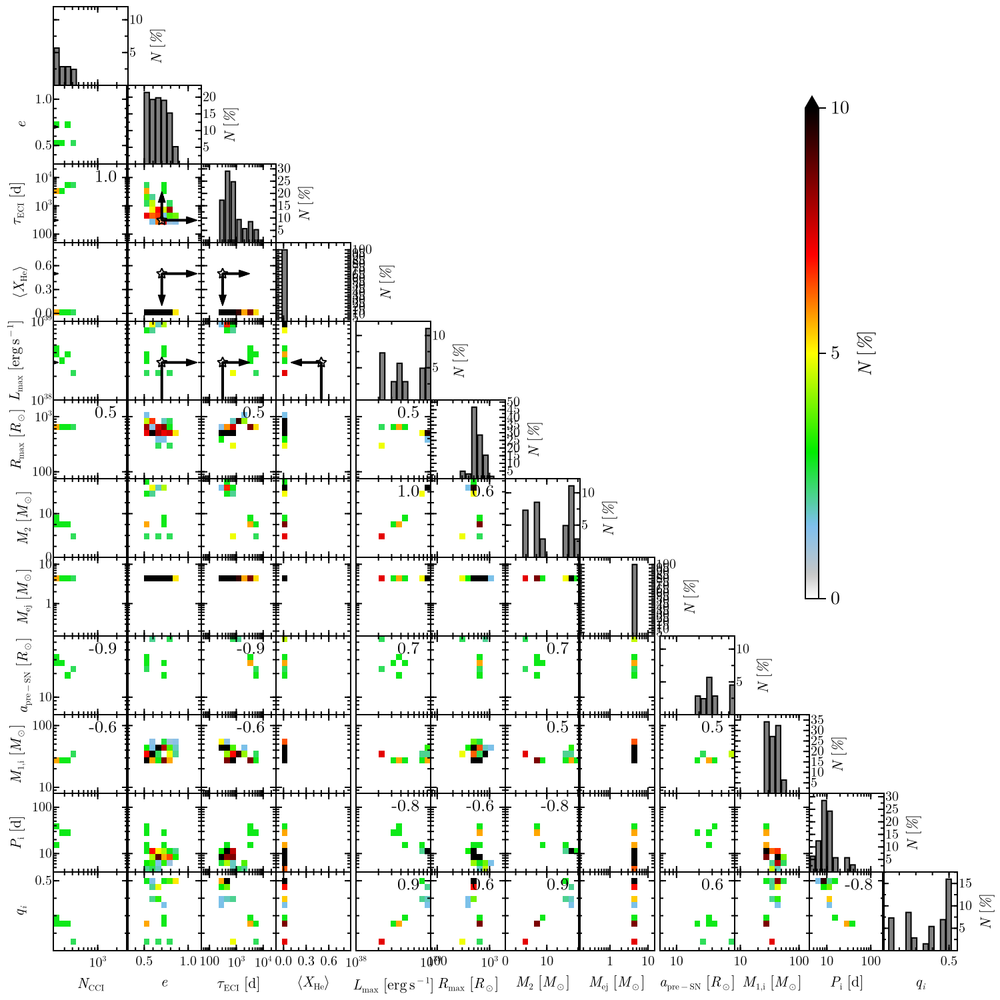

In [8]:

mycmap = cgrad([:white, :gray78, :skyblue2, :green2, :yellow, :red,  :black], 
                [0,      0.05,  0.15,  0.3,     0.5,  0.7,       1])

the_filter = fff_sn2022jli

@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

mlogticks = [k  for j in -90:1:90 for k in  (10. ^j):(10. ^j):(10. ^(j+1))]
mlinticks = 0:0.1:100
xticks10    = [10^t for t in -90.:1.:+90.]
logxticks10 = [t    for t in -90.:1.:+90.]
ticklabels  = [latexstring(@sprintf("10^{%d}", t)) for t in -90:90]
# ticklabels[findfirst(x->x==-2, logxticks10)]="0.01"
ticklabels[findfirst(x->x==-1, logxticks10)]="0.1"
ticklabels[findfirst(x->x== 0, logxticks10)]="1"
ticklabels[findfirst(x->x==+1, logxticks10)]="10"
ticklabels[findfirst(x->x==+2, logxticks10)]="100"
ticks    = (   xticks10, ticklabels)
logticks = (logxticks10, ticklabels)
linticks = 0:0.5:100
ticksize=11
FIGURE = Figure(size=(750,750), figure_padding = 5)
grid = GridLayout(FIGURE[0:10,0:10])
ax = Dict()
val_range = Dict("P"=>[2e0,3e3], 
                 "T"=>[50,3e4], 
                 "N"=>[200,3e3],
                 "e"=>[.3,1.15],
                 "Mej"=>[0.15,15],
                 "S"=>[1.3,2.25],
                 "Eexp"=>[3e50,1e52],
                 "M2"=>[0,18],
                 "Omega"=>[1.2e-4,0.15],
                 "h"=>[1e42,2e49],
                 "Rmax"=>[75,2_000],
                 "Lmax"=>[1e38,1e39],
                 "v_kick"=>[1,300],
                 "<He>"=>[-.1,.89],
                 "Mi"=>[8,150],
                 "Pi"=>[4,200],
                 "qi"=>[0.1,0.55],
                 "a_pre"=>[6,60])
val_scale = Dict("P"=>log10,"<He>"=>identity,"qi"=>identity, "Mi"=>log10, "Pi"=>log10,
                 "T"=>log10, "N"=>log10, "e"=>identity, "h"=>log10,"v_kick"=>log10,
                 "Mej"=>log10, "S"=>identity, "Eexp"=>log10, "M2"=>identity,
                 "Omega"=>log10, "Rmax"=>log10, "Lmax"=>log10, "a_pre"=>log10)
dbins     = Dict("P"=>.25, "T"=>.15, "N"=>.20, "h"=>0.5, "Omega"=>0.2,"a_pre"=>0.10,
                "Mej"=>0.1, "S"=>0.05, "e"=>0.05, "Eexp"=>0.1, "M2"=>2.5,
                "v_kick"=>0.1,"<He>"=>0.1, "Mi"=>0.1, "Pi"=>0.1, "qi"=>0.1, 
                "Rmax"=>0.05, "Lmax"=>0.15)
vals      = Dict("P" => P_postSN[the_filter], 
                 "T"=>tau_ECI[the_filter], 
                 "N"=>n_passages[the_filter], 
                 "Mej"=>Mej[the_filter],
                 "S"=>M_b_ns[the_filter],
                 "pdf"=>pdfs[the_filter]/sum(pdfs[the_filter]) *100,
                 "e"=>eccentricity[the_filter],
                 "Eexp"=>E_exp[the_filter],
                 "M2"=>M2[the_filter],
                 "h"=>Eheat[the_filter],
                 "Omega"=>Omegaeff[the_filter],
                 "Rmax" => Rmax[the_filter],
                 "v_kick"=>v_kick[the_filter],
                 "Lmax"=>Lmax[the_filter],
                 "<He>"=>avg_he[the_filter],
                 "Mi"=>M1[the_filter],
                 "Pi"=>Pi[the_filter],
                 "qi"=>qi[the_filter],
                 "a_pre"=>a_pre[the_filter])
ticks_xtra      = Dict("P" => nothing,
                 "T"=> nothing, 
                 "N"=>nothing, 
                 "Mej"=>nothing,
                 "S"=>nothing,
                 "Mi"=>nothing,
                 "Pi"=>nothing,
                 "<He>"=>(0.:0.3:1, 0.:0.1:1.0),
                 "qi"=>(0.:0.5:1, 0.:0.1:1.0),
                 "e"=>(0.:0.5:1, 0.:0.1:1.0),
                 "Eexp"=>nothing,
                 "M2"=>(0:10:100, 0:2.5:100),
                 "v_kick"=>nothing,
                 "h"=>nothing,
                 "Omega"=>nothing,
                 "Rmax" => nothing,
                 "Lmax"=>nothing,
                 "a_pre"=>nothing)
labels    = Dict("P"=>L"P_\mathrm{post-SN} \ [\mathrm{d}]",
                 "T"=>L"\tau_\mathrm{ECI} \ [\mathrm{d}]",
                 "N"=>L"N_\mathrm{CCI}",
                 "Mej"=>L"M_\mathrm{ej} \ [M_\odot]",
                 "S"=>L"M_\mathrm{NS} \ [M_\odot]",
                 "e"=>L"e",
                 "Eexp"=>L"E_\mathrm{kin,ej} \ [\mathrm{erg}]",
                 "M2"=>L"M_\mathrm{2} \ [M_\odot]",
                 "h"=>L"E_\mathrm{heat} \ [\mathrm{erg}]",
                 "Rmax"=>L"R_\mathrm{max} \ [R_\odot]",
                 "a_pre"=>L"a_\mathrm{pre-SN} \ [R_\odot]",
                 "<He>"=>L"⟨X_\mathrm{He}⟩",
                 "Mi"=>L"M_\mathrm{1,i} \ [M_\odot]",
                 "Pi"=>L"P_\mathrm{i} \ [\mathrm{d}]",
                 "qi"=>L"q_i",
                 "v_kick"=>L"v_\mathrm{kick} \ [\mathrm{km}\,\mathrm{s}^{-1}]",
                 "Lmax"=>L"L_\mathrm{max} \ [\mathrm{erg}\,\mathrm{s}^{-1}]",
                 "Omega"=>L"\tilde{\Omega}_\mathrm{eff}")
digits    = Dict("P"=>0,
                 "T"=>0,
                 "N"=>0,
                 "Mej"=>1,
                 "S"=>2,
                 "e"=>2,
                 "Eexp"=>1,
                 "M2"=>1,
                 "h"=>1,
                 "Rmax"=>0,
                 "a_pre"=>0,
                 "Lmax"=>0,
                 "Omega"=>4, "v_kick"=>0)
SN2022jli     = Dict("P"=>[12.4, :value], "T"=>[310, :lowerlimit], 
                     "Lmax"=>[3e38, :upperlimit],
                     "Mi"=>[NaN,:unknown], "Pi"=>[NaN,:unknown], "qi"=>[NaN,:unknown],
                     "N"=>[floor(305/12.4), :lowerlimit], "h"=>[NaN, :unknown],
                     "Omega"=>[NaN,:unknown], "Mej"=>[NaN, :unknown],
                     "S"=>[NaN,:unknown], "e"=>[0.7, :lowerlimit], "v_kick"=>[NaN, :unknown],
                     "E"=>[NaN,:unknown], "M2"=>[NaN,:unknown], "<He>"=>[0.5, :upperlimit],
                     "Rmax"=>[NaN,:unknown], "a_pre"=>[NaN,:unknown])

colorrange=[0.,10]
bin_scale = :uniform # :custom
variables    = [ "N", "e",  "T", "<He>", "Lmax", "Rmax", "M2", "Mej", "a_pre", "Mi", "Pi", "qi"]
positions = Dict()
for k in range(1,length(variables)) 
        positions[variables[k]] = k  
end
cornerplots  = [[variables[i],variables[j]]
                        for i in 1:length(variables) 
                        for j in (i+1):length(variables)
                ]
for cornerplot in cornerplots
        x=cornerplot[1]
        y=cornerplot[2]
        ax[cornerplot] = plot_settings(grid[positions[y],positions[x]]; 
                ylabel=labels[y],
                xlabel=labels[x], 
                title =" ", 
                ymticks = val_scale[y] == log10 ? val_scale[y].(mlogticks) : ticks_xtra[y][2], 
                xmticks = val_scale[x] == log10 ? val_scale[x].(mlogticks) : ticks_xtra[x][2], 
                yticks  = val_scale[y] == log10 ? logticks  : ticks_xtra[y][1],
                xticks  = val_scale[x] == log10 ? logticks  : ticks_xtra[x][1],
                xlabelvisible = positions[y]==length(variables),
                xticklabelsvisible = positions[y]==length(variables),
                ylabelvisible = positions[x]==1,
                yticklabelsvisible = positions[x]==1,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1

                )
end
for h in variables
        ax[h] = plot_settings(grid[positions[h],positions[h]]; 
                ylabel=L"N \ [%]", 
                xlabel=labels[h], 
                title =" ",
                xscale=val_scale[h],
                xticks  = val_scale[h] == log10 ? ticks     : ticks_xtra[h][1],
                xmticks = val_scale[h] == log10 ? mlogticks : ticks_xtra[h][2], 
                yaxisposition=:right,
                xlabelvisible = positions[h]==length(variables),
                xticklabelsvisible = positions[h]==length(variables),
                yticks=5:5:100,
                ymticks=0:2.5:100,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1
                )
end

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
# kick_crit = Dict(occursin("Valli", KICKS) => "V25", occursin("MM", KICKS)=>"M16", occursin("DM25", KICKS)=>"DM25",occursin("COMBINE", KICKS)=>"K18", KICKS=="None"=>"None")[true]
# simulation_settings = @sprintf("Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\nKicks: %s", f_B*100, exp_crit, mer_crit, kick_crit)

# # text!(FIGURE.scene, (.40, .85), text = simulation_settings, fontsize = 20, space = :relative)
# important_data = @sprintf(
# "Only %5.1f%% of Ibc+Ibn supernovae\nwith a MS companion are shown", 
#                 sum(pdfs[fff])/sum(pdfs[fff_basic])*100,
#                 )
# text!(FIGURE.scene, (.45, .9), text = important_data, fontsize = 14, space = :relative)
nbins = 13
hm = nothing           
for cornerplot in cornerplots
        xlab = cornerplot[1]
        ylab = cornerplot[2]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        ymin = val_range[ylab][1]
        ymax = val_range[ylab][2]
        scalex = val_scale[xlab]
        scaley = val_scale[ylab]
        dxb = (bin_scale == :custom) ? dbins[xlab] : (scalex(xmax)-scalex(xmin))/nbins
        dyb = (bin_scale == :custom) ? dbins[ylab] : (scaley(ymax)-scaley(ymin))/nbins

        
        xbins=scalex(xmin):dxb:scalex(xmax)
        ybins=scaley(ymin):dyb:scaley(ymax)

        x = scalex.(vals[xlab])
        y = scaley.(vals[ylab])
        
        hm = sn_heatmap(ax[cornerplot], x, y, vals["pdf"], xbins, ybins; colorrange=colorrange,
                cmap=mycmap, print_data=true, highclip=:black)
        PearsonCoeff = cor(reduce(hcat, [x,y]), Weights(vals["pdf"]))[1,2]
        abs(PearsonCoeff) > 0.5 && text!(ax[cornerplot], @sprintf("%5.1f", PearsonCoeff),
        position = (.85, .95),        # relative coords in axis space
        align = (:right, :top),   # anchor point
        space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        )
        
        scatter!(ax[cornerplot], scalex.(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1]), marker = :star5, color=RGBAf(1,1,1,0.5), strokecolor=:black, strokewidth=1 )
        if SN2022jli[xlab][2] == :lowerlimit 
                arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (1, 0),
                lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        elseif SN2022jli[xlab][2] == :upperlimit 
                arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (-1, 0),
                lengthscale= scalex == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        end
        if SN2022jli[ylab][2] == :lowerlimit 
                arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (0, 1),
                lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        elseif SN2022jli[ylab][2] == :upperlimit 
                arrows2d!(ax[cornerplot], (scalex(SN2022jli[xlab][1]), scaley(SN2022jli[ylab][1])), (0, -1),
                lengthscale= scaley == log10 ? 1 : 0.4, tipwidth=6, shaftwidth=2)
        end

        xlims!(ax[cornerplot], scalex(xmin), scalex(xmax))
        ylims!(ax[cornerplot], scaley(ymin), scaley(ymax))

end


for histogram in variables
        xlab = histogram
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        scalex = val_scale[xlab]
        dxb = (bin_scale == :custom) ? dbins[xlab] : (scalex(xmax)-scalex(xmin))/nbins
        xbins=scalex(xmin):dxb:scalex(xmax)
        x = (vals[xlab])
        xlims!(ax[histogram], xmin, xmax)
        bins, y_bins = run_histogram(ax[histogram], x, vals["pdf"], xbins, dxb * (scalex==log10 ? 1.2 : 1.), datascale=scalex, norm=1)
        ylims!(ax[histogram], 0, max( maximum(y_bins)*1.1, 12) )
        # stats = POPSYNTH.report_stats(x, vals["pdf"], label = xlab, print2screen=true, unit = (1, ""), multip_percentiles=[0,2.5,5,10,25,50,75,90,95,97.5,100], format_str="%5.1f")    
        
        # stats_string = @sprintf "%*.*f^{+%*.*f}_{-%*.*f}" 5 digits[xlab] stats[1][1]  5 digits[xlab] stats[1][2]  5 digits[xlab] stats[1][3]
        # text!(ax[histogram], latexstring(stats_string),
        #         position = (.85, .95),        # relative coords in axis space
        #         align = (:right, :top),   # anchor point
        #         space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        # )

end
Colorbar(FIGURE[1:6,9], hm, label=L"N \ [%]",size = 10)
colgap!(grid, -27)
rowgap!(grid,0)

save_directory = "../output/ECI/cornerplots/"
outfilename = @sprintf("cps_CCI_2022jli_detail_%s_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT, KICKS)
save(save_directory*outfilename, FIGURE)

FIGURE

### 2015ap

In [10]:
fff_bin1st = sn1        .&& ccsne .&& .! (prgs .== "M" .|| prgs .== "NI-S")
fff_sesne  = fff_bin1st .&& (SNe .== :Ibc .|| SNe .== :Ibn)
fff_bound  = fff_sesne  .&& (post_SN_orbit .== :bound)
fff_ECI    = fff_bound  .&& ECI
fff        = fff_ECI    .&& (Rmax .> R2) .&&  (n_passages .> 1) 
fff_sn2015ap = (abs.(P_postSN .-8.41) .< 0.08) .&&
                 n_passages .>= 175/8.41 .&& 
                 tau_ECI .>= 175 .&& 
                 2.2-0.6 .<= Mej .<= 2.2+0.6 .&&
                #  1.05-0.31 .<= E_exp/1e51 .<= 1.05+0.31 .&&
                 fff 
@show sum(pdfs[fff])/sum(pdfs[fff_sesne])*100
n_ok = sum(pdfs[fff_sn2015ap])/sum(pdfs[fff]) *100
@show length(pdfs[fff_sn2015ap])
@show n_ok 
@show length(Set(mods[fff_sn2015ap]))
#2500 was 0.2686

(sum(pdfs[fff]) / sum(pdfs[fff_sesne])) * 100 = 8.281728483923962
length(pdfs[fff_sn2015ap]) = 240
n_ok = 0.16437369937281593
length(Set(mods[fff_sn2015ap])) = 176


176

In [10]:
variables = Dict("P" => P_postSN, 
                 "T"=>tau_ECI, 
                 "N"=>n_passages, 
                 "Mej"=>Mej,
                 "Mns"=>M_b_ns,
                 "e"=>eccentricity,
                 "Eexp"=>E_exp./1e51,
                 "M2"=>M2,
                "Teff"=>Teff_min,
                 "M2i"=>M1 .* qi,
                 "Eheat"=>Eheat./1e49,
                 "Omega"=>Omegaeff./1e-4,
                 "Rmax" => Rmax,
                 "Lmax"=>Lmax./1e39,
                 "a_pre"=>a_pre,
                 "Mend"=>Mend,
                 "M1i"=>M1,
                 "v_kick"=>v_kick,
                 "<He>"=>avg_he,
                 "Y1"=>Y1,
                 "Pi" => Pi, 
                 "q" => qi, 
                 "tot_he"=>tot_he,
                 )

for k in keys(variables)
    @printf("%10s", k)
    x = Float64.(variables[k])[fff_sn2015ap]
    px = Weights(pdfs[fff_sn2015ap])
    m_x = mean(x, px)
    q_05, q_95 =  quantile(x, px, 0.05), quantile(x, px, 0.95)
    q_0, q_1 =  quantile(x, px, 0.0), quantile(x, px, 1.0)
    # @printf("%10.2f +%10.2f -%10.2f  [+%10.2f -%10.2f]\n", m_x,  (+q_95-m_x), -(m_x-q_05), (+q_1-m_x), -(m_x-q_0))
    @printf("%10.2f  %10.2f %10.2f | %10.2f %10.2f\n", m_x,  (+q_0), (q_05), (q_95), (q_1))
end

#run1 
    #      T   5064.39     3248.05    3248.05 |    7125.86    7327.63
    #      P     12.40       12.30      12.31 |      12.50      12.50
    #      e      0.54        0.50       0.51 |       0.57       0.60
    #     M2      7.80        6.21       6.21 |       8.99       9.52
    #  Omega     82.28       65.66      69.80 |      93.88     105.60
    #   Mend      5.08        4.06       4.08 |       5.54       5.54
    #   Eexp      1.34        1.15       1.15 |       1.60       1.70
    #      N    408.29      259.00     262.82 |     578.00     591.00
    #  a_pre     21.89       18.93      20.05 |      24.25      24.25
    #    Mej      3.51        2.43       2.45 |       3.94       3.94
    #      q      0.32        0.25       0.25 |       0.40       0.45
    #    Mns      1.57        1.44       1.44 |       1.66       1.68
    #  Eheat      0.11        0.08       0.09 |       0.15       0.15
    #   <He>      0.21        0.00       0.00 |       0.45       0.45
    # v_kick    101.33       74.97      80.06 |     120.27     134.60
    #     Pi     15.90        7.08       8.91 |      28.18      28.18
    #   Lmax      0.37        0.29       0.29 |       0.44       0.47
    #    M1i     23.37       17.78      17.78 |      31.62      35.48
    #   Rmax    709.88      658.63     664.75 |     770.97     775.28


         T   2383.87     1008.02    1270.36 |    4246.52    6474.19
         P      8.41        8.33       8.34 |       8.48       8.49
         e      0.49        0.08       0.18 |       0.81       0.88
        M2     12.30        5.47       5.68 |      21.95      26.91
     Omega     81.67       17.34      26.85 |     146.54     237.39
      Mend      3.69        3.07       3.08 |       4.34       4.47
      Eexp      1.17        0.78       0.86 |       1.54       1.73
         N    283.47      121.00     151.27 |     502.85     767.00
     a_pre     40.68       20.40      22.00 |      61.14      72.21
       Mej      2.14        1.60       1.61 |       2.74       2.79
         q      0.56        0.30       0.35 |       0.80       0.85
       Mns      1.55        1.47       1.47 |       1.64       1.68
    tot_he      1.18        1.14       1.14 |       1.20       1.22
     Eheat      0.10        0.02       0.03 |       0.20       0.28
      <He>      0.52        0.38       0.40 |   

In [11]:
@show  Set(mods[fff_sn2015ap])
for ix in sort(collect(Set(mods[fff_sn2015ap])))
    # POPSYNTH.print_history(f_MW, ix, ["M_1", "M_he_core_1", "M_co_core_1", "Ys_1", "M_tot_he_1", "a", "period", "M_2"], "2")
    print(ix, " ")
    fff_mod = (mods .== ix .&& fff_sn2015ap)
    px = Weights(pdfs[fff_mod])
    @printf("occurrances = %d -> pdf = %5.1f \n", length(pdfs[fff_mod]), 100*sum(pdfs[fff_mod])/sum(pdfs[fff_sn2015ap]))
    100*sum(pdfs[fff_mod])/sum(pdfs[fff_sn2015ap]) < 2 && continue 
    ixs = findall(fff_mod)
    
    for k in keys(variables)
    
        @printf("%10s", k)
        # print(variables[k][fff_mod])
        x = Float64.(variables[k])[fff_mod]
        m_x = mean(x, px)
        q_05, q_95 =  quantile(x, px, 0.05), quantile(x, px, 0.95)
        q_0, q_1 =  quantile(x, px, 0.0), quantile(x, px, 1.0)
        # @printf("%10.2f +%10.2f -%10.2f  [+%10.2f -%10.2f]\n", m_x,  (+q_95-m_x), -(m_x-q_05), (+q_1-m_x), -(m_x-q_0))
        if q_0 != q_1
            @printf("%10.2f < [%10.2f < %10.2f < %10.2f] < %10.2f\n", (+q_0), q_05, m_x, q_95, (q_1))
        else
            @printf("%10.2f\n", m_x)
        end
    end
    # @printf("\n\n")
end



Set(mods[fff_sn2015ap]) = Set([16933, 19560, 21086, 25260, 12758, 12809, 14245, 15457, 21156, 21050, 19594, 18315, 15863, 18195, 15548, 16863, 18281, 14335, 15792, 16915, 18175, 16861, 15527, 15545, 15633, 14161, 14246, 16967, 18314, 18230, 16825, 14318, 16898, 18209, 14263, 16912, 18349, 14460, 16876, 14193, 15475, 15631, 15529, 15881, 18212, 15494, 16946, 15685, 16882, 14388, 18155, 18244, 14281, 14442, 12792, 16807, 16964, 14424, 15510, 12760, 23892, 12844, 16844, 14264, 16917, 16859, 16966, 12879, 16769, 21015, 20998, 15598, 14228, 15477, 16983, 19559, 16843, 25278, 18245, 16881, 16893, 15530, 18193, 23857, 25313, 26681, 14174, 16846, 18261, 19700, 15460, 18174])
12758 occurrances = 1 -> pdf =   1.3 
12760 occurrances = 1 -> pdf =   1.3 
12792 occurrances = 1 -> pdf =   1.3 
12809 occurrances = 1 -> pdf =   1.3 
12844 occurrances = 1 -> pdf =   1.3 
12879 occurrances = 1 -> pdf =   1.3 
14161 occurrances = 1 -> pdf =   1.1 
14174 occurrances = 2 -> pdf =   2.3 
         T   4127.21

The data in this plot affects 5.656 % of all CCSNe
Weights: min=1.004e-01, max=1.004e+01, min/max=1.000e-02
Weights: min=7.010e-01, max=3.410e+01, min/max=2.056e-02
Weights: min=1.601e-01, max=2.056e+01, min/max=7.786e-03
Weights: min=1.601e-01, max=1.441e+01, min/max=1.111e-02
Weights: min=1.120e+00, max=2.971e+01, min/max=3.771e-02
Weights: min=1.601e-01, max=1.052e+01, min/max=1.522e-02
Weights: min=1.601e-01, max=2.648e+01, min/max=6.044e-03
Weights: min=1.601e-01, max=2.648e+01, min/max=6.044e-03
Weights: min=1.601e-01, max=1.796e+01, min/max=8.910e-03
Weights: min=2.520e-01, max=8.064e+00, min/max=3.125e-02
Weights: min=6.622e-01, max=1.930e+01, min/max=3.432e-02
Weights: min=4.016e-01, max=1.514e+01, min/max=2.653e-02
Weights: min=1.120e+00, max=8.464e+00, min/max=1.324e-01
Weights: min=1.472e-01, max=8.467e+00, min/max=1.738e-02
Weights: min=2.353e+00, max=1.025e+01, min/max=2.296e-01
Weights: min=1.472e-01, max=9.662e+00, min/max=1.523e-02
Weights: min=2.353e+00, max=1.497e+01

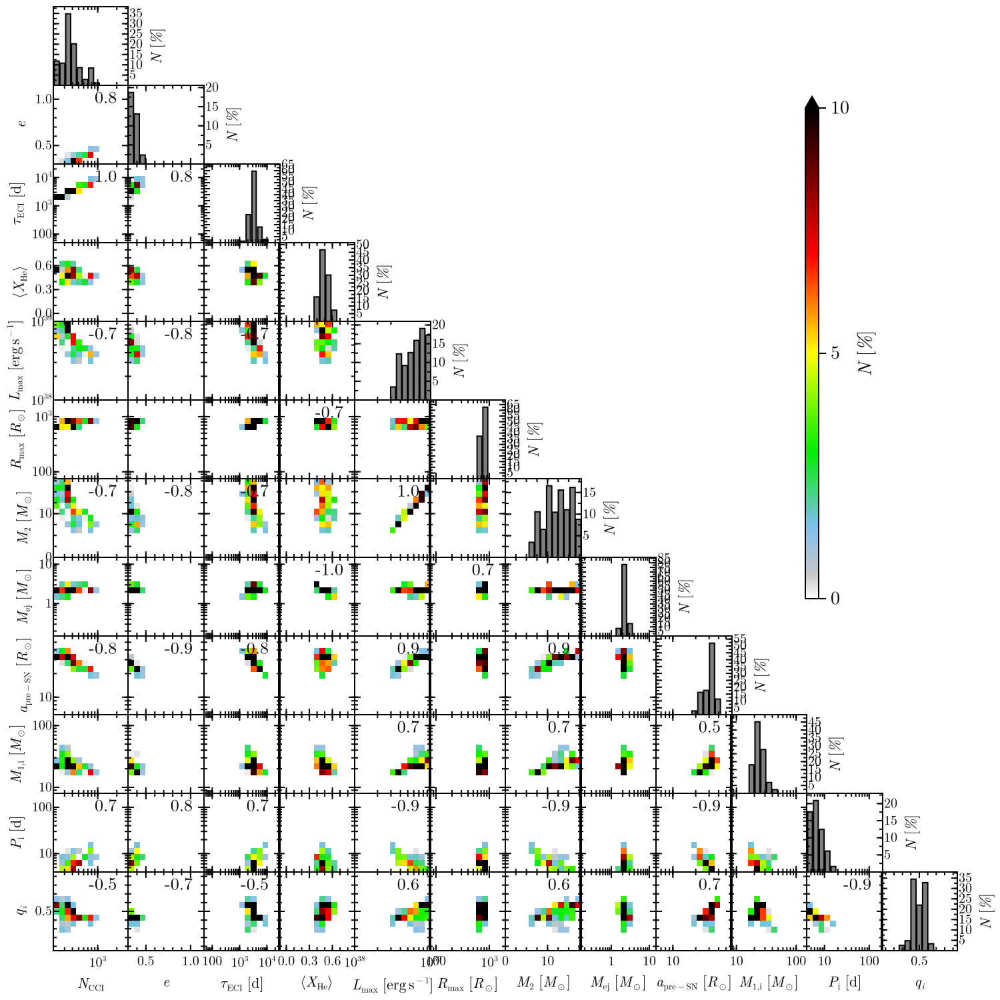

In [14]:

mycmap = cgrad([:white, :gray78, :skyblue2, :green2, :yellow, :red,  :black], 
                [0,      0.05,  0.15,  0.3,     0.5,  0.7,       1])

the_filter = fff_sn2015ap

@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

mlogticks = [k  for j in -90:1:90 for k in  (10. ^j):(10. ^j):(10. ^(j+1))]
mlinticks = 0:0.1:100
xticks10    = [10^t for t in -90.:1.:+90.]
logxticks10 = [t    for t in -90.:1.:+90.]
ticklabels  = [latexstring(@sprintf("10^{%d}", t)) for t in -90:90]
# ticklabels[findfirst(x->x==-2, logxticks10)]="0.01"
ticklabels[findfirst(x->x==-1, logxticks10)]="0.1"
ticklabels[findfirst(x->x== 0, logxticks10)]="1"
ticklabels[findfirst(x->x==+1, logxticks10)]="10"
ticklabels[findfirst(x->x==+2, logxticks10)]="100"
ticks    = (   xticks10, ticklabels)
logticks = (logxticks10, ticklabels)
linticks = 0:0.5:100
ticksize=11
FIGURE = Figure(size=(750,750), figure_padding = 5)
grid = GridLayout(FIGURE[0:10,0:10])
ax = Dict()
val_range = Dict("P"=>[2e0,3e3], 
                 "T"=>[50,3e4], 
                 "N"=>[200,3e3],
                 "e"=>[.3,1.15],
                 "Mej"=>[0.15,15],
                 "S"=>[1.3,2.25],
                 "Eexp"=>[3e50,1e52],
                 "M2"=>[0,18],
                 "Omega"=>[1.2e-4,0.15],
                 "h"=>[1e42,2e49],
                 "Rmax"=>[75,2_000],
                 "Lmax"=>[1e38,1e39],
                 "v_kick"=>[1,300],
                 "<He>"=>[-.1,.89],
                 "Mi"=>[8,150],
                 "Pi"=>[4,200],
                 "qi"=>[0.05,0.95],
                 "a_pre"=>[6,60])
val_scale = Dict("P"=>log10,"<He>"=>identity,"qi"=>identity, "Mi"=>log10, "Pi"=>log10,
                 "T"=>log10, "N"=>log10, "e"=>identity, "h"=>log10,"v_kick"=>log10,
                 "Mej"=>log10, "S"=>identity, "Eexp"=>log10, "M2"=>identity,
                 "Omega"=>log10, "Rmax"=>log10, "Lmax"=>log10, "a_pre"=>log10)
dbins     = Dict("P"=>.25, "T"=>.15, "N"=>.20, "h"=>0.5, "Omega"=>0.2,"a_pre"=>0.10,
                "Mej"=>0.1, "S"=>0.05, "e"=>0.05, "Eexp"=>0.1, "M2"=>2.5,
                "v_kick"=>0.1,"<He>"=>0.1, "Mi"=>0.1, "Pi"=>0.1, "qi"=>0.1, 
                "Rmax"=>0.05, "Lmax"=>0.15)
vals      = Dict("P" => P_postSN[the_filter], 
                 "T"=>tau_ECI[the_filter], 
                 "N"=>n_passages[the_filter], 
                 "Mej"=>Mej[the_filter],
                 "S"=>M_b_ns[the_filter],
                 "pdf"=>pdfs[the_filter]/sum(pdfs[the_filter]) *100,
                 "e"=>eccentricity[the_filter],
                 "Eexp"=>E_exp[the_filter],
                 "M2"=>M2[the_filter],
                 "h"=>Eheat[the_filter],
                 "Omega"=>Omegaeff[the_filter],
                 "Rmax" => Rmax[the_filter],
                 "v_kick"=>v_kick[the_filter],
                 "Lmax"=>Lmax[the_filter],
                 "<He>"=>avg_he[the_filter],
                 "Mi"=>M1[the_filter],
                 "Pi"=>Pi[the_filter],
                 "qi"=>qi[the_filter],
                 "a_pre"=>a_pre[the_filter])
ticks_xtra      = Dict("P" => nothing,
                 "T"=> nothing, 
                 "N"=>nothing, 
                 "Mej"=>nothing,
                 "S"=>nothing,
                 "Mi"=>nothing,
                 "Pi"=>nothing,
                 "<He>"=>(0.:0.3:1, 0.:0.1:1.0),
                 "qi"=>(0.:0.5:1, 0.:0.1:1.0),
                 "e"=>(0.:0.5:1, 0.:0.1:1.0),
                 "Eexp"=>nothing,
                 "M2"=>(0:10:100, 0:2.5:100),
                 "v_kick"=>nothing,
                 "h"=>nothing,
                 "Omega"=>nothing,
                 "Rmax" => nothing,
                 "Lmax"=>nothing,
                 "a_pre"=>nothing)
labels    = Dict("P"=>L"P_\mathrm{post-SN} \ [\mathrm{d}]",
                 "T"=>L"\tau_\mathrm{ECI} \ [\mathrm{d}]",
                 "N"=>L"N_\mathrm{CCI}",
                 "Mej"=>L"M_\mathrm{ej} \ [M_\odot]",
                 "S"=>L"M_\mathrm{NS} \ [M_\odot]",
                 "e"=>L"e",
                 "Eexp"=>L"E_\mathrm{kin,ej} \ [\mathrm{erg}]",
                 "M2"=>L"M_\mathrm{2} \ [M_\odot]",
                 "h"=>L"E_\mathrm{heat} \ [\mathrm{erg}]",
                 "Rmax"=>L"R_\mathrm{max} \ [R_\odot]",
                 "a_pre"=>L"a_\mathrm{pre-SN} \ [R_\odot]",
                 "<He>"=>L"⟨X_\mathrm{He}⟩",
                 "Mi"=>L"M_\mathrm{1,i} \ [M_\odot]",
                 "Pi"=>L"P_\mathrm{i} \ [\mathrm{d}]",
                 "qi"=>L"q_i",
                 "v_kick"=>L"v_\mathrm{kick} \ [\mathrm{km}\,\mathrm{s}^{-1}]",
                 "Lmax"=>L"L_\mathrm{max} \ [\mathrm{erg}\,\mathrm{s}^{-1}]",
                 "Omega"=>L"\tilde{\Omega}_\mathrm{eff}")
digits    = Dict("P"=>0,
                 "T"=>0,
                 "N"=>0,
                 "Mej"=>1,
                 "S"=>2,
                 "e"=>2,
                 "Eexp"=>1,
                 "M2"=>1,
                 "h"=>1,
                 "Rmax"=>0,
                 "a_pre"=>0,
                 "Lmax"=>0,
                 "Omega"=>4, "v_kick"=>0)
SN2022jli     = Dict("P"=>[12.4, :value], "T"=>[310, :lowerlimit], 
                     "Lmax"=>[3e38, :upperlimit],
                     "Mi"=>[NaN,:unknown], "Pi"=>[NaN,:unknown], "qi"=>[NaN,:unknown],
                     "N"=>[floor(305/12.4), :lowerlimit], "h"=>[NaN, :unknown],
                     "Omega"=>[NaN,:unknown], "Mej"=>[NaN, :unknown],
                     "S"=>[NaN,:unknown], "e"=>[0.7, :lowerlimit], "v_kick"=>[NaN, :unknown],
                     "E"=>[NaN,:unknown], "M2"=>[NaN,:unknown], "<He>"=>[0.5, :upperlimit],
                     "Rmax"=>[NaN,:unknown], "a_pre"=>[NaN,:unknown])

colorrange=[0.,10]
bin_scale = :uniform # :custom
variables    = [ "N", "e",  "T", "<He>", "Lmax", "Rmax", "M2", "Mej", "a_pre", "Mi", "Pi", "qi"]
positions = Dict()
for k in range(1,length(variables)) 
        positions[variables[k]] = k  
end
cornerplots  = [[variables[i],variables[j]]
                        for i in 1:length(variables) 
                        for j in (i+1):length(variables)
                ]
for cornerplot in cornerplots
        x=cornerplot[1]
        y=cornerplot[2]
        ax[cornerplot] = plot_settings(grid[positions[y],positions[x]]; 
                ylabel=labels[y],
                xlabel=labels[x], 
                title =" ", 
                ymticks = val_scale[y] == log10 ? val_scale[y].(mlogticks) : ticks_xtra[y][2], 
                xmticks = val_scale[x] == log10 ? val_scale[x].(mlogticks) : ticks_xtra[x][2], 
                yticks  = val_scale[y] == log10 ? logticks  : ticks_xtra[y][1],
                xticks  = val_scale[x] == log10 ? logticks  : ticks_xtra[x][1],
                xlabelvisible = positions[y]==length(variables),
                xticklabelsvisible = positions[y]==length(variables),
                ylabelvisible = positions[x]==1,
                yticklabelsvisible = positions[x]==1,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1

                )
end
for h in variables
        ax[h] = plot_settings(grid[positions[h],positions[h]]; 
                ylabel=L"N \ [%]", 
                xlabel=labels[h], 
                title =" ",
                xscale=val_scale[h],
                xticks  = val_scale[h] == log10 ? ticks     : ticks_xtra[h][1],
                xmticks = val_scale[h] == log10 ? mlogticks : ticks_xtra[h][2], 
                yaxisposition=:right,
                xlabelvisible = positions[h]==length(variables),
                xticklabelsvisible = positions[h]==length(variables),
                yticks=5:5:100,
                ymticks=0:2.5:100,
                xlabelsize=ticksize,
                xticklabelsize=ticksize-1,
                ylabelsize=ticksize,
                yticklabelsize=ticksize-1
                )
end

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
# kick_crit = Dict(occursin("Valli", KICKS) => "V25", occursin("MM", KICKS)=>"M16", occursin("DM25", KICKS)=>"DM25",occursin("COMBINE", KICKS)=>"K18", KICKS=="None"=>"None")[true]
# simulation_settings = @sprintf("Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\nKicks: %s", f_B*100, exp_crit, mer_crit, kick_crit)

# # text!(FIGURE.scene, (.40, .85), text = simulation_settings, fontsize = 20, space = :relative)
# important_data = @sprintf(
# "Only %5.1f%% of Ibc+Ibn supernovae\nwith a MS companion are shown", 
#                 sum(pdfs[fff])/sum(pdfs[fff_basic])*100,
#                 )
# text!(FIGURE.scene, (.45, .9), text = important_data, fontsize = 14, space = :relative)
nbins = 13
hm = nothing           
for cornerplot in cornerplots
        xlab = cornerplot[1]
        ylab = cornerplot[2]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        ymin = val_range[ylab][1]
        ymax = val_range[ylab][2]
        scalex = val_scale[xlab]
        scaley = val_scale[ylab]
        dxb = (bin_scale == :custom) ? dbins[xlab] : (scalex(xmax)-scalex(xmin))/nbins
        dyb = (bin_scale == :custom) ? dbins[ylab] : (scaley(ymax)-scaley(ymin))/nbins

        
        xbins=scalex(xmin):dxb:scalex(xmax)
        ybins=scaley(ymin):dyb:scaley(ymax)

        x = scalex.(vals[xlab])
        y = scaley.(vals[ylab])
        
        hm = sn_heatmap(ax[cornerplot], x, y, vals["pdf"], xbins, ybins; colorrange=colorrange,
                cmap=mycmap, print_data=true, highclip=:black)
        PearsonCoeff = cor(reduce(hcat, [x,y]), Weights(vals["pdf"]))[1,2]
        abs(PearsonCoeff) > 0.5 && text!(ax[cornerplot], @sprintf("%5.1f", PearsonCoeff),
        position = (.85, .95),        # relative coords in axis space
        align = (:right, :top),   # anchor point
        space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        )

        
        xlims!(ax[cornerplot], scalex(xmin), scalex(xmax))
        ylims!(ax[cornerplot], scaley(ymin), scaley(ymax))

end


for histogram in variables
        xlab = histogram
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        scalex = val_scale[xlab]
        dxb = (bin_scale == :custom) ? dbins[xlab] : (scalex(xmax)-scalex(xmin))/nbins
        xbins=scalex(xmin):dxb:scalex(xmax)
        x = (vals[xlab])
        xlims!(ax[histogram], xmin, xmax)
        bins, y_bins = run_histogram(ax[histogram], x, vals["pdf"], xbins, dxb * (scalex==log10 ? 1.2 : 1.), datascale=scalex, norm=1)
        ylims!(ax[histogram], 0, max( maximum(y_bins)*1.1, 12) )
        # stats = POPSYNTH.report_stats(x, vals["pdf"], label = xlab, print2screen=true, unit = (1, ""), multip_percentiles=[0,2.5,5,10,25,50,75,90,95,97.5,100], format_str="%5.1f")    
        
        # stats_string = @sprintf "%*.*f^{+%*.*f}_{-%*.*f}" 5 digits[xlab] stats[1][1]  5 digits[xlab] stats[1][2]  5 digits[xlab] stats[1][3]
        # text!(ax[histogram], latexstring(stats_string),
        #         position = (.85, .95),        # relative coords in axis space
        #         align = (:right, :top),   # anchor point
        #         space = :relative, fontsize=13         # <-- key: interpret position in [0,1] axis-relative coords
        # )

end
Colorbar(FIGURE[1:6,9], hm, label=L"N \ [%]",size = 10)
colgap!(grid, -27)
rowgap!(grid,0)

save_directory = "../output/ECI/cornerplots/"
outfilename = @sprintf("cps_CCI_2015ap_detail_%s_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT, KICKS)
save(save_directory*outfilename, FIGURE)

FIGURE

In [12]:
KICKS

5-element Vector{String}:
 "MM_n500"
 "DM25_n500"
 "COMBINE_n500"
 "Valli25_n500"
 "None"

## kicks

The data in this plot affects 2.458 % of all CCSNe
Warning! No data to plot histogram!
      : 15.5<139.9[+254.5-101.2]<788.0 [     ]. 
Perc. Analysis
   0    5   10   15   20   25   30   35   40   45   50   55   60   65   70 
  75   80   85   90   95  100 
15.5 38.7 49.1 60.1 68.4 73.9 80.0 85.7 92.7 101.3 106.7 112.8 119.3 127.2 138.8 
155.0 172.4 221.1 287.9 394.4 788.0 

The data in this plot affects 2.269 % of all CCSNe
Warning! No data to plot histogram!
      : 29.1<227.5[+270.4-148.7]<701.0 [     ]. 
Perc. Analysis
   0    5   10   15   20   25   30   35   40   45   50   55   60   65   70 
  75   80   85   90   95  100 
29.1 78.7 98.8 114.2 128.1 137.2 151.8 164.2 172.1 179.9 191.0 214.4 229.5 244.5 262.9 
283.3 308.8 357.8 398.8 497.8 701.0 

The data in this plot affects 23.403 % of all CCSNe
      :  0.0<235.1[+274.8-174.2]<1234.2 [     ]. 
Perc. Analysis
   0    5   10   15   20   25   30   35   40   45   50   55   60   65   70 
  75   80   85   90   95  100 
 0.0 60.9 91.7

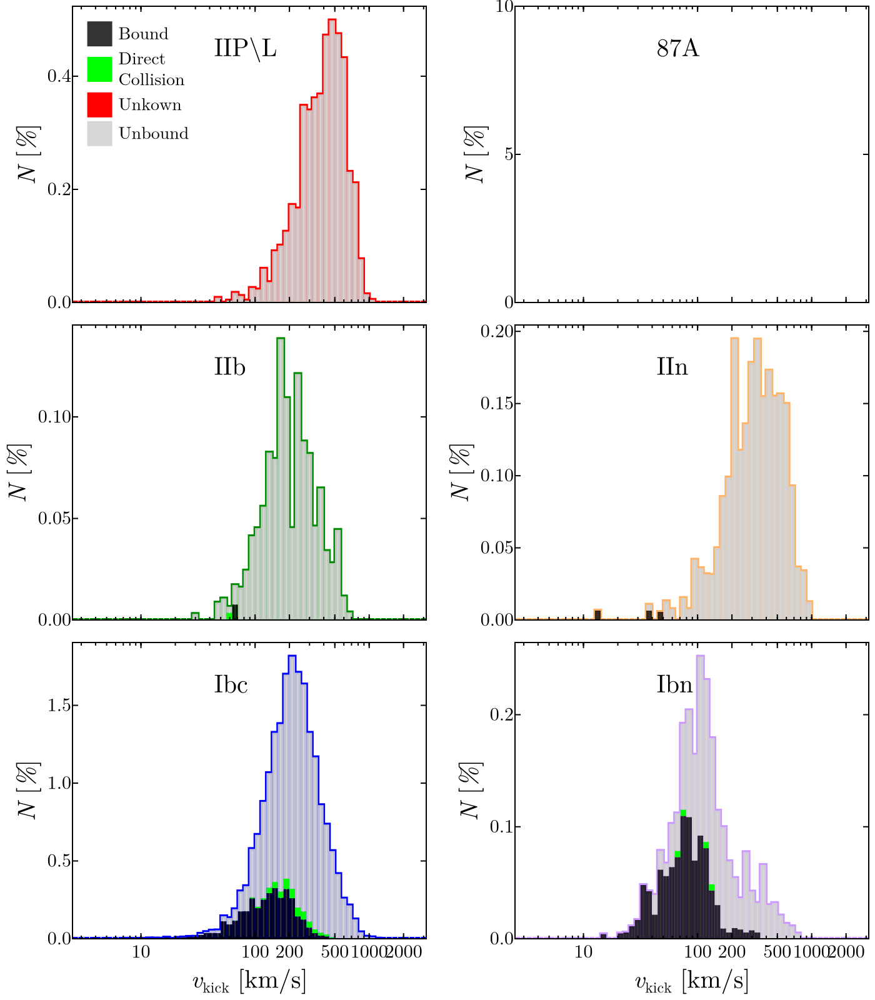

In [93]:
dxb = 0.05
xbins= -1:dxb:4.5
xmin = 200

FIGURE = Figure(size=(700,800), figure_padding = 5)
grid = GridLayout(FIGURE[1,1])

logticks = [ k  for j in -5:1:5 for k in  10. ^j:10. ^j:10. ^(j+1) ]
ticks = ([     -3,     -2,    -1,   0,    1,     2,  log10(200),log10(500), 3, log10(2000),4,      5], 
        ["0.001", "0.01", "0.1", "1", "10", "100", "200", "500", L"1000", "2000", L"10^4", L"10^5"])
ticks2 = ([  1e-3,   1e-2,  1e-1,   1,    10,   1e2, 2e2,     1e3,    1e4,    1e5], 
        ["0.001", "0.01", "0.1", "1", "10", "100", "200", L"10^3", L"10^4", L"10^5"])


subplot(position; show_xlabel=false, show_ylabel=false) = plot_settings(
            position; 
            xlabel=L"v_\mathrm{kick} \ [\mathrm{km}/\mathrm{s}]",
            ylabel=L"N \ [%]", xticks=ticks, xmticks = log10.(logticks),
            title =" ",
            xlabelvisible=show_xlabel,xticklabelsvisible=show_xlabel,
            ylabelvisible=show_ylabel,yticklabelsvisible=show_ylabel,)
ax=Dict()
ax[:IIP]=subplot(grid[1,1], show_xlabel=false, show_ylabel=true)
ax[:IIb]=subplot(grid[2,1], show_xlabel=false, show_ylabel=true)
ax[:Ibc]=subplot(grid[3,1], show_xlabel=true,  show_ylabel=true)
ax[:SN87A]=subplot(grid[1,2], show_xlabel=false, show_ylabel=true)
ax[:IIn]=subplot(grid[2,2], show_xlabel=false, show_ylabel=true)
ax[:Ibn]=subplot(grid[3,2], show_xlabel=true,  show_ylabel=true)

alpha=1
color_coding = Dict() 
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding[:BH] = RGBAf(.15, .15, .15 ,alpha) 
sn_to_text = Dict( :IIP=>"IIP\\L", :SN87A=>"87A", :IIb=>"IIb", :IIn=>"IIn", :Ibc=>"Ibc", :Ibn=>"Ibn" )
for sn in keys(ax) 
    what = v_kick
    fff    = (SNe .== sn) .&& select_sne .&& (post_SN_orbit .!= :merged) .&& (prgs .!== "M" .|| prgs .!== "NI-S")
    fff_b  = fff .&& (post_SN_orbit .== :bound)
    fff_u  = fff .&& (post_SN_orbit .== :unbound)
    fff_d  = fff .&& (post_SN_orbit .== :direct_collision) 
    fff_m  = fff .&& (post_SN_orbit .== :unknown) 
    fff_error = fff .⊻ (fff_b .|| fff_u .|| fff_d .|| fff_m)
    if (true in fff_error) 
        @printf("mismatches: %d\n", length(what[fff_error]))  
        @printf("e.g.: post_SN_orbit[fff_error][1] %s\n", post_SN_orbit[fff_error][1])  
        throw(ErrorException("the fff_x are not partitions of fff"))
    end 
    pdf_error = sum(pdfs[fff]) -  (sum(pdfs[fff_b])+sum(pdfs[fff_u])+sum(pdfs[fff_d])+sum(pdfs[fff_m]))
    if (abs(pdf_error) > 1e-9) 
        @printf("pdf problem: total %5.3f != parts = %5.3f + %5.3f + %5.3f + %5.3f \n", sum(pdfs[fff]), sum(pdfs[fff_b]), sum(pdfs[fff_u]), sum(pdfs[fff_d]), sum(pdfs[fff_m]) )
        @printf("difference =  %5.3e \n", sum(pdfs[fff]) - (sum(pdfs[fff_b]) + sum(pdfs[fff_u]) + sum(pdfs[fff_d]) + sum(pdfs[fff_m])) )
        throw(ErrorException("the fff_x are not good partitions of fff"))
    end 
    # @printf("v_kick: min=%.2e max=%.2e days\n", 
    #         minimum(POPSYNTH.killnan(v_kick[fff], replacewith=+Inf)), 
    #         maximum(POPSYNTH.killnan(v_kick[fff], replacewith=-Inf)), )

    @printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

    mycmap = cgrad([:white, :blue, :green, :yellow, :red,  :black], 
                    [0,      1e-6,  0.01,  0.05,   0.1,  0.5 ])

    
    text!(ax[sn], (0.4,.9), text=sn_to_text[sn], align = (:left, :top), 
    fontsize=20, color=:black, space = :relative)
    xbars, ybars   = run_histogram(ax[sn], log10.(what[fff]  ), pdfs[fff]  , xbins, dxb, to_plot = true, color = :white, strokewidth=3, norm=1, colorcont=color_coding[sn])
        _, ybars_b = run_histogram(ax[sn], log10.(what[fff_b]), pdfs[fff_b], xbins, dxb, to_plot = false, norm=1)
        _, ybars_u = run_histogram(ax[sn], log10.(what[fff_u]), pdfs[fff_u], xbins, dxb, to_plot = false, norm=1)
        _, ybars_d = run_histogram(ax[sn], log10.(what[fff_d]), pdfs[fff_d], xbins, dxb, to_plot = false, norm=1)
        _, ybars_m = run_histogram(ax[sn], log10.(what[fff_m]), pdfs[fff_m], xbins, dxb, to_plot = false, norm=1)
    stacked_barplot!(ax[sn], xbars, [ybars_b, ybars_d, ybars_m, ybars_u],;
                            width=dxb, direction=:y, colors=[(:black,0.8), (:lime,1), (:red,1), (:lightgray,0.9)],)
    
    true in fff && POPSYNTH.report_stats(what[fff], pdfs[fff], print2screen=true)
    if sn == :IIP 
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:black,0.8), strokecolor = :black, label="Bound")
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:lime,   1), strokecolor = :black, label="Direct\nCollision")
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:red,    1), strokecolor = :black, label="Unkown")
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:lightgray,0.9), strokecolor = :black, label="Unbound")
        axislegend(ax[sn]; position = :lt, nbanks=1, framevisible=false, fontsize=10)
    end
    xlims!(ax[sn], .4, 3.5)
    ylims!(ax[sn], 0.0, nothing)
end

save_directory = "../output/ECI/"
outfilename = @sprintf("hist_vkick_%s.pdf", KICKS)
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png

FIGURE

The data in this plot affects 2.468 % of all CCSNe
Warning! No data to plot histogram!
Warning! No data to plot histogram!
Warning! No data to plot histogram!
      :  1.1< 7.7[+ 5.5- 4.7]<18.3 [     ]. 
Perc. Analysis
   0    5   10   15   20   25   30   35   40   45   50   55   60   65   70 
  75   80   85   90   95  100 
 1.1  3.0  4.0  4.5  5.0  5.6  5.9  6.2  6.7  7.1  7.5  8.0  8.4  8.8  9.1 
 9.6 10.2 10.9 11.8 13.3 18.3 

The data in this plot affects 20.439 % of all CCSNe
      :  0.0<142.0[+355.6-63.5]<1501.4 [     ]. 
Perc. Analysis
   0    5   10   15   20   25   30   35   40   45   50   55   60   65   70 
  75   80   85   90   95  100 
 0.0 78.5 84.9 88.1 90.6 92.9 94.8 96.6 98.4 99.9 101.6 103.2 104.8 106.8 108.8 
111.2 114.0 119.3 272.0 497.6 1501.4 



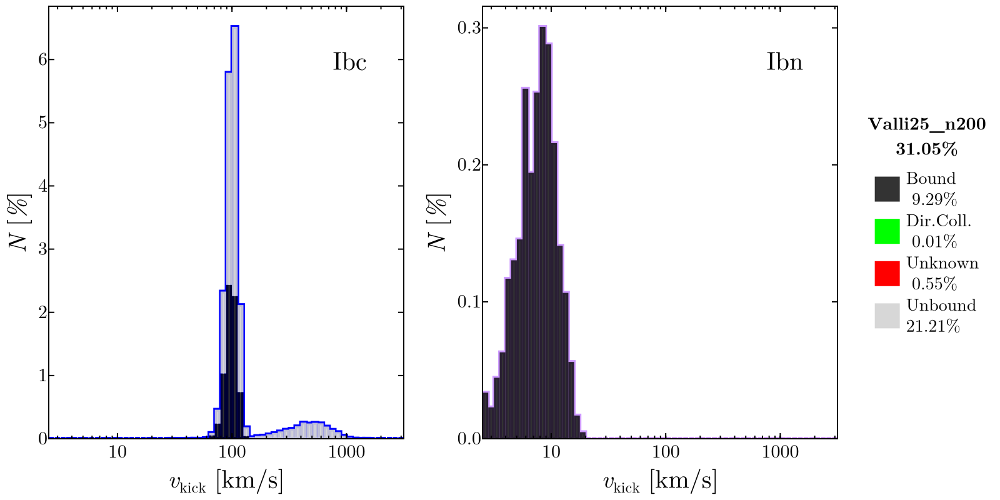

In [11]:
using QuadGK 
using Distributions 
dxb = 0.05
xbins= 0:dxb:4
xmin = 200
f_maxwell(v; s=265.) = sqrt(2/pi) * v^2 / s^3 * exp(-v^2/(2*s^2)) 
FIGURE = Figure(size=(800,400), figure_padding = 5, label = KICKS)
grid = GridLayout(FIGURE[1,1])

logticks = [ k  for j in -5:1:5 for k in  10. ^j:10. ^j:10. ^(j+1) ]
ticks = ([     -3,     -2,    -1,   0,    1,     2,    3, 4,      5], 
        ["0.001", "0.01", "0.1", "1", "10", "100", L"1000",  L"10^4", L"10^5"])


subplot(position; show_xlabel=false, show_ylabel=false) = plot_settings(
            position; 
            xlabel=L"v_\mathrm{kick} \ [\mathrm{km}/\mathrm{s}]",
            ylabel=L"N \ [%]", xticks=ticks, xmticks = log10.(logticks),
            title =" ",
            xlabelvisible=show_xlabel,xticklabelsvisible=show_xlabel,
            ylabelvisible=show_ylabel,yticklabelsvisible=show_ylabel,)
ax=Dict()
ax[:Ibc]=subplot(grid[1,1], show_xlabel=true,  show_ylabel=true)
ax[:Ibn]=subplot(grid[1,2], show_xlabel=true,  show_ylabel=true)

alpha=1
color_coding = Dict() 
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding[:BH] = RGBAf(.15, .15, .15 ,alpha) 
sn_to_text = Dict( :IIP=>"IIP\\L", :SN87A=>"87A", :IIb=>"IIb", :IIn=>"IIn", :Ibc=>"Ibc", :Ibn=>"Ibn" )
for sn in keys(ax) 
    what = v_kick
    fff    = (SNe .== sn) .&& select_sne .&& (post_SN_orbit .!= :merged) .&& (prgs .!== "M" .&& prgs .!== "NI-S")
    fff_b  = fff .&& (post_SN_orbit .== :bound)
    fff_u  = fff .&& (post_SN_orbit .== :unbound)
    fff_d  = fff .&& (post_SN_orbit .== :direct_collision) 
    fff_m  = fff .&& (post_SN_orbit .== :unknown) 
    fff_error = fff .⊻ (fff_b .|| fff_u .|| fff_d .|| fff_m)
    if (true in fff_error) 
        @printf("mismatches: %d\n", length(what[fff_error]))  
        @printf("e.g.: post_SN_orbit[fff_error][1] %s\n", post_SN_orbit[fff_error][1])  
        throw(ErrorException("the fff_x are not partitions of fff"))
    end 
    pdf_error = sum(pdfs[fff]) -  (sum(pdfs[fff_b])+sum(pdfs[fff_u])+sum(pdfs[fff_d])+sum(pdfs[fff_m]))
    if (abs(pdf_error) > 1e-9) 
        @printf("pdf problem: total %5.3f != parts = %5.3f + %5.3f + %5.3f + %5.3f \n", sum(pdfs[fff]), sum(pdfs[fff_b]), sum(pdfs[fff_u]), sum(pdfs[fff_d]), sum(pdfs[fff_m]) )
        @printf("difference =  %5.3e \n", sum(pdfs[fff]) - (sum(pdfs[fff_b]) + sum(pdfs[fff_u]) + sum(pdfs[fff_d]) + sum(pdfs[fff_m])) )
        throw(ErrorException("the fff_x are not good partitions of fff"))
    end 
    # @printf("v_kick: min=%.2e max=%.2e days\n", 
    #         minimum(POPSYNTH.killnan(v_kick[fff], replacewith=+Inf)), 
    #         maximum(POPSYNTH.killnan(v_kick[fff], replacewith=-Inf)), )

    @printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))
    
    xbars, ybars   = run_histogram(ax[sn], log10.(what[fff]  ), pdfs[fff]  , xbins, dxb, to_plot = true, color = :white, strokewidth=3, norm=1, colorcont=color_coding[sn])
        _, ybars_b = run_histogram(ax[sn], log10.(what[fff_b]), pdfs[fff_b], xbins, dxb, to_plot = false, norm=1)
        _, ybars_u = run_histogram(ax[sn], log10.(what[fff_u]), pdfs[fff_u], xbins, dxb, to_plot = false, norm=1)
        _, ybars_d = run_histogram(ax[sn], log10.(what[fff_d]), pdfs[fff_d], xbins, dxb, to_plot = false, norm=1)
        _, ybars_m = run_histogram(ax[sn], log10.(what[fff_m]), pdfs[fff_m], xbins, dxb, to_plot = false, norm=1)
    stacked_barplot!(ax[sn], xbars, [ybars_b, ybars_d, ybars_m, ybars_u],;
                            width=dxb, direction=:y, colors=[(:black,0.8), (:lime,1), (:red,1), (:lightgray,0.9)],)
    text!(ax[sn], (0.8,.9), text=sn_to_text[sn], align = (:left, :top), 
    fontsize=20, color=:black, space = :relative)
    # xs = -5.:0.01:5.
    # xs_l = 10. .^ xs
    # occursin("Hobbs", KICKS) && (curve = xs_l .* f_maxwell.(xs_l, s=265)) # shape to compare
    # occursin("DM25", KICKS)  && (curve = xs_l .* pdf.(LogNormal(5.6, 0.68), xs_l)) # shape to compare

    # curve ./= maximum(curve)
    # scale = maximum(ybars) / maximum(curve)
    # lines!(ax[sn], xs, scale .* curve, color=:blue, label="Theoretical")
    
    true in fff && POPSYNTH.report_stats(what[fff], pdfs[fff], print2screen=true)
    if sn == :Ibc 
        generic_fff    = select_sne .&& (prgs .!== "M" .&& prgs .!== "NI-S")
        generic_fff_b  = generic_fff .&& (post_SN_orbit .== :bound)
        generic_fff_u  = generic_fff .&& (post_SN_orbit .== :unbound)
        generic_fff_d  = generic_fff .&& (post_SN_orbit .== :direct_collision) 
        generic_fff_m  = generic_fff .&& (post_SN_orbit .== :unknown) 


        barplot!(ax[sn], [1e-99], [1e-99]; color=(:black,0.8), strokecolor = :black, label=@sprintf("Bound\n%5.2f%%", sum(pdfs[generic_fff_b])))
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:lime,   1), strokecolor = :black, label=@sprintf("Dir.Coll.\n%5.2f%%", sum(pdfs[generic_fff_d])))
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:red,    1), strokecolor = :black, label=@sprintf("Unknown\n%5.2f%%", sum(pdfs[generic_fff_m])))
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:lightgray,0.9), strokecolor = :black, label=@sprintf("Unbound\n%5.2f%%", sum(pdfs[generic_fff_u])))
        Legend(grid[1,3], ax[sn], @sprintf("%s\n%5.2f%%", KICKS, sum(pdfs[generic_fff])), position = :lt,
                    nbanks=1, framevisible=false, fontsize=9)
    end
    xlims!(ax[sn], .4, 3.5)
    ylims!(ax[sn], 0.0, nothing)
end

save_directory = "../output/ECI/"
outfilename = @sprintf("sub_hist_vkick_%s.pdf", KICKS)
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png

FIGURE 

In [17]:

fff1    = select_sne .&& (post_SN_orbit .== :bound)            .&& (prgs .!== "M" .&& prgs .!== "NI-S")
fff2    = select_sne .&& (post_SN_orbit .== :unbound)          .&& (prgs .!== "M" .&& prgs .!== "NI-S")
fff3    = select_sne .&& (post_SN_orbit .== :merged)           .&& (prgs .!== "M" .&& prgs .!== "NI-S")
fff4    = select_sne .&& (post_SN_orbit .== :direct_collision) .&& (prgs .!== "M" .&& prgs .!== "NI-S")
fff5    = select_sne .&& (post_SN_orbit .== :unkwown)          .&& (prgs .!== "M" .&& prgs .!== "NI-S")
sum(pdfs[fff5 .|| fff4 .|| fff3 .|| fff2 .|| fff1])

30.49988855202259

The data in this plot affects 2.514 % of all CCSNe
Warning! No data to plot histogram!
Warning! No data to plot histogram!
Warning! No data to plot histogram!
      : 27.7<84.4[+86.7-42.4]<249.9 [     ]. 
Perc. Analysis
   0    5   10   15   20   25   30   35   40   45   50   55   60   65   70 
  75   80   85   90   95  100 
27.7 42.0 49.1 53.4 57.1 60.6 64.3 67.2 69.6 71.6 73.4 75.3 77.8 81.4 86.0 
92.9 102.5 120.3 150.1 171.1 249.9 

The data in this plot affects 20.826 % of all CCSNe
Warning! No data to plot histogram!
      :  0.0<85.9[+132.0-65.2]<336.0 [     ]. 
Perc. Analysis
   0    5   10   15   20   25   30   35   40   45   50   55   60   65   70 
  75   80   85   90   95  100 
 0.0 20.6 27.6 31.5 34.8 38.7 42.8 47.6 53.0 59.2 66.3 74.0 82.6 92.6 104.1 
117.9 134.1 154.1 179.0 217.8 336.0 



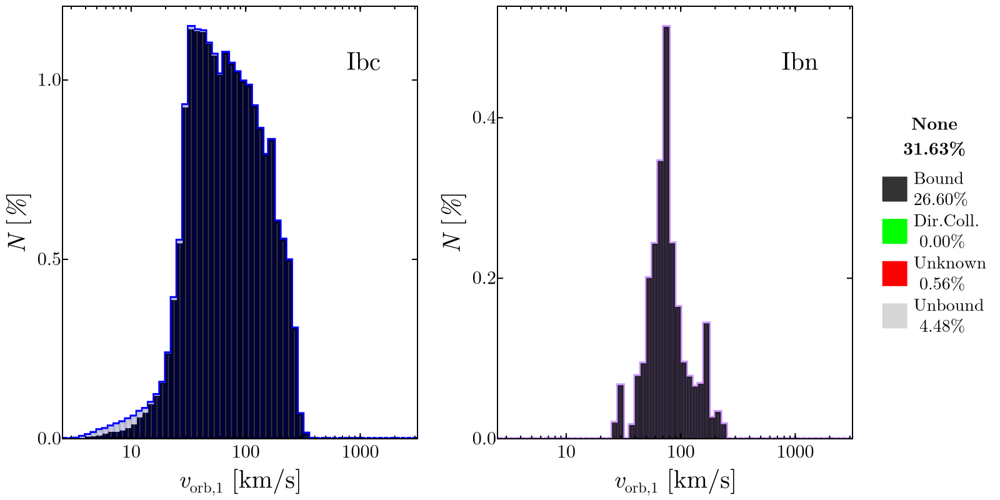

In [14]:
using QuadGK 
using Distributions 
dxb = 0.05
xbins= 0:dxb:4
xmin = 200
f_maxwell(v; s=265.) = sqrt(2/pi) * v^2 / s^3 * exp(-v^2/(2*s^2)) 
FIGURE = Figure(size=(800,400), figure_padding = 5, label = KICKS)
grid = GridLayout(FIGURE[1,1])

logticks = [ k  for j in -5:1:5 for k in  10. ^j:10. ^j:10. ^(j+1) ]
ticks = ([     -3,     -2,    -1,   0,    1,     2,    3, 4,      5], 
        ["0.001", "0.01", "0.1", "1", "10", "100", L"1000",  L"10^4", L"10^5"])


subplot(position; show_xlabel=false, show_ylabel=false) = plot_settings(
            position; 
            xlabel=L"v_\mathrm{orb,1} \ [\mathrm{km}/\mathrm{s}]",
            ylabel=L"N \ [%]", xticks=ticks, xmticks = log10.(logticks),
            title =" ",
            xlabelvisible=show_xlabel,xticklabelsvisible=show_xlabel,
            ylabelvisible=show_ylabel,yticklabelsvisible=show_ylabel,)
ax=Dict()
ax[:Ibc]=subplot(grid[1,1], show_xlabel=true,  show_ylabel=true)
ax[:Ibn]=subplot(grid[1,2], show_xlabel=true,  show_ylabel=true)

alpha=1
color_coding = Dict() 
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding[:BH] = RGBAf(.15, .15, .15 ,alpha) 
sn_to_text = Dict( :IIP=>"IIP\\L", :SN87A=>"87A", :IIb=>"IIb", :IIn=>"IIn", :Ibc=>"Ibc", :Ibn=>"Ibn" )
for sn in keys(ax) 
    what = v_orb_1
    fff    = (SNe .== sn) .&& select_sne .&& (post_SN_orbit .!= :merged) .&& (prgs .!== "M" .&& prgs .!== "NI-S")
    fff_b  = fff .&& (post_SN_orbit .== :bound)
    fff_u  = fff .&& (post_SN_orbit .== :unbound)
    fff_d  = fff .&& (post_SN_orbit .== :direct_collision) 
    fff_m  = fff .&& (post_SN_orbit .== :unknown) 
    fff_error = fff .⊻ (fff_b .|| fff_u .|| fff_d .|| fff_m)
    if (true in fff_error) 
        @printf("mismatches: %d\n", length(what[fff_error]))  
        @printf("e.g.: post_SN_orbit[fff_error][1] %s\n", post_SN_orbit[fff_error][1])  
        throw(ErrorException("the fff_x are not partitions of fff"))
    end 
    pdf_error = sum(pdfs[fff]) -  (sum(pdfs[fff_b])+sum(pdfs[fff_u])+sum(pdfs[fff_d])+sum(pdfs[fff_m]))
    if (abs(pdf_error) > 1e-9) 
        @printf("pdf problem: total %5.3f != parts = %5.3f + %5.3f + %5.3f + %5.3f \n", sum(pdfs[fff]), sum(pdfs[fff_b]), sum(pdfs[fff_u]), sum(pdfs[fff_d]), sum(pdfs[fff_m]) )
        @printf("difference =  %5.3e \n", sum(pdfs[fff]) - (sum(pdfs[fff_b]) + sum(pdfs[fff_u]) + sum(pdfs[fff_d]) + sum(pdfs[fff_m])) )
        throw(ErrorException("the fff_x are not good partitions of fff"))
    end 
    # @printf("v_kick: min=%.2e max=%.2e days\n", 
    #         minimum(POPSYNTH.killnan(v_kick[fff], replacewith=+Inf)), 
    #         maximum(POPSYNTH.killnan(v_kick[fff], replacewith=-Inf)), )

    @printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))
    
    xbars, ybars   = run_histogram(ax[sn], log10.(what[fff]  ), pdfs[fff]  , xbins, dxb, to_plot = true, color = :white, strokewidth=3, norm=1, colorcont=color_coding[sn])
        _, ybars_b = run_histogram(ax[sn], log10.(what[fff_b]), pdfs[fff_b], xbins, dxb, to_plot = false, norm=1)
        _, ybars_u = run_histogram(ax[sn], log10.(what[fff_u]), pdfs[fff_u], xbins, dxb, to_plot = false, norm=1)
        _, ybars_d = run_histogram(ax[sn], log10.(what[fff_d]), pdfs[fff_d], xbins, dxb, to_plot = false, norm=1)
        _, ybars_m = run_histogram(ax[sn], log10.(what[fff_m]), pdfs[fff_m], xbins, dxb, to_plot = false, norm=1)
    stacked_barplot!(ax[sn], xbars, [ybars_b, ybars_d, ybars_m, ybars_u],;
                            width=dxb, direction=:y, colors=[(:black,0.8), (:lime,1), (:red,1), (:lightgray,0.9)],)
    text!(ax[sn], (0.8,.9), text=sn_to_text[sn], align = (:left, :top), 
    fontsize=20, color=:black, space = :relative)
    # xs = -5.:0.01:5.
    # xs_l = 10. .^ xs
    # occursin("Hobbs", KICKS) && (curve = xs_l .* f_maxwell.(xs_l, s=265)) # shape to compare
    # occursin("DM25", KICKS)  && (curve = xs_l .* pdf.(LogNormal(5.6, 0.68), xs_l)) # shape to compare

    # curve ./= maximum(curve)
    # scale = maximum(ybars) / maximum(curve)
    # lines!(ax[sn], xs, scale .* curve, color=:blue, label="Theoretical")
    
    true in fff && POPSYNTH.report_stats(what[fff], pdfs[fff], print2screen=true)
    if sn == :Ibc 
        generic_fff    = select_sne .&& (prgs .!== "M" .&& prgs .!== "NI-S")
        generic_fff_b  = generic_fff .&& (post_SN_orbit .== :bound)
        generic_fff_u  = generic_fff .&& (post_SN_orbit .== :unbound)
        generic_fff_d  = generic_fff .&& (post_SN_orbit .== :direct_collision) 
        generic_fff_m  = generic_fff .&& (post_SN_orbit .== :unknown) 


        barplot!(ax[sn], [1e-99], [1e-99]; color=(:black,0.8), strokecolor = :black, label=@sprintf("Bound\n%5.2f%%", sum(pdfs[generic_fff_b])))
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:lime,   1), strokecolor = :black, label=@sprintf("Dir.Coll.\n%5.2f%%", sum(pdfs[generic_fff_d])))
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:red,    1), strokecolor = :black, label=@sprintf("Unknown\n%5.2f%%", sum(pdfs[generic_fff_m])))
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:lightgray,0.9), strokecolor = :black, label=@sprintf("Unbound\n%5.2f%%", sum(pdfs[generic_fff_u])))
        Legend(grid[1,3], ax[sn], @sprintf("%s\n%5.2f%%", KICKS, sum(pdfs[generic_fff])), position = :lt,
                    nbanks=1, framevisible=false, fontsize=9)
    end
    xlims!(ax[sn], .4, 3.5)
    ylims!(ax[sn], 0.0, nothing)
end

save_directory = "../output/ECI/"
outfilename = @sprintf("sub_hist_vorb_%s.pdf", KICKS)
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png

FIGURE 

The data in this plot affects 2.469 % of all CCSNe
Warning! No data to plot histogram!
Warning! No data to plot histogram!
The data in this plot affects 2.278 % of all CCSNe
Warning! No data to plot histogram!
Warning! No data to plot histogram!
The data in this plot affects 23.502 % of all CCSNe
The data in this plot affects 21.378 % of all CCSNe
Warning! No data to plot histogram!
Warning! No data to plot histogram!
The data in this plot affects 0.000 % of all CCSNe
Warning! No data to plot histogram!
Warning! No data to plot histogram!
Warning! No data to plot histogram!
Warning! No data to plot histogram!
Warning! No data to plot histogram!
The data in this plot affects 2.235 % of all CCSNe
Warning! No data to plot histogram!
Warning! No data to plot histogram!


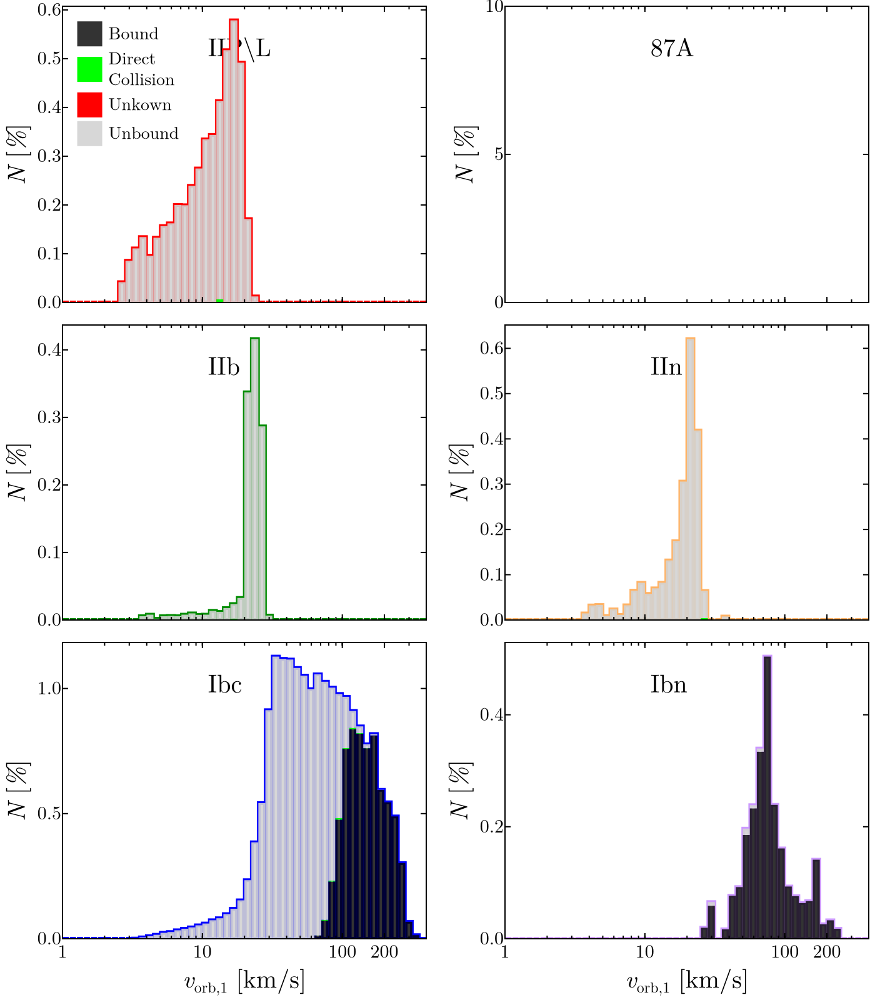

In [15]:
dxb = 0.05
xbins= -1:dxb:4.5
xmin = 200

FIGURE = Figure(size=(700,800), figure_padding = 5)
grid = GridLayout(FIGURE[1,1])

logticks = [ k  for j in -5:1:5 for k in  10. ^j:10. ^j:10. ^(j+1) ]
ticks = ([     -3,     -2,    -1,   0,    1,     2,  log10(200),log10(500), 3, log10(2000),4,      5], 
        ["0.001", "0.01", "0.1", "1", "10", "100", "200", "500", L"1000", "2000", L"10^4", L"10^5"])
ticks2 = ([  1e-3,   1e-2,  1e-1,   1,    10,   1e2, 2e2,     1e3,    1e4,    1e5], 
        ["0.001", "0.01", "0.1", "1", "10", "100", "200", L"10^3", L"10^4", L"10^5"])


subplot(position; show_xlabel=false, show_ylabel=false) = plot_settings(
            position; 
            xlabel=L"v_\mathrm{orb,1} \ [\mathrm{km}/\mathrm{s}]",
            ylabel=L"N \ [%]", xticks=ticks, xmticks = log10.(logticks),
            title =" ",
            xlabelvisible=show_xlabel,xticklabelsvisible=show_xlabel,
            ylabelvisible=show_ylabel,yticklabelsvisible=show_ylabel,)
ax=Dict()
ax[:IIP]=subplot(grid[1,1], show_xlabel=false, show_ylabel=true)
ax[:IIb]=subplot(grid[2,1], show_xlabel=false, show_ylabel=true)
ax[:Ibc]=subplot(grid[3,1], show_xlabel=true,  show_ylabel=true)
ax[:SN87A]=subplot(grid[1,2], show_xlabel=false, show_ylabel=true)
ax[:IIn]=subplot(grid[2,2], show_xlabel=false, show_ylabel=true)
ax[:Ibn]=subplot(grid[3,2], show_xlabel=true,  show_ylabel=true)

alpha=1
color_coding = Dict() 
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding[:BH] = RGBAf(.15, .15, .15 ,alpha) 
sn_to_text = Dict( :IIP=>"IIP\\L", :SN87A=>"87A", :IIb=>"IIb", :IIn=>"IIn", :Ibc=>"Ibc", :Ibn=>"Ibn" )
for sn in keys(ax) 
    what = v_orb_1
    fff    = (SNe .== sn) .&& select_sne .&& (post_SN_orbit .!= :merged) .&& (prgs .!== "M" .|| prgs .!== "NI-S")
    fff_b  = fff .&& (post_SN_orbit .== :bound)
    fff_u  = fff .&& (post_SN_orbit .== :unbound)
    fff_d  = fff .&& (post_SN_orbit .== :direct_collision) 
    fff_m  = fff .&& (post_SN_orbit .== :unknown) 
    fff_error = fff .⊻ (fff_b .|| fff_u .|| fff_d .|| fff_m)
    if (true in fff_error) 
        @printf("mismatches: %d\n", length(what[fff_error]))  
        @printf("e.g.: post_SN_orbit[fff_error][1] %s\n", post_SN_orbit[fff_error][1])  
        throw(ErrorException("the fff_x are not partitions of fff"))
    end 
    pdf_error = sum(pdfs[fff]) -  (sum(pdfs[fff_b])+sum(pdfs[fff_u])+sum(pdfs[fff_d])+sum(pdfs[fff_m]))
    if (abs(pdf_error) > 1e-9) 
        @printf("pdf problem: total %5.3f != parts = %5.3f + %5.3f + %5.3f + %5.3f \n", sum(pdfs[fff]), sum(pdfs[fff_b]), sum(pdfs[fff_u]), sum(pdfs[fff_d]), sum(pdfs[fff_m]) )
        @printf("difference =  %5.3e \n", sum(pdfs[fff]) - (sum(pdfs[fff_b]) + sum(pdfs[fff_u]) + sum(pdfs[fff_d]) + sum(pdfs[fff_m])) )
        throw(ErrorException("the fff_x are not good partitions of fff"))
    end 
    # @printf("what: min=%.2e max=%.2e days\n", 
    #         minimum(POPSYNTH.killnan(what[fff], replacewith=+Inf)), 
    #         maximum(POPSYNTH.killnan(what[fff], replacewith=-Inf)), )

    @printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

    mycmap = cgrad([:white, :blue, :green, :yellow, :red,  :black], 
                    [0,      1e-6,  0.01,  0.05,   0.1,  0.5 ])

    
    text!(ax[sn], (0.4,.9), text=sn_to_text[sn], align = (:left, :top), 
    fontsize=20, color=:black, space = :relative)
    xbars, ybars   = run_histogram(ax[sn], log10.(what[fff]  ), pdfs[fff]  , xbins, dxb, to_plot = true, color = :white, strokewidth=3, norm=1, colorcont=color_coding[sn])
        _, ybars_b = run_histogram(ax[sn], log10.(what[fff_b]), pdfs[fff_b], xbins, dxb, to_plot = false, norm=1)
        _, ybars_u = run_histogram(ax[sn], log10.(what[fff_u]), pdfs[fff_u], xbins, dxb, to_plot = false, norm=1)
        _, ybars_d = run_histogram(ax[sn], log10.(what[fff_d]), pdfs[fff_d], xbins, dxb, to_plot = false, norm=1)
        _, ybars_m = run_histogram(ax[sn], log10.(what[fff_m]), pdfs[fff_m], xbins, dxb, to_plot = false, norm=1)
    stacked_barplot!(ax[sn], xbars, [ybars_b, ybars_d, ybars_m, ybars_u],;
                            width=dxb, direction=:y, colors=[(:black,0.8), (:lime,1), (:red,1), (:lightgray,0.9)],)
    if sn == :IIP 
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:black,0.8), strokecolor = :black, label="Bound")
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:lime,   1), strokecolor = :black, label="Direct\nCollision")
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:red,    1), strokecolor = :black, label="Unkown")
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:lightgray,0.9), strokecolor = :black, label="Unbound")
        axislegend(ax[sn]; position = :lt, nbanks=1, framevisible=false, fontsize=10)
    end
    xlims!(ax[sn], 0, 2.6)
    ylims!(ax[sn], 0.0, nothing)
end

save_directory = "../output/ECI/"
outfilename = @sprintf("hist_vorb_%s.pdf", KICKS)
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png

FIGURE

The data in this plot affects 2.469 % of all CCSNe
Warning! No data to plot histogram!
Warning! No data to plot histogram!
The data in this plot affects 2.278 % of all CCSNe
Warning! No data to plot histogram!
Warning! No data to plot histogram!
The data in this plot affects 23.502 % of all CCSNe
The data in this plot affects 21.378 % of all CCSNe
Warning! No data to plot histogram!
Warning! No data to plot histogram!
The data in this plot affects 0.000 % of all CCSNe
Warning! No data to plot histogram!
Warning! No data to plot histogram!
Warning! No data to plot histogram!
Warning! No data to plot histogram!
Warning! No data to plot histogram!
The data in this plot affects 2.235 % of all CCSNe
Warning! No data to plot histogram!
Warning! No data to plot histogram!


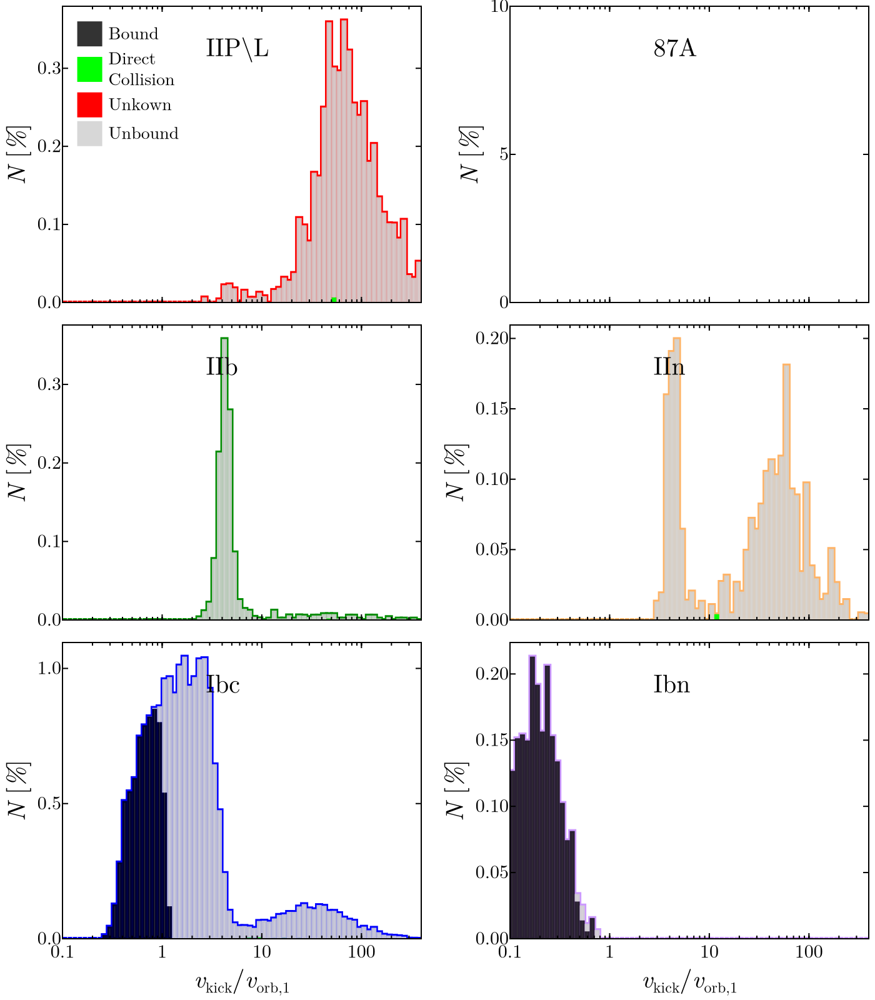

In [16]:
dxb = 0.05
xbins= -1:dxb:4.5
xmin = 200

FIGURE = Figure(size=(700,800), figure_padding = 5)
grid = GridLayout(FIGURE[1,1])

logticks = [ k  for j in -5:1:5 for k in  10. ^j:10. ^j:10. ^(j+1) ]
ticks = ([     -3,     -2,    -1,   0,    1,     2, log10(500), 3, log10(2000),4,      5], 
        ["0.001", "0.01", "0.1", "1", "10", "100",   "500", L"1000", "2000", L"10^4", L"10^5"])
ticks2 = ([  1e-3,   1e-2,  1e-1,   1,    10,   1e2,      1e3,    1e4,    1e5], 
        ["0.001", "0.01", "0.1", "1", "10", "100",   L"10^3", L"10^4", L"10^5"])


subplot(position; show_xlabel=false, show_ylabel=false) = plot_settings(
            position; 
            xlabel=L"v_\mathrm{kick} / v_\mathrm{orb,1}",
            ylabel=L"N \ [%]", xticks=ticks, xmticks = log10.(logticks),
            title =" ",
            xlabelvisible=show_xlabel,xticklabelsvisible=show_xlabel,
            ylabelvisible=show_ylabel,yticklabelsvisible=show_ylabel,)
ax=Dict()
ax[:IIP]=subplot(grid[1,1], show_xlabel=false, show_ylabel=true)
ax[:IIb]=subplot(grid[2,1], show_xlabel=false, show_ylabel=true)
ax[:Ibc]=subplot(grid[3,1], show_xlabel=true,  show_ylabel=true)
ax[:SN87A]=subplot(grid[1,2], show_xlabel=false, show_ylabel=true)
ax[:IIn]=subplot(grid[2,2], show_xlabel=false, show_ylabel=true)
ax[:Ibn]=subplot(grid[3,2], show_xlabel=true,  show_ylabel=true)

alpha=1
color_coding = Dict() 
color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding[:BH] = RGBAf(.15, .15, .15 ,alpha) 
sn_to_text = Dict( :IIP=>"IIP\\L", :SN87A=>"87A", :IIb=>"IIb", :IIn=>"IIn", :Ibc=>"Ibc", :Ibn=>"Ibn" )
for sn in keys(ax) 
    what = v_kick ./ v_orb_1
    fff    = (SNe .== sn) .&& select_sne .&& (post_SN_orbit .!= :merged) .&& (prgs .!== "M" .|| prgs .!== "NI-S")
    fff_b  = fff .&& (post_SN_orbit .== :bound)
    fff_u  = fff .&& (post_SN_orbit .== :unbound)
    fff_d  = fff .&& (post_SN_orbit .== :direct_collision) 
    fff_m  = fff .&& (post_SN_orbit .== :unknown) 
    fff_error = fff .⊻ (fff_b .|| fff_u .|| fff_d .|| fff_m)
    if (true in fff_error) 
        @printf("mismatches: %d\n", length(what[fff_error]))  
        @printf("e.g.: post_SN_orbit[fff_error][1] %s\n", post_SN_orbit[fff_error][1])  
        throw(ErrorException("the fff_x are not partitions of fff"))
    end 
    pdf_error = sum(pdfs[fff]) -  (sum(pdfs[fff_b])+sum(pdfs[fff_u])+sum(pdfs[fff_d])+sum(pdfs[fff_m]))
    if (abs(pdf_error) > 1e-9) 
        @printf("pdf problem: total %5.3f != parts = %5.3f + %5.3f + %5.3f + %5.3f \n", sum(pdfs[fff]), sum(pdfs[fff_b]), sum(pdfs[fff_u]), sum(pdfs[fff_d]), sum(pdfs[fff_m]) )
        @printf("difference =  %5.3e \n", sum(pdfs[fff]) - (sum(pdfs[fff_b]) + sum(pdfs[fff_u]) + sum(pdfs[fff_d]) + sum(pdfs[fff_m])) )
        throw(ErrorException("the fff_x are not good partitions of fff"))
    end 
    # @printf("what: min=%.2e max=%.2e days\n", 
    #         minimum(POPSYNTH.killnan(what[fff], replacewith=+Inf)), 
    #         maximum(POPSYNTH.killnan(what[fff], replacewith=-Inf)), )

    @printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

    mycmap = cgrad([:white, :blue, :green, :yellow, :red,  :black], 
                    [0,      1e-6,  0.01,  0.05,   0.1,  0.5 ])

    
    xbars, ybars   = run_histogram(ax[sn], log10.(what[fff]  ), pdfs[fff]  , xbins, dxb, to_plot = true, color = :white, strokewidth=3, norm=1, colorcont=color_coding[sn])
        _, ybars_b = run_histogram(ax[sn], log10.(what[fff_b]), pdfs[fff_b], xbins, dxb, to_plot = false, norm=1)
        _, ybars_u = run_histogram(ax[sn], log10.(what[fff_u]), pdfs[fff_u], xbins, dxb, to_plot = false, norm=1)
        _, ybars_d = run_histogram(ax[sn], log10.(what[fff_d]), pdfs[fff_d], xbins, dxb, to_plot = false, norm=1)
        _, ybars_m = run_histogram(ax[sn], log10.(what[fff_m]), pdfs[fff_m], xbins, dxb, to_plot = false, norm=1)
    stacked_barplot!(ax[sn], xbars, [ybars_b, ybars_d, ybars_m, ybars_u],;
                            width=dxb, direction=:y, colors=[(:black,0.8), (:lime,1), (:red,1), (:lightgray,0.9)],)
    if sn == :IIP 
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:black,0.8), strokecolor = :black, label="Bound")
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:lime,   1), strokecolor = :black, label="Direct\nCollision")
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:red,    1), strokecolor = :black, label="Unkown")
        barplot!(ax[sn], [1e-99], [1e-99]; color=(:lightgray,0.9), strokecolor = :black, label="Unbound")
        axislegend(ax[sn]; position = :lt, nbanks=1, framevisible=false, fontsize=10)
    end

    text!(ax[sn], (0.4,.9), text=sn_to_text[sn], align = (:left, :top), 
    fontsize=20, color=:black, space = :relative)

    xlims!(ax[sn], -1, 2.6)
    ylims!(ax[sn], 0.0, nothing)
end

save_directory = "../output/ECI/"
outfilename = @sprintf("hist_v_kick_div_vorb_%s.pdf", KICKS)
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png

FIGURE

In [17]:
f1 = POPSYNTH.exp_corr_S["S21"]
v  = f1.v_kick
fff= (v .> 0)
mco = f1.M_co_core_end_BURN_C
mout= (f1.M_end_BURN_C - mco)
mout = f1.M_ej
Mi = f.logM 
h = POPSYNTH.exp_corr_He["S21"]
v_h  = h.v_kick
fff_h= (v_h .> 0)
mco_h = h.M_co_core_end_BURN_C
mout_h= (h.M_end_BURN_C - mco_h)
mout_h = h.M_ej 

Mi_h = h.logM 

print(maximum(v))
FIGURE = Figure(size=(600,700), figure_padding = 8)
ax1 = plot_settings(FIGURE[1:2, 1]; 
            ylabel=L"v_\mathrm{kick} \ [\mathrm{km}/\mathrm{s}]",
            xlabel="", xticklabelsvisible=false, xlabelvisible=false,
            title =" ", xscale = log10, yscale=log10, ymticks=(logticks), xmticks=logticks,
            yticks=[100,200,300,500,700, 1000,2000], xticks=[2,3,5,7,10,12])
ax2 = plot_settings(FIGURE[3, 1], ylabel=L"M_\mathrm{ej} \ [M_\odot  ]",
            xlabel=L"M_\mathrm{CO,core} \ [M_\odot  ]", xmticks=logticks,
            title =" ", xscale = log10,  xticks=[2,3,5,7,10,12]
            )

cmap = :linear_kry_0_97_c73_n256
cmap_h = :Paired_4
s =   scatter!(ax1, mco[fff], v[fff],           color = Mi[fff],     colormap = cmap, marker=:rect, markersize=10)
      scatter!(ax2, mco[fff], mout[fff],        color = Mi[fff],     colormap = cmap, marker=:rect, markersize=10)
s_h = scatter!(ax1, mco_h[fff_h], v_h[fff_h],   color = Mi_h[fff_h], colormap = cmap_h, marker=:+,    markersize=7)
      scatter!(ax2, mco_h[fff_h], mout_h[fff_h],color = Mi_h[fff_h], colormap = cmap_h, marker=:+,    markersize=7)

# lines!(ax2, 2:1:100, 2:1:100, color = :black)
Colorbar(FIGURE[1:3,2], s, label=L"\mathrm{Single \ Stars:} \ \log(M_\mathrm{ZAMS}/M_\odot)")
Colorbar(FIGURE[1:3,3], s_h, label=L"\mathrm{He-Stars:} \ \log(M_\mathrm{ZAHeMS}/M_\odot)")
text!(ax1, (0.95,1-0.80), text=L"\mathrm{Valli+25}:", align = (:right, :top), fontsize=20, color=:black, space = :relative)
text!(ax1, (0.60,1-0.87),  text=L"\mathrm{peak\ 1}: 6.5^{+6.7}_{-5.4}", align = (:left, :top), fontsize=20, color=:black, space = :relative)
text!(ax1, (0.60,1-0.93), text=L"\mathrm{peak\ 2}: 99^{+37}_{-45}", align = (:left, :top), fontsize=20, color=:black, space = :relative)
xlims!(ax1, 1.8, 12)
ylims!(ax1, 100,2500)
xlims!(ax2, 1.8, 12)
ylims!(ax2, 1.5, 15)

save_directory = "../output/ECI/"
outfilename = @sprintf("singlemodels_kicks_%s.pdf", "S21")
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png


FIGURE


UndefVarError: UndefVarError: `f` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## 2022jli
### reduction steps

The data in this plot affects 19.724 % of all CCSNe
Weights: min=3.418e-04, max=2.313e-01, min/max=1.478e-03


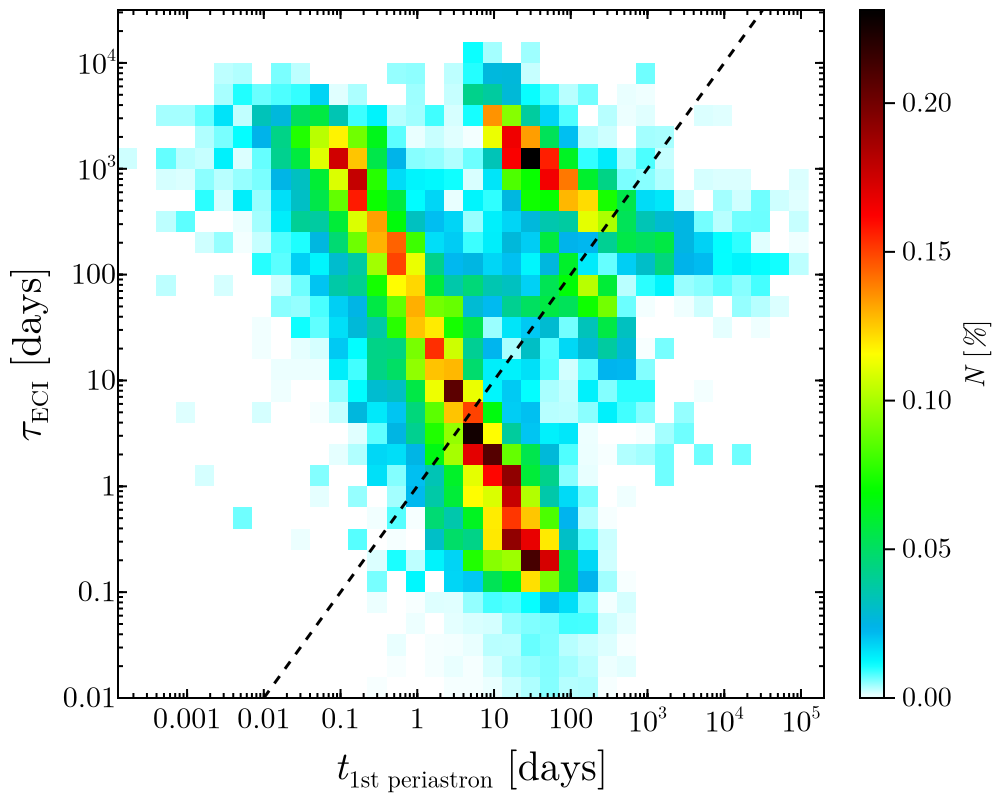

In [26]:
dxb = 0.25
dyb = 0.20

xmin = 10^-3.9
ymin = 0.01
xbins= log10(xmin):dxb:5.2
ybins= log10(ymin):dyb:5.9

mycmap = cgrad([:white, :cyan, :deepskyblue2, :green1, :yellow, :red,  :black], 
                [0,      0.05,   0.1,    0.3,     0.5,  0.7,       1])
plot_boundaries = (tau_periastron .> xmin) .&& (tau_ECI .> ymin)
fff = select_sne .&&  plot_boundaries

@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

logticks = [ k  for j in -5:1:5 for k in  10. ^j:10. ^j:10. ^(j+1) ]
ticks = ([     -3,     -2,    -1,   0,    1,     2,      3,      4,      5], 
         ["0.001", "0.01", "0.1", "1", "10", "100", L"10^3", L"10^4", L"10^5"])
FIGURE = Figure(size=(500,400), figure_padding = 5)
grid = GridLayout(FIGURE[1,1])
ax1 = plot_settings(grid[1:10, 1:10]; 
            xlabel=L"t_\mathrm{1st \ periastron} \ [\mathrm{days}]",
            ylabel=L"\tau_\mathrm{ECI} \ [\mathrm{days}]", 
            title =" ", ymticks = log10.(logticks), xmticks=log10.(logticks),
            yticks=ticks, xticks=ticks
            )

hm = sn_heatmap(ax1, log10.(tau_periastron[fff]), log10.(tau_ECI[fff]), pdfs[fff], xbins, ybins;
               cmap=mycmap, print_data=true)

Colorbar(FIGURE[1,2], hm, label=L"N \ [%]")
lines!(ax1, [-10, 10], [-10,10], color = :black, linestyle=:dash)

xlims!(ax1, log10(xmin), 5.3)
ylims!(ax1, log10(ymin), 4.5)

save_directory = "../output/ECI/"
outfilename = @sprintf("map_taus_all_%s.pdf", KICKS)
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png


FIGURE


The data in this plot affects 7.920 % of all CCSNe
Weights: min=3.418e-04, max=1.045e-01, min/max=3.270e-03


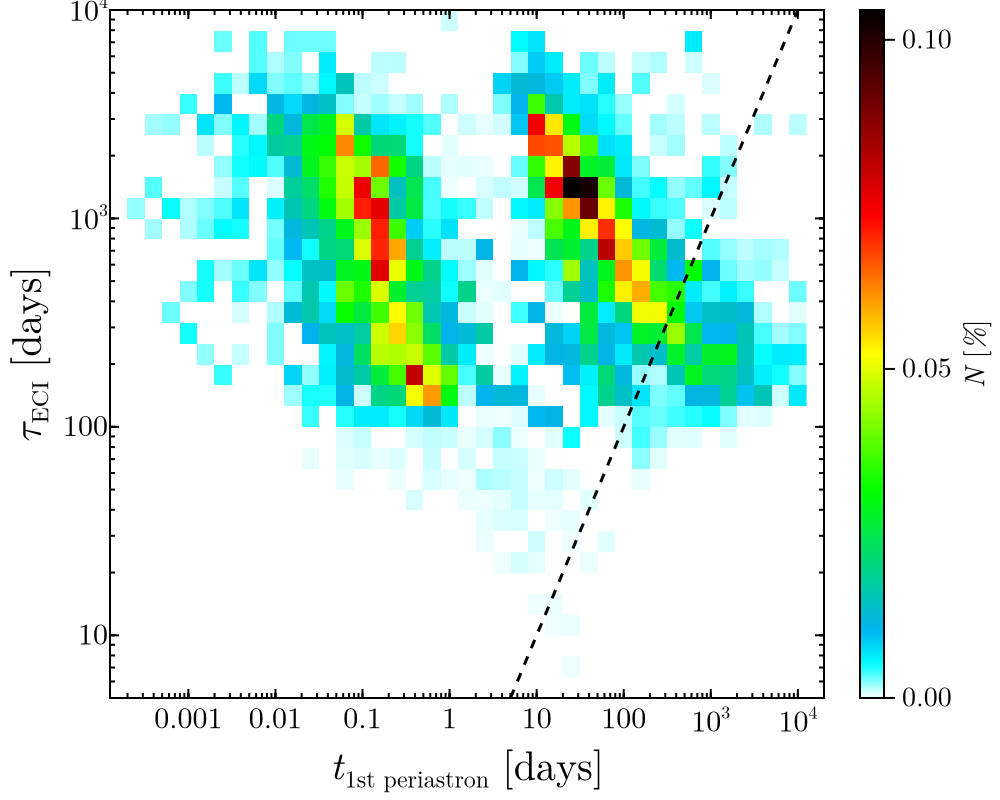

In [33]:
dxb = 0.2
dyb = 0.1

xmin = 10^-3.9
ymin = 5
xbins= log10(xmin):dxb:4.2
ybins= log10(ymin):dyb:5.9

mycmap = cgrad([:white, :cyan, :deepskyblue2, :green1, :yellow, :red,  :black], 
                [0,      0.05,   0.1,    0.3,     0.5,  0.7,       1])

plot_boundaries = (tau_periastron .> xmin) .&& (tau_ECI .> ymin)
fff = ECI .&&  plot_boundaries

@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

logticks = [ k  for j in -5:1:5 for k in  10. ^j:10. ^j:10. ^(j+1) ]
ticks = ([     -3,     -2,    -1,   0,    1,     2,      3,      4,      5], 
         ["0.001", "0.01", "0.1", "1", "10", "100", L"10^3", L"10^4", L"10^5"])
FIGURE = Figure(size=(500,400), figure_padding = 5)
grid = GridLayout(FIGURE[1,1])
ax1 = plot_settings(grid[1:10, 1:10]; 
            xlabel=L"t_\mathrm{1st \ periastron} \ [\mathrm{days}]",
            ylabel=L"\tau_\mathrm{ECI} \ [\mathrm{days}]", 
            title =" ", ymticks = log10.(logticks), xmticks=log10.(logticks),
            yticks=ticks, xticks=ticks
            )


hm = sn_heatmap(ax1, log10.(tau_periastron[fff]), log10.(tau_ECI[fff]), pdfs[fff], xbins, ybins;
               cmap=mycmap, print_data=true)

Colorbar(FIGURE[1,2], hm, label=L"N \ [%]")
lines!(ax1, [-3, 10], [-3,10], color = :black, linestyle=:dash)

xlims!(ax1, log10(xmin), 4.3)
ylims!(ax1, log10(ymin), 4)

save_directory = "../output/ECI/"
outfilename = @sprintf("map_taus_ECI_%s.pdf", KICKS)
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png

FIGURE


The data in this plot ^ affects 5.639 % of all CCSNe
The data in this plot v affects 1.490 % of all CCSNe
Weights: min=3.418e-04, max=1.721e-01, min/max=1.986e-03
Weights: min=3.418e-04, max=1.161e-01, min/max=2.943e-03


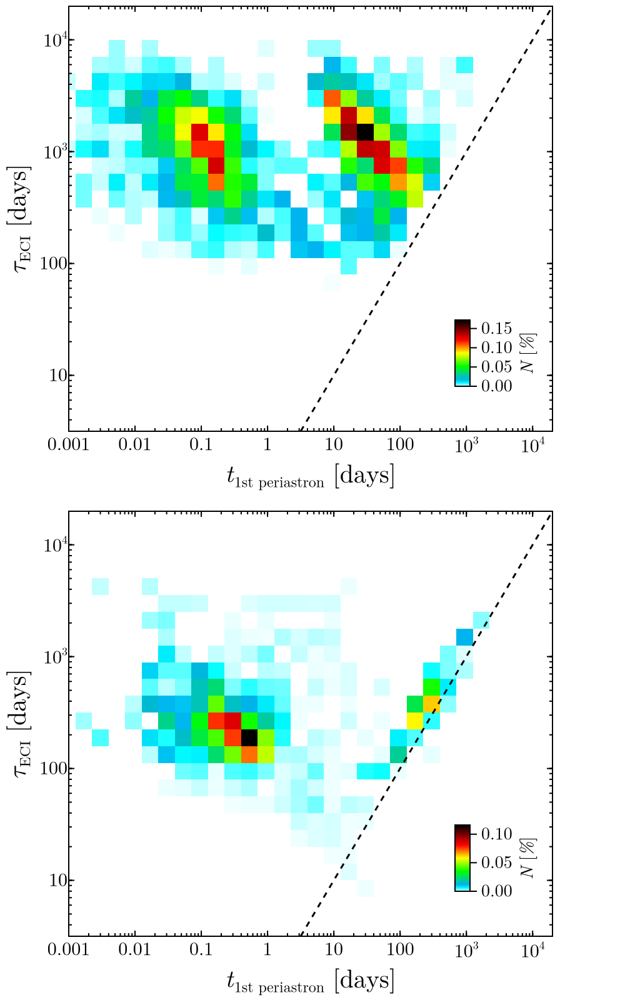

In [34]:
dxb = 0.25
dyb = 0.15
xbins=-3.9:dxb:4.2
ybins=-0.5:dyb:5.9

mycmap = cgrad([:white, :cyan, :deepskyblue2, :green1, :yellow, :red,  :black], 
                [0,      0.05,   0.1,    0.3,     0.5,  0.7,       1])

fff_b = (ECI) .&& (n_passages .> 1)   .&& (tau_periastron .>= 0.001)
fff_u = (ECI) .&& (n_passages .== 1)  .&& (tau_periastron .>= 0.001)

@printf("The data in this plot ^ affects %.3f %% of all CCSNe\n", sum(pdfs[fff_b]))
@printf("The data in this plot v affects %.3f %% of all CCSNe\n", sum(pdfs[fff_u]))

logticks = [ k  for j in -5:1:5 for k in  10. ^j:10. ^j:10. ^(j+1) ]
ticks = ([     -3,     -2,    -1,   0,    1,     2,      3,      4,      5], 
         ["0.001", "0.01", "0.1", "1", "10", "100", L"10^3", L"10^4", L"10^5"])
FIGURE = Figure(size=(500,800), figure_padding = 5)
grid1 = GridLayout(FIGURE[1,1])
ax1 = plot_settings(grid1[1:10, 1:10]; 
            xlabel=L"t_\mathrm{1st \ periastron} \ [\mathrm{days}]",
            ylabel=L"\tau_\mathrm{ECI} \ [\mathrm{days}]", 
            title =" ", ymticks = log10.(logticks), xmticks=log10.(logticks),
            yticks=ticks, xticks=ticks
            )
grid2 = GridLayout(FIGURE[2,1])
ax2 = plot_settings(grid2[1:10, 1:10]; 
            xlabel=L"t_\mathrm{1st \ periastron} \ [\mathrm{days}]",
            ylabel=L"\tau_\mathrm{ECI} \ [\mathrm{days}]", 
            title =" ", ymticks = log10.(logticks), xmticks=log10.(logticks),
            yticks=ticks, xticks=ticks
            )


hm1 = sn_heatmap(ax1, log10.(tau_periastron[fff_b]), log10.(tau_ECI[fff_b]), pdfs[fff_b], xbins, ybins;
               cmap=mycmap, print_data=true)
hm2 = sn_heatmap(ax2, log10.(tau_periastron[fff_u]), log10.(tau_ECI[fff_u]), pdfs[fff_u], xbins, ybins;
               cmap=mycmap, print_data=true)

Colorbar(grid1[8:9,7:10], hm1, label=L"N \ [%]")
Colorbar(grid2[8:9,7:10], hm2, label=L"N \ [%]")
lines!(ax1, [-1, 10], [-1,10], color = :black, linestyle=:dash)
lines!(ax2, [-1, 10], [-1,10], color = :black, linestyle=:dash)

xlims!(ax1, -3, 4.3)
ylims!(ax1, 0.5, 4.3)
xlims!(ax2, -3, 4.3)
ylims!(ax2, 0.5, 4.3)

save_directory = "../output/ECI/"
outfilename = @sprintf("map_taus_ECI_b_vs_ub_%s.pdf", KICKS)
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png


FIGURE


### (s) corner plots

The data in this plot affects 6.628 % of all CCSNe
Weights: min=3.418e-04, max=2.527e-01, min/max=1.353e-03


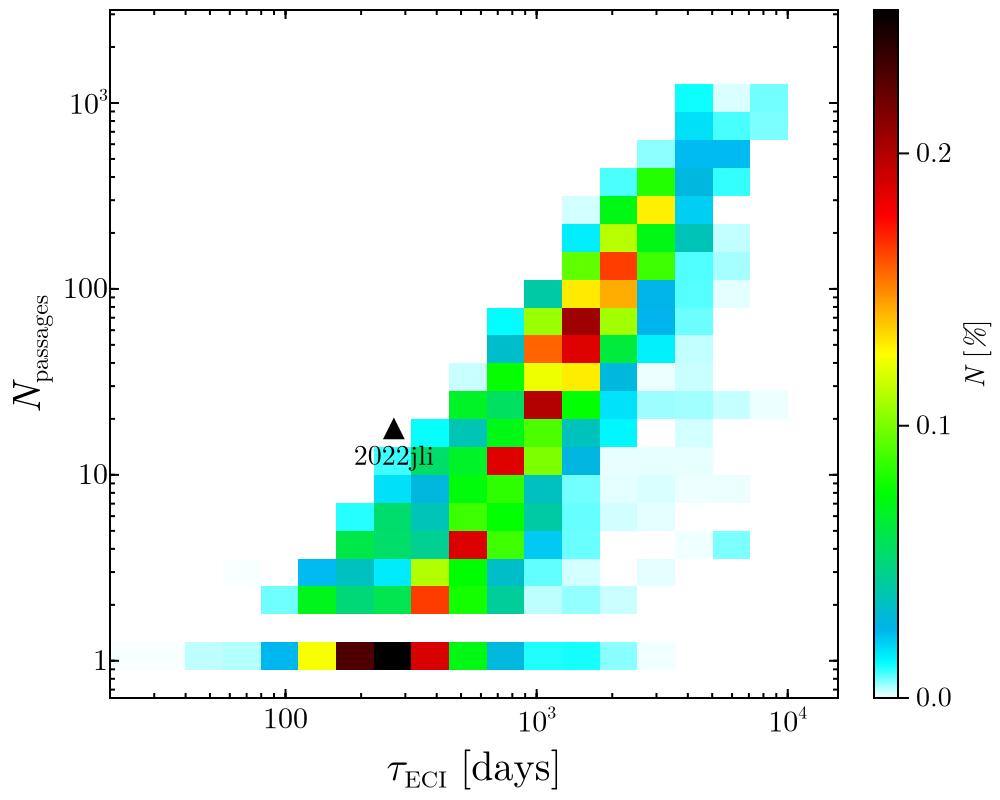

In [39]:
mycmap = cgrad([:white, :cyan, :deepskyblue2, :green1, :yellow, :red,  :black], 
                [0,      0.05,   0.1,    0.3,     0.5,  0.7,       1])


dxb = 0.15
dyb = 0.15

xmin = 20
ymin = 10 ^ -0.2
xbins=log10(xmin):dxb:5.9
ybins=log10(ymin):dyb:5.9


plot_boundaries = (n_passages .> ymin) .&& (tau_ECI .> xmin)

fff = (ECI) .&& (post_SN_orbit .== :bound) .&& (tau_ECI .> tau_periastron) .&& plot_boundaries

@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

logticks = [ k  for j in -5:1:5 for k in  10. ^j:10. ^j:10. ^(j+1) ]
ticks = ([     -3,     -2,    -1,   0,    1,     2,      3,      4,      5], 
         ["0.001", "0.01", "0.1", "1", "10", "100", L"10^3", L"10^4", L"10^5"])
FIGURE = Figure(size=(500,400), figure_padding = 5)
grid = GridLayout(FIGURE[1,1])
ax1 = plot_settings(grid[1:10, 1:10]; 
            ylabel=L"N_\mathrm{passages}",
            xlabel=L"\tau_\mathrm{ECI} \ [\mathrm{days}]", 
            title =" ", ymticks = log10.(logticks), xmticks=log10.(logticks),
            yticks=ticks, xticks=ticks
            )


hm = sn_heatmap(ax1, log10.(tau_ECI[fff]), log10.(n_passages[fff]), pdfs[fff], xbins, ybins;
               cmap=mycmap, print_data=true)

Colorbar(FIGURE[1,2], hm, label=L"N \ [%]")

scatter!(ax1, [log10.(270)], [log10.(17)], color = :black, markersize=15, marker=:utriangle, label=L"SN\,2022jli")
text!( [(log10.(270), log10.(15))],  text= "2022jli", align=(:center, :top))

xlims!(ax1, log10(xmin), 4.2)
ylims!(ax1, log10(ymin), 3.5)

save_directory = "../output/ECI/"
outfilename = @sprintf("map_tau_Npass_%s.pdf", KICKS)
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png

FIGURE


The data in this plot affects 6.628 % of all CCSNe
Weights: min=3.418e-04, max=2.624e-01, min/max=1.303e-03


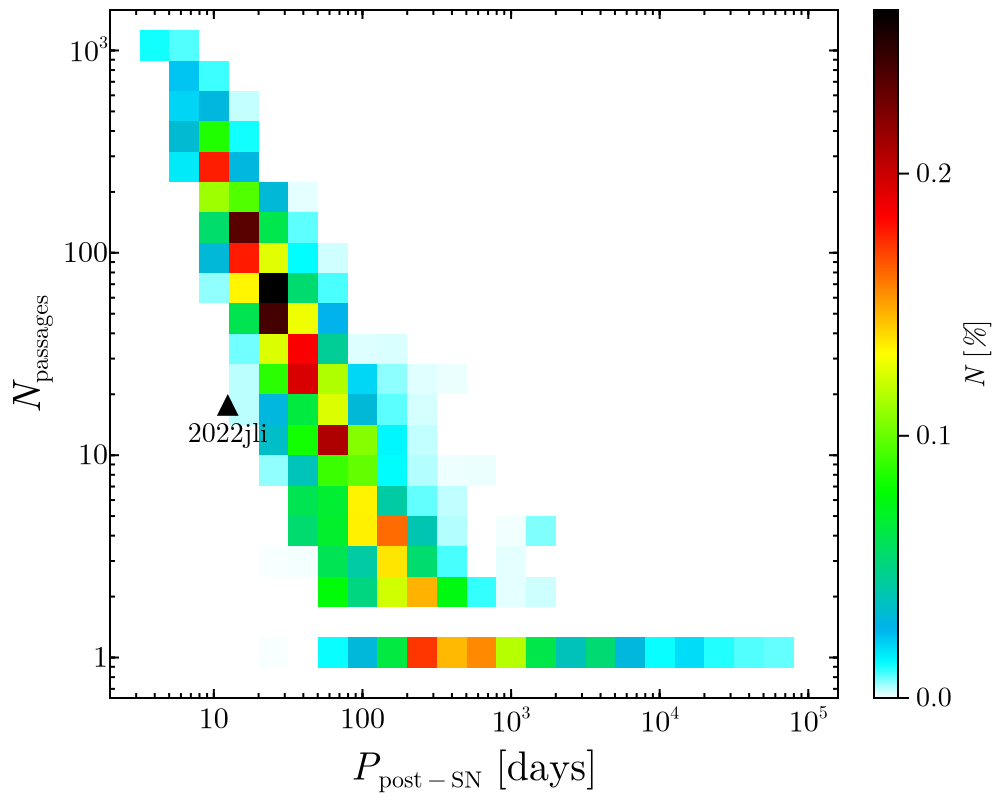

In [49]:
dxb = 0.20
dyb = 0.15

xmin =2
ymin = 10 ^ -0.2
xbins=log10(xmin):dxb:5.2
ybins=log10(ymin):dyb:5.9


plot_boundaries = (n_passages .> ymin) .&& (P_postSN .> xmin)

fff = (ECI) .&& (post_SN_orbit .== :bound) .&& (tau_ECI .> tau_periastron) .&& plot_boundaries

@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

logticks = [ k  for j in -5:1:5 for k in  10. ^j:10. ^j:10. ^(j+1) ]
ticks = ([     -3,     -2,    -1,   0,    1,     2,      3,      4,      5], 
         ["0.001", "0.01", "0.1", "1", "10", "100", L"10^3", L"10^4", L"10^5"])
FIGURE = Figure(size=(500,400), figure_padding = 5)
grid = GridLayout(FIGURE[1,1])
ax1 = plot_settings(grid[1:10, 1:10]; 
            ylabel=L"N_\mathrm{passages}",
            xlabel=L"P_\mathrm{post-SN} \ [\mathrm{days}]", 
            title =" ", ymticks = log10.(logticks), xmticks=log10.(logticks),
            yticks=ticks, xticks=ticks
            )


hm = sn_heatmap(ax1, log10.(P_postSN[fff]), log10.(n_passages[fff]), pdfs[fff], xbins, ybins;
               cmap=mycmap, print_data=true)

Colorbar(FIGURE[1,2], hm, label=L"N \ [%]")

scatter!(ax1, [log10.(12.4)], [log10.(17)], color = :black, markersize=15, marker=:utriangle, label=L"SN\,2022jli")
text!( [(log10.(12.4), log10.(15))],  text= "2022jli", align=(:center, :top))
xlims!(ax1, log10(xmin), 5.2)
ylims!(ax1, log10(ymin), 3.2)

save_directory = "../output/ECI/"
outfilename = @sprintf("map_PpostSN_Npass_%s.pdf", KICKS)
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png

FIGURE


The data in this plot affects 6.648 % of all CCSNe
Weights: min=4.666e-04, max=2.067e-01, min/max=2.257e-03


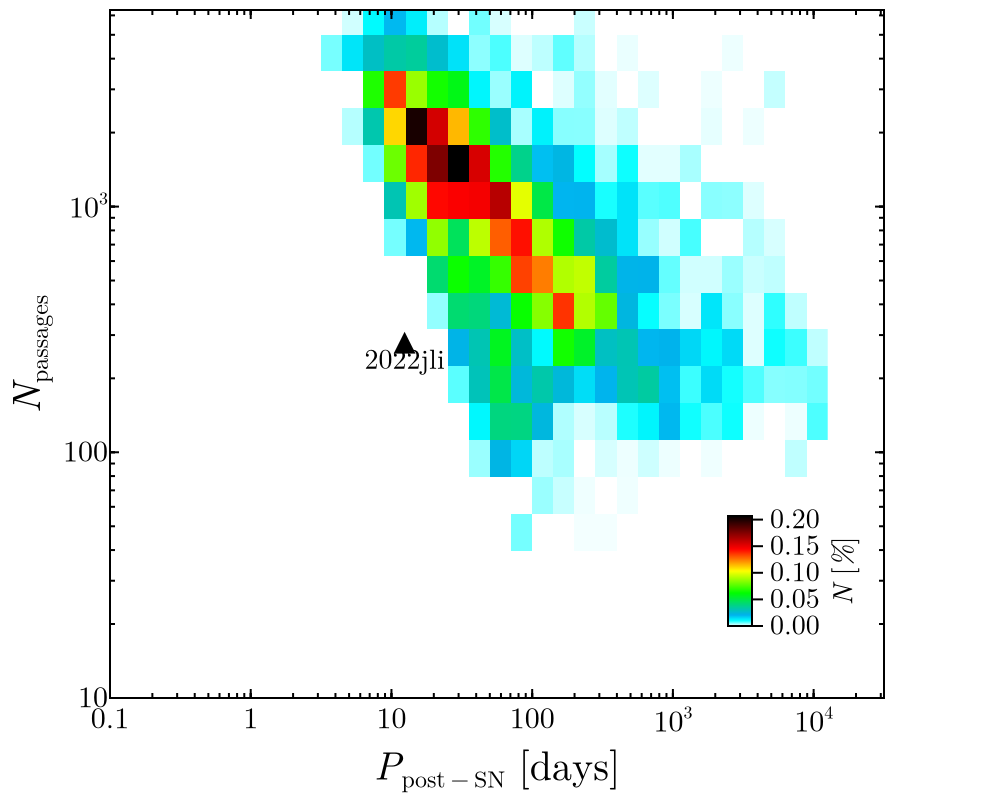

In [61]:
dxb = 0.15
dyb = 0.15

xmin = 10 ^ -1
ymin = 10 ^ 1
xbins=log10(xmin):dxb:4.2
ybins=log10(ymin):dyb:5.9


plot_boundaries = (tau_ECI .> ymin) .&& (P_postSN .> xmin)

fff = (ECI) .&& (post_SN_orbit .== :bound) .&& (tau_ECI .> tau_periastron) .&& plot_boundaries

@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

logticks = [ k  for j in -5:1:5 for k in  10. ^j:10. ^j:10. ^(j+1) ]
ticks = ([     -3,     -2,    -1,   0,    1,     2,      3,      4,      5], 
         ["0.001", "0.01", "0.1", "1", "10", "100", L"10^3", L"10^4", L"10^5"])
FIGURE = Figure(size=(500,400), figure_padding = 5)
grid = GridLayout(FIGURE[1,1])
ax1 = plot_settings(grid[1:10, 1:10]; 
            ylabel=L"N_\mathrm{passages}",
            xlabel=L"P_\mathrm{post-SN} \ [\mathrm{days}]", 
            title =" ", ymticks = log10.(logticks), xmticks=log10.(logticks),
            yticks=ticks, xticks=ticks
            )


hm = sn_heatmap(ax1, log10.(P_postSN[fff]), log10.(tau_ECI[fff]), pdfs[fff], xbins, ybins;
               cmap=mycmap, print_data=true)

Colorbar(grid[8:9,7:10], hm, label=L"N \ [%]")

scatter!(ax1, [log10.(12.4)], [log10.(270)], color = :black, markersize=15, marker=:utriangle, label=L"SN\,2022jli")
text!( [(log10.(12.4), log10.(270))],  text= "2022jli", align=(:center, :top))
xlims!(ax1, log10(xmin), 4.5)
ylims!(ax1, log10(ymin), 3.8)

save_directory = "../output/ECI/"
outfilename = @sprintf("map_PpostSN_taueci_%s.pdf", KICKS)
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png

FIGURE


### corner plots

The data in this plot affects 2.466 % of all CCSNe
Weights: min=3.888e-02, max=1.081e+01, min/max=3.598e-03
Weights: min=1.530e-02, max=7.799e+00, min/max=1.962e-03
Weights: min=1.530e-02, max=9.124e+00, min/max=1.677e-03


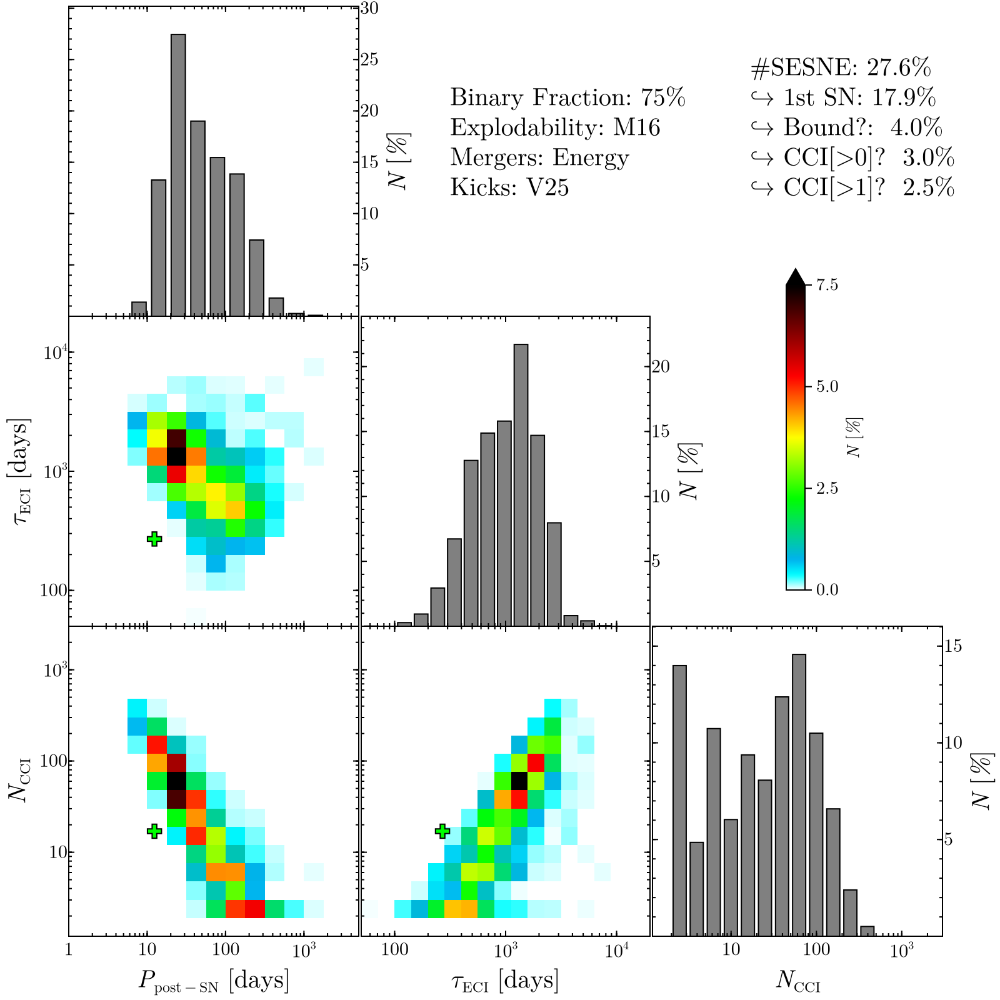

In [197]:
# include("/vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/JuliaScripts/Plot_defs.jl")


mycmap = cgrad([:white, :cyan, :deepskyblue2, :green1, :yellow, :red,  :black], 
                [0,      0.05,   0.1,    0.3,     0.5,  0.7,       1])
dxb = 0.15
dyb = 0.15

fff = (ECI) .&& (post_SN_orbit .== :bound) .&& (tau_ECI .> tau_periastron) .&& (n_passages .> 1)
@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

mticks = [ k  for j in -5:1:5 for k in  10. ^j:10. ^j:10. ^(j+1) ]
ticks = ([0.001,  0.01,   0.1,   1.,  10.,  100.,  1000.,     1e4,     1e5], 
        ["0.001", "0.01", "0.1", "1", "10", "100", L"10^3", L"10^4", L"10^5"])
logticks = ([     -3.,     -2.,    -1.,   0.,    1.,     2.,      3.,      4,      5], 
        ["0.001", "0.01", "0.1", "1", "10", "100", L"10^3", L"10^4", L"10^5"])

FIGURE = Figure(size=(800,800), figure_padding = 5)
grid = GridLayout(FIGURE[0:10,0:10])
ax = Dict()
val_range = Dict("P"=>[1e0,5e3], "T"=>[50,2e4], "N"=>[1.2,3e3])
dbins     = Dict("P"=>.25, "T"=>.15, "N"=>.20)
vals      = Dict("P" => P_postSN[fff], 
                 "T"=>tau_ECI[fff], 
                 "N"=>n_passages[fff], 
                 "pdf"=>pdfs[fff]/sum(pdfs[fff]) *100 )
SN2022jli = Dict("P"=>12.4, "T"=>270, "N"=>17)
positions = Dict("P"=>1, "T"=>2, "N"=>3)
labels    = Dict("P"=>L"P_\mathrm{post-SN} \ [\mathrm{days}]",
                 "T"=>L"\tau_\mathrm{ECI} \ [\mathrm{days}]",
                 "N"=>L"N_\mathrm{CCI}")

for cornerplot in ["PN", "TN", "PT"]
        x=""*cornerplot[1]
        y=""*cornerplot[2]
        ax[cornerplot] = plot_settings(grid[positions[y],positions[x]]; 
                ylabel=labels[y],
                xlabel=labels[x], 
                title =" ", ymticks = log10.(mticks), xmticks=log10.(mticks),
                yticks=logticks, xticks=logticks,
                xlabelvisible = positions[y]==3,
                xticklabelsvisible = positions[y]==3,
                ylabelvisible = positions[x]==1,
                yticklabelsvisible = positions[x]==1
                )
end
for h in ["P", "N", "T"]
        ax[h*h] = plot_settings(grid[positions[h],positions[h]]; 
                ylabel=L"N \ [%]", 
                xlabel=labels[h], 
                title =" ",xmticks=(mticks), xscale=log10,
                xticks= ticks, yaxisposition=:right,
                xlabelvisible = positions[h]==3,
                xticklabelsvisible = positions[h]==3,
                yticks=5:5:100,
                ymticks=1:1:100
                )
end

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_crit = Dict(occursin("Valli", KICKS) => "V25", occursin("M16", KICKS)=>"M16", occursin("DM25", KICKS)=>"DM25",occursin("COMBINE", KICKS)=>"K18")[true]
simulation_settings = @sprintf("Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\nKicks: %s", f_B*100, exp_crit, mer_crit, kick_crit)

text!(FIGURE.scene, (.45, .80), text = simulation_settings, fontsize = 20, space = :relative)

fff_sne = (SNe .== :Ibc) .|| (SNe .== :Ibn)
fff_first_sn = fff_sne .&& sn1 .&& (prgs .!= "M" .|| occursin.("NI",prgs))
fff_bound = fff_first_sn .&& post_SN_orbit .== :bound
fff_canCCI = fff_bound .&& ECI .&& (tau_ECI .> tau_periastron)
fff_CCI_multiple = fff_canCCI .&& (n_passages .> 1)
important_data = @sprintf("#SESNE: %4.1f%%\n↪ 1st SN: %4.1f%%\n↪ Bound?: %4.1f%%\n↪ CCI[>0]? %4.1f%%\n↪ CCI[>1]? %4.1f%%", 
                sum(pdfs[fff_sne]),
                sum(pdfs[fff_first_sn]),
                sum(pdfs[fff_bound]),
                sum(pdfs[fff_canCCI]),
                sum(pdfs[fff_CCI_multiple]),
                )
text!(FIGURE.scene, (.75, .80), text = important_data, fontsize = 20, space = :relative)

                
for cornerplot in ["PN", "TN", "PT"]
        xlab = ""*cornerplot[1]
        ylab = ""*cornerplot[2]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        ymin = val_range[ylab][1]
        ymax = val_range[ylab][2]
        dxb = dbins[xlab]
        dyb = dbins[ylab]

        xbins=log10(xmin):dxb:log10(xmax)
        ybins=log10(ymin):dyb:log10(ymax)

        x = log10.(vals[xlab])
        y = log10.(vals[ylab])
        
    # plot_boundaries = (n_passages .> ymin) .&& (tau_ECI .> xmin)

        hm = sn_heatmap(ax[cornerplot], x, y, vals["pdf"], xbins, ybins; colorrange=[0,7.5],
                cmap=mycmap, print_data=true, highclip=:black)

        scatter!(ax[cornerplot], [log10.(SN2022jli[xlab])], [log10.(SN2022jli[ylab])],
                      color = :lime, strokecolor = :black, strokewidth=1, markersize=15, marker=:+, label=L"SN\,2022jli")
        text!([log10.(SN2022jli[xlab])], [log10.(SN2022jli[ylab])], 
              text= "2022jli", align=(:center, :top))

        xlims!(ax[cornerplot], log10(xmin), log10(xmax))
        ylims!(ax[cornerplot], log10(ymin), log10(ymax))

end


for histogram in ["PP", "TT", "NN"]
        xlab = ""*histogram[1]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        dxb = dbins[xlab]

        xbins=log10(xmin):dxb:log10(xmax)
        x = (vals[xlab])
        xlims!(ax[histogram], xmin, xmax)
        bins, y_bins = run_histogram(ax[histogram], x, vals["pdf"], xbins, dxb*1.25, datascale=log10, norm=1)
        ylims!(ax[histogram], 0, maximum(y_bins)*1.1)

end
Colorbar(FIGURE[3:6,9], hm, label=L"N \ [%]",size = 15)
colgap!(grid, -39)
rowgap!(grid,0)

save_directory = "../output/ECI/"
outfilename = @sprintf("cornerplot_CECI_%s_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT, KICKS)
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png

FIGURE


The data in this plot affects 6.611 % of all CCSNe
Weights: min=2.004e-02, max=7.137e+00, min/max=2.807e-03
Weights: min=1.468e-02, max=3.902e+00, min/max=3.763e-03
Weights: min=3.719e-02, max=7.591e+00, min/max=4.899e-03
Weights: min=1.468e-02, max=6.044e+00, min/max=2.429e-03
Weights: min=1.468e-02, max=8.469e+00, min/max=1.734e-03
Weights: min=9.211e-03, max=2.941e+00, min/max=3.132e-03
Weights: min=2.004e-02, max=5.802e+00, min/max=3.453e-03
Weights: min=1.468e-02, max=5.425e+00, min/max=2.706e-03
Weights: min=9.211e-03, max=5.648e+00, min/max=1.631e-03
Weights: min=1.257e-02, max=2.547e+00, min/max=4.936e-03
Weights: min=2.004e-02, max=3.060e+00, min/max=6.548e-03
Weights: min=2.004e-02, max=4.701e+00, min/max=4.262e-03
Weights: min=1.715e-02, max=3.495e+00, min/max=4.908e-03
Weights: min=1.715e-02, max=5.845e+00, min/max=2.934e-03
Weights: min=2.340e-02, max=1.243e+01, min/max=1.883e-03


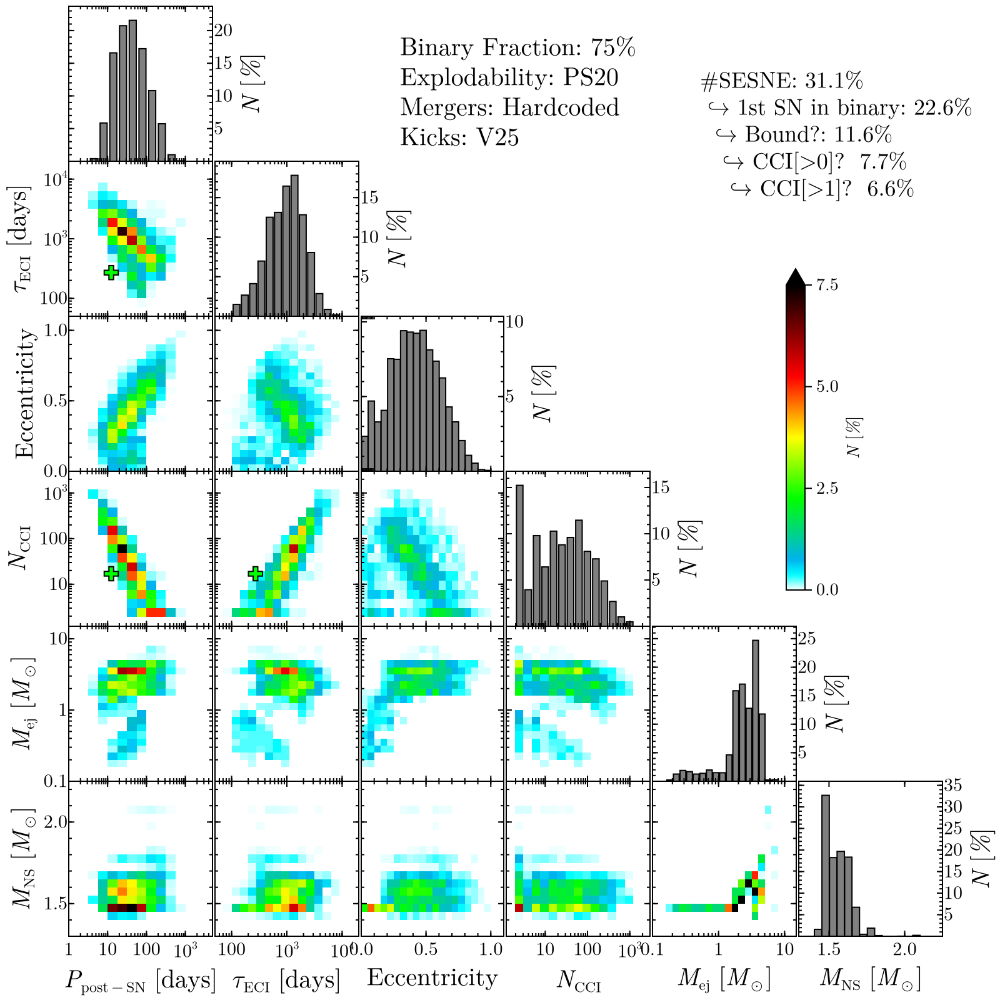

In [147]:
Mend = POPSYNTH.seqdata_MODELS("M_end", mod_names, MODELS, full_output=false)
M_b_ns = POPSYNTH.seqdata_MODELS("M_remnant_b", mod_names, MODELS, full_output=false)
M_g_ns = POPSYNTH.seqdata_MODELS("M_remnant_g", mod_names, MODELS, full_output=false)
Mej = Mend .- M_b_ns


mycmap = cgrad([:white, :cyan, :deepskyblue2, :green1, :yellow, :red,  :black], 
                [0,      0.05,   0.1,    0.3,     0.5,  0.7,       1])

fff = (ECI) .&& (post_SN_orbit .== :bound) .&& (tau_ECI .> tau_periastron) .&& (n_passages .> 1)
@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

mlogticks = [ k  for j in -5:1:5 for k in  10. ^j:10. ^j:10. ^(j+1) ]
mlinticks = 0:0.1:100
ticks = ([0.001,  0.01,   0.1,   1.,  10.,  100.,  1000.,     1e4,     1e5], 
        ["0.001", "0.01", "0.1", "1", "10", "100", L"10^3", L"10^4", L"10^5"])
logticks = ([     -3.,     -2.,    -1.,   0.,    1.,     2.,      3.,      4,      5], 
        ["0.001", "0.01", "0.1", "1", "10", "100", L"10^3", L"10^4", L"10^5"])
linticks = 0:0.5:100

FIGURE = Figure(size=(800,800), figure_padding = 5)
grid = GridLayout(FIGURE[0:10,0:10])
ax = Dict()
val_range = Dict("P"=>[1e0,5e3], 
                 "T"=>[50,2e4], 
                 "N"=>[1.2,3e3],
                 "e"=>[0.,1.1],
                 "J"=>[0.1,15],
                 "S"=>[1.3,2.25],)
val_scale = Dict("P"=>log10,
                 "T"=>log10, "N"=>log10, "e"=>identity,
                 "J"=>log10, "S"=>identity)
dbins     = Dict("P"=>.25, "T"=>.15, "N"=>.20, "J"=>0.1, "S"=>0.05, "e"=>0.05)
vals      = Dict("P" => P_postSN[fff], 
                 "T"=>tau_ECI[fff], 
                 "N"=>n_passages[fff], 
                 "J"=>Mej[fff],
                 "S"=>M_b_ns[fff],
                 "pdf"=>pdfs[fff]/sum(pdfs[fff]) *100,
                 "e"=>eccentricity[fff])
SN2022jli = Dict("P"=>12.4, "T"=>270, "N"=>17, "J"=>NaN, "S"=>NaN, "e"=>NaN)
labels    = Dict("P"=>L"P_\mathrm{post-SN} \ [\mathrm{days}]",
                 "T"=>L"\tau_\mathrm{ECI} \ [\mathrm{days}]",
                 "N"=>L"N_\mathrm{CCI}",
                 "J"=>L"M_\mathrm{ej} \ [M_\odot]",
                 "S"=>L"M_\mathrm{NS} \ [M_\odot]",
                 "e"=>"Eccentricity")

#ptjsn
variables    = ["P", "T", "e", "N", "J", "S"]
positions = Dict()
for k in range(1,length(variables)) 
        positions[variables[k]] = k  
end
cornerplots  = [variables[i]*variables[j]
                        for i in 1:length(variables) 
                        for j in (i+1):length(variables)
                ]
for cornerplot in cornerplots
        x=""*cornerplot[1]
        y=""*cornerplot[2]
        ax[cornerplot] = plot_settings(grid[positions[y],positions[x]]; 
                ylabel=labels[y],
                xlabel=labels[x], 
                title =" ", 
                ymticks = val_scale[y] == log10 ? val_scale[y].(mlogticks) : mlinticks, 
                xmticks = val_scale[x] == log10 ? val_scale[x].(mlogticks) : mlinticks, 
                yticks  = val_scale[y] == log10 ? logticks  : linticks,
                xticks  = val_scale[x] == log10 ? logticks  : linticks,
                xlabelvisible = positions[y]==length(variables),
                xticklabelsvisible = positions[y]==length(variables),
                ylabelvisible = positions[x]==1,
                yticklabelsvisible = positions[x]==1
                )
end
for h in variables
        ax[h] = plot_settings(grid[positions[h],positions[h]]; 
                ylabel=L"N \ [%]", 
                xlabel=labels[h], 
                title =" ",xmticks=(mlogticks), 
                xscale=val_scale[h],
                xticks  = val_scale[h] == log10 ? ticks  : linticks,
                yaxisposition=:right,
                xlabelvisible = positions[h]==length(variables),
                xticklabelsvisible = positions[h]==length(variables),
                yticks=5:5:100,
                ymticks=1:1:100
                )
end

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_crit = Dict(occursin("Valli", KICKS) => "V25", occursin("M16", KICKS)=>"M16", occursin("DM25", KICKS)=>"DM25",occursin("COMBINE", KICKS)=>"K18", KICKS=="None"=>"None")[true]
simulation_settings = @sprintf("Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\nKicks: %s", f_B*100, exp_crit, mer_crit, kick_crit)

text!(FIGURE.scene, (.40, .85), text = simulation_settings, fontsize = 20, space = :relative)

fff_sne = (SNe .== :Ibc) .|| (SNe .== :Ibn)
fff_first_sn = fff_sne .&& sn1 .&& .! (prgs .== "M" .|| prgs .== "NI-S")
fff_bound = fff_first_sn .&& post_SN_orbit .== :bound
fff_canCCI = fff_bound .&& ECI .&& (tau_ECI .> tau_periastron)
fff_CCI_multiple = fff_canCCI .&& (n_passages .> 1)
important_data = @sprintf(
"#SESNE: %4.1f%%
 ↪ 1st SN in binary: %4.1f%%
  ↪ Bound?: %4.1f%%
   ↪ CCI[>0]? %4.1f%%
    ↪ CCI[>1]? %4.1f%%", 
                sum(pdfs[fff_sne]),
                sum(pdfs[fff_first_sn]),
                sum(pdfs[fff_bound]),
                sum(pdfs[fff_canCCI]),
                sum(pdfs[fff_CCI_multiple]),
                )
text!(FIGURE.scene, (.70, .80), text = important_data, fontsize = 18, space = :relative)

hm = nothing           
for cornerplot in cornerplots
        xlab = ""*cornerplot[1]
        ylab = ""*cornerplot[2]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        ymin = val_range[ylab][1]
        ymax = val_range[ylab][2]
        dxb = dbins[xlab]
        dyb = dbins[ylab]
        scalex = val_scale[xlab]
        scaley = val_scale[ylab]

        xbins=scalex(xmin):dxb:scalex(xmax)
        ybins=scaley(ymin):dyb:scaley(ymax)

        x = scalex.(vals[xlab])
        y = scaley.(vals[ylab])
        
    # plot_boundaries = (n_passages .> ymin) .&& (tau_ECI .> xmin)

        hm = sn_heatmap(ax[cornerplot], x, y, vals["pdf"], xbins, ybins; colorrange=[0,7.5],
                cmap=mycmap, print_data=true, highclip=:black)

        scatter!(ax[cornerplot], [scalex.(SN2022jli[xlab])], [scaley.(SN2022jli[ylab])],
                      color = :lime, strokecolor = :black, strokewidth=1, markersize=15, marker=:+, label=L"SN\,2022jli")
        text!([scalex.(SN2022jli[xlab])], [scaley.(SN2022jli[ylab])], 
              text= "2022jli", align=(:center, :top))

        xlims!(ax[cornerplot], scalex(xmin), scalex(xmax))
        ylims!(ax[cornerplot], scaley(ymin), scaley(ymax))

end


for histogram in variables
        xlab = ""*histogram[1]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        dxb = dbins[xlab]
        scalex = val_scale[xlab]
        xbins=scalex(xmin):dxb:scalex(xmax)
        x = (vals[xlab])
        xlims!(ax[histogram], xmin, xmax)
        bins, y_bins = run_histogram(ax[histogram], x, vals["pdf"], xbins, dxb * (scalex==log10 ? 1.25 : 1.1), datascale=scalex, norm=1)
        ylims!(ax[histogram], 0, maximum(y_bins)*1.1)

end
Colorbar(FIGURE[3:6,9], hm, label=L"N \ [%]",size = 15)
colgap!(grid, -39)
rowgap!(grid,0)

save_directory = "../output/ECI/"
outfilename = @sprintf("cornerplot_CECI_%s_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT, KICKS)
save(save_directory*outfilename, FIGURE)

FIGURE


The data in this plot affects 0.797 % of all CCSNe
Weights: min=5.153e-01, max=1.336e+01, min/max=3.857e-02
Weights: min=3.233e-01, max=9.276e+00, min/max=3.485e-02
Weights: min=5.153e-01, max=1.713e+01, min/max=3.008e-02
Weights: min=5.153e-01, max=1.494e+01, min/max=3.449e-02
Weights: min=5.153e-01, max=2.618e+01, min/max=1.968e-02
Weights: min=3.233e-01, max=5.245e+00, min/max=6.163e-02
Weights: min=4.411e-01, max=1.336e+01, min/max=3.302e-02
Weights: min=3.233e-01, max=9.085e+00, min/max=3.558e-02
Weights: min=5.153e-01, max=1.580e+01, min/max=3.262e-02
Weights: min=3.233e-01, max=5.879e+00, min/max=5.499e-02
Weights: min=2.767e-01, max=6.976e+00, min/max=3.967e-02
Weights: min=3.233e-01, max=2.382e+01, min/max=1.357e-02
Weights: min=3.233e-01, max=6.898e+00, min/max=4.686e-02
Weights: min=5.153e-01, max=1.924e+01, min/max=2.678e-02
Weights: min=5.153e-01, max=2.036e+01, min/max=2.531e-02


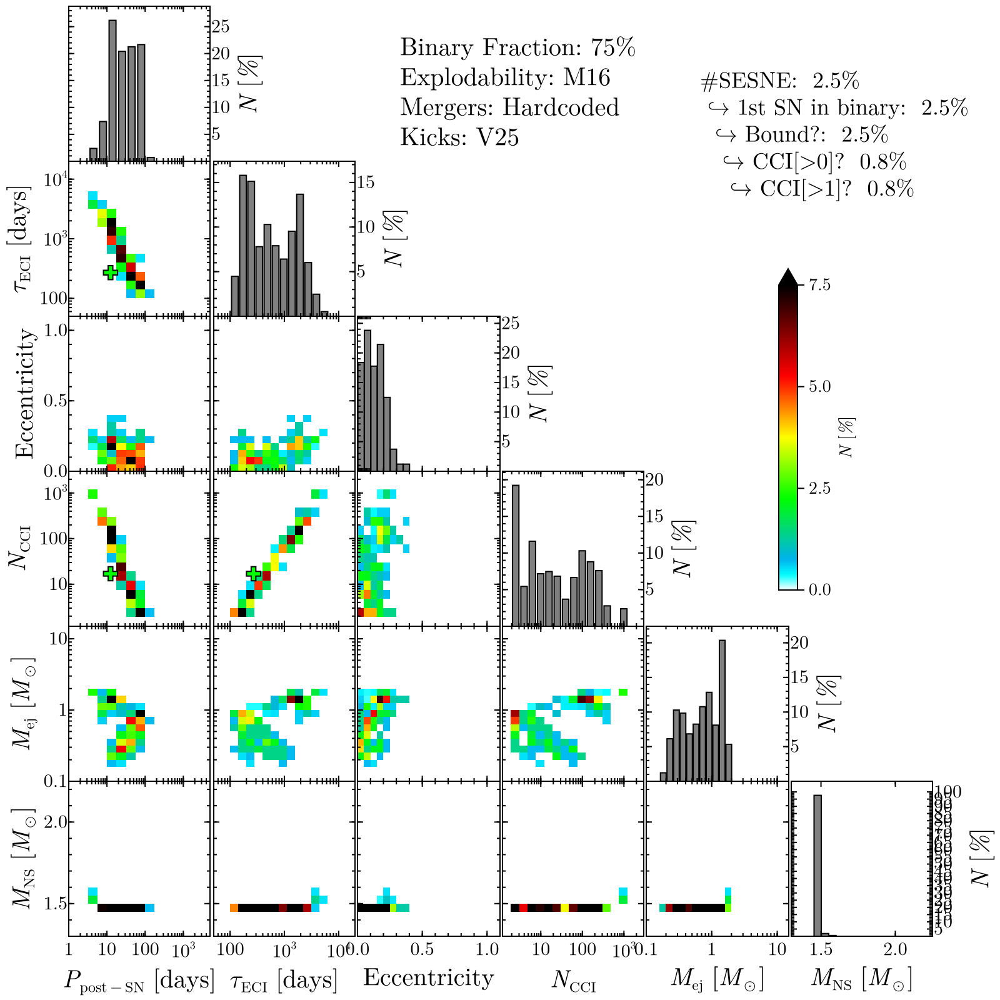

In [101]:
Mend = POPSYNTH.seqdata_MODELS("M_end", mod_names, MODELS, full_output=false)
M_b_ns = POPSYNTH.seqdata_MODELS("M_remnant_b", mod_names, MODELS, full_output=false)
M_g_ns = POPSYNTH.seqdata_MODELS("M_remnant_g", mod_names, MODELS, full_output=false)
Mej = Mend .- M_b_ns


mycmap = cgrad([:white, :cyan, :deepskyblue2, :green1, :yellow, :red,  :black], 
                [0,      0.05,   0.1,    0.3,     0.5,  0.7,       1])

fff = (SNe .== :Ibn) .&& (ECI) .&& (post_SN_orbit .== :bound) .&& (tau_ECI .> tau_periastron) .&& (n_passages .> 1)
@printf("The data in this plot affects %.3f %% of all CCSNe\n", sum(pdfs[fff]))

mlogticks = [ k  for j in -5:1:5 for k in  10. ^j:10. ^j:10. ^(j+1) ]
mlinticks = 0:0.1:100
ticks = ([0.001,  0.01,   0.1,   1.,  10.,  100.,  1000.,     1e4,     1e5], 
        ["0.001", "0.01", "0.1", "1", "10", "100", L"10^3", L"10^4", L"10^5"])
logticks = ([     -3.,     -2.,    -1.,   0.,    1.,     2.,      3.,      4,      5], 
        ["0.001", "0.01", "0.1", "1", "10", "100", L"10^3", L"10^4", L"10^5"])
linticks = 0:0.5:100

FIGURE = Figure(size=(800,800), figure_padding = 5)
grid = GridLayout(FIGURE[0:10,0:10])
ax = Dict()
val_range = Dict("P"=>[1e0,5e3], 
                 "T"=>[50,2e4], 
                 "N"=>[1.2,3e3],
                 "e"=>[0.,1.1],
                 "J"=>[0.1,15],
                 "S"=>[1.3,2.25],)
val_scale = Dict("P"=>log10,
                 "T"=>log10, "N"=>log10, "e"=>identity,
                 "J"=>log10, "S"=>identity)
dbins     = Dict("P"=>.25, "T"=>.15, "N"=>.20, "J"=>0.1, "S"=>0.05, "e"=>0.05)
vals      = Dict("P" => P_postSN[fff], 
                 "T"=>tau_ECI[fff], 
                 "N"=>n_passages[fff], 
                 "J"=>Mej[fff],
                 "S"=>M_b_ns[fff],
                 "pdf"=>pdfs[fff]/sum(pdfs[fff]) *100,
                 "e"=>eccentricity[fff])
SN2022jli = Dict("P"=>12.4, "T"=>270, "N"=>17, "J"=>NaN, "S"=>NaN, "e"=>NaN)
labels    = Dict("P"=>L"P_\mathrm{post-SN} \ [\mathrm{days}]",
                 "T"=>L"\tau_\mathrm{ECI} \ [\mathrm{days}]",
                 "N"=>L"N_\mathrm{CCI}",
                 "J"=>L"M_\mathrm{ej} \ [M_\odot]",
                 "S"=>L"M_\mathrm{NS} \ [M_\odot]",
                 "e"=>"Eccentricity")

#ptjsn
variables    = ["P", "T", "e", "N", "J", "S"]
positions = Dict()
for k in range(1,length(variables)) 
        positions[variables[k]] = k  
end
cornerplots  = [variables[i]*variables[j]
                        for i in 1:length(variables) 
                        for j in (i+1):length(variables)
                ]
for cornerplot in cornerplots
        x=""*cornerplot[1]
        y=""*cornerplot[2]
        ax[cornerplot] = plot_settings(grid[positions[y],positions[x]]; 
                ylabel=labels[y],
                xlabel=labels[x], 
                title =" ", 
                ymticks = val_scale[y] == log10 ? val_scale[y].(mlogticks) : mlinticks, 
                xmticks = val_scale[x] == log10 ? val_scale[x].(mlogticks) : mlinticks, 
                yticks  = val_scale[y] == log10 ? logticks  : linticks,
                xticks  = val_scale[x] == log10 ? logticks  : linticks,
                xlabelvisible = positions[y]==length(variables),
                xticklabelsvisible = positions[y]==length(variables),
                ylabelvisible = positions[x]==1,
                yticklabelsvisible = positions[x]==1
                )
end
for h in variables
        ax[h] = plot_settings(grid[positions[h],positions[h]]; 
                ylabel=L"N \ [%]", 
                xlabel=labels[h], 
                title =" ",xmticks=(mlogticks), 
                xscale=val_scale[h],
                xticks  = val_scale[h] == log10 ? ticks  : linticks,
                yaxisposition=:right,
                xlabelvisible = positions[h]==length(variables),
                xticklabelsvisible = positions[h]==length(variables),
                yticks=5:5:100,
                ymticks=1:1:100
                )
end

exp_crit = Dict("MM" => "M16", "PS"=>"PS20", "Er"=>"E16")[EXP_CRIT[1:2]]  
mer_crit = Dict("X"=>"Hardcoded", "PABLO" => "Energy", "PAULI"=>"Delayed Energy", "PA_IV"=>"OLOF", "ERK"=>"Delayed OLOF")[MERGER_CRITERION]  
kick_crit = Dict(occursin("Valli", KICKS) => "V25", occursin("M16", KICKS)=>"M16", occursin("DM25", KICKS)=>"DM25",occursin("COMBINE", KICKS)=>"K18")[true]
simulation_settings = @sprintf("Binary Fraction: %d%%\nExplodability: %S\nMergers: %s\nKicks: %s", f_B*100, exp_crit, mer_crit, kick_crit)

text!(FIGURE.scene, (.40, .85), text = simulation_settings, fontsize = 20, space = :relative)

fff_sne = (SNe .== :Ibn) 
fff_first_sn = fff_sne .&& sn1 .&& .! (prgs .== "M" .|| prgs .== "NI-S")
fff_bound = fff_first_sn .&& post_SN_orbit .== :bound
fff_canCCI = fff_bound .&& ECI .&& (tau_ECI .> tau_periastron)
fff_CCI_multiple = fff_canCCI .&& (n_passages .> 1)
important_data = @sprintf(
"#SESNE: %4.1f%%
 ↪ 1st SN in binary: %4.1f%%
  ↪ Bound?: %4.1f%%
   ↪ CCI[>0]? %4.1f%%
    ↪ CCI[>1]? %4.1f%%", 
                sum(pdfs[fff_sne]),
                sum(pdfs[fff_first_sn]),
                sum(pdfs[fff_bound]),
                sum(pdfs[fff_canCCI]),
                sum(pdfs[fff_CCI_multiple]),
                )
text!(FIGURE.scene, (.70, .80), text = important_data, fontsize = 18, space = :relative)

hm = nothing           
for cornerplot in cornerplots
        xlab = ""*cornerplot[1]
        ylab = ""*cornerplot[2]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        ymin = val_range[ylab][1]
        ymax = val_range[ylab][2]
        dxb = dbins[xlab]
        dyb = dbins[ylab]
        scalex = val_scale[xlab]
        scaley = val_scale[ylab]

        xbins=scalex(xmin):dxb:scalex(xmax)
        ybins=scaley(ymin):dyb:scaley(ymax)

        x = scalex.(vals[xlab])
        y = scaley.(vals[ylab])
        
    # plot_boundaries = (n_passages .> ymin) .&& (tau_ECI .> xmin)

        hm = sn_heatmap(ax[cornerplot], x, y, vals["pdf"], xbins, ybins; colorrange=[0,7.5],
                cmap=mycmap, print_data=true, highclip=:black)

        scatter!(ax[cornerplot], [scalex.(SN2022jli[xlab])], [scaley.(SN2022jli[ylab])],
                      color = :lime, strokecolor = :black, strokewidth=1, markersize=15, marker=:+, label=L"SN\,2022jli")
        text!([scalex.(SN2022jli[xlab])], [scaley.(SN2022jli[ylab])], 
              text= "2022jli", align=(:center, :top))

        xlims!(ax[cornerplot], scalex(xmin), scalex(xmax))
        ylims!(ax[cornerplot], scaley(ymin), scaley(ymax))

end


for histogram in variables
        xlab = ""*histogram[1]
        xmin = val_range[xlab][1]
        xmax = val_range[xlab][2]
        dxb = dbins[xlab]
        scalex = val_scale[xlab]
        xbins=scalex(xmin):dxb:scalex(xmax)
        x = (vals[xlab])
        xlims!(ax[histogram], xmin, xmax)
        bins, y_bins = run_histogram(ax[histogram], x, vals["pdf"], xbins, dxb * (scalex==log10 ? 1.25 : 1.1), datascale=scalex, norm=1)
        ylims!(ax[histogram], 0, maximum(y_bins)*1.1)

end
Colorbar(FIGURE[3:6,9], hm, label=L"N \ [%]",size = 15)
colgap!(grid, -39)
rowgap!(grid,0)

save_directory = "../output/ECI/"
outfilename = @sprintf("cornerplot_CECI_Ibn_%s_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT, KICKS)
save(save_directory*outfilename, FIGURE)

FIGURE


In [25]:
getproperty(MODELS["1.10_2.20_0.90"]["1"].endvals[1], Symbol("M_co"))
getproperty(MODELS["1.10_2.20_0.90"]["1"], Symbol("endvals"))
MODELS["1.10_2.20_0.90"]["ECI"][1]["ogata"]

Dict{String, Real} with 3 entries:
  "tau_ECI" => 7.0843e5
  "ECI?"    => false
  "Rmax"    => 42.1034

In [26]:
using Revise 
using POPSYNTH 
Revise.revise()

mod_names = []
for k in keys(MODELS)
    push!(mod_names, k)
end
mod_names=sort(mod_names)

SNe, prgs, pdfs, whats = POPSYNTH.seqdata_MODELS("", mod_names, MODELS)
sum(pdfs[SNe .== :IIP])/total_SNe*100/10.38997

sum(pdfs[SNe .== :WD])*100
sum(pdfs[SNe .== :WD])*100
sum(pdfs[SNe .== :WD])*100

ErrorException: Undefined "what" in get_data_from_model

In [27]:

SNType = "Ibc"
y1  = SN_DATA["Menv"]["1-MT"][get_idx("1-MT", SNType)]
x1  = SN_DATA["Mhe"]["1-MT"][get_idx("1-MT", SNType)]

y2  = SN_DATA["Menv"]["2-MT"][get_idx("2-MT", SNType)]
x2  = SN_DATA["Mhe"]["2-MT"][get_idx("2-MT", SNType)]
yM  = SN_DATA["Menv"]["M"][get_idx("M", SNType)]
xM  = SN_DATA["Mhe"]["M"][get_idx("M", SNType)]
yS  = SN_DATA["Menv"]["S"][get_idx("S", SNType)]
xS  = SN_DATA["Mhe"]["S"][get_idx("S", SNType)]



alpha = 0.333
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]  = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["II-i-cont"]  = RGBAf(1,179/255,102/255 , 1) 
color_coding["Ibc-i-cont"] = RGBAf(204/255, 153/255,  1) 
color_coding["BH"]    = RGBAf(0.15, 0.15, 0.15 ,alpha) 
hatcher2 = make_hatch_pattern(size=100, spacing=9, thickness=1, style=:backslash, line_color=color_coding["II-i-cont"], bg_color=RGBAf(0,0,0,0))
color_coding["II-i2"] = Pattern(hatcher2)
color_coding["II-i2"] =  RGBAf(1,179/255,102/255 , 0.66) 


inch = 96
FIGURE = Figure(size=(400,400), figure_padding = 5, px_per_unit = 600/inch)

mticks = union(0.001:0.001:0.01, 0.01:0.01:0.1, 0.1:0.1:1, 1:1:10, 10:10:100)


# grid = FIGURE[1:5, 1:5] = GridLayout()
# grid_left = 1:3
# grid_right = 4:5 
# grid_top  = 1:2 
# grid_bottom = 3:5
grid = FIGURE[1:5, 1:5] = GridLayout()
grid_left = 1:3
grid_right = 4
grid_top  = 1 
grid_bottom = 2:4
ax = plot_settings(grid[grid_bottom, grid_left]; 
            xlabel=L"M_\mathrm{He-core} \ [M_\odot]",
            ylabel=L" M_\mathrm{env} \ [M_\odot]", 
            title =" ", xscale = log10, yscale = log10, 
            xticks=([0.01,0.1,1,10], ["0.01", "0.1", "1", "10"]),
            yticks=([0.001,0.01,0.1,1,10], ["0.001","0.01", "0.1", "1", "10"]),
            xmticks=mticks, ymticks=mticks
            )
ax_dM = plot_settings(grid[grid_bottom, grid_right]; 
            xlabel=L"N \ [\mathrm{norm}]", xticks = 0:0.2:1,
            ylabel=L"M_\mathrm{He-core} \ [M_\odot]", ylabelvisible=false, yticklabelsvisible=false,
            title =" ", yscale = log10, ymticks=mticks,
            )

ax_Mend = plot_settings(grid[grid_top, grid_left]; 
            xlabel=L"M_\mathrm{env} \ [M_\odot]",xlabelvisible=false, xticklabelsvisible=false,
            ylabel=L"N \ [\mathrm{norm}]", xmticks=mticks,
            title =" ", xscale = log10 
            )

scatter!(ax, x1, y1,   color=:teal,    marker = :rect, markersize = 5)
scatter!(ax, x2, y2,   color=:magenta, marker = :rect, markersize = 5)
scatter!(ax, xM, yM,   color=:gold,    marker = :rect, markersize = 5)
scatter!(ax, xS, yS,   color=:black,   marker = :rect, markersize = 5)
# scatter!(ax, (x1 .- dx1)[q1 .>= 0.7 .&& case .== "C"],y1[q1 .>= 0.7 .&& case .== "C"], color=color_coding["II-i"], marker = :rect,   )
# scatter!(ax, (x1 .- dx1)[q1 .<  0.7 .&& case .== "C"],y1[q1 .<  0.7 .&& case .== "C"], color=RGBAf(0,0.5,1,0.3), marker = :rect, strokewidth=2, strokecolor=color_coding["II-i"])
# scatter!(ax, [1e-99], [1e-99], color=color_coding["II-i-cont"], marker = '□', label = "Case\nB+C")
# scatter!(ax, [1e-99], [1e-99], color=color_coding["II-i-cont"], marker = :rect, label = "Case C\n(stable)")
# scatter!(ax, [1e-99], [1e-99],  color=RGBAf(0,0.5,1,0.8), marker = :rect, strokewidth=2, strokecolor=color_coding["II-i-cont"], label = "Case C\n(unstable)")

# axislegend(ax,  position=:lb, 
#     nbanks=2, titleposition=:left, framealpha=0.5, rowgap =3, colgap =3, labelsize=10)


obs_hatch = make_hatch_pattern(size=100, spacing=9, thickness=0.01, style=:backslash, line_color=RGBAf(0.3,0.3,0.3,.5), bg_color=RGBAf(0,0,0,0))
obs_col= Pattern(obs_hatch)

w = 0.01
# run_histogram_filtered(ax_dM, "tot", SNType, "Mhe",  -4:w:2, w*1.1; color=RGBAf(0,0.2,1,0.3),            colorcont=:white,                    datascale = log10, direction = :x)
# # run_histogram(ax_dM, (f_obs_IIn.Mcsm), f_obs_IIn.Mcsm .* 0 .+ 1, -4:w:2, w; color=Pattern(obs_hatch), colorcont=:gray, datascale = log10, direction = :x)

w = 0.10
scale = log10
# xb, yb  = run_histogram_filtered(ax_Mend, "tot", SNType, "Mf",  -3.05:w:2, w;    color=RGBAf(0,0.2,1,0.3),    colorcont=:white, datascale = scale, direction = :y, to_plot=false)
# # _,  yb2  = run_histogram_filtered(ax_Mend, "1", "II-i", "Mej",  -3.05:w:2, w; filter = f_stableC,   color=color_coding["II-i"],  colorcont=:white, datascale = scale, direction = :y, to_plot=false)
# # _,  yb3  = run_histogram_filtered(ax_Mend, "1", "II-i", "Mej",  -3.05:w:2, w; filter = f_BC,        color=color_coding["II-i2"], colorcont=:white, datascale = scale, direction = :y, to_plot=false)
# stacked_barplot!(ax_Mend, (xb), [yb], 
#                     width=w*0.8, colors = [ :red ])
# run_histogram(ax_Mend, "tot", SNType, "Mf",  -3.05:w:2, w; color=RGBAf(0,0,0,0) , colorcont=:red,datascale = scale, direction = :y, strokewidth=2)



xmin, xmax = 1.5, 50
ymin, ymax = 1, 50
ylims!(ax, ymin, ymax)
ylims!(ax_dM, ymin, ymax)
xlims!(ax_dM, 0, nothing)
xlims!(ax, xmin, xmax)
xlims!(ax_Mend, xmin, xmax)
ylims!(ax_Mend, 0, nothing)
# xlims!(ax_fm, -2.5, 0.2)
# ylims!(ax_fm, 0, nothing)



colgap!(grid, 5)
rowgap!(grid, 5)

colgap!(FIGURE.layout, 50)  # separates C from D horizontally
rowgap!(FIGURE.layout, 50)  # separates C from D horizontally

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("stats_Ibc.pdf")
save(save_directory*outfilename, FIGURE)    # 1600 × 1200 px png



FIGURE


UndefVarError: UndefVarError: `get_idx` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [28]:
report_stats(SN_DATA, "E_exp", "1", "Ibc-i", format_str = "%5.2f", print2screen = true, newline = false, unit = (1e51, "Msun"),  multip1_threshold= [], multip_percentiles=0:1:100) 


UndefVarError: UndefVarError: `report_stats` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [29]:
FIG = Figure(size=(500, 600),  figure_padding = (0,0,0,5))
using StatsBase 
set_theme!(theme_latexfonts())

ttps = ["IIP", "IIb", "Ibc", "BH"]

what_to_plot = "Mf"

ymticks = 0:0.5:100
ymticks_II = 0:5:100

d1 = 0.5
bins1 = 0:d1:100
xticks = 0:5:100
xmticks1 = 0:1:100
xticks_t = [@sprintf("%.0f", t)  for t in xticks ]
limits1=[4,16]


# what_to_plot2 = "t"
# d2 = 0.1
# bins2 = 6:d2:8
# xticks2 = log10.([1e6, 2e6, 3e6, 5e6, 10e6, 2e7, 3e7, 5e7, 10e7])
# xticks2_t = [@sprintf("%3.0f", 10^t/1e6)  for t in xticks2 ]
# limits2 =   [log10(1e6), log10(120e6)]
# what_to_plot2 = "M_ni"
# d2 = 0.01
# bins2 = 0.0:d2:0.22
# xticks2 = 0:0.05:0.20
# xticks2_t = [@sprintf("%.2f", t)  for t in xticks2 ]
# limits2 =   [0.0, 0.22]

what_to_plot3 = "E_exp"
d3 = 0.066666666
bins3 = 49.8:d3:53
xticks3 = log10.( [1e50, 3e50, 1e51, 3e51, 1e52])
xmticks3 = union( log10.(1e49:1e49:1e50), log10.(1e50:1e50:1e51), log10.(1e51:1e51:1e52))
xticks3_t = [t > 51 ? @sprintf("%3.0f", 10^t/1e51) : @sprintf("%3.1f", 10^t/1e51)  for t in xticks3 ]
limits3=[log10(5e50), log10(1.5e52)]

what_to_plot4 = "M_rem"
d4 = 0.05
bins4 = 0.0:0.05:2.3
xmticks4 = 0:0.1:2.5
xticks4 = 0.:0.2:5
xticks4_t = [@sprintf("%3.1f", t)  for t in xticks4 ]
limits4=[1.15, 2.1]

yticklabelsize=15
ylabelsize=17
xticklabelsize = 15
xlabelsize = 17
yticklabelpad = 1.8
ylabelpadding = 5 
xlabelpadding = 5

grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax2 = Dict()
ax3 = Dict()
ax4 = Dict()


plot_settings_defauls(position; 
                    xticks=(xticks,xticks_t), 
                    xmticks=xmticks1, ymticks=ymticks1, 
                    x_lab_visible=false,
                    y_lab_visible=false, 
                    ylabel="", xlabel="",title="") = plot_settings( 
                    position,
                    ylabel = ylabel,
                    xlabel = xlabel,
                    title = title, 
                    yticklabelpad = yticklabelpad,
                    xticklabelsize = xticklabelsize, 
                    yticklabelsize = yticklabelsize, 
                    xlabelvisible = x_lab_visible,
                    ylabelvisible = y_lab_visible,
                    xlabelsize = xlabelsize, 
                    ylabelsize = ylabelsize,
                    ylabelpadding = ylabelpadding,
                    xlabelpadding = xlabelpadding,
                    xticklabelsvisible=x_lab_visible,
                    yticklabelsvisible=y_lab_visible,
                    xmticks=xmticks,
                    ymticks=ymticks,
                    xticks=xticks)

ax1["BH"] = plot_settings_defauls(grid[1,1];
                xticks= (xticks,xticks_t),
                ylabel = "BH/SN [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
ax1["IIP"] = plot_settings_defauls(grid[2,1];
                xticks= (xticks,xticks_t),
                ylabel = "II [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks_II)
ax1["IIb"] = plot_settings_defauls(grid[3,1];
                xticks= (xticks,xticks_t),
                ylabel = "IIb [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
ax1["Ibc"] = plot_settings_defauls(grid[4,1];
                xticks= (xticks,xticks_t),
                ylabel = "Ibc [%]", y_lab_visible=true,
                xlabel = L" M_\mathrm{pre-SN} \ [M_\odot]",x_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
yspace = maximum(tight_yticklabel_spacing!, [ax1[ttp] for ttp in ttps])
[ax1[ttp].yticklabelspace = yspace for ttp in ttps]


ax3["IIP"] = plot_settings_defauls(grid[2,3];
                xticks= (xticks3,xticks3_t),
                xmticks=xmticks3, ymticks=ymticks_II)
ax3["IIb"] = plot_settings_defauls(grid[3,3];
                xticks= (xticks3,xticks3_t),
                xmticks=xmticks3, ymticks=ymticks)
ax3["Ibc"] = plot_settings_defauls(grid[4,3];
                xticks= (xticks3,xticks3_t),
                xlabel = L" E_\mathrm{kin,ej} \ [10^{51}\,\mathrm{erg}]",x_lab_visible=true,
                xmticks=xmticks3, ymticks=ymticks)

ax4["IIP"] = plot_settings_defauls(grid[2,2];
                xticks= (xticks4,xticks4_t),
                xmticks=xmticks4, ymticks=ymticks_II)
ax4["IIb"] = plot_settings_defauls(grid[3,2];
                xticks= (xticks4,xticks4_t),
                xmticks=xmticks4, ymticks=ymticks)
ax4["Ibc"] = plot_settings_defauls(grid[4,2];
                xticks= (xticks4,xticks4_t),
                xlabel = L" M_\mathrm{NS, \ grav} \ [M_\odot]",x_lab_visible=true,
                xmticks=xmticks4, ymticks=ymticks)
xspace = maximum(tight_xticklabel_spacing!, [ax1["Ibc"], ax3["Ibc"], ax4["Ibc"]])
[ax.xticklabelspace = xspace for ax in [ax1["Ibc"], ax3["Ibc"], ax4["Ibc"]]]

                

alpha = 0.6
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(0.15, 0.15, 0.15 ,alpha) 




function quantile_sndata(q, what, prg, ttp; unit = 1)
    vals =     [SN_DATA[what][prg][ix]/unit for ix in get_idx(prg, ttp)]
    pdfs = Weights([SN_DATA["pdf"][prg][ix] for ix in get_idx(prg,ttp)])
    return quantile(vals, pdfs, q)
end 

max_ttp = Dict() 
sntypes = ["IIP",  "IIb", "Ibc"]

prg = "S"
for ttp in ttps


    pdf_tot= sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)])

    function run_histogram(ax, prg, ttp, what, bins, width; datascale = identity, extra = false)
        length(get_idx(prg, ttp)) == 0 && return 0

        pdf = sum(  [sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes] )
    
        data = datascale.(SN_DATA[what][prg][get_idx(prg,ttp)])
        dataweights = weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]/pdf*100)

        x_bar = [ bins[ix]+width/2  for ix in range(1,length(bins)-1)]
        hist1 = fit(Histogram,  data, dataweights, bins)  

        y_bar = Float64[]
        for ix in range(1,length(bins)-1)
            push!(y_bar,  hist1.weights[ix]) 
        end 


        color = color_coding[ttp]
        barplot!(ax[ttp], x_bar , 
                            y_bar, 
                            color =  !extra ? color : RGBAf(0,0,0,0),
                            strokewidth = !extra ? 0 : 1,
                            width=width*1.1,
                            strokecolor = !extra ? RGBAf(0,0,0,0) : :black)
        return maximum(hist1.weights)
    end 

    multipeaks = multipeaks_distribution[ttp][prg]

    max_ax = 0
    max_ax = run_histogram(ax1, prg, ttp, what_to_plot, bins1, d1)
    if ttp != "BH"
        # run_histogram(ax2, prg, ttp, what_to_plot2, bins2, d2)
        tmp_max = run_histogram(ax3, prg, ttp, what_to_plot3, bins3, d3, datascale=log10)
        max_ax = max(max_ax, tmp_max)
        tmp_max = run_histogram(ax4, prg, ttp, what_to_plot4, bins4, d4)
        max_ax = max(max_ax, tmp_max)

    end 

    if prg != "S" && ! (ttp in ["II-i", "Ibc-i"]) 

        tmp_max = run_histogram(ax1, "S", ttp, what_to_plot, bins1, d1, extra=true)
        max_ax = max(max_ax, tmp_max)

        if ttp != "BH"
            # run_histogram(ax2,  "S", ttp, what_to_plot2, bins2, d2, extra=true)
            tmp_max  = run_histogram(ax3,  "S", ttp, what_to_plot3, bins3, d3, datascale=log10, extra=true)
            max_ax = max(max_ax, tmp_max)
            tmp_max =  run_histogram(ax4,  "S", ttp, what_to_plot4, bins4, d4, extra=true)
            max_ax = max(max_ax, tmp_max)

        end 
    end
    max_ttp[ttp] = max_ax

    ranges = report_stats(what_to_plot, prg, ttp, newline = true; unit = (1, ""), format_str = "%4.1f", n_peaks = multipeaks[1]+1, multip1_threshold=multipeaks[2])
    for range in ranges
        errorbars!(ax1[ttp], [range[1]], [max_ax*0.75], [range[3]], [range[2]], direction = :x, color = :black)
        scatter!(ax1[ttp], [range[1]], [max_ax*0.75], color = :black, marker = '|', markersize = 10)
        text_decor = @sprintf("%5.1f^{+%5.1f}_{-%5.1f}", range[1], range[2], range[3])
        text!(ax1[ttp], range[1], max_ax*0.80, text=L"%$(text_decor)", align = (:center, :bottom),
            fontsize=13, color=:black)#:red)
    end 
    if ttp != "BH"
        ranges = report_stats(what_to_plot3, prg, ttp, newline = true; unit = (1, ""), format_str = "%4.1f", n_peaks = 1)
        for range in ranges
            errorbars!(ax3[ttp], [log10.(range[1])], [max_ax*0.75], 
            [log10.(range[1])-log10.(range[1]-range[3])], [log10.(range[1]+range[2])-log10.(range[1])], direction = :x, color = :black)
            scatter!(ax3[ttp], [log10.(range[1])], [max_ax*0.75], color = :black, marker = '|', markersize = 10)
            text_decor = @sprintf("%5.1f^{+%5.1f}_{-%5.1f}", range[1]/1e51, range[2]/1e51, range[3]/1e51)
            text!(ax3[ttp], log10.(range[1]), max_ax*0.80, text=L"%$(text_decor)", align = (:center, :bottom),
                fontsize=13, color=:black)#:red)

        end 
        ranges = report_stats(what_to_plot4, prg, ttp, newline = true; unit = (1, ""), format_str = "%4.1f", n_peaks = 1)
        for range in ranges
            errorbars!(ax4[ttp], [range[1]], [max_ax*0.75], [range[3]], [range[2]], direction = :x, color = :black)
            scatter!(ax4[ttp], [range[1]], [max_ax*0.75], marker = '|', markersize = 10, color = :black)
            text_decor = @sprintf("%5.2f^{+%5.2f}_{-%5.2f}", range[1], range[2], range[3])
            text!(ax4[ttp], range[1], max_ax*0.80, text=L"%$(text_decor)", align = (:center, :bottom),
               fontsize=13, color=:black)#:red)

        end 
    end

    # xx = []
    # qq = 0:1:100
    # for qs in qq
    #     push!(xx, quantile_sndata(qs/100, what_to_plot, prg, ttp) )
    # end
    # lines!(ax1[ttp], xx, qq/100, color = "gray", linestyle=:dash)
end



for ttp in ["IIP", "IIb", "Ibc", "BH"]
    bf = 1.03
    xlims!(ax1[ttp], limits1[1], limits1[2])
    ylims!(ax1[ttp], 0, max_ttp[ttp]*bf)
    if ttp!="BH"
        # xlims!(ax2[ttp], limits2[1], limits2[2])
        # ylims!(ax2[ttp], 0, nothing)    
        xlims!(ax3[ttp], limits3[1], limits3[2])
        ylims!(ax3[ttp], 0, max_ttp[ttp]*bf)
        xlims!(ax4[ttp], limits4[1], limits4[2])
        ylims!(ax4[ttp], 0, max_ttp[ttp]*bf)
    end
end 





    

#print(x_bar[1:10], "\n")
#print(y_bar[1:10], "\n")
#print(order[1:10], "\n")

rowgap!(grid, 5)
colgap!(grid, 5)

save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("hist_type_%s_%s_%s.pdf", prg, MERGER_CRITERION, EXP_CRIT)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

FIG



InexactError: InexactError: Int64(NaN32)

In [30]:
FIG = Figure(size=(500, 800),  figure_padding = (0,0,0,5))
using StatsBase 

set_theme!(theme_latexfonts())

what_to_plot = "Mf"

prg = "1-MT"
prg2 = "S"

ttps = ["IIP", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]
prg != "1-MT" && (ttps = ["IIP", "IIb", "Ibc", "II-i", "BH"])
prg == "M" && (ttps = ["IIP", "IIb", "Ibc", "II-i", "IIP-B", "BH"])




ymticks = 0:1:100

d1 = (prg != "M" && prg != "2-MT") ? 0.5 : 0.75
bins1 = 0:d1:100
xticks = 0:5:100
xmticks1 = 0:1:100
xticks_t = [@sprintf("%.0f", t)  for t in xticks ]
limits1 = nothing
if  prg == "1-MT"
    limits1 =[0,16]
elseif prg == "2-MT"
    limits1 = [0,20]
elseif prg == "M" 
    limits1 = [0,35]
else
    throw(ErrorException)
end


what_to_plot3 = "E_exp"
d3 = 0.05
bins3 = 49.8:d3:53
xticks3 = log10.( [1e50, 3e50, 1e51, 3e51, 1e52])
xmticks3 = union( log10.(1e49:1e49:1e50), log10.(1e50:1e50:1e51), log10.(1e51:1e51:1e52))
xticks3_t = [t > 51 ? @sprintf("%3.0f", 10^t/1e51) : @sprintf("%3.1f", 10^t/1e51)  for t in xticks3 ]
limits3=[log10(6e50), log10(9e51)]

what_to_plot4 = "M_rem"
d4 = 0.05
bins4 = 0.0:0.05:2.3
xmticks4 = 0:0.1:2.5
xticks4 = 0.:0.2:5
xticks4_t = [@sprintf("%3.1f", t)  for t in xticks4 ]
limits4=[1.15, 2.1]

yticklabelsize=15
ylabelsize=17
xticklabelsize = 15
xlabelsize = 17
yticklabelpad = 1.8
ylabelpadding = 5 
xlabelpadding = 5

grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax2 = Dict()
ax3 = Dict()
ax4 = Dict()


plot_settings_defauls(position; 
                    xticks=(xticks,xticks_t), 
                    xmticks=xmticks1, ymticks=ymticks1, 
                    x_lab_visible=false,
                    y_lab_visible=false, y_ticks_visible = true,
                    ylabel="", xlabel="",title="") = plot_settings( 
                    position,
                    ylabel = ylabel,
                    xlabel = xlabel,
                    title = title, 
                    yticklabelpad = yticklabelpad,
                    xticklabelsize = xticklabelsize, 
                    yticklabelsize = yticklabelsize, 
                    xlabelvisible = x_lab_visible,
                    ylabelvisible = y_lab_visible,
                    xlabelsize = xlabelsize, 
                    ylabelsize = ylabelsize,
                    ylabelpadding = ylabelpadding,
                    xlabelpadding = xlabelpadding,
                    xticklabelsvisible=x_lab_visible,
                    yticklabelsvisible=y_ticks_visible,
                    xmticks=xmticks,
                    ymticks=ymticks,
                    xticks=xticks)

ax1["BH"] = plot_settings_defauls(grid[1,1];
                xticks= (xticks,xticks_t),
                ylabel = "BH/SN [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
ax1["IIP"] = plot_settings_defauls(grid[2,1];
                xticks= (xticks,xticks_t),
                ylabel = "II [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
ax1["IIb"] = plot_settings_defauls(grid[3,1];
                xticks= (xticks,xticks_t),
                ylabel = "IIb [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
ax1["Ibc"] = plot_settings_defauls(grid[4,1];
                xticks= (xticks,xticks_t),
                ylabel = "Ibc [%]", y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
ax1["II-i"] = plot_settings_defauls(grid[5,1];
                xticks= (xticks,xticks_t),
                xlabel = L"M_\mathrm{pre-SN} \ [M_\odot]", x_lab_visible=!("Ibc-i" in ttps || "IIP-B" in ttps),
                ylabel = "II-i [%]" ,y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks)
("Ibc-i" in ttps) && (ax1["Ibc-i"] = plot_settings_defauls(grid[6,1];
                xticks= (xticks,xticks_t),
                xlabel = L"M_\mathrm{pre-SN} \ [M_\odot]", x_lab_visible=true,
                ylabel = "Ibc-i [%]" ,y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks))
("IIP-B" in ttps) && (ax1["IIP-B"] = plot_settings_defauls(grid[6,1];
                xticks= (xticks,xticks_t),
                xlabel = L"M_\mathrm{pre-SN} \ [M_\odot]", x_lab_visible=true,
                ylabel = "II-BSG [%]" ,y_lab_visible=true,
                xmticks=xmticks1, ymticks=ymticks))
yspace = maximum(tight_yticklabel_spacing!, [ax1[ttp] for ttp in ttps])
[ax1[ttp].yticklabelspace = yspace for ttp in ttps]

ax3["IIP"] = plot_settings_defauls(grid[2,3];
                xticks= (xticks3,xticks3_t),
                ylabel = "II [%]",y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks)
ax3["IIb"] = plot_settings_defauls(grid[3,3];
                xticks= (xticks3,xticks3_t),
                ylabel = "IIb [%]",y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks)
ax3["Ibc"] = plot_settings_defauls(grid[4,3];
                xticks= (xticks3,xticks3_t),
                ylabel = "Ibc [%]",y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks)
ax3["II-i"] = plot_settings_defauls(grid[5,3];
                xticks= (xticks3,xticks3_t),
                xlabel = L"E_\mathrm{kin,ej} \ [10^{51}\mathrm{erg}]", x_lab_visible=!("Ibc-i" in ttps || "IIP-B" in ttps),
                ylabel = "II-i [%]" ,y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks)
("Ibc-i" in ttps) && (ax3["Ibc-i"] = plot_settings_defauls(grid[6,3];
                xticks= (xticks3,xticks3_t),
                xlabel = L"E_\mathrm{kin,ej} \ [10^{51}\mathrm{erg}]",x_lab_visible=true,
                ylabel = "Ibc-i [%]" ,y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks))
("IIP-B" in ttps) && (ax3["IIP-B"] = plot_settings_defauls(grid[6,3];
                xticks= (xticks3,xticks3_t),
                xlabel = L"E_\mathrm{kin,ej} \ [10^{51}\mathrm{erg}]",x_lab_visible=true,
                ylabel = "II-BSG [%]" ,y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks))



ax4["IIP"] = plot_settings_defauls(grid[2,2];
                xticks= (xticks4,xticks4_t),
                ylabel = "II [%]",y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks)
ax4["IIb"] = plot_settings_defauls(grid[3,2];
                xticks= (xticks4,xticks4_t),
                ylabel = "IIb [%]",y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks)
ax4["Ibc"] = plot_settings_defauls(grid[4,2];
                xticks= (xticks4,xticks4_t),
                ylabel = "Ibc [%]",y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks)
ax4["II-i"] = plot_settings_defauls(grid[5,2];
                xticks= (xticks4,xticks4_t),
                xlabel = L"M_\mathrm{NS,grav} \ [M_\odot]", x_lab_visible=!("Ibc-i" in ttps || "IIP-B" in ttps),
                ylabel = "II-i [%]" ,y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks)
("Ibc-i" in ttps) && (ax4["Ibc-i"] = plot_settings_defauls(grid[6,2];
                xticks= (xticks4,xticks4_t),
                xlabel = L"M_\mathrm{NS,grav} \ [M_\odot]", x_lab_visible=true,
                ylabel = "Ibc-i [%]" ,y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks))
("IIP-B" in ttps) && (ax4["IIP-B"] = plot_settings_defauls(grid[6,2];
                xticks= (xticks4,xticks4_t),
                xlabel = L"M_\mathrm{NS,grav} \ [M_\odot]", x_lab_visible=true,
                ylabel = "II-BSG [%]" ,y_ticks_visible=false,
                xmticks=xmticks1, ymticks=ymticks))


                
sntypes = ["IIP",  "IIb", "Ibc", "II-i", "Ibc-i"]

p = Makie.LinePattern(width=5, tilesize=(10,10), linecolor=:gray, backgroundcolor=RGBAf(1,0,0,0.5));
# barplot(1:3,strokewidth=2, color=["grey","green","orange"])
# barplot!([4], [4], color=p, strokewidth=2)
p2 = Pattern("X", backgroundcolor = :red, linecolor = :cyan)
alpha = 0.6
# alpha = 1
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.5, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(0.15, 0.15, 0.15 ,alpha) 



function quantile_sndata(q, what, prg, ttp; unit = 1)
    vals =     [SN_DATA[what][prg][ix]/unit for ix in get_idx(prg, ttp)]
    pdfs = Weights([SN_DATA["pdf"][prg][ix] for ix in get_idx(prg,ttp)])
    return quantile(vals, pdfs, q)
end 


colorpattern_img(color) = make_hatch_pattern(size = 41, spacing=5, thickness=1.8,
                            style=:backslash, line_color=color,
                            bg_color= RGBAf(0, 0, 0, 0))


max_ttp = Dict() 
for ttp in ttps

    function run_histogram(ax, prg, ttp, what, bins, width; datascale = identity, extra = false, alternative=false)
        length(get_idx(prg, ttp)) == 0 && return 0

        # sntypes = ["IIP",  "IIb", "Ibc"]
        pdf = sum([sum(  [sum(SN_DATA["pdf"][progenitor][get_idx(progenitor, type)]) for type in sntypes] )] for progenitor in ["1","2","M","S"])
        data = datascale.(SN_DATA[what][prg][get_idx(prg,ttp)])
        dataweights = weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]/pdf * 100)

        x_bar = [ bins[ix]+width/2  for ix in range(1,length(bins)-1)]
        hist1 = fit(Histogram,  data, dataweights, bins)  

        y_bar = Float64[]
        for ix in range(1,length(bins)-1)
            push!(y_bar,  hist1.weights[ix]) 
        end 

        color = color_coding[ttp]
        # colorpattern_img = create_hatch_pattern(
        #         40, 9, 1.5, color, RGBAf(0, 0, 0, 0);
        #         style = :diagonal)
        # colorpattern = Pattern(create_hatch_pattern(50, 5, 2, color, RGBAf(0,0,0,0)))
        colorpattern = Pattern(colorpattern_img(color))

        if !extra && !alternative 
            barplot!(ax[ttp], x_bar , 
                            y_bar, 
                            color = :white,
                            strokewidth = 0,
                            width=width,
                            strokecolor =RGBAf(0,0,0,0))
            barplot!(ax[ttp], x_bar , 
                            y_bar, 
                            color = color,
                            strokewidth = 0,
                            width=width,
                            strokecolor =RGBAf(0,0,0,0))
        elseif extra 
            barplot!(ax[ttp], x_bar , 
                            y_bar, 
                            color =  RGBAf(0,0,0,0),
                            strokewidth =  0.5,
                            width=width,
                            strokecolor = :black)

        elseif alternative 
            barplot!(ax[ttp], x_bar , 
                            y_bar, 
                            color = colorpattern,
                            strokewidth =  0.5,
                            width=width,
                            strokecolor = color)

        end

        return maximum(hist1.weights)
    end 

    max_ax = 0
    if prg == "1-MT" || prg == "2-MT"
        prg_old = @sprintf("%1s", prg[1])
        tmp_max = run_histogram(ax1, prg_old, ttp, what_to_plot, bins1, d1, extra=false, alternative = true)
        max_ax = max(max_ax, tmp_max)
        if ttp != "BH"
            tmp_max = run_histogram(ax3, prg_old, ttp, what_to_plot3, bins3, d3, datascale=log10, extra=false, alternative = true)
            max_ax = max(max_ax, tmp_max)
            tmp_max = run_histogram(ax4, prg_old, ttp, what_to_plot4, bins4, d4, extra=false, alternative = true)
            max_ax = max(max_ax, tmp_max)
        end 

    end 

    tmp_max = run_histogram(ax1, prg, ttp, what_to_plot, bins1, d1)
    max_ax = max(max_ax, tmp_max)
    if ttp != "BH"
        # run_histogram(ax2, prg, ttp, what_to_plot2, bins2, d2)
        tmp_max = run_histogram(ax3, prg, ttp, what_to_plot3, bins3, d3, datascale=log10)
        max_ax = max(max_ax, tmp_max)
        tmp_max = run_histogram(ax4, prg, ttp, what_to_plot4, bins4, d4)
        max_ax = max(max_ax, tmp_max)

    end 

    if prg != "S" && ! (ttp in ["II-i", "Ibc-i"]) 
        tmp_max = run_histogram(ax1, "S", ttp, what_to_plot, bins1, d1, extra=true)
        max_ax = max(max_ax, tmp_max)
        if ttp != "BH"
            tmp_max  = run_histogram(ax3,  "S", ttp, what_to_plot3, bins3, d3, datascale=log10, extra=true)
            max_ax = max(max_ax, tmp_max)
            tmp_max =  run_histogram(ax4,  "S", ttp, what_to_plot4, bins4, d4, extra=true)
            max_ax = max(max_ax, tmp_max)
        end 


    end

    
    max_ttp[ttp] = max_ax
    multipeaks = multipeaks_distribution[ttp][prg]
    multipeaks_S = multipeaks_distribution[ttp]["S"]

    ranges = report_stats(what_to_plot, prg, ttp, newline = true; unit = (1, ""), format_str = "%4.1f",  n_peaks = multipeaks[1]+1, multip1_threshold=multipeaks[2])
    for range in ranges
        errorbars!(ax1[ttp], [range[1]], [max_ax*0.75], [range[3]], [range[2]], direction = :x, color = :black)
        scatter!(ax1[ttp], [range[1]], [max_ax*0.75], color = :black, marker = '|', markersize = 10)
        text_decor = @sprintf("%5.1f^{+%5.1f}_{-%5.1f}", range[1], abs(range[2]), abs(range[3]))
        text!(ax1[ttp], range[1], max_ax*0.6, text=L"%$(text_decor)", align = (:center, :bottom),
            fontsize=12, color=:black)#:red)

    end 
    if ! (ttp in ["Ibc-i", "II-i", "IIP-B"])
        ranges = report_stats(what_to_plot, "S", ttp, newline = true; unit = (1, ""), format_str = "%4.1f",  n_peaks = multipeaks_S[1]+1, multip1_threshold=multipeaks_S[2])
        for range in ranges
            errorbars!(ax1[ttp], [range[1]], [max_ax*0.85], [range[3]], [range[2]], direction = :x, color = :gray)
            scatter!(ax1[ttp], [range[1]], [max_ax*0.85], color = :gray, marker = '|', markersize = 10)
            # text_decor = @sprintf("%5.1f^{+%5.1f}_{-%5.1f}", range[1], range[2], range[3])
            # text!(ax1[ttp], range[1], max_ax*0.86, text=L"%$(text_decor)", align = (:center, :bottom),
            #      fontsize=12, color=:black)#:red)

        end 
    end
    if ttp != "BH"
        ranges = report_stats(what_to_plot3, prg, ttp, newline = true; unit = (1, ""), format_str = "%4.1f",  n_peaks =  1, multip1_threshold=multipeaks[2])
        for range in ranges
            errorbars!(ax3[ttp], [log10.(range[1])], [max_ax*0.75], 
            [log10.(range[1])-log10.(range[1]-range[3])], [log10.(range[1]+range[2])-log10.(range[1])], direction = :x, color = :black)
            scatter!(ax3[ttp], [log10.(range[1])], [max_ax*0.75], color = :black, marker = '|', markersize = 10)
            text_decor = @sprintf("%5.1f^{+%5.1f}_{-%5.1f}", range[1]/1e51, abs(range[2])/1e51, abs(range[3])/1e51)
            text!(ax3[ttp], log10.(range[1]), max_ax*0.6, text=L"%$(text_decor)", align = (:center, :bottom),
               fontsize=12, color=:black)#:red)

        end 
        ranges = report_stats(what_to_plot4, prg, ttp, newline = true; unit = (1, ""), format_str = "%4.1f",  n_peaks = 1, multip1_threshold=multipeaks[2])
        for range in ranges
            errorbars!(ax4[ttp], [range[1]], [max_ax*0.75], [range[3]], [range[2]], direction = :x, color = :black)
            scatter!(ax4[ttp], [range[1]], [max_ax*0.75], color = :black, marker = '|', markersize = 10)
            text_decor = @sprintf("%5.2f^{+%5.2f}_{-%5.2f}", range[1], abs(range[2]), abs(range[3]))
            text!(ax4[ttp], (range[1]), max_ax*0.6, text=L"%$(text_decor)", align = (:center, :bottom),
               fontsize=12, color=:black)#:red)

        end 

      if ! (ttp in ["Ibc-i", "II-i", "IIP-B"])

            ranges = report_stats(what_to_plot3, "S", ttp, newline = true; unit = (1, ""), format_str = "%4.1f",  n_peaks = 1, multip1_threshold=multipeaks_S[2])
            for range in ranges
                errorbars!(ax3[ttp], [log10.(range[1])], [max_ax*0.85], 
                [log10.(range[1])-log10.(range[1]-range[3])], [log10.(range[1]+range[2])-log10.(range[1])], direction = :x, color = :gray)
                scatter!(ax3[ttp], [log10.(range[1])], [max_ax*0.85], color = :gray, marker = '|', markersize = 10)
            end 
            ranges = report_stats(what_to_plot4, "S", ttp, newline = true; unit = (1, ""), format_str = "%4.1f",  n_peaks = 1, multip1_threshold=multipeaks_S[2])
            for range in ranges
                errorbars!(ax4[ttp], [range[1]], [max_ax*0.85], [range[3]], [range[2]], direction = :x, color = :gray)
                scatter!(ax4[ttp], [range[1]], [max_ax*0.85], color = :gray, marker = '|', markersize = 10)
            end 
        end
    
    end

    # xx = []
    # qq = 0:1:100
    # for qs in qq
    #     push!(xx, quantile_sndata(qs/100, what_to_plot, prg, ttp) )
    # end
    # lines!(ax1[ttp], xx, qq/100, color = "gray", linestyle=:dash)
end


for ttp in ttps
    bf = 1.03
    xlims!(ax1[ttp], limits1[1], limits1[2])
    ylims!(ax1[ttp], 0, max_ttp[ttp]*bf)
    if ttp!="BH"
        # xlims!(ax2[ttp], limits2[1], limits2[2])
        # ylims!(ax2[ttp], 0, nothing)    
        xlims!(ax3[ttp], limits3[1], limits3[2])
        ylims!(ax3[ttp], 0, max_ttp[ttp]*bf)
        xlims!(ax4[ttp], limits4[1], limits4[2])
        ylims!(ax4[ttp], 0, max_ttp[ttp]*bf)
    end
end 


rowgap!(grid, 5)
colgap!(grid, 5)

save_directory = ""
outfilename = @sprintf("hist_type_%s_%s_%s.pdf", prg, MERGER_CRITERION, EXP_CRIT)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

FIG



ArgumentError: ArgumentError: Pattern('X') not defined, use one of ['/', '\', '-', '|', 'x', '+']

In [31]:
function get_hist(prg, ttp, what, bins, width; datascale = identity, extra = false)
    length(get_idx(prg, ttp)) == 0 && return 0

    pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])
    data = datascale.(SN_DATA[what][prg][get_idx(prg,ttp)])
    dataweights = weights(SN_DATA["pdf"][prg][get_idx(prg,ttp)]*100/pdf)

    x_bar = [ bins[ix]+width/2  for ix in range(1,length(bins)-1)]
    hist1 = fit(Histogram,  data, dataweights, bins)  

    return hist1
end 
maximum(get_hist("S", "IIb", "Mf", 0:1:100, 0.1).weights)


UndefVarError: UndefVarError: `get_idx` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [32]:
using StatsBase 


sntypes = ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]

                     

progenitors = ["1", "2", "M", "S"]


multip1_thresholds = Dict("Ibc"=>13, "BH"=>7.5, "IIP"=>0, "IIP-B"=>0, "IIb"=>0, "II-i"=>0, "Ibc-i"=>0)

for ttp in ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]

    multip1_threshold = multip1_thresholds[ttp]
    
    pdf_tot= sum(SN_DATA["pdf"]["tot"][get_idx("tot", ttp)])
    pdf_tot < 0.0001 && continue 

    

    for prg in progenitors
        sub_pdf = sum(SN_DATA["pdf"][prg][get_idx(prg, ttp)])
        sub_pdf < 0.0001 && continue 

        @printf("%7s (%s) -> %5.2f |", ttp, prg, sub_pdf*100)

        report_stats(SN_DATA, "Mf",    prg, ttp, false, unit = (1, "Msun"), 
                        multipeak= ( (ttp=="Ibc" || ttp =="BH") && prg == "S"), 
                        multip_percentiles=0:1:20,multip1_threshold= ( (ttp=="Ibc" || ttp =="BH") && prg == "S") ? multip1_threshold : ( ttp == "Ibc" && prg == "1" ? 88.4 : NaN) 
                        )
        # report_stats(SN_DATA, "t",     prg, ttp, false, unit = (1e6, "Myr"))
        report_stats(SN_DATA, "MM",    prg, ttp, false, unit =(1, "Msun"))
        report_stats(SN_DATA, "N_DATA, "E_exp", prg, ttp, false, unit =(1e51, "B"))
        report_stats(SN_DATA, "N_DATA, "M_rem", prg, ttp, true , unit =(1, "Msun"), format_str="%4.2f")
    
    end
    @printf("%7s     -> %5.2f |", ttp,  pdf_tot*100)

    report_stats(SN_DATA, "Mf",    "tot", ttp, false, unit =(1, "Msun"))
    # report_stats(SN_DATA, "N_DATA, "t",     "tot", ttp, false, unit =(1e6, "Myr"))
    report_stats(SN_DATA, "N_DATA, "MM",    "tot", ttp, false, unit =(1, "Msun"))
    report_stats(SN_DATA, "E_exp", "tot", ttp, false, unit =(1e51, "B"))
    report_stats(SN_DATA, "N_DATA, "M_rem", "tot", ttp, true , unit =(1, "Msun"), format_str="%4.2f")



    
    #weighted_mean = sum([SN_DATA[what_to_plot]["tot"][ix]*SN_DATA["pdf"]["tot"][ix]/ pdf_tot for ix in get_idx("tot", ttp)])
    #weighted_err = sqrt(  sum(  [  (SN_DATA[what_to_plot]["tot"][ix]-weighted_mean)^2 * SN_DATA["pdf"]["tot"][ix] for ix in get_idx("tot", ttp)]   )/ pdf_tot )
    #vlines!(ax1[ttp], log10(weighted_mean), ymin=0, ymax=2, color = color_coding[ttp], linewidth=2)
    #_temp=vspan!(ax1[ttp], log10(weighted_mean-weighted_err), log10(weighted_mean+weighted_err), ymin=0, ymax=2, color = color_coding[ttp], alpha = 0.2)
    #@printf("%s  M %7.2f ± %7.2f;", ttp, weighted_mean, weighted_err)
    #translate!(_temp, 0, 0, -10)
    #weighted_mean = sum([SN_DATA["t"]["tot"][ix]*SN_DATA["pdf"]["tot"][ix]/ pdf_tot for ix in get_idx("tot", ttp)])
    #weighted_err = sqrt(  sum(  [  (SN_DATA["t"]["tot"][ix]-weighted_mean)^2 * SN_DATA["pdf"]["tot"][ix] for ix in get_idx("tot", ttp)]   )/ pdf_tot )
    #vlines!(ax2[ttp], log10(weighted_mean), ymin=0, ymax=2, color = color_coding[ttp], linewidth  = 2, alpha = 1)
    #_temp=vspan!(ax2[ttp], log10(weighted_mean-weighted_err), log10(weighted_mean+weighted_err), ymin=0, ymax=2, color = color_coding[ttp], alpha = 0.2)
    #translate!(_temp, 0, 0, -10)
    #@printf(" t %7.1f ± %7.1f\n",   weighted_mean/1e6, weighted_err/1e6)


    print("\n")
end

report_stats(SN_DATA, "N_DATA, "Mf",  "1", "Ibc-i", false, unit = (1, "Msun"), 
                multipeak=false, 
                multip_percentiles=1:1:100, multip1_threshold=85)




Base.Meta.ParseError: ParseError:
# Error @ /vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/src/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y100sZmlsZQ==.jl:34:41
        report_stats(SN_DATA, "MM",    prg, ttp, false, unit =(1, "Msun"))
        report_stats(SN_DATA, "N_DATA, "E_exp", prg, ttp, false, unit =(1e51, "B"))
#                                       └ ── cannot juxtapose string literal

In [34]:
include("defs.jl")
for logM in logMs 
    logM_t = to_key(logM)
    for logP in logPs 
        logP_t = to_key(logP)
        for q in qs 
            q_t  = to_key(q)
            model = MODELS[logM_t][logP_t][q_t]
            n = model["mod"]

            if model["SN1"]["Ibc-i"] > 0
                M_1_postHeB = f_MW.M_1_end_BURN_He_1[n]
                M_end = model["M1end"]
                M_2_end = f_MW.M_2_end_1[n]
                Pf = f_MW.period_end_1[n]
                case = model["case"]
                dMc = model["dM_C"]
                #  ! (M_2_end > 15 && Pf < 200) && continue
                 (occursin("A", case)) && continue 

                a_postHeB = f_MW.a_end_BURN_He_1[n]
                a_new = 0# derive_a_massloss_smooth(a_postHeB, M_1_postHeB, M_2_end, dMc; dm=1e-4)
                Pf_new = 0#kepler_law(m = M_end+M_2_end, a = a_new, P = nothing )
                @printf("Mod #%5d: %s/%s/%s, M1: %5.1f  (dm=%5.2f)  M2: %5.1f   Pf: %5.1f (%5.1f)  case %5s\n", n, logM_t, q_t, logP_t, M_end, dMc, M_2_end, Pf, Pf_new, case)

            end


        end 
    end 
end


SystemError: SystemError: opening file "/vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/src/defs.jl": No such file or directory

In [35]:
pdfs  = []
for logM in logMs 
    logM_t = to_key(logM)
    for logP in logPs 
        logP_t = to_key(logP)
        for q in qs 
            q_t  = to_key(q)
            model = MODELS[logM_t][logP_t][q_t]

            push!(pdfs, model["pdf"]["tot"])

                


        end 
    end 
end
print(sum(pdfs))

UndefVarError: UndefVarError: `to_key` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [36]:
include("defs.jl")

FIG = Figure(size=(500, 800), figure_padding = 0)
set_theme!(theme_latexfonts())

d1 = 1/(exp(1.89)*pi)
d1 = 0.066
d1 = 0.05
d2 = 0.1


bins = d1/2:d1:2.5
bins2 = 6:d2:8

xticks = bins
xticks_t = [@sprintf("%3.1f", 10^t)  for t in xticks ]
xticks2 = log10.([1e6, 2e6, 3e6, 5e6, 10e6, 2e7, 3e7, 5e7, 10e7])
xticks2_t = [@sprintf("%3.0f", 10^t/1e6)  for t in xticks2 ]
grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax_pie = Dict()
ax2 = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 0:6
right_axis = 7:8
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
ax1["all"] = plot_settings( grid[0:3,left_axis],
                ylabel = "Total [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,yticklabelpad=yticklabelpad,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xaxisposition=:bottom,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["all"] = Axis( grid[0:3,right_axis],
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")
ax_extra = Axis( grid[0:2,0:3], aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["1-MT"] = plot_settings( grid[4:5,left_axis],
                ylabel = "Primaries [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["1-MT"] = Axis( grid[4:5,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["2-MT"] = plot_settings( grid[6:7,left_axis],
                ylabel = "Secondaries [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["2-MT"] = Axis( grid[6:7,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["M"] = plot_settings( grid[8:9,left_axis],
                ylabel = "Mergers [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["M"] = Axis( grid[8:9,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["S+NI"] = plot_settings( grid[10:11,left_axis],
                ylabel = "Single Star [%]",
                xlabel = L"M_\mathrm{end} \ [M_\odot]",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=true,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["S+NI"] = Axis( grid[10:11,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

                

                
what_to_plot = "Mf"
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     ["Ibc-i", "Ibc",   "IIb", "IIP-B",  "IIP",   "II-i", "BH"]
progenitors = ["1-MT", "2-MT", "M", "S+NI"]

#hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1)   for i in range(1, length(sntypes)) ]
x_bar2 = [ bins2[ix]+d2/2  for ix in range(1,length(bins2)-1)   for i in range(1, length(sntypes)) ]
hist1 = Dict() 
hist2 = Dict() 
for sn in sntypes 
    hist1[sn] = fit(Histogram,  log10.(SN_DATA[what_to_plot]["tot"][get_idx("tot",sn)]), weights(SN_DATA["pdf"]["tot"][get_idx("tot",sn)]*100), bins)
    hist2[sn] = fit(Histogram,  log10.(SN_DATA["t"]["tot"][get_idx("tot",sn)]),  weights(SN_DATA["pdf"]["tot"][get_idx("tot",sn)]*100), bins2)
end
y_bar = Float64[]
for ix in range(1,length(bins)-1)
    for sn in sntypes
        push!(y_bar,  hist1[sn].weights[ix]) 
    end
end 
y_bar2 = Float64[]
for ix in range(1,length(bins2)-1)
    for sn in sntypes
        push!(y_bar2,  hist2[sn].weights[ix]) 
    end
end 

alpha = 0.6
order = [i    for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
order2 = [i    for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 


colors= [color_coding[sntypes[i]] for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
colors2= [color_coding[sntypes[i]] for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]

barplot!(ax1["all"], x_bar , 
                     y_bar, 
                     stack= order,
                     color = colors,
                     width=d1)
# barplot!(ax2["all"], x_bar2 , 
#                      y_bar2, 
#                      stack= order2,
#                      color = colors2,
#                      width=d2)



 

for prg in progenitors

    #hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
    x_bar  = [ bins[ix]+d1/2 for ix in range(1,length(bins)-1)   for i in range(1, length(sntypes)) ]
    x_bar2 = [ bins2[ix]+d2/2  for ix in range(1,length(bins2)-1)   for i in range(1, length(sntypes)) ]
    hist1 = Dict() 
    hist2 = Dict() 
    for sn in sntypes 
        hist1[sn] = fit(Histogram,  log10.(SN_DATA[what_to_plot][prg][get_idx(prg,sn)]), weights(SN_DATA["pdf"][prg][get_idx(prg,sn)]*100), bins)
        hist2[sn] = fit(Histogram,  log10.(SN_DATA["t"][prg][get_idx(prg,sn)]),  weights(SN_DATA["pdf"][prg][get_idx(prg,sn)]*100), bins2)
    end
    y_bar = Float64[]
    for ix in range(1,length(bins)-1)
        for sn in sntypes
            push!(y_bar,  hist1[sn].weights[ix]) 
        end
    end 
    y_bar2 = Float64[]
    for ix in range(1,length(bins2)-1)
        for sn in sntypes
            push!(y_bar2,  hist2[sn].weights[ix]) 
        end
    end 


    y_bar = Float64[]
    y_bar2 = Float64[]
    for ix in range(1,length(bins)-1)
        for sn in sntypes
            push!(y_bar,  hist1[sn].weights[ix]) 
        end
    end 
    for ix in range(1,length(bins2)-1)
        for sn in sntypes
            push!(y_bar2,  hist2[sn].weights[ix]) 
        end
    end 
    
    order = [i    for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
    order2 = [i    for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]
    
    
    colors= [color_coding[sntypes[i]] for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
    colors2= [color_coding[sntypes[i]] for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]
    
    barplot!(ax1[prg], x_bar , 
                            y_bar, 
                            stack= order,
                            color = colors,
                            width=d1)
    # barplot!(ax2[prg], x_bar2 , 
    #                         y_bar2, 
    #                         stack= order2,
    #                         color = colors2,
    #                         width=d2)

    scatter!(ax1[prg], [0.1,100], [0,0], color = color_coding["IIP"],  markersize=12, marker = :rect,
                                label = @sprintf("%4.1f%%   ", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP")])))
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")]) >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["IIP-B"], markersize=12, marker = :rect,
                                 label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")])))
    scatter!(ax1[prg], [-100,-100], [0,0], color = color_coding["IIb"], markersize=12, marker = :rect,
                                 label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "IIb")])))
    sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")]) >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["II-i"], markersize=12, marker = :rect,
                                 label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")])))
    scatter!(ax1[prg], [-100,-100], [0,0], color = color_coding["Ibc"], markersize=12, marker = :rect,
                                 label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc")])))
    sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")]) >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["Ibc-i"], markersize=12, marker = :rect,
                                                                label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")])))
    # sum(SN_DATA["pdf"][prg][get_idx(prg, "BH")]) >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["BH"], markersize=12, marker = :rect,
    #                                                             label = @sprintf("[%.3f%%]", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "BH")])))
    n_bh = sum(SN_DATA["pdf"][prg][get_idx(prg, "BH")])
    n_bh >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["BH"], markersize=12, marker = :rect,
             label =  100*n_bh < 0.1 ?  ("["*str_significant(100*n_bh, 1)*"%]") : @sprintf("[%.1f%%]", 100*n_bh) )

    tot_sn_tt = sum( [ sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes_exp] ) 
                                        

    @printf("done %s\n[IIP:%5.2f] [II-BSG:%5.2f] [IIb:%5.2f] [Ibc:%5.2f] [II-i:%5.2f] [Ibc-i:%5.2f] tot : %1f \n", prg,  
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIb")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")])*100, 100*tot_sn_tt )
   
    # axislegend(ax1[prg],  position=:lt, nbanks=1, titleposition=:right, labelsize = 11, rowgap = 0, colgap = 0, alpha = 0.5)


end

barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP"],   label =  @sprintf("II\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("II-BSG\n%.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIb"],   label = @sprintf("IIb\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["II-i"],  label = @sprintf("II-i\n%.1f%%",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc"],   label = @sprintf("Ibc\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibc-i\n%.1f%%",   100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["BH"],    label = @sprintf("BH\n[%.1f%%]",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "BH")])))
axislegend(ax_pie["all"],  position=:ct, 
    nbanks=1, labelsize=12, rowgap =6, colgap =0)


for prg in ["all", "1-MT", "2-MT", "M", "S+NI"]
    xlims!(ax1[prg], .175, 1.51)
    (what_to_plot == "MM") && xlims!(ax1[prg], 0.9, 2.2)
    ylims!(ax1[prg], 0, nothing)
    prg != "all" && axislegend(ax1[prg],  position=:rt, 
                   nbanks=  1, titleposition=:left, framevisible=false, rowgap=-5,colgap=-3, 
                   labelsize=11.5, padding=(0.,5,0,-.5))
                                #padding : (   top)

end 
# for prg in ["all", "1", "2", "M", "S"]
#     xlims!(ax2[prg], 6.35, 8.05)
#     ylims!(ax2[prg], 0, nothing)

# end 
    

# barplot!(ax1["all"], [-100], [0], color = color_coding["IIP"], label =  @sprintf("II: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("II-BSG: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-BSG")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["IIb"], label = @sprintf("IIb: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["II-i"], label = @sprintf("II-i: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["Ibc"], label = @sprintf("Ibc: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibc-i: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))

# print(x_bar[1:10], "\n")
# print(y_bar[1:10], "\n")
# print(order[1:10], "\n")

rowgap!(grid, 5,   5)
for i in 3:1:10
    rowgap!(grid, i,  3)
end
colgap!(grid, 5)

SN_numbers = [100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])]
SN_colors  = [color_coding["IIP"], color_coding["IIP-B"],color_coding["IIb"],color_coding["Ibc"],
              color_coding["Ibc-i"], color_coding["II-i"]]
pie!(ax_extra, reverse!(SN_numbers), 
         color=reverse!(SN_colors), offset = pi/2, inner_radius = 0.)

for tt in ["1-MT", "2-MT", "M", "S+NI"]
    tot_sn_tt = sum( [sum(SN_DATA["pdf"][tt][get_idx(tt, type)]) for type in sntypes_exp] ) 
    SN_numbers = [100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIP")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIP-B")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIb")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "Ibc")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "Ibc-i")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "II-i")]),
                  100*(1 - tot_sn_tt ) 
                     ]         
    SN_colors  = [color_coding["IIP"], color_coding["IIP-B"],color_coding["IIb"],color_coding["Ibc"],
            color_coding["Ibc-i"], color_coding["II-i"], "white"]
    stroke_color = [:black, :black, :black, :black, :black, :black, :white]
    pie!(ax_pie[tt], reverse!(SN_numbers), 
        color=reverse!(SN_colors), offset = pi/2, inner_radius = 0., strokewidth=1, strokecolor=reverse!(stroke_color))
    pie!(ax_pie[tt], reverse!([100*tot_sn_tt, 100*(1-tot_sn_tt)]), 
        color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = 0, radius = 1, strokecolor=:black)

    text!(ax_pie[tt], 0., 0., text=@sprintf("%.1f%%", 100*tot_sn_tt), rotation = pi/2)

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    xlims!(ax_pie[tt],-0.5,1.02)
    ylims!(ax_pie[tt],-0.5,1.02)
end
 
            
ax_pie["all"].rightspinevisible = false
ax_pie["all"].topspinevisible = false
ax_pie["all"].leftspinevisible = false
ax_pie["all"].bottomspinevisible = false
ax_extra.rightspinevisible = false
ax_extra.topspinevisible = false
ax_extra.leftspinevisible = false
ax_extra.bottomspinevisible = false



directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/"
outfilename = @sprintf("multibar_per_progenitor_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT)
save(directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG



SystemError: SystemError: opening file "/vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/src/defs.jl": No such file or directory

In [37]:
include("defs.jl")

FIG = Figure(size=(500, 800), figure_padding = 0)
set_theme!(theme_latexfonts())

d1 = 1/(exp(1.89)*pi)
d1 = 0.066
d1 = 0.05
d2 = 0.1


bins = d1/2:d1:2.5
bins2 = 6:d2:8

xticks = bins
xticks_t = [@sprintf("%3.1f", 10^t)  for t in xticks ]
xticks2 = log10.([1e6, 2e6, 3e6, 5e6, 10e6, 2e7, 3e7, 5e7, 10e7])
xticks2_t = [@sprintf("%3.0f", 10^t/1e6)  for t in xticks2 ]
grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax_pie = Dict()
ax2 = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 0:6
right_axis = 7:8
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
ax1["all"] = plot_settings( grid[0:3,left_axis],
                ylabel = "Total [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,yticklabelpad=yticklabelpad,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xaxisposition=:bottom,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["all"] = Axis( grid[0:3,right_axis],
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")
ax_extra = Axis( grid[0:2,0:3], aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["1"] = plot_settings( grid[4:5,left_axis],
                ylabel = "Primaries [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["1"] = Axis( grid[4:5,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["2"] = plot_settings( grid[6:7,left_axis],
                ylabel = "Secondaries [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["2"] = Axis( grid[6:7,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["M"] = plot_settings( grid[8:9,left_axis],
                ylabel = "Mergers [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["M"] = Axis( grid[8:9,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["S"] = plot_settings( grid[10:11,left_axis],
                ylabel = "Single Star [%]",
                xlabel = L"M_\mathrm{end} \ [M_\odot]",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=true,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["S"] = Axis( grid[10:11,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

                

                
what_to_plot = "Mf"
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     ["Ibc-i", "Ibc",   "IIb", "IIP-B",  "IIP",   "II-i", "BH"]
progenitors = ["1", "2", "M", "S"]

#hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1)   for i in range(1, length(sntypes)) ]
x_bar2 = [ bins2[ix]+d2/2  for ix in range(1,length(bins2)-1)   for i in range(1, length(sntypes)) ]
hist1 = Dict() 
hist2 = Dict() 
for sn in sntypes 
    hist1[sn] = fit(Histogram,  log10.(SN_DATA[what_to_plot]["tot"][get_idx("tot",sn)]), weights(SN_DATA["pdf"]["tot"][get_idx("tot",sn)]*100), bins)
    hist2[sn] = fit(Histogram,  log10.(SN_DATA["t"]["tot"][get_idx("tot",sn)]),  weights(SN_DATA["pdf"]["tot"][get_idx("tot",sn)]*100), bins2)
end
y_bar = Float64[]
for ix in range(1,length(bins)-1)
    for sn in sntypes
        push!(y_bar,  hist1[sn].weights[ix]) 
    end
end 
y_bar2 = Float64[]
for ix in range(1,length(bins2)-1)
    for sn in sntypes
        push!(y_bar2,  hist2[sn].weights[ix]) 
    end
end 

alpha = 0.6
order = [i    for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
order2 = [i    for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 


colors= [color_coding[sntypes[i]] for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
colors2= [color_coding[sntypes[i]] for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]

barplot!(ax1["all"], x_bar , 
                     y_bar, 
                     stack= order,
                     color = colors,
                     width=d1)
# barplot!(ax2["all"], x_bar2 , 
#                      y_bar2, 
#                      stack= order2,
#                      color = colors2,
#                      width=d2)



                     

for prg in progenitors

    #hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
    x_bar  = [ bins[ix]+d1/2 for ix in range(1,length(bins)-1)   for i in range(1, length(sntypes)) ]
    x_bar2 = [ bins2[ix]+d2/2  for ix in range(1,length(bins2)-1)   for i in range(1, length(sntypes)) ]
    hist1 = Dict() 
    hist2 = Dict() 
    for sn in sntypes 
        hist1[sn] = fit(Histogram,  log10.(SN_DATA[what_to_plot][prg][get_idx(prg,sn)]), weights(SN_DATA["pdf"][prg][get_idx(prg,sn)]*100), bins)
        hist2[sn] = fit(Histogram,  log10.(SN_DATA["t"][prg][get_idx(prg,sn)]),  weights(SN_DATA["pdf"][prg][get_idx(prg,sn)]*100), bins2)
    end
    y_bar = Float64[]
    for ix in range(1,length(bins)-1)
        for sn in sntypes
            push!(y_bar,  hist1[sn].weights[ix]) 
        end
    end 
    y_bar2 = Float64[]
    for ix in range(1,length(bins2)-1)
        for sn in sntypes
            push!(y_bar2,  hist2[sn].weights[ix]) 
        end
    end 


    y_bar = Float64[]
    y_bar2 = Float64[]
    for ix in range(1,length(bins)-1)
        for sn in sntypes
            push!(y_bar,  hist1[sn].weights[ix]) 
        end
    end 
    for ix in range(1,length(bins2)-1)
        for sn in sntypes
            push!(y_bar2,  hist2[sn].weights[ix]) 
        end
    end 
    
    order = [i    for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
    order2 = [i    for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]
    
    
    colors= [color_coding[sntypes[i]] for ix in range(1,length(bins)-1) for i in range(1,length(sntypes)) ]
    colors2= [color_coding[sntypes[i]] for ix in range(1,length(bins2)-1) for i in range(1,length(sntypes)) ]
    
    barplot!(ax1[prg], x_bar , 
                            y_bar, 
                            stack= order,
                            color = colors,
                            width=d1)
    # barplot!(ax2[prg], x_bar2 , 
    #                         y_bar2, 
    #                         stack= order2,
    #                         color = colors2,
    #                         width=d2)

    scatter!(ax1[prg], [0.1,100], [0,0], color = color_coding["IIP"],  markersize=12, marker = :rect,
                                label = @sprintf("%4.1f%%   ", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP")])))
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")]) >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["IIP-B"], markersize=12, marker = :rect,
                                 label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")])))
    scatter!(ax1[prg], [-100,-100], [0,0], color = color_coding["IIb"], markersize=12, marker = :rect,
                                 label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "IIb")])))
    sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")]) >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["II-i"], markersize=12, marker = :rect,
                                 label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")])))
    scatter!(ax1[prg], [-100,-100], [0,0], color = color_coding["Ibc"], markersize=12, marker = :rect,
                                 label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc")])))
    sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")]) >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["Ibc-i"], markersize=12, marker = :rect,
                                                                label = @sprintf("%4.1f%%", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")])))
    # sum(SN_DATA["pdf"][prg][get_idx(prg, "BH")]) >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["BH"], markersize=12, marker = :rect,
    #                                                             label = @sprintf("[%.3f%%]", 100*sum(SN_DATA["pdf"][prg][get_idx(prg, "BH")])))
    n_bh = sum(SN_DATA["pdf"][prg][get_idx(prg, "BH")])
    n_bh >0 && scatter!(ax1[prg], [-100], [0], color = color_coding["BH"], markersize=12, marker = :rect,
             label =  100*n_bh < 0.1 ?  ("["*str_significant(100*n_bh, 1)*"%]") : @sprintf("[%.1f%%]", 100*n_bh) )

    tot_sn_tt = sum( [ sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes_exp] ) 
                                        

    @printf("done %s\n[IIP:%5.2f] [II-BSG:%5.2f] [IIb:%5.2f] [Ibc:%5.2f] [II-i:%5.2f] [Ibc-i:%5.2f] tot : %1f \n", prg,  
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIb")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")])*100, 100*tot_sn_tt )
   
    # axislegend(ax1[prg],  position=:lt, nbanks=1, titleposition=:right, labelsize = 11, rowgap = 0, colgap = 0, alpha = 0.5)


end

barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP"],   label =  @sprintf("II\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("II-BSG\n%.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIb"],   label = @sprintf("IIb\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["II-i"],  label = @sprintf("II-i\n%.1f%%",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc"],   label = @sprintf("Ibc\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibc-i\n%.1f%%",   100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["BH"],    label = @sprintf("BH\n[%.1f%%]",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "BH")])))
axislegend(ax_pie["all"],  position=:ct, 
    nbanks=1, labelsize=12, rowgap =6, colgap =0)


for prg in ["all", "1", "2", "M", "S"]
    xlims!(ax1[prg], .175, 1.51)
    (what_to_plot == "MM") && xlims!(ax1[prg], 0.9, 2.2)
    ylims!(ax1[prg], 0, nothing)
    prg != "all" && axislegend(ax1[prg],  position=:rt, 
                   nbanks=  1, titleposition=:left, framevisible=false, rowgap=-5,colgap=-3, 
                   labelsize=11.5, padding=(0.,5,0,-.5))
                                #padding : (   top)

end 
# for prg in ["all", "1", "2", "M", "S"]
#     xlims!(ax2[prg], 6.35, 8.05)
#     ylims!(ax2[prg], 0, nothing)

# end 
    

# barplot!(ax1["all"], [-100], [0], color = color_coding["IIP"], label =  @sprintf("II: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("II-BSG: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-BSG")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["IIb"], label = @sprintf("IIb: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["II-i"], label = @sprintf("II-i: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["Ibc"], label = @sprintf("Ibc: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
# barplot!(ax1["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibc-i: %.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))

# print(x_bar[1:10], "\n")
# print(y_bar[1:10], "\n")
# print(order[1:10], "\n")

rowgap!(grid, 5,   5)
for i in 3:1:10
    rowgap!(grid, i,  3)
end
colgap!(grid, 5)

SN_numbers = [100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")]),
              100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])]
SN_colors  = [color_coding["IIP"], color_coding["IIP-B"],color_coding["IIb"],color_coding["Ibc"],
              color_coding["Ibc-i"], color_coding["II-i"]]
pie!(ax_extra, reverse!(SN_numbers), 
         color=reverse!(SN_colors), offset = pi/2, inner_radius = 0.)

for tt in ["1", "2", "M", "S"]
    tot_sn_tt = sum( [sum(SN_DATA["pdf"][tt][get_idx(tt, type)]) for type in sntypes_exp] ) 
    SN_numbers = [100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIP")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIP-B")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "IIb")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "Ibc")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "Ibc-i")]),
                  100*sum(SN_DATA["pdf"][tt][get_idx(tt, "II-i")]),
                  100*(1 - tot_sn_tt ) 
                     ]         
    SN_colors  = [color_coding["IIP"], color_coding["IIP-B"],color_coding["IIb"],color_coding["Ibc"],
            color_coding["Ibc-i"], color_coding["II-i"], "white"]
    stroke_color = [:black, :black, :black, :black, :black, :black, :white]
    pie!(ax_pie[tt], reverse!(SN_numbers), 
        color=reverse!(SN_colors), offset = pi/2, inner_radius = 0., strokewidth=1, strokecolor=reverse!(stroke_color))
    pie!(ax_pie[tt], reverse!([100*tot_sn_tt, 100*(1-tot_sn_tt)]), 
        color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = 0, radius = 1, strokecolor=:black)

    text!(ax_pie[tt], 0., 0., text=@sprintf("%.1f%%", 100*tot_sn_tt), rotation = pi/2)

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    xlims!(ax_pie[tt],-0.5,1.02)
    ylims!(ax_pie[tt],-0.5,1.02)
end
 
            
ax_pie["all"].rightspinevisible = false
ax_pie["all"].topspinevisible = false
ax_pie["all"].leftspinevisible = false
ax_pie["all"].bottomspinevisible = false
ax_extra.rightspinevisible = false
ax_extra.topspinevisible = false
ax_extra.leftspinevisible = false
ax_extra.bottomspinevisible = false



directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/reduced_grid/"
outfilename = @sprintf("multibar_per_progenitor_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT)
save(directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG



SystemError: SystemError: opening file "/vol/aibn133/data1/aercolino/SOFTWARE/SN_from_grids/src/defs.jl": No such file or directory

In [38]:

FIG = Figure(size=(500, 800), figure_padding = 0)
set_theme!(theme_latexfonts())

d1 = 1/(exp(1.89)*pi)
d1 = 0.066
d1 = 0.06
d2 = 0.1


bins = d1/2:d1:2.5
bins2 = 6:d2:8

xticks = bins
xticks_t = [@sprintf("%3.1f", 10^t)  for t in xticks ]

grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 0:6
right_axis = 7:8
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
ax1["all"] = plot_settings( grid[0:3,left_axis],
                ylabel = "Total [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,yticklabelpad=yticklabelpad,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xaxisposition=:bottom,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["all"] = Axis( grid[0:3,right_axis],
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")
ax_extra = Axis( grid[0:2,0:3], aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["1"] = plot_settings( grid[4:5,left_axis],
                ylabel = "Primaries [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["1"] = Axis( grid[4:5,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["2"] = plot_settings( grid[6:7,left_axis],
                ylabel = "Secondaries [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["2"] = Axis( grid[6:7,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["M"] = plot_settings( grid[8:9,left_axis],
                ylabel = "Mergers [%]",
                xlabel =  " ",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["M"] = Axis( grid[8:9,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["S"] = plot_settings( grid[10:11,left_axis],
                ylabel = "Single Star [%]",
                xlabel = L"M_\mathrm{end} \ [M_\odot]",
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=true,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=pi/2,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["S"] = Axis( grid[10:11,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


using StatsBase           
                
what_to_plot = "Mf"
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     ["Ibc-i", "Ibc",   "IIb", "IIP-B",  "IIP",   "II-i", "BH"]
snlabel = Dict("IIP"=>"II", "IIP-B"=>"II-BSG", "IIb"=>"IIb", "Ibc"=>"Ibc", "II-i"=>"II-i", "Ibc-i"=>"Ibc-i", "BH"=>"BH")
progenitors = ["1", "2", "M", "S"]
progenitors_ext = ["1-MT", "2-MT",  "M", "1-NI", "2-NI", "S"]

x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1)  ]
hist1 = Dict() 
for sn in sntypes 
    hist1[sn] = Dict() 
    for prg in progenitors_ext
        hist1[sn][prg] = fit(Histogram,  log10.(get_data_sne(SN_DATA, prg, sn, what_to_plot)), weights(get_data_sne(SN_DATA, prg, sn, "pdf")*100), bins)
    end 
end
y_bars = [hist1[sn][prg].weights for sn in sntypes for prg in progenitors_ext ]

alpha = 0.6
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 
color_coding_new = Dict() 

colorhatch(color) = make_hatch_pattern(size = 20, spacing=5, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))

for sn in sntypes 
    color_coding_new[sn]=Dict()
    color_coding_new[sn]["1-MT"] = color_coding[sn]
    color_coding_new[sn]["2-MT"] = color_coding[sn]
    color_coding_new[sn]["M"] = color_coding[sn]

    
    color_coding_new[sn]["1-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["2-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S"]    = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S+NI"] = Pattern(colorhatch(color_coding[sn]))
    
end

colors= [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_ext]

stacked_barplot!(ax1["all"], x_bar, y_bars;
                          width=d1*0.9, direction=:y, colors=colors)

                     

for prg in progenitors

    x_bar  = [ bins[ix]+d1/2 for ix in range(1,length(bins)-1) ]
    hist = Dict()
    prg1 = (prg in ["1", "2"]) ? prg*"-MT" : prg
    hist[prg1] = Dict()
    if prg in ["1", "2"]
        hist[prg*"-NI"] = Dict()
    end
    for sn in sntypes 
        hist[prg1][sn] = fit(Histogram,  log10.(get_data_sne(SN_DATA, prg1, sn, what_to_plot)), weights(get_data_sne(SN_DATA, prg1, sn, "pdf")*100), bins)
        if prg in ["1", "2"]
            prg2 = prg*"-NI"
            hist[prg2][sn] = fit(Histogram,  log10.(get_data_sne(SN_DATA, prg2, sn, what_to_plot)), weights(get_data_sne(SN_DATA, prg2, sn, what_to_plot)*100), bins)
        end
    end

    y_bars = [hist[p][sn].weights      for sn in sntypes for p in (prg in ["1", "2"] ? [prg*"-MT", prg*"-NI"] : [prg]) ]
    
    colors=  [color_coding_new[sn][p]  for sn in sntypes for p in (prg in ["1", "2"] ? [prg*"-MT", prg*"-NI"] : [prg])]
    
    stacked_barplot!(ax1[prg], x_bar, y_bars;
                          width=d1*0.9, direction=:y, colors=colors)

    for sn in sntypes 
        bhs = (sn == "BH") ? "[]" : "  " 
        sum(get_data_sne(SN_DATA, prg, sn, "pdf")) < 1e-6 && continue
        scatter!(ax1[prg], [0.1,100], [0,0], color = color_coding[sn],  markersize=12, marker = :rect,
                                label = @sprintf("%s%4.1f%% %s  ", bhs[1], 100*sum(get_data_sne(SN_DATA, prg, sn, "pdf")), bhs[2]))

    end

    tot_sn_tt = sum( [ sum(get_data_sne(SN_DATA, prg, sn, "pdf")) for sn in sntypes_exp] ) 
                                        

    # @printf("done %s\n[IIP:%5.2f] [II-BSG:%5.2f] [IIb:%5.2f] [Ibc:%5.2f] [II-i:%5.2f] [Ibc-i:%5.2f] tot : %1f \n", prg,  
    # sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")])*100, 
    # sum(SN_DATA["pdf"][prg][get_idx(prg, "IIb")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")])*100, 
    # sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")])*100, 100*tot_sn_tt )
   
end

barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP"],   label =  @sprintf("II\n%.1f%%",     100*sum(get_data_sne(SN_DATA, "tot", "IIP", "pdf"))   ) )  
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("II-BSG\n%.1f%%", 100*sum(get_data_sne(SN_DATA, "tot", "IIP-B", "pdf")) ) )
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIb"],   label = @sprintf("IIb\n%.1f%%",     100*sum(get_data_sne(SN_DATA, "tot", "IIb", "pdf"))   ) ) 
barplot!(ax_pie["all"], [-100], [0], color = color_coding["II-i"],  label = @sprintf("II-i\n%.1f%%",    100*sum(get_data_sne(SN_DATA, "tot", "II-i", "pdf") ) ) )
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc"],   label = @sprintf("Ibc\n%.1f%%",     100*sum(get_data_sne(SN_DATA, "tot", "Ibc", "pdf"))   ) )
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibc-i\n%.1f%%",   100*sum(get_data_sne(SN_DATA, "tot", "Ibc-i", "pdf")) ) )
barplot!(ax_pie["all"], [-100], [0], color = color_coding["BH"],    label = @sprintf("BH\n[%.1f%%]",    100*sum(get_data_sne(SN_DATA, "tot", "BH", "pdf"))    ) )
axislegend(ax_pie["all"],  position=:ct, 
    nbanks=1, labelsize=12, rowgap =6, colgap =0)


for prg in ["all", "1", "2", "M", "S"]
    xlims!(ax1[prg], .175, 1.51)
    (what_to_plot == "MM") && xlims!(ax1[prg], 0.9, 2.2)
    ylims!(ax1[prg], 0, nothing)
    prg != "all" && axislegend(ax1[prg],  position=:rt, 
                   nbanks=  1, titleposition=:left, framevisible=false, rowgap=-5,colgap=-3, 
                   labelsize=11.5, padding=(0.,5,0,-.5))
                                #padding : (   top)

end 


rowgap!(grid, 5,   5)
for i in 3:1:10
    rowgap!(grid, i,  3)
end
colgap!(grid, 5)

SN_numbers = [100*sum(get_data_sne(SN_DATA, "tot", "IIP", "pdf"))  
              100*sum(get_data_sne(SN_DATA, "tot", "IIP-B", "pdf"))
              100*sum(get_data_sne(SN_DATA, "tot", "IIb", "pdf"))  
              100*sum(get_data_sne(SN_DATA, "tot", "II-i", "pdf") )
              100*sum(get_data_sne(SN_DATA, "tot", "Ibc", "pdf"))  
              100*sum(get_data_sne(SN_DATA, "tot", "Ibc-i", "pdf"))
            #   100*sum(get_data_sne(SN_data, "tot", "BH", "pdf"))   
              ]
SN_colors  = [color_coding["IIP"], color_coding["IIP-B"],color_coding["IIb"],color_coding["Ibc"],
              color_coding["Ibc-i"], color_coding["II-i"]]
pie!(ax_extra, reverse!(SN_numbers), 
         color=reverse!(SN_colors), offset = pi/2, inner_radius = 0.)

progenitors_pie = ["1-MT", "2-MT",  "M", "S+NI"]

SN_numbers2   = [100 * sum(get_data_sne(SN_DATA, prg, sn, "pdf")) for sn in sntypes for prg in progenitors_pie]
SN_colors2    =  [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_pie]
# pie!(ax_extra, reverse!(SN_numbers2), 
#          color=(SN_colors2), 
#          offset = pi/2, inner_radius = 0., radius = 0.4)

for tt in ["1", "2", "M", "S"]
    tot_sn_tt = sum( [sum(get_data_sne(SN_DATA, tt, type, "pdf")) for type in sntypes_exp] ) 
    SN_numbers = [100*sum(get_data_sne(SN_DATA, tt, "IIP", "pdf")),
                  100*sum(get_data_sne(SN_DATA, tt, "IIP-B", "pdf"))
                  100*sum(get_data_sne(SN_DATA, tt, "IIb", "pdf"))  
                  100*sum(get_data_sne(SN_DATA, tt, "II-i", "pdf") )
                  100*sum(get_data_sne(SN_DATA, tt, "Ibc", "pdf"))  
                  100*sum(get_data_sne(SN_DATA, tt, "Ibc-i", "pdf"))
                  100*(1 - tot_sn_tt ) 
                     ]         
    SN_colors  = [color_coding["IIP"], color_coding["IIP-B"],color_coding["IIb"],color_coding["Ibc"],
            color_coding["Ibc-i"], color_coding["II-i"], "white"]
    stroke_color = [:black, :black, :black, :black, :black, :black, :white]
    pie!(ax_pie[tt], reverse!(SN_numbers), 
        color=reverse!(SN_colors), offset = pi/2, inner_radius = 0., strokewidth=1, strokecolor=reverse!(stroke_color))
    pie!(ax_pie[tt], reverse!([100*tot_sn_tt, 100*(1-tot_sn_tt)]), 
        color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = 0, radius = 1, strokecolor=:black)

    text!(ax_pie[tt], 0., 0., text=@sprintf("%.1f%%", 100*tot_sn_tt), rotation = pi/2)

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    xlims!(ax_pie[tt],-0.5,1.02)
    ylims!(ax_pie[tt],-0.5,1.02)
end
 
            
ax_pie["all"].rightspinevisible = false
ax_pie["all"].topspinevisible = false
ax_pie["all"].leftspinevisible = false
ax_pie["all"].bottomspinevisible = false
ax_extra.rightspinevisible = false
ax_extra.topspinevisible = false
ax_extra.leftspinevisible = false
ax_extra.bottomspinevisible = false



save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("hist_progs_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png


 
resize_to_layout!(FIG)

FIG



ErrorException: There are no plots with labels in the given axis that can be put in the legend. Supply labels to plotting functions like `plot(args...; label = "My label")`

In [39]:

FIG = Figure(size=(500, 800), figure_padding = 5)
set_theme!(theme_latexfonts())

d1 = 1/(exp(1.89)*pi)
d1 = 0.066
d1 = 0.5

bins = 0:d1:30

xticks = 0:5:30
xticks_t = [@sprintf("%.0f", t)  for t in xticks ]
xmticks = 0:1:30 

grid = FIG[1,1] = GridLayout()
ax1 = Dict()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 0:6
right_axis = 7:8
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
ax1["all"] = plot_settings( grid[0:3,left_axis],
                ylabel = "Total [%]",
                xlabel =  " ",
                title = "", titlesize=30, xmticks = xmticks,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,yticklabelpad=yticklabelpad,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize, xaxisposition=:bottom,
                xticks= (xticks,xticks_t), xticklabelrotation=0,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["all"] = Axis( grid[0:3,right_axis],
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")
ax_extra = Axis( grid[0:2,3:6], aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["1"] = plot_settings( grid[4:5,left_axis],
                ylabel = "Primaries [%]",
                xlabel =  " ", xmticks = xmticks,
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize, xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=0, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["1"] = Axis( grid[4:5,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")

ax1["2"] = plot_settings( grid[6:7,left_axis],
                ylabel = "Secondaries [%]",
                xlabel =  " ", xmticks = xmticks,
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=0, ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["2"] = Axis( grid[6:7,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["M"] = plot_settings( grid[8:9,left_axis],
                ylabel = "Mergers [%]",
                xlabel =  " ", xmticks = xmticks,
                title = "", titlesize=30,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=false,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=0,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["M"] = Axis( grid[8:9,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


ax1["S"] = plot_settings( grid[10:11,left_axis],
                ylabel = "Single Star [%]",
                xlabel = L"M_\mathrm{pre-SN} \ [M_\odot]",
                title = "", titlesize=30, xmticks = xmticks,
                xticklabelsize = xticklabelsize, yticklabelsize = yticklabelsize,xticklabelsvisible=true,
                xlabelsize = xlabelsize, ylabelsize = ylabelsize,yticklabelpad=yticklabelpad,
                xticks= (xticks,xticks_t), xticklabelrotation=0,ylabelpadding=ylabelpadding,yticklabelspace=yticklabelspace)
ax_pie["S"] = Axis( grid[10:11,right_axis],aspect=1,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = " ")


                
                
what_to_plot = "Mf"
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     ["Ibc-i", "Ibc",   "IIb", "IIP-B",  "IIP",   "II-i", "BH"]
snlabel = Dict("IIP"=>"II", "IIP-B"=>"II-BSG", "IIb"=>"IIb", "Ibc"=>"Ibc", "II-i"=>"II-i", "Ibc-i"=>"Ibc-i", "BH"=>"BH")
progenitors = ["1", "2", "M", "S"]
progenitors_ext = ["1-MT", "2-MT",  "M", "1-NI", "2-NI", "S"]
sntypes_to_print =     ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]

#hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
x_bar = [ bins[ix]+d1/2  for ix in range(1,length(bins)-1)  ]
hist1 = Dict() 
for sn in sntypes 
    hist1[sn] = Dict() 
    for prg in progenitors_ext
        hist1[sn][prg] = fit(Histogram,  (SN_DATA[what_to_plot][prg][get_idx(prg,sn)]), weights(SN_DATA["pdf"][prg][get_idx(prg,sn)]*100), bins)
    end 
end
y_bars = [hist1[sn][prg].weights for sn in sntypes for prg in progenitors_ext ]

alpha = 1
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 
color_coding_new = Dict() 

colorhatch(color) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))

for sn in sntypes 
    color_coding_new[sn]=Dict()
    color_coding_new[sn]["1-MT"] = color_coding[sn]
    color_coding_new[sn]["2-MT"] = color_coding[sn]
    color_coding_new[sn]["M"] = color_coding[sn]

    
    color_coding_new[sn]["1-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["2-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S"]    = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S+NI"] = Pattern(colorhatch(color_coding[sn]))
    
end

colors= [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_ext]

stacked_barplot!(ax1["all"], x_bar, y_bars;
                          width=d1*0.9, direction=:y, colors=colors)

for prg in progenitors

    #hst1=fit(Histogram,  SN_DATA["Mf"]["1"], weights(SN_DATA["pdf"]["1"]*100), bins2)
    x_bar  = [ bins[ix]+d1/2 for ix in range(1,length(bins)-1) ]
    hist = Dict()
    prg1 = (prg in ["1", "2"]) ? prg*"-MT" : prg
    hist[prg1] = Dict()
    if prg in ["1", "2"]
        hist[prg*"-NI"] = Dict()
    end
    for sn in sntypes 
        hist[prg1][sn] = fit(Histogram,  (SN_DATA[what_to_plot][prg1][get_idx(prg1,sn)]), weights(SN_DATA["pdf"][prg1][get_idx(prg1,sn)]*100), bins)
        if prg in ["1", "2"]
            prg2 = prg*"-NI"
            hist[prg2][sn] = fit(Histogram,  (SN_DATA[what_to_plot][prg2][get_idx(prg2,sn)]), weights(SN_DATA["pdf"][prg2][get_idx(prg2,sn)]*100), bins)
        end
    end

    y_bars = [hist[p][sn].weights      for sn in sntypes for p in (prg in ["1", "2"] ? [prg*"-MT", prg*"-NI"] : [prg]) ]
    
    colors=  [color_coding_new[sn][p]  for sn in sntypes for p in (prg in ["1", "2"] ? [prg*"-MT", prg*"-NI"] : [prg])]
    
    stacked_barplot!(ax1[prg], x_bar, y_bars;
                          width=d1*0.9, direction=:y, colors=colors)

    for sn in sntypes_to_print 
        bhs = (sn == "BH") ? "[]" : "  " 
        sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) < 1e-6 && continue
        scatter!(ax1[prg], [0.1,100], [0,0], color = color_coding[sn],  markersize=12, marker = :rect,
                                label = @sprintf("%s%4.1f%% %s  ", bhs[1], 100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]), bhs[2]))

    end

    tot_sn_tt = sum( [ sum(SN_DATA["pdf"][prg][get_idx(prg, type)]) for type in sntypes_exp] ) 
                                        

    @printf("done %s\n[IIP:%5.2f] [II-BSG:%5.2f] [IIb:%5.2f] [Ibc:%5.2f] [II-i:%5.2f] [Ibc-i:%5.2f] tot : %1f \n", prg,  
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "IIP-B")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "IIb")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc")])*100, sum(SN_DATA["pdf"][prg][get_idx(prg, "II-i")])*100, 
    sum(SN_DATA["pdf"][prg][get_idx(prg, "Ibc-i")])*100, 100*tot_sn_tt )
   
end

barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP"],   label =  @sprintf("II\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("II-BSG\n%.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIb"],   label = @sprintf("IIb\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["II-i"],  label = @sprintf("II-i\n%.1f%%",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc"],   label = @sprintf("Ibc\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibc-i\n%.1f%%",   100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["BH"],    label = @sprintf("BH\n[%.1f%%]",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "BH")])))
axislegend(ax_pie["all"],  position=:ct, 
    nbanks=1, labelsize=12, rowgap =6, colgap =0)


for prg in ["all", "1", "2", "M", "S"]
    xlims!(ax1[prg], .5, 26)
    ylims!(ax1[prg], 0, nothing)
    prg != "all" && axislegend(ax1[prg],  position=:rt, 
                   nbanks=  1, titleposition=:left, framevisible=false, rowgap=-5,colgap=-3, 
                   labelsize=11.5, padding=(0.,5,0,-.5))
                                #padding : (   top)

end 


rowgap!(grid, 5,   5)
for i in 3:1:10
    rowgap!(grid, i,  3)
end
colgap!(grid, 5)



function sn_pie_chart(ax, SN_DATA, prgs_col, prgs_hatch, sne)

    SN_numbers = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_col]
    SN_colors  = Any[color_coding[sn] for sn in sne for prg in prgs_col]
    SN_numbers_sub = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_hatch]
    SN_colors_sub =  Any[color_coding_new[sn][prg] for sn in sne for prg in prgs_hatch]
    normer = sum( [sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_col] ) 
    if prgs_col != ["tot"]
        push!(SN_numbers,     100*(1 - normer))
        push!(SN_numbers_sub, 100*(1 - normer))
        push!(SN_colors, :white)
        push!(SN_colors_sub, :white)
    else

    end

    hatched_pie!(ax, reverse!(SN_numbers_sub),
         colors=reverse!(SN_colors_sub), 
         offset = pi/2, inner_radius = 0., radius = 1, strokewidth = 0)
    pie!(ax, reverse!(SN_numbers), 
         color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = 0., radius = 1, strokewidth = 1)
    
    return normer 

end

progenitors_int_and_non = ["1-MT", "2-MT",  "M", "S+NI"]
sntypes =     ["IIP", "IIP-B", "IIb", "Ibc", "Ibc-i", "II-i"]

sn_pie_chart(ax_extra, SN_DATA, ["tot"], progenitors_int_and_non, sntypes)
xlims!(ax_extra, -1.4, 1.1)
ylims!(ax_extra, -1.4, 1.1)

for tt in ["1", "2", "M", "S"]

    prg2 = tt in ["1" , "2"] ? [tt*"-MT", tt*"-NI"] : [tt]
    tot_sn_tt = sn_pie_chart(ax_pie[tt], SN_DATA, [tt], prg2, sntypes)

    text!(ax_pie[tt], 0., 0., text=@sprintf("%.1f%%", 100*tot_sn_tt), rotation = pi/2)

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    xlims!(ax_pie[tt],-0.5,1.02)
    ylims!(ax_pie[tt],-0.5,1.02)
end
 
            
ax_pie["all"].rightspinevisible = false
ax_pie["all"].topspinevisible = false
ax_pie["all"].leftspinevisible = false
ax_pie["all"].bottomspinevisible = false
ax_extra.rightspinevisible = false
ax_extra.topspinevisible = false
ax_extra.leftspinevisible = false
ax_extra.bottomspinevisible = false



save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("hist_progs_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG



UndefVarError: UndefVarError: `get_idx` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [40]:
SN_DATA["Mend"]["S"][get_idx(prg,sn)]#), weights(SN_DATA["pdf"][prg][get_idx(prg,sn)]*100), bins)


KeyError: KeyError: key "Mend" not found

In [41]:

FIG = Figure(size=(400, 400), figure_padding = 0)

ax = plot_settings( FIG[1,1],
                ylabel = " ",
                xlabel =  " ",
                title = "", titlesize=30, xticklabelsvisible=false, yticklabelsvisible=false,
                xticks=[NaN], yticks = [NaN])
sntypes =  ["IIP", "IIP-B", "IIb", "Ibc",
              "Ibc-i", "II-i"]

function sn_pie_charter(SN_DATA, prgs_col, prgs_hatch, sne)

    SN_numbers = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_col]
    SN_colors  = [color_coding[sn] for sn in sne for prg in prgs_col]
    SN_numbers_sub = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_hatch]
    SN_colors_sub =  [color_coding_pie[sn][prg] for sn in sne for prg in prgs_hatch]

    hatched_pie!(ax, reverse!(SN_numbers_sub),
         colors=reverse!(SN_colors_sub), 
         offset = pi/2, inner_radius = 0., radius = 1, strokewidth = 1, strokecolor=:white)
    pie!(ax, reverse!(SN_numbers), 
         color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = 0., radius = 1, strokewidth = 1)

end
color_coding_pie = Dict() 
colorhatch(color) = make_hatch_pattern(size = 900, spacing=5, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))

alpha = 0.6
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 



for sn in sntypes 
    color_coding_pie[sn]=Dict()
    color_coding_pie[sn]["1-MT"] = color_coding[sn]
    color_coding_pie[sn]["2-MT"] = color_coding[sn]
    color_coding_pie[sn]["M"]    = color_coding[sn]
    color_coding_pie[sn]["S+NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_pie[sn]["1"] = color_coding[sn]
    color_coding_pie[sn]["2"] = color_coding[sn]
    color_coding_pie[sn]["M"] = color_coding[sn]
    color_coding_pie[sn]["S"] = color_coding[sn]
end

progenitors_pie = ["1-MT", "2-MT",  "M", "S+NI"]
# progenitors_pie = ["1", "2",  "M", "S"]

sn_pie_charter(SN_DATA, ["tot"], progenitors_pie, sntypes)
ax.rightspinevisible = false
ax.topspinevisible = false
ax.leftspinevisible = false
ax.bottomspinevisible = false

save("Pie.pdf", FIG)
FIG

UndefVarError: UndefVarError: `get_idx` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [42]:

FIG = Figure(size=(500, 600), figure_padding = 5)
set_theme!(theme_latexfonts())

grid = FIG[1,1] = GridLayout()
ax_pie = Dict()

yticklabelsize=15.5
ylabelsize=15
xticklabelsize = 14
xlabelsize = 16
yticklabelpad = 1.8
left_axis = 1:2
right_axis = 3:4
left_right = first(left_axis):last(right_axis)
# xticklabelspace = 10
yticklabelspace = 10.
ylabelpadding = 10.
aspect_ratio = 1.75

big_top = 1:2
sub_top = 3
sub_bot = 4
big_top = 1:3
sub_top = 4:5
sub_bot = 6:7
ax_pie["all"] = Axis( grid[big_top,left_right], aspect=2,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "M16-Hardcoded")

ax_pie["1"] = Axis( grid[sub_top,left_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Primary Stars")

ax_pie["2"] = Axis( grid[sub_bot,left_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Secondary Stars")


ax_pie["M"] = Axis( grid[sub_top, right_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Merger Products")


ax_pie["S"] = Axis( grid[sub_bot, right_axis],aspect=aspect_ratio,
                ylabel = " ",yticklabelsvisible=false,ylabelvisible=false, yticks=[1e99],
                xlabel =  " ",xticklabelsvisible=false, xlabelvisible=false, xticks=[1e99],
                xgridvisible = false, ygridvisible = false,
                title = "Single Stars")


                
                
sntypes_exp = ["IIP", "IIP-B",  "IIb",   "Ibc",  "II-i", "Ibc-i"]
sntypes =     ["Ibc-i", "Ibc",   "IIb", "IIP-B",  "IIP",   "II-i", "BH"]
snlabel = Dict("IIP"=>"II", "IIP-B"=>"II-BSG", "IIb"=>"IIb", "Ibc"=>"Ibc", "II-i"=>"II-i", "Ibc-i"=>"Ibc-i", "BH"=>"BH")
progenitors = ["1", "2", "M", "S"]
progenitors_ext = ["1-MT", "2-MT",  "M", "1-NI", "2-NI", "S"]
sntypes_to_print =     ["IIP", "IIP-B", "IIb", "Ibc", "II-i", "Ibc-i", "BH"]


alpha = 1
color_coding = Dict() 
color_coding["IIP"]   = RGBAf(1,0,0,alpha)    
color_coding["IIP-B"]   = RGBAf(0.,1,1,alpha)    
color_coding["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
color_coding["Ibc"]   = RGBAf(0,0,1 ,alpha)   
color_coding["II-i"]  = RGBAf(1,179/255,102/255 ,alpha) 
color_coding["Ibc-i"] = RGBAf(204/255, 153/255,1 ,alpha) 
color_coding["BH"] = RGBAf(.15, .15, .15 ,alpha) 
color_coding_new = Dict() 

colorhatch(color) = make_hatch_pattern(size = 95, spacing=5, thickness=1,
                        style=:backslash, line_color=color,
                        bg_color= RGBAf(0, 0, 0, 0))

for sn in sntypes 
    color_coding_new[sn]=Dict()
    color_coding_new[sn]["1-MT"] = color_coding[sn]
    color_coding_new[sn]["2-MT"] = color_coding[sn]
    color_coding_new[sn]["M"] = color_coding[sn]

    
    color_coding_new[sn]["1-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["2-NI"] = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S"]    = Pattern(colorhatch(color_coding[sn]))
    color_coding_new[sn]["S+NI"] = Pattern(colorhatch(color_coding[sn]))
    
end

colors= [color_coding_new[sn][prg]  for sn in sntypes for prg in progenitors_ext]
                     

function sn_pie_chart(ax, SN_DATA, prgs_col, prgs_hatch, sne; r_in = 0, r_out = 1)

    SN_numbers = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_col]
    SN_colors  = Any[color_coding[sn] for sn in sne for prg in prgs_col]
    SN_numbers_sub = [100*sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_hatch]
    SN_colors_sub =  Any[color_coding_new[sn][prg] for sn in sne for prg in prgs_hatch]
    normer = sum( [sum(SN_DATA["pdf"][prg][get_idx(prg, sn)]) for sn in sne for prg in prgs_col] ) 
    # if prgs_col != ["tot"]
    #     push!(SN_numbers,     100*(1 - normer))
    #     push!(SN_numbers_sub, 100*(1 - normer))
    #     push!(SN_colors, :white)
    #     push!(SN_colors_sub, :white)
    # else

    # end

    hatched_pie!(ax, reverse!(SN_numbers_sub),
         colors=reverse!(SN_colors_sub), 
         offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = 0)
    pie!(ax, reverse!(SN_numbers), 
         color=RGBAf(0,0,0,0), offset = pi/2, inner_radius = r_in, radius = r_out, strokewidth = 1)
    
    return normer 

end

progenitors_int_and_non = ["1-MT", "2-MT",  "M", "S+NI"]
sntypes =     ["IIP", "IIP-B", "IIb", "Ibc", "Ibc-i", "II-i"]

sn_pie_chart(ax_pie["all"], SN_DATA, ["tot"], progenitors_int_and_non, sntypes)
xlims!(ax_pie["all"], -1.41, 2.61)
ylims!(ax_pie["all"], -1.01, 1.01)

for tt in ["1", "2", "M", "S"]

    prg2 = tt in ["1" , "2"] ? [tt*"-MT", tt*"-NI"] : [tt]
    tot_sn_tt = sn_pie_chart(ax_pie[tt], SN_DATA, [tt], prg2, sntypes)
    pie!(ax_pie[tt], [1], 
         color=RGBAf(1,1,1,1), offset = 0, inner_radius = 0, radius = 0.33, strokewidth = 0)

    text!(ax_pie[tt], 0., 0., text=@sprintf("%.1f%%", 100*tot_sn_tt), align = (:center, :center))

    ax_pie[tt].rightspinevisible = false
    ax_pie[tt].topspinevisible = false
    ax_pie[tt].leftspinevisible = false
    ax_pie[tt].bottomspinevisible = false
        # text!(ax_pie[tt], 0., 0., text="LOL", align=:center)
    xlims!(ax_pie[tt],-1.21,2.31)
    ylims!(ax_pie[tt],-1.01,1.01)


    for sn in sntypes_to_print 
        bhs = (sn == "BH") ? "[]" : "  " 
        sum(SN_DATA["pdf"][tt][get_idx(tt, sn)]) < 1e-6 && continue
        scatter!(ax_pie[tt], [99,99], [99,99], color = color_coding[sn],  markersize=12, marker = :rect,
                                label = @sprintf("%s%3.1f%%%s", bhs[1], 100*sum(SN_DATA["pdf"][tt][get_idx(tt, sn)]), bhs[2]))
    end
    axislegend(ax_pie[tt],  position=:rc, 
                nbanks=  1, titleposition=:left, rowgap=0,colgap=0, 
                labelsize=11, padding=(0.,5,0,-.5))


end
 
            
ax_pie["all"].rightspinevisible = false
ax_pie["all"].topspinevisible = false
ax_pie["all"].leftspinevisible = false
ax_pie["all"].bottomspinevisible = false


barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP"],   label =  @sprintf("II\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIP-B"], label =  @sprintf("II-BSG\n%.1f%%", 100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIP-B")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["IIb"],   label = @sprintf("IIb\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "IIb")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["II-i"],  label = @sprintf("II-i\n%.1f%%",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "II-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc"],   label = @sprintf("Ibc\n%.1f%%",     100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["Ibc-i"], label = @sprintf("Ibc-i\n%.1f%%",   100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "Ibc-i")])))
barplot!(ax_pie["all"], [-100], [0], color = color_coding["BH"],    label = @sprintf("BH\n[%.1f%%]",    100*sum(SN_DATA["pdf"]["tot"][get_idx("tot", "BH")])))
axislegend(ax_pie["all"],  position=:rt, 
    nbanks=2, labelsize=15, rowgap =6, colgap =10)



rowgap!(grid, 0)
colgap!(grid, 0)



save_directory = "/vol/aibn133/data1/aercolino/GRID_CACHES/hjin/plots/histograms/"
outfilename = @sprintf("pies_%s_%s.pdf", MERGER_CRITERION, EXP_CRIT)
save(save_directory*outfilename, FIG)    # 1600 × 1200 px png

 
resize_to_layout!(FIG)

FIG



UndefVarError: UndefVarError: `get_idx` not defined in `Main`
Suggestion: check for spelling errors or missing imports.





# logPq Diagrams 

In [ ]:
set_theme!(theme_latexfonts())


logP_range = 0.05:0.05:3.70
function logPq_plotter_SN(FIGURE::Figure, logM::Float64, what::String; show_legend = true, location = [1,1], savefig = true, customtitle = nothing)
    
    which_SN = nothing
    occursin("SN", what) && (which_SN = string(what[3])) 
    occursin("ECI", what) && (which_SN = "1")

    @printf("\nworking with logM=%.2f\n", logM)
    @printf("printing %s\n", what)

    logM_t = POPSYNTH.to_key(logM)
    M_t = @sprintf("%.1f", 10^logM)
    xticks = range(0,1,step=0.1)
    xmticks = range(0,1,step=0.05)
    xticks_text = [@sprintf("%.1f", tick) for tick in xticks]
    yticks = range(0,4,step=0.2)
    ymticks = range(0,4,step=0.05)
    yticks_text = [tick<2 ? @sprintf("%.1f", 10^tick) : @sprintf("%.0f", 10^tick) for tick in yticks]
    title_string = isnothing(customtitle) ? L"M_\mathrm{1,i}=%$(M_t)\ M_\odot" : customtitle

    yticklabelsize=15.5
    ylabelsize=16
    xticklabelsize = 15.5
    xlabelsize = 16
    yticklabelpad = 1.8
    d=0.050/2

    axis = plot_settings(FIGURE[location[1], location[2]]; 
                        xlabel=L"q_\mathrm{i} = M_\mathrm{2,i}/M_\mathrm{1,i}",
                        ylabel=L" P_\mathrm{i} \ [\mathrm{d}]", 
                        title = title_string, titlesize = 20,
                        yticklabelsize=yticklabelsize,
                        ylabelsize=ylabelsize,
                        xticklabelsize=xticklabelsize,
                        xlabelsize=xlabelsize,
                        yticklabelpad=yticklabelpad,
                        xticks=(xticks,xticks_text), xmticks=xmticks,
                        yticks=(yticks,yticks_text), ymticks=ymticks,
                        )

    qs = unique(f_MW.q)
    range_q = range(minimum(qs), maximum(qs), step=0.05)
    len_q = length(range_q)
    ps = unique(f_MW.logP)
    range_p = range(minimum(ps), maximum(ps), step=0.05)
    len_p = length(range_p)
    xx = hcat([ [q for q in range_q] for p in  range_p]...) 
    yy = hcat([ [p for q in range_q] for p in  range_p]...) 

    outcomes = [:WD, :IIP, :SN87A, :IIb, :Ibc, :IIn, :Ibn, :BH, :X]
    ctick_label = outcomes 
    ctick = [findall(x->x==out, outcomes)[1] for out in outcomes]
    alpha = 0.66
    color_coding = Dict()
    #https://juliagraphics.github.io/Colors.jl/latest/namedcolors/
    color_coding = Dict() 
    color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
    color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
    color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
    color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
    color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
    color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
    color_coding[:BH] = RGBAf(.1, .1, .1 ,alpha) 
    color_coding[:X]     = RGBAf(1,1,1 ,alpha)   
    color_coding[:WD]     = RGBAf(0.7,0.7,0.7 ,alpha)   
    mycmap = cgrad([color_coding[out] for out in outcomes], 9, categorical = true)

    zz =  zeros(size(xx))
    fill!(zz, 1e99)
    z_min, z_max = minimum(ctick)-0.5, maximum(ctick)+0.5



    myplot = heatmap!(axis, qs, ps, zz, colormap=mycmap, 
                    colorrange=(z_min,z_max), alpha=alpha)


    @printf("Populating plot...\n")

    cases = Dict()
    cases["along_q"]    = Dict()
    cases["along_logP"]    = Dict()
    for q in qs 
        cases["along_q"][POPSYNTH.to_key(q)]=Dict("logP"=>Float64[], "case"=>[])
    end 
    for logP in logP_range 
        cases["along_logP"][POPSYNTH.to_key(logP)]=Dict("q"=>Float64[], "case"=>[])
    end

    for i in range(1,length(f_MW.q))
        
        f_MW.logM[i] != logM && continue 
        
        q = f_MW.q[i]
        logP = f_MW.logP[i]
        logM = f_MW.logM[i]

        q_t = POPSYNTH.to_key(q)
        logP_t = POPSYNTH.to_key(logP)
        logM_t = POPSYNTH.to_key(logM)
        if !(logP in logP_range) || !(q in qs)
            continue 
        end 
        thekey = POPSYNTH.modkeys(logM=logM_t, logP=logP_t,q=q_t)
        try 
            MODELS[thekey]
        catch 
            continue
        end 
        
        model = MODELS[thekey][which_SN].SN[1]
        casus =  MODELS[thekey]["casus"]

        case = nothing
        if length(MODELS[thekey]["1"].case) > 0 
            case = MODELS[thekey]["1"].case[1]
        elseif ! occursin("IMT", casus) 
            
            occursin("A", casus) && (case = 'A')
            occursin("B", casus) && (case = 'B')
            occursin("C", casus) && (case = 'C')
            isnothing(case)      && (case = 'N') 
        else 
            case = 'N'
        end 

        does_any_CCI = true in [MODELS[thekey]["ECI"][k]["ogata"]["ECI?"] for k in length(MODELS[thekey]["ECI"])]
        does_CCI = occursin("ECI", what) && does_any_CCI && !(model in [:WD, :BH])

        push!(cases["along_q"][q_t]["logP"],       logP)
        push!(cases["along_q"][q_t]["case"],       logP < 0.30 ? 'A' : case)
        push!(cases["along_logP"][logP_t]["q"],    q)
        push!(cases["along_logP"][logP_t]["case"], case)


        master_point = Point2f[(q-d,logP-d),(q+d,logP-d),(q+d,logP+d),(q-d,logP+d)]

        offset = 0


        for outcome in outcomes 
            model == outcome ? nothing : continue
            background_color = color_coding[outcome]

            q_min = q-d + offset*2*d
            q_max = q_min + 2*d
            sub_point = Point2f[(q_min,logP-d),
                                (q_max,logP-d),
                                (q_max,logP+d),
                                (q_min,logP+d)]

            mer_patter = Pattern("\\", linecolor=:black, backgroundcolor=:transparent, width=3)
            imt_patter = Pattern("\\", linecolor= which_SN == "1" ? :white : :gray, backgroundcolor=:transparent, width=3)
            # ECI_pattern = Pattern("+x", linecolor= :gold,  backgroundcolor=:transparent, width=2)
            # imt_patter = mer_patter  
            poly!(sub_point,
                    strokewidth=0,  color = background_color, strokecolor = :black, transparency=false,
            )

            if occursin("mer", MODELS[thekey]["casus"]) || (case == 'C' && q < 0.70)
                poly!(sub_point,
                strokewidth=0,  color = mer_patter, strokecolor = :black, transparency=true,
                )
            elseif occursin("IMT", MODELS[thekey]["casus"])
                poly!(sub_point,
                strokewidth=0,  color = imt_patter, strokecolor = :black, transparency=true,
                )
            end 

            if does_CCI 
                poly!(sub_point,
                strokewidth=0,  color = ECI_pattern, strokecolor = :black, transparency=true,
                )
                # scatter!(axis, q, logP, marker = :star5, color = :gold)
            end

            offset += 1

        end 

        # poly!(master_point,
        # strokewidth=0.1,  color = :transparent,  strokecolor = :black, transparency=true,
        # )

    end 

                            
    xlims!(axis, 1-0.025, 0.10-0.025)
    ylims!(axis, 0.05-0.025, 3.70+0.025)
    # Colorbar(FIGURE[1, 2], myplot, size =25, label = "Outcome Star "*which_SN, 
    #     ticks=(ctick, ctick_label) 
    # )

    cc2 = Dict()
    cc2["IIP"]   = RGBAf(1,0,0,1)    
    cc2["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,1)    
    cc2["Ibc"]   = RGBAf(0,0,1 ,1)   
    cc2["Ibc-i"]   = RGBAf(204/255, 153/255,1 ,1) 
    cc2["II-i"]  = RGBAf(1,179/255,102/255 ,1) 

    plot_the_star(x,y, c, ec; m=:rect)= scatter!(axis, x, y, marker = m, markersize = 8, color = c, strokecolor = ec, strokewidth=0.75)

    case_style=Dict("AB"=>:dash,"BA"=>:dash, 
                    "BC"=>:dot, "CB"=>:dot,
                    "AC"=>:dashdot,"CA"=>:dashdot,
                    "AN"=>:solid,"NA"=>:solid,
                    "BN"=>:solid,"NB"=>:solid,
                    "CN"=>:solid,"NC"=>:solid)

    case_prev = 'A'
    direction = "along_q"
    irregularities = 0
    for q_t in keys(cases[direction]) 

        q=parse(Float64, q_t)
        coord_prev = cases[direction][q_t]["logP"][1]
        case_prev =  cases[direction][q_t]["case"][1]

        # @printf("q = %.2f\n", q)
        for i in range(2, length(cases[direction][q_t]["case"]))
            coord = cases[direction][q_t]["logP"][i]
            case_id = cases[direction][q_t]["case"][i]
            if (case_id != case_prev) 
                case_boundary = @sprintf("%s%s", case_prev, case_id)
                
                if case_boundary in keys(case_style)
                    lines!(axis, [q-d, q+d], [(coord+coord_prev)/2, (coord+coord_prev)/2], linestyle=case_style[case_boundary], color = :black, linewidth = 4)
                else
                    # @printf("WARNING")
                    # @printf(" boundary @ q %s, logP %.3f -> %.3f [%3d] (%s -> %s: %s)\n", q_t, coord_prev, coord, i, case_prev, case_id, case_boundary)
                    # # @printf("\n\n this is irregular: previous model ")
                    # # report_model(f_MW, MODELS, 1.10, q, coord_prev, ["M_1", "M_2"])
                    # # @printf("\n\n following model ")
                    # # report_model(f_MW, MODELS, 1.10, q, coord, ["M_1", "M_2"])
                    # @printf("For the sake of the plot, the script continues regardless. Keep this in mind.\n")
                    # irregularities += 1
                end 
            end
            case_prev = case_id
            coord_prev = coord 
        end 
    end

    case_prev = 'A'
    direction = "along_logP"

    for logP_t in keys(cases[direction]) 
        logP=parse(Float64, logP_t)
        print(cases[direction][logP_t])
        coord_prev = cases[direction][logP_t]["q"][1]
        case_prev =  cases[direction][logP_t]["case"][1]

        # @printf("logP = %.2f\n", q)
        for i in range(2, length(cases[direction][logP_t]["case"]))
            coord = cases[direction][logP_t]["q"][i]
            case_id = cases[direction][logP_t]["case"][i]
            if (case_id != case_prev) 
                case_boundary = @sprintf("%s%s", case_prev, case_id)
                
                if case_boundary in keys(case_style)
                    lines!(axis, [(coord+coord_prev)/2, (coord+coord_prev)/2], [logP-d, logP+d], linestyle=case_style[case_boundary], color = :black, linewidth = 4)
                else
                    # @printf("WARNING")
                    # @printf(" boundary @ logP %s, q %.3f -> %.3f [%3d] (%s -> %s: %s)\n", logP_t, coord_prev, coord, i, case_prev, case_id, case_boundary)
                    # # @printf("\n\n this is irregular: previous model ")
                    # # report_model(f_MW, MODELS, 1.10, q, coord_prev, ["M_1", "M_2"])
                    # # @printf("\n\n following model ")
                    # # report_model(f_MW, MODELS, 1.10, q, coord, ["M_1", "M_2"])
                    # @printf("For the sake of the plot, the script continues regardless. Keep this in mind.\n")
                    # irregularities += 1
                end 
            end
            case_prev = case_id
            coord_prev = coord 
        end 
    end

    # irregularities > 0 && @printf("WARNING! %4d IRREGULARITIES FOUND WHEN PLOTTING CASE BOUNDARIES! CHECK THEM!", irregularities)







    label_mer_patt =   Pattern("\\", linecolor=:black, backgroundcolor=:lightgray, width=3)
    label_imt_patt =   Pattern("\\", linecolor=:white, backgroundcolor=:lightgray, width=3)
    label_ECI_patt =   Pattern("+x", linecolor= :gold, backgroundcolor=:transparent, width=2)

    # scatter!(ax, [-100], [0], color = :white, strokecolor = :white, marker=:rect, label="Rerun Models")
    # logM == 1.10 && scatter!(axis, [-100], [0], color = :white, strokecolor = :black,  strokewidth=1,marker=:rect, label="Paper I")
    # logM in [1.10,1.15] && scatter!(axis, [-100], [0], color = :white, strokecolor = :black,  strokewidth=1, marker=:circle, label="Paper II")
    # barplot!(ax, [-100], [0], color = :white,   label =  "Outcome")
    barplot!(axis, [-100], [0], color = label_mer_patt,   strokewidth=0.1, label =  "Unstable\nRLOF")
    barplot!(axis, [-100], [0], color = label_imt_patt,   strokewidth=0.1, label =  "Inverse\nRLOF")
    barplot!(axis, [-100], [0], color = label_ECI_patt,   strokewidth=0.1, label =  "ECI")
    barplot!(axis, [-100], [0], color = "white",     label =  " ")
    barplot!(axis, [-100], [0], color = color_coding[:BH],   strokewidth=0.1, label =  "BH")
    barplot!(axis, [-100], [0], color = color_coding[:IIP],   strokewidth=0.1, label = "SN IIP/L")
    barplot!(axis, [-100], [0], color = color_coding[:IIn],  strokewidth=0.1, label = "SN IIn")
    barplot!(axis, [-100], [0], color = color_coding[:IIb],   strokewidth=0.1, label = "SN IIb")
    barplot!(axis, [-100], [0], color = color_coding[:SN87A], strokewidth=0.1, label = "SN 87A")
    barplot!(axis, [-100], [0], color = color_coding[:Ibc],   strokewidth=0.1, label = "SN Ibc")
    barplot!(axis, [-100], [0], color = color_coding[:Ibn], strokewidth=0.1, label = "SN Ibn")
    barplot!(axis, [-100], [0], color = color_coding[:WD],    strokewidth=0.1, label = "WD")

    # axislegend(ax,  position=:rc, 
    #     nbanks=1, labelsize=12, rowgap =2, colgap =0)
    if show_legend
        if isa(location[2],UnitRange)
            i=first(location[2])+1
            s=step(location[2])
            e=last(location[2])+1
            location[2] = i:s:e
            location[2]= e
        else   
            location[2]+=1
        end

        FIGURE[location[1],location[2]] = Legend(FIGURE, axis,  position=:rt, 
                nbanks=1, titleposition=:top, labelsize = 12, framevisible = false)
    end

    resize_to_layout!

    if savefig
        outfilename = @sprintf("../output/logPq_ECI/SN%s_%s.pdf", which_SN, logM_t)
        save(outfilename, FIGURE)     
        outfilename_png = @sprintf("../output/logPq_ECI/SN%s_%s.png", which_SN, logM_t)
        save(outfilename_png, FIGURE)    
    end
end

for logM in [1.05, 1.10, 1.15, 1.20]
    sheetx = 1000
    sheety = sheetx*sqrt(2)
    size_x = sheetx/2.1
    size_y = sheety/3
    FIGURE = Figure(size=(size_x,size_y), figure_padding = 5)
    logPq_plotter_SN(FIGURE, logM, "ECI", show_legend = false)
    FIGURE
end



working with logM=1.05
printing ECI
Populating plot...
Dict{String, Vector}("case" => Any["A", "A", "A", "A", "A", "A", "A", "A", "A", "AB", "AB", "AB", "A"], "q" => [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.8, 0.85, 0.9, 0.95])Dict{String, Vector}("case" => Any["B", "B", "B", "B", "B", "B", "B", "B"], "q" => [0.1, 0.15, 0.2, 0.25, 0.3, 0.85, 0.9, 0.95])Dict{String, Vector}("case" => Any["A", "A", "A", "A", "A", "A", "A", "A", "A", "A", "AB", "AB", "A", "A"], "q" => [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.8, 0.85, 0.9, 0.95])Dict{String, Vector}("case" => Any["B", "B", "B", "B", "B", "B", "B", "BC", "BC", "B"], "q" => [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.85, 0.9, 0.95])Dict{String, Vector}("case" => Any["A", "A", "A", "A", "A", "A", "A", "A", "A", "A", "A", "A", "A", "A", "A", "A", "A", "A"], "q" => [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])Dict{String, Vector}("case" => Any["B", "B", "B", "B", "

In [5]:
##CCI##
set_theme!(theme_latexfonts())
fff_basic = sn1 .&& ccsne .&& .! (prgs .== "M" .|| prgs .== "NI-S") 
CCI = fff_basic  .&& (Rmax .> R2) .&& (post_SN_orbit .== :bound) .&& (n_passages .> 1) .&& ECI

"""
    get_color(cmap, value; vmin=0.0, vmax=1.0)

Return an RGBAf color corresponding to `value` mapped through `cmap`,
normalized between `vmin` and `vmax`.

Works with all recent Makie versions.
"""
function get_color(cmap, value; vmin=0.0, vmax=1.0, reverse = false)
    # normalize to 0–1
    t = clamp((value - vmin) / (vmax - vmin), 0, 1)

    # convert to colormap (may be a vector or callable)
    cmap_obj = reverse ? to_colormap(Reverse(cmap)) : to_colormap(cmap)

    if isa(cmap_obj, Function)
        # if it’s callable, just call it
        return cmap_obj(t)
    elseif isa(cmap_obj, AbstractVector)
        # if it’s a vector of colors, interpolate between entries
        n = length(cmap_obj)
        idx = 1 + t * (n - 1)
        i1 = clamp(floor(Int, idx), 1, n)
        i2 = clamp(ceil(Int, idx), 1, n)
        f = idx - i1
        return (1 - f) * cmap_obj[i1] + f * cmap_obj[i2]
    else
        error("Unsupported colormap type: $(typeof(cmap_obj))")
    end
end
# get_color(:viridis, 0.6)

logP_range = 0.05:0.05:3.70
function logPq_plotter_SN(FIGURE::Figure, logM::Float64, what::String; show_legend = true, location = [1,1], savefig = true, customtitle = nothing, cmap = cmap, reverse= false)
    
    which_SN = nothing
    occursin("SN", what) && (which_SN = string(what[3])) 
    occursin("ECI", what) && (which_SN = "1")

    @printf("\nworking with logM=%.2f\n", logM)
    @printf("printing %s\n", what)

    logM_t = POPSYNTH.to_key(logM)
    M_t = @sprintf("%.1f", 10^logM)
    xticks = range(0,1,step=0.1)
    xmticks = range(0,1,step=0.05)
    xticks_text = [@sprintf("%.1f", tick) for tick in xticks]
    yticks = range(0,4,step=0.2)
    ymticks = range(0,4,step=0.05)
    yticks_text = [tick<2 ? @sprintf("%.1f", 10^tick) : @sprintf("%.0f", 10^tick) for tick in yticks]
    title_string = isnothing(customtitle) ? L"M_\mathrm{1,i}=%$(M_t)\ M_\odot" : customtitle

    yticklabelsize=15.5
    ylabelsize=16
    xticklabelsize = 15.5
    xlabelsize = 16
    yticklabelpad = 1.8
    d=0.050/2

    axis = plot_settings(FIGURE[location[1], location[2]]; 
                        xlabel=L"q_\mathrm{i} = M_\mathrm{2,i}/M_\mathrm{1,i}",
                        ylabel=L" P_\mathrm{i} \ [\mathrm{d}]", 
                        title = title_string, titlesize = 20,
                        yticklabelsize=yticklabelsize,
                        ylabelsize=ylabelsize,
                        xticklabelsize=xticklabelsize,
                        xlabelsize=xlabelsize,
                        yticklabelpad=yticklabelpad,
                        xticks=(xticks,xticks_text), xmticks=xmticks,
                        yticks=(yticks,yticks_text), ymticks=ymticks,
                        )

    qs = unique(f_MW.q)
    range_q = range(minimum(qs), maximum(qs), step=0.05)
    len_q = length(range_q)
    ps = unique(f_MW.logP)
    range_p = range(minimum(ps), maximum(ps), step=0.05)
    len_p = length(range_p)
    xx = hcat([ [q for q in range_q] for p in  range_p]...) 
    yy = hcat([ [p for q in range_q] for p in  range_p]...) 

    outcomes = [:WD, :IIP, :SN87A, :IIb, :Ibc, :IIn, :Ibn, :BH, :X]
    ctick_label = outcomes 
    ctick = [findall(x->x==out, outcomes)[1] for out in outcomes]
    alpha = 0.66
    color_coding = Dict()
    #https://juliagraphics.github.io/Colors.jl/latest/namedcolors/
    color_coding = Dict() 
    color_coding[:IIP]   = RGBAf(1,0,0,alpha)    
    color_coding[:SN87A]   = RGBAf(0.,1,1,alpha)    
    color_coding[:IIb]   = RGBAf(0.0, 0.55, 0.0 ,alpha)    
    color_coding[:Ibc]   = RGBAf(0,0,1 ,alpha)   
    color_coding[:IIn]  = RGBAf(1,179/255,102/255 ,alpha) 
    color_coding[:Ibn] = RGBAf(204/255, 153/255,1 ,alpha) 
    color_coding[:BH] = RGBAf(.1, .1, .1 ,alpha) 
    color_coding[:X]     = RGBAf(1,1,1 ,alpha)   
    color_coding[:WD]     = RGBAf(0.7,0.7,0.7 ,alpha)   
    mycmap = cgrad([color_coding[out] for out in outcomes], 9, categorical = true)

    zz =  zeros(size(xx))
    fill!(zz, 1e99)
    z_min, z_max = minimum(ctick)-0.5, maximum(ctick)+0.5



    myplot = heatmap!(axis, qs, ps, zz, colormap=mycmap, 
                    colorrange=(z_min,z_max), alpha=alpha)


    @printf("Populating plot...\n")

    cases = Dict()
    cases["along_q"]    = Dict()
    cases["along_logP"]    = Dict()
    for q in qs 
        cases["along_q"][POPSYNTH.to_key(q)]=Dict("logP"=>Float64[], "case"=>[])
    end 
    for logP in logP_range 
        cases["along_logP"][POPSYNTH.to_key(logP)]=Dict("q"=>Float64[], "case"=>[])
    end

    for i in range(1,length(f_MW.q))
        
        f_MW.logM[i] != logM && continue 
        
        q = f_MW.q[i]
        logP = f_MW.logP[i]
        logM = f_MW.logM[i]
        if !(logP in logP_range) || !(q in qs)
            continue 
        end 

        q_t = POPSYNTH.to_key(q)
        logP_t = POPSYNTH.to_key(logP)
        logM_t = POPSYNTH.to_key(logM)
        thekey = POPSYNTH.modkeys(logM=logM_t, logP=logP_t,q=q_t)
        try 
            MODELS[thekey]
        catch 
            continue
        end 
        
        model = MODELS[thekey][which_SN].SN[1]
        casus =  MODELS[thekey]["casus"]

        case = nothing
        if length(MODELS[thekey]["1"].case[1]) > 0 
            case = MODELS[thekey]["1"].case[1][1]
        elseif ! occursin("IMT", casus) 
            
            occursin("A", casus) && (case = 'A')
            occursin("B", casus) && (case = 'B')
            occursin("C", casus) && (case = 'C')
            isnothing(case)      && (case = 'N') 
        else 
            case = 'N'
        end 

        push!(cases["along_q"][q_t]["logP"],       logP)
        push!(cases["along_q"][q_t]["case"],       logP < 0.30 ? 'A' : case)
        push!(cases["along_logP"][logP_t]["q"],    q)
        push!(cases["along_logP"][logP_t]["case"], case)


        master_point = Point2f[(q-d,logP-d),(q+d,logP-d),(q+d,logP+d),(q-d,logP+d)]

        offset = 0


        # ECI_VAL = sum(pdfs[ mod .== i .&& CCI])/(MODELS[thekey]["pdf"].tot*100) * 100
        ECI_VAL = sum(pdfs[ mod .== i .&& CCI])/sum(pdfs[ mod .== i .&& fff_basic]) * 100
        # ECI_VAL > 0.001 && @printf("mod = %5d, EVI_val = %5.3f\n", i, ECI_VAL)

        # background_color = color_coding[outcome]
        background_color = ECI_VAL > 0 ?  get_color(cmap, ECI_VAL, vmax= 100, reverse = reverse) : :white
        q_min = q-d + offset*2*d
        q_max = q_min + 2*d
        sub_point = Point2f[(q_min,logP-d),
                            (q_max,logP-d),
                            (q_max,logP+d),
                            (q_min,logP+d)]

        mer_patter = Pattern("\\", linecolor=:black, backgroundcolor=:white, width=3)
        # imt_patter = Pattern("\\", linecolor=:black, backgroundcolor=:white, width=3)
        ECI_pattern = Pattern("+x", linecolor= :gold,  backgroundcolor=background_color, width=2)

        poly!(sub_point,
                strokewidth=0,  color = background_color, strokecolor = :black, transparency=false,
        )

        if occursin("mer", MODELS[thekey]["casus"]) || (case == 'C' && q < 0.70) || occursin("IMT", MODELS[thekey]["casus"])
            poly!(sub_point,
            strokewidth=0,  color = mer_patter, strokecolor = :black, transparency=true,
            )
        end

        
        offset += 1


        
    end 

                            
    xlims!(axis, 1-0.025, 0.10-0.025)
    ylims!(axis, 0.05-0.025, 3.70+0.025)
    # Colorbar(FIGURE[1, 2], myplot, size =25, label = "Outcome Star "*which_SN, 
    #     ticks=(ctick, ctick_label) 
    # )

    cc2 = Dict()
    cc2["IIP"]   = RGBAf(1,0,0,1)    
    cc2["IIb"]   = RGBAf(0.0, 0.55, 0.0 ,1)    
    cc2["Ibc"]   = RGBAf(0,0,1 ,1)   
    cc2["Ibc-i"]   = RGBAf(204/255, 153/255,1 ,1) 
    cc2["II-i"]  = RGBAf(1,179/255,102/255 ,1) 

    plot_the_star(x,y, c, ec; m=:rect)= scatter!(axis, x, y, marker = m, markersize = 8, color = c, strokecolor = ec, strokewidth=0.75)

    case_style=Dict("AB"=>:dash,"BA"=>:dash, 
                    "BC"=>:dot, "CB"=>:dot,
                    "AC"=>:dashdot,"CA"=>:dashdot,
                    "AN"=>:solid,"NA"=>:solid,
                    "BN"=>:solid,"NB"=>:solid,
                    "CN"=>:solid,"NC"=>:solid)

    case_prev = 'A'
    direction = "along_q"
    irregularities = 0
    for q_t in keys(cases[direction]) 

        q=parse(Float64, q_t)
        coord_prev = cases[direction][q_t]["logP"][1]
        case_prev =  cases[direction][q_t]["case"][1]

        # @printf("q = %.2f\n", q)
        for i in range(2, length(cases[direction][q_t]["case"]))
            coord = cases[direction][q_t]["logP"][i]
            case_id = cases[direction][q_t]["case"][i]
            if (case_id != case_prev) 
                case_boundary = @sprintf("%s%s", case_prev, case_id)
                
                if case_boundary in keys(case_style)
                    lines!(axis, [q-d, q+d], [(coord+coord_prev)/2, (coord+coord_prev)/2], linestyle=case_style[case_boundary], color = :black, linewidth = 4)
                else
                    # @printf("WARNING")
                    # @printf(" boundary @ q %s, logP %.3f -> %.3f [%3d] (%s -> %s: %s)\n", q_t, coord_prev, coord, i, case_prev, case_id, case_boundary)
                    # # @printf("\n\n this is irregular: previous model ")
                    # # report_model(f_MW, MODELS, 1.10, q, coord_prev, ["M_1", "M_2"])
                    # # @printf("\n\n following model ")
                    # # report_model(f_MW, MODELS, 1.10, q, coord, ["M_1", "M_2"])
                    # @printf("For the sake of the plot, the script continues regardless. Keep this in mind.\n")
                    # irregularities += 1
                end 
            end
            case_prev = case_id
            coord_prev = coord 
        end 
    end

    case_prev = 'A'
    direction = "along_logP"

    for logP_t in keys(cases[direction]) 
        logP=parse(Float64, logP_t)
        print(cases[direction][logP_t])
        coord_prev = cases[direction][logP_t]["q"][1]
        case_prev =  cases[direction][logP_t]["case"][1]

        # @printf("logP = %.2f\n", q)
        for i in range(2, length(cases[direction][logP_t]["case"]))
            coord = cases[direction][logP_t]["q"][i]
            case_id = cases[direction][logP_t]["case"][i]
            if (case_id != case_prev) 
                case_boundary = @sprintf("%s%s", case_prev, case_id)
                
                if case_boundary in keys(case_style)
                    lines!(axis, [(coord+coord_prev)/2, (coord+coord_prev)/2], [logP-d, logP+d], linestyle=case_style[case_boundary], color = :black, linewidth = 4)
                else
                    # @printf("WARNING")
                    # @printf(" boundary @ logP %s, q %.3f -> %.3f [%3d] (%s -> %s: %s)\n", logP_t, coord_prev, coord, i, case_prev, case_id, case_boundary)
                    # # @printf("\n\n this is irregular: previous model ")
                    # # report_model(f_MW, MODELS, 1.10, q, coord_prev, ["M_1", "M_2"])
                    # # @printf("\n\n following model ")
                    # # report_model(f_MW, MODELS, 1.10, q, coord, ["M_1", "M_2"])
                    # @printf("For the sake of the plot, the script continues regardless. Keep this in mind.\n")
                    # irregularities += 1
                end 
            end
            case_prev = case_id
            coord_prev = coord 
        end 
    end

    # irregularities > 0 && @printf("WARNING! %4d IRREGULARITIES FOUND WHEN PLOTTING CASE BOUNDARIES! CHECK THEM!", irregularities)



    Colorbar(FIGURE[1,2], colormap= reverse ? Reverse(cmap) : cmap, limits=(0, 100), label="CCI [%]")




    label_mer_patt =   Pattern("\\", linecolor=:black, backgroundcolor=:lightgray, width=3)
    label_imt_patt =   Pattern("\\", linecolor=:white, backgroundcolor=:lightgray, width=3)
    label_ECI_patt =   Pattern("+x", linecolor= :gold, backgroundcolor=:transparent, width=2)

    # scatter!(ax, [-100], [0], color = :white, strokecolor = :white, marker=:rect, label="Rerun Models")
    # logM == 1.10 && scatter!(axis, [-100], [0], color = :white, strokecolor = :black,  strokewidth=1,marker=:rect, label="Paper I")
    # logM in [1.10,1.15] && scatter!(axis, [-100], [0], color = :white, strokecolor = :black,  strokewidth=1, marker=:circle, label="Paper II")
    # barplot!(ax, [-100], [0], color = :white,   label =  "Outcome")
    barplot!(axis, [-100], [0], color = label_mer_patt,   strokewidth=0.1, label =  "Unstable\nRLOF")
    barplot!(axis, [-100], [0], color = label_imt_patt,   strokewidth=0.1, label =  "Inverse\nRLOF")
    barplot!(axis, [-100], [0], color = label_ECI_patt,   strokewidth=0.1, label =  "ECI")
    barplot!(axis, [-100], [0], color = "white",     label =  " ")
    barplot!(axis, [-100], [0], color = color_coding[:BH],   strokewidth=0.1, label =  "BH")
    barplot!(axis, [-100], [0], color = color_coding[:IIP],   strokewidth=0.1, label = "SN IIP/L")
    barplot!(axis, [-100], [0], color = color_coding[:IIn],  strokewidth=0.1, label = "SN IIn")
    barplot!(axis, [-100], [0], color = color_coding[:IIb],   strokewidth=0.1, label = "SN IIb")
    barplot!(axis, [-100], [0], color = color_coding[:SN87A], strokewidth=0.1, label = "SN 87A")
    barplot!(axis, [-100], [0], color = color_coding[:Ibc],   strokewidth=0.1, label = "SN Ibc")
    barplot!(axis, [-100], [0], color = color_coding[:Ibn], strokewidth=0.1, label = "SN Ibn")
    barplot!(axis, [-100], [0], color = color_coding[:WD],    strokewidth=0.1, label = "WD")

    # axislegend(ax,  position=:rc, 
    #     nbanks=1, labelsize=12, rowgap =2, colgap =0)
    if show_legend
        if isa(location[2],UnitRange)
            i=first(location[2])+1
            s=step(location[2])
            e=last(location[2])+1
            location[2] = i:s:e
            location[2]= e
        else   
            location[2]+=1
        end

        FIGURE[location[1],location[2]] = Legend(FIGURE, axis,  position=:rt, 
                nbanks=1, titleposition=:top, labelsize = 12, framevisible = false)
    end

    resize_to_layout!

    if savefig
        outfilename = @sprintf("../output/logPq_ECI/SN%s_%s_ECI.pdf", which_SN, logM_t)
        save(outfilename, FIGURE)     
        outfilename_png = @sprintf("../output/logPq_ECI/SN%s_%s_ECI.png", which_SN, logM_t)
        save(outfilename_png, FIGURE)    
    end
end

for logM in 1.10:0.05:1.20
    sheetx = 1000
    sheety = sheetx*sqrt(2)
    size_x = sheetx/2.1
    size_y = sheety/3
    FIGURE = Figure(size=(size_x,size_y), figure_padding = 5)
    logPq_plotter_SN(FIGURE, logM, "ECI", show_legend = false, cmap=:gist_earth, reverse = true)
    FIGURE
end



working with logM=1.10
printing ECI
Populating plot...
Dict{String, Vector}("case" => Any['A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A'], "q" => [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.85, 0.9, 0.95])Dict{String, Vector}("case" => Any['B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B'], "q" => [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])Dict{String, Vector}("case" => Any['A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A'], "q" => [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.8, 0.85, 0.9, 0.95])Dict{String, Vector}("case" => Any['B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B'], "q" => [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95])Dict{String, Vector}("case" => Any['A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A

In [ ]:

for logM in 0.70:0.05:2.00
    FIGURE = Figure(size=(500,500), figure_padding = 5)
    logPq_plotter_SN(FIGURE, logM, "ECI", show_legend = true)
    FIGURE

    # FIGURE = Figure(size=(500,500), figure_padding = 5)
    # logPq_plotter_SN(FIGURE, logM, "SN2", show_legend = true)
    # FIGURE

    logM_t=POPSYNTH.to_key(logM)

    logm_sne = 0.
    for logP in logP_range 
        logP_t = POPSYNTH.to_key(logP)
        for q in qs
            q_t = POPSYNTH.to_key(q)
            mod = MODELS[logM_t][logP_t][q_t]
            sn1 = mod["SN1"]
            sn2 = mod["SN2"]
            pdf = mod["pdf"]["tot"]

            is_sn1_cc = sn1["IIP"]+sn1["IIP-B"]+sn1["IIb"]+sn1["Ibc"]+sn1["Ibc-i"]+sn1["II-i"]
            is_sn2_cc = sn2["IIP"]+sn2["IIP-B"]+sn2["IIb"]+sn2["Ibc"]+sn2["Ibc-i"]+sn2["II-i"]
            is_sn1_cc>0 && (logm_sne += pdf)
            is_sn2_cc>0 && (logm_sne += pdf)
        end
    end

    fraction_sne = @sprintf("%.1f",(logm_sne/total_SNe*100))
    M_t = @sprintf("%.1f",(10^logM))
    FIGURE = Figure(size=(1000,1000*sqrt(2)/3), figure_padding = 0)
    frac_of_bin = @sprintf("%.1f",((10^logM)^(-1.35)/0.777*100))
    title_string = L"M_\mathrm{1,i}=%$(M_t)\ M_\odot \  \ (%$(frac_of_bin)% \ \mathrm{of \ Binaries}, \  %$(fraction_sne)% \ \mathrm{of \ SNe})"
    FIGURE[0, 0:10] = Label(FIGURE, title_string, fontsize = 30 )
    logPq_plotter_SN(FIGURE, logM, "ECI", show_legend = true, location=[1,0:4], savefig=false, customtitle = "Primary + Merger Product")
    logPq_plotter_SN(FIGURE, logM, "2", show_legend = false, location=[1,6:10], savefig=false, customtitle = "Secondary" )
    outfilename = @sprintf("../output/logPq_ECI/combined_SNe_%s.pdf", logM_t)
    save(outfilename, FIGURE)     
    outfilename_png = @sprintf("../output/logPq_ECI/combined_SNe_%s.png", logM_t)
    save(outfilename_png, FIGURE)    


end 



BoundsError: BoundsError: attempt to access 0-element Vector{Float64} at index [1]

## color = property

In [ ]:
set_theme!(theme_latexfonts())


logP_range = 0.05:0.05:3.70
function logPq_plotter_SN(FIGURE::Figure, logM::Float64, what::String; show_legend = true, location = [1,1], savefig = true, customtitle = nothing, scale=identity)
    

    @printf("\nworking with logM=%.2f\n", logM)
    @printf("printing %s\n", what)

    M_t = @sprintf("%.1f", 10^logM)
    xticks = range(0,1,step=0.1)
    xmticks = range(0,1,step=0.05)
    xticks_text = [@sprintf("%.1f", tick) for tick in xticks]
    yticks = range(0,4,step=0.2)
    ymticks = range(0,4,step=0.05)
    yticks_text = [tick<2 ? @sprintf("%.1f", 10^tick) : @sprintf("%.0f", 10^tick) for tick in yticks]
    title_string = isnothing(customtitle) ? L"M_\mathrm{1,i}=%$(M_t)\ M_\odot" : customtitle

    yticklabelsize=15.5
    ylabelsize=16
    xticklabelsize = 15.5
    xlabelsize = 16
    yticklabelpad = 1.8
    d=0.050/2

    axis = plot_settings(FIGURE[location[1], location[2]]; 
                        xlabel=L"q_\mathrm{i} = M_\mathrm{2,i}/M_\mathrm{1,i}",
                        ylabel=L" P_\mathrm{i} \ [\mathrm{d}]", 
                        title = title_string, titlesize = 20,
                        yticklabelsize=yticklabelsize,
                        ylabelsize=ylabelsize,
                        xticklabelsize=xticklabelsize,
                        xlabelsize=xlabelsize,
                        yticklabelpad=yticklabelpad,
                        xticks=(xticks,xticks_text), xmticks=xmticks,
                        yticks=(yticks,yticks_text), ymticks=ymticks,
                        )

    qs = [0.10,0.95]
    range_q = range(minimum(qs), maximum(qs), step=0.05)
    len_q = length(range_q)
    ps = [0.05,3.70]
    range_p = range(minimum(ps), maximum(ps), step=0.05)
    len_p = length(range_p)

    function get_data_from_pq(logm, logp, q, what)
        k = POPSYNTH.modkeys(logM = logm, logP = logp, q = q)
        !(k in keys(MODELS)) && (return +NaN)  
        mod = MODELS[k]["mod"]
        output = nothing 

        if what == "ini_RLOF" 
            iniRLOF_A = f_MW[!, "age_1_ini_RLOF_A"][mod]
            iniRLOF_B = f_MW[!, "age_1_ini_RLOF_B"][mod]
            iniRLOF_C = f_MW[!, "age_1_ini_RLOF_C"][mod]
            output =  minimum(POPSYNTH.killnan.([iniRLOF_A, iniRLOF_B, iniRLOF_C], replacewith=+Inf))
        elseif what == "a_preSN" 
            output = MODELS[k]["pre_SN_orbit"].a
        else
            output = f_MW[!, what][mod]
        end
        return scale.(output)
    end

    xx = hcat([ [q                                  for q in range_q] for p in  range_p]...) 
    yy = hcat([ [p                                  for q in range_q] for p in  range_p]...) 
    zz = hcat([ [get_data_from_pq(logM, p, q, what) for q in range_q] for p in  range_p]...)
    zz[isnan.(zz)] .= 0  # Replace NaNs with 0
    zz[isinf.(zz)] .= 0  # Replace Infs with 0


    # mycmap = cgrad([color_coding[out] for out in outcomes], 9, categorical = true)
    cmap, alpha = :rainbow, 0.66

    z_min, z_max = 1, maximum(zz)


    myplot = heatmap!(axis, range_q, range_p, zz, colormap=cmap, alpha=alpha, 
                    colorrange=(z_min,z_max), lowclip=:white)


    @printf("Populating plot...\n")

    cases = Dict()
    cases["along_q"]    = Dict()
    cases["along_logP"]    = Dict()
    for q in range_q 
        cases["along_q"][POPSYNTH.to_key(q)]=Dict("logP"=>Float64[], "case"=>[])
    end 
    for logP in range_p 
        cases["along_logP"][POPSYNTH.to_key(logP)]=Dict("q"=>Float64[], "case"=>[])
    end

    for i in range(1,length(f_MW.q))
        
        f_MW.logM[i] != logM && continue 
        
        q = f_MW.q[i]
        q_t = POPSYNTH.to_key(q)
        logP = f_MW.logP[i]
        logP_t = POPSYNTH.to_key(logP)
        logM = f_MW.logM[i]
        mod_key = POPSYNTH.modkeys(logM=logM,logP=logP,q=q)

        try 
            MODELS[mod_key]
        catch 
            continue
        end 
        

        casus =  MODELS[mod_key]["casus"]

        case = nothing
        if length(MODELS[mod_key]["1"].case[1]) > 0 
            case = MODELS[mod_key]["1"].case[1][1]
        elseif ! occursin("IMT", casus) 
            occursin("A", casus) && (case = 'A')
            occursin("B", casus) && (case = 'B')
            occursin("C", casus) && (case = 'C')
            isnothing(case)      && (case = 'N') 
        else 
            case = 'N'
        end 

        push!(cases["along_q"][q_t]["logP"],       logP)
        push!(cases["along_q"][q_t]["case"],       case)
        push!(cases["along_logP"][logP_t]["q"],    q)
        push!(cases["along_logP"][logP_t]["case"], case)


        master_point = Point2f[(q-d,logP-d),(q+d,logP-d),(q+d,logP+d),(q-d,logP+d)]

        offset = 0




        
        q_min = q-d + offset*2*d
        q_max = q_min + 2*d
        sub_point = Point2f[(q_min,logP-d),
                            (q_max,logP-d),
                            (q_max,logP+d),
                            (q_min,logP+d)]

        mer_patter = Pattern("\\", linecolor=:black, backgroundcolor=RGBAf(0,0,0,0), width=3)
        imt_patter = Pattern("\\", linecolor=:gray,  backgroundcolor=RGBAf(0,0,0,0), width=3)
        ECI_pattern = Pattern("+x", linecolor= :gold,backgroundcolor=RGBAf(0,0,0,0), width=2)
        # imt_patter = mer_patter  
        poly!(sub_point,
                strokewidth=0.05,  color = RGBAf(0,0,0,0), strokecolor = :black, transparency=false,
        )

        if occursin("mer", MODELS[mod_key]["casus"]) || (case == 'C' && q < 0.70)
            poly!(sub_point,
            strokewidth=0,  color = mer_patter, strokecolor = :black, transparency=true,
            )
        elseif occursin("IMT", MODELS[mod_key]["casus"])
            poly!(sub_point,
            strokewidth=0,  color = imt_patter, strokecolor = :black, transparency=true,
            )
        end 

        # if does_ECI 
        #     poly!(sub_point,
        #     strokewidth=0,  color = ECI_pattern, strokecolor = :black, transparency=true,
        #     )
        #     # scatter!(axis, q, logP, marker = :star5, color = :gold)
        # end

        offset += 1


    end 

                            
    xlims!(axis, 1-0.025, 0.10-0.025)
    ylims!(axis, 0.05-0.025, 3.70+0.025)
    Colorbar(FIGURE[1, 2], myplot, size =25, label = L"t_\mathrm{RLOF} \ [\mathrm{Myr}]" )


    plot_the_star(x,y, c, ec; m=:rect)= scatter!(axis, x, y, marker = m, markersize = 8, color = c, strokecolor = ec, strokewidth=0.75)

    case_style=Dict("AB"=>:dash,"BA"=>:dash, 
                    "BC"=>:dot, "CB"=>:dot,
                    "AC"=>:dashdot,"CA"=>:dashdot,
                    "AN"=>:solid,"NA"=>:solid,
                    "BN"=>:solid,"NB"=>:solid,
                    "CN"=>:solid,"NC"=>:solid)

    case_prev = 'A'
    direction = "along_q"
    irregularities = 0
    for q_t in keys(cases[direction]) 
        q=parse(Float64, q_t)
        coord_prev = cases[direction][q_t]["logP"][1]
        case_prev =  cases[direction][q_t]["case"][1]

        # @printf("q = %.2f\n", q)
        for i in range(2, length(cases[direction][q_t]["case"]))
            coord = cases[direction][q_t]["logP"][i]
            case_id = cases[direction][q_t]["case"][i]
            if (case_id != case_prev) 
                case_boundary = @sprintf("%s%s", case_prev, case_id)
                
                if case_boundary in keys(case_style)
                    lines!(axis, [q-d, q+d], [(coord+coord_prev)/2, (coord+coord_prev)/2], linestyle=case_style[case_boundary], color = :black, linewidth = 4)
                else
                    # @printf("WARNING")
                    # @printf(" boundary @ q %s, logP %.3f -> %.3f [%3d] (%s -> %s: %s)\n", q_t, coord_prev, coord, i, case_prev, case_id, case_boundary)
                    # # @printf("\n\n this is irregular: previous model ")
                    # # report_model(f_MW, MODELS, 1.10, q, coord_prev, ["M_1", "M_2"])
                    # # @printf("\n\n following model ")
                    # # report_model(f_MW, MODELS, 1.10, q, coord, ["M_1", "M_2"])
                    # @printf("For the sake of the plot, the script continues regardless. Keep this in mind.\n")
                    # irregularities += 1
                end 
            end
            case_prev = case_id
            coord_prev = coord 
        end 
    end

    case_prev = 'A'
    direction = "along_logP"

    for logP_t in keys(cases[direction]) 
        logP=parse(Float64, logP_t)
        print(cases[direction][logP_t])
        coord_prev = cases[direction][logP_t]["q"][1]
        case_prev =  cases[direction][logP_t]["case"][1]

        # @printf("logP = %.2f\n", q)
        for i in range(2, length(cases[direction][logP_t]["case"]))
            coord = cases[direction][logP_t]["q"][i]
            case_id = cases[direction][logP_t]["case"][i]
            if (case_id != case_prev) 
                case_boundary = @sprintf("%s%s", case_prev, case_id)
                
                if case_boundary in keys(case_style)
                    lines!(axis, [(coord+coord_prev)/2, (coord+coord_prev)/2], [logP-d, logP+d], linestyle=case_style[case_boundary], color = :black, linewidth = 4)
                end 
            end
            case_prev = case_id
            coord_prev = coord 
        end 
    end

    # irregularities > 0 && @printf("WARNING! %4d IRREGULARITIES FOUND WHEN PLOTTING CASE BOUNDARIES! CHECK THEM!", irregularities)







    label_mer_patt =   Pattern("\\", linecolor=:black, backgroundcolor=:lightgray, width=3)
    label_imt_patt =   Pattern("\\", linecolor=:white, backgroundcolor=:lightgray, width=3)
    label_ECI_patt =   Pattern("+x", linecolor= :gold, backgroundcolor=:transparent, width=2)


    # axislegend(ax,  position=:rc, 
    #      nbanks=1, labelsize=12, rowgap =2, colgap =0)
    if show_legend
        if isa(location[2],UnitRange)
            i=first(location[2])+1
            s=step(location[2])
            e=last(location[2])+1
            location[2] = i:s:e
            location[2]= e
        else   
            location[2]+=1
        end

        FIGURE[location[1],location[2]] = Legend(FIGURE, axis,  position=:rt, 
                nbanks=1, titleposition=:top, labelsize = 12, framevisible = false)
    end

    resize_to_layout!

    if savefig
        outfilename = @sprintf("../output/logPq/%s_%s.pdf", what, POPSYNTH.to_key(logM))
        save(outfilename, FIGURE)     
        outfilename_png = @sprintf("../output/logPq/%s_%s.png", what, POPSYNTH.to_key(logM))
        save(outfilename_png, FIGURE)    
    end
end

sheetx = 1000
sheety = sheetx*sqrt(2)
size_x = sheetx/2.1
size_y = sheety/3
for logM in [1.10]
    FIGURE = Figure(size=(size_x,size_y), figure_padding = 5)
    logPq_plotter_SN(FIGURE, logM, "a_preSN", show_legend = false, savefig=true, scale= x-> x/1e6)
    FIGURE
end



working with logM=1.10
printing a_preSN


In [41]:
MODELS["1.10_0.35_0.70"]

KeyError: KeyError: key "1.10_0.35_0.70" not found

# comparing stellar models

In [2]:
master_dir = "/vol/aibn133/data1/aercolino/experiments/ECI/"
experiment1 = "test_rotation/"
experiment2 = "test_rotation_notransport/"

using CSV 
using DataFrames

hf=Dict("rot"=>Dict(), "rot_nomix"=>Dict())
for omega in ["0p0", "0p2", "0p5", "0p6", "0p7", "0p8", "0p9"]

    file1 = CSV.read(master_dir * experiment1 * omega * "/ECI/LOGS/history.data", DataFrame, header=6, delim = ' ', ignorerepeated=true)
    file2 = CSV.read(master_dir * experiment2 * omega * "/ECI/LOGS/history.data", DataFrame, header=6, delim = ' ', ignorerepeated=true)
    hf["rot"][omega]=file1
    hf["rot_nomix"][omega]=file2
    
end

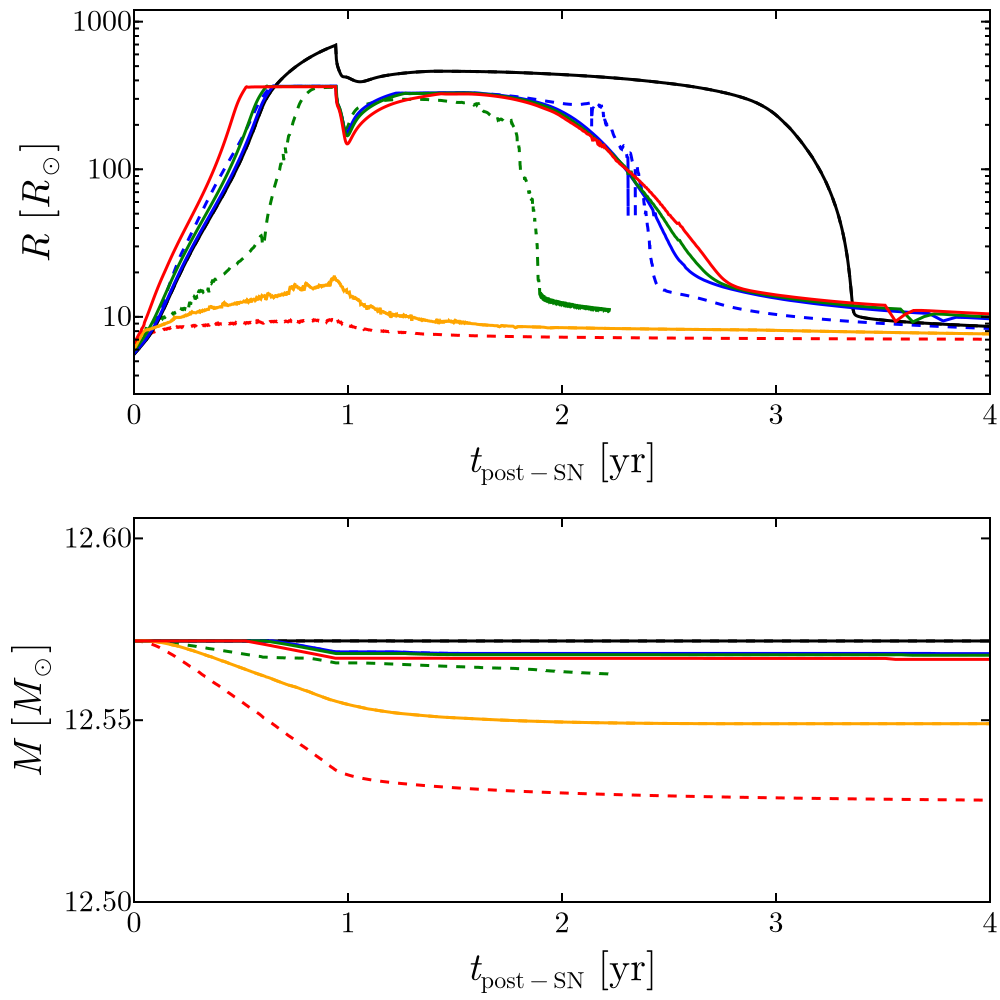

In [9]:
FIGURE = Figure(size=(500,500), figure_padding = 5)

mticks = union([j for k in 10. .^ (-9:1:10) for  j in k:k:10*k ])

grid = FIGURE[1, 1] = GridLayout()
ax = plot_settings(grid[1,1]; 
            xlabel=L"t_\mathrm{post-SN} \ [\mathrm{yr}]",
            ylabel=L"R \ [R_\odot]", 
            title =" ", xscale = identity, yscale = log10, 
            yticks=([0.1,1,10,100,1e3], ["0.1", "1", "10", "100", "1000"]),
            ymticks=mticks
            )
ax2 = plot_settings(grid[2,1]; 
            xlabel=L"t_\mathrm{post-SN} \ [\mathrm{yr}]",
            ylabel=L"M \ [M_\odot]", 
            title =" ", xscale = identity, 
            ymticks=mticks
            )

linestyle = Dict("rot"=> :dash, "rot_nomix"=>:solid)
linecolor = Dict("0p0"=> :black, "0p2"=>:blue, "0p5"=>:green, "0p6"=>:orange, "0p9"=>"red")
for rot in ["rot", "rot_nomix"]
    for omega in ["0p0", "0p2", "0p5", "0p6",  "0p9"]

        t = hf[rot][omega].star_age .- hf[rot][omega].star_age[1]
        R = 10. .^ (hf[rot][omega].log_R)
        M = hf[rot][omega].star_mass
        lines!(ax, t, R, color = linecolor[omega], linestyle=linestyle[rot])
        lines!(ax2, t, M, color = linecolor[omega], linestyle=linestyle[rot])

    end
end
xlims!(ax, 0,4)
xlims!(ax2, 0,4)
ylims!(ax, 3,1.2e3)
ylims!(ax2, 12.5, nothing)

FIGURE